# 实验

<a id="a3-top" name="a3-top"></a>
# A3 說明

**學生**：Kenny Huang（26254793）｜321513 Machine Learning｜Assessment 3｜**選擇的方向：商業（Business focus）**，情境為 Bank X 信用卡電話行銷。

**目錄**（Colab 左側的「目錄」面板也可以依標題跳轉）
- [Part A｜官方流程與解讀](#part-a)：官方 cell 依原順序執行，每段輸出後插一格「解讀」。
- [Part B｜商業評估：對照 A2 成功標準](#part-b)：開頭先給答案 → [十條標準一覽](#part-b-summary) → B-0～B-13 逐條證據 → [結論](#conclusion) → 附錄 A（業務② 區間的穩健性）與數字總表。

本 notebook 以官方 `AT3_TeleMarketing.ipynb` 為底：官方 cell 依原順序全部保留，官方 markdown（簡體中文）一字未動；只在下表的地方修改官方程式碼，每處都以 `# [A3 修正]` 註明。我新增的 cell 以 `[A3 新增]`（Part A）或 `[Part B-n]`、`[Fig n]`（Part B）開頭，說明用繁體中文；圖內文字用英文（Colab 沒有中文字型）。文中「官方 cell-N」指官方原檔的第 N 格（從 0 起算）；Colab 不顯示格號，所以引用時都會附上那一格在做什麼。

**官方 cell 的修改（全部）**

| 官方 cell | 修改 | 理由 |
|---|---|---|
| cell-2 安裝 ydata-profiling | `!pip` 改成 `%pip install ydata-profiling` | `%pip` 會裝進目前 kernel 的環境；`!pip` 可能裝到別的 Python |
| cell-3 匯入套件 | `from ydata_profiling import ProfileReport` 包 `try / except` | ydata-profiling 只用於 EDA 報告；安裝失敗時不讓同格的 sklearn 等匯入一起中斷 |
| cell-11 產生 EDA 報告 | `ProfileReport` 不可用時印訊息並略過 | 只少了 EDA.html，後面每一格照常執行 |
| cell-5 掛載 Google Drive | 包 `try / except`：沒有 `google.colab`（非 Colab）就略過；Colab 上拒絕或取消授權時只印訊息 | 「全部執行」不會停在掛載；Colab 正常授權時行為不變 |
| cell-9 讀取 CSV | 保留官方路徑；不存在時改讀環境變數 `TELEMARKETING_CSV`，預設為工作目錄（Colab 是 `/content`）下的 `TeleMarketing.csv`；都找不到時丟出說明清楚的錯誤 | 本機、或把 CSV 直接上傳到 `/content`，都能執行 |
| cell-13 資料清洗（TODO 1） | `month`、`day_of_week` 補 `"Not Applicable"` | 補完 TODO；缺值是結構性的（對照組沒被打電話） |
| cell-15 計數圖 `countplot` | 改用 `ax.containers` 配對長條 | seaborn 0.13 起把圖例代理也放進 `ax.patches`，原本前後半配對會錯位、百分比標錯（不報錯）；函式介面與圖不變 |
| cell-30 目標變數編碼（TODO 2） | `label_encoder.transform(...)` | 測試集只 transform、不重新 fit（防洩漏） |
| cell-44 `feature_selection_model` | 回傳 `list(selected_features)` | pandas 2.1 起不准用 dict 當欄位索引，cell-45／47／50 在 Colab 會 TypeError |
| cell-47 LR 特徵選擇（TODO 3） | `label='response'`、`model='LR'`、`k=10` | 補完 TODO，與上一格 RF 的寫法一致 |
| cell-58 最終 pipeline 超參數 | `max_depth` 第三值 9、`n_estimators` 第三值 300 | 依本次 CV 結果（見最終 pipeline 之後的解讀） |

另有三格執行所需的新增（都不是修改官方 cell）：產生 EDA 報告（官方 cell-11）後把 matplotlib 切回 inline（ydata-profiling 會讓之後所有圖都不顯示，而且不報錯）、TODO 1 之後檢查空值、分群前固定亂數種子。

**怎麼執行**
- **Colab**：把 `TeleMarketing.csv` 放在 My Drive 根目錄 → 執行階段 → 全部執行，並授權掛載 Drive（不想授權時，把 CSV 上傳到左側檔案區的 `/content` 也可以）。第一格會安裝 ydata-profiling；它要求 pandas < 3、matplotlib ≤ 3.10、scipy < 1.17、numpy < 2.4，若 Colab 內建版本較新，pip 會降版並提示重新啟動執行階段 —— 重新啟動後從第二格起全部執行即可（第一格可略過）。免費版只有 2 個 vCPU，最終 pipeline、t-SNE、巢狀交叉驗證與 bootstrap 會比本機慢數倍，整份預計 15 分鐘以上（未在 Colab 實測）。
- **本機**：設定環境變數 `TELEMARKETING_CSV` 指向 CSV（或把 CSV 放在工作目錄）。
- **本檔存著的輸出**：在 2026-10 建置當下的本機環境從頭執行（約 4 分鐘）：Python 3.11.9、numpy 2.0.2、pandas 2.2.2、scikit-learn 1.6.1、xgboost 3.0.2、seaborn 0.13.2、matplotlib 3.10.0，是建置當時 Colab 的同一組主要版本；之後 Colab 升級時可能不同。本機執行時 pip 用安靜模式，所以第一格只印出一行提示。**我沒有在 Colab 上存輸出。** markdown 裡的數字都由最後一格程式印出的數字總表自動填入，與存著的輸出一致；在其他環境重跑，少數數字（KMeans 分群、LR 的 RFE）可能略有不同。

**結構**
- **Part A｜官方流程＋分析**：在 EDA、t-SNE、兩種特徵選擇、模型比較、最終 pipeline、客戶評分、分群的輸出之後，各插一格「解讀」（需要時先插一小格程式印出要引用的數字），並指出官方流程的方法問題與影響大小。
- **Part B｜商業評估**：接在官方最後一格之後，用撥號前模型逐條檢驗我在 A2 表 4 寫下的 10 條成功標準（業務 ①–⑤、ML ①–⑤；②③⑤ 為上線硬門檻）與 A2 表 1 的商業目標，附 7 張圖（Fig 1–7）、總表與結論。

<a id="part-a" name="part-a"></a>
# Part A｜官方流程與解讀

以下是官方 notebook 的完整流程（讀資料 → EDA → 前處理 → t-SNE → 特徵選擇 → 模型比較 → 最終 pipeline → 客戶評分 → 分群），官方 cell 依原順序執行。我在 8 個地方的輸出之後插入「解讀」：EDA、t-SNE、單變量特徵選擇、模型式特徵選擇、模型比較、最終 pipeline、客戶評分、分群。每格解讀依序寫觀察（本次執行的數字）、商業意義與注意事項；官方流程的方法問題也在對應位置量出影響大小。

## 针对优惠和呼叫成本的优化
假设那些客户(特征: campaign=0)没有被营销活动定向触达(对照组), 如果他们的响应值为正, 说明他们是在没有折扣和呼叫成本的情况下自然购买了产品. 因此, 基于这一假设, 我们可以将客户分为以下 4 个类别:

1) **对照组: 未被营销活动定向触达但自然购买的客户: [campaign=0, response=1]**

2) **对照组: 未被营销活动定向触达且未购买的客户: [campaign=0, response=0]**

3) **目标组: 被营销活动定向触达且响应为正的客户: [campaign=1, response=1]**

4) **目标组: 被营销活动定向触达且响应为负的客户: [campaign=1, response=0]**

我们还假设每位客户的客户终身价值(CLV)相等, 且公司从每位购买产品的客户身上获得的收益相同. 因此, 每位客户转化的收益值是相同的, 我给出的收益值为 200 个单位.

考虑到上述假设, 营销活动的目标将是同时最大化转化率并最小化转化成本. 因此, 如果我们能够为每位客户定义一个考虑到这一目标的分数, 该分数应该代表客户在不同成本情境下购买产品的可能性. 成本因素是折扣成本和呼叫成本的组合:

- *折扣成本是一个二元情境. 如果客户被营销活动定向触达(campaign=1), 那么折扣成本为 100 个单位成本, 否则为 0.*


- *呼叫成本要稍微复杂一些. 我们假设通话时长分为 11 个时间区间(桶), 然后为每个区间分配成本. 第一个区间的呼叫成本为 0, 该区间代表 duration=0, 意味着该客户未被触达和联系过. 对于其余的区间, 我们假设每个区间累加 2 个单位成本, 一直累加到第 10 个区间, 例如 {区间0:0, 区间1:2, 区间2:4, 区间3:6, ..., 区间10:20}.*

基于上述假设, 我们可以定义如下分数:

***分数 =  SUM [200*                 P(Y=1|Campaign=0,Duration=区间(0)) +
                (100-成本(区间(i))* P(Y=1|Campaign=1, Duration=区间(i))]**
         

该分数是两个部分之和. 第一部分代表客户在没有任何成本的情况下自然购买产品的情形. 第二部分代表客户被营销活动定向触达并获得折扣的情形. 在这种情形下, 说服客户所花的时间越长, 涉及的呼叫成本就越高. 这两种情形都包含了客户响应为正的可能性.

基于这些假设, 你需要实现一个基于机器学习的解决方案, 根据分数对客户进行排序.

In [1]:
# [A3 修正] 用 %pip 而不是 !pip：%pip 會裝進目前 kernel 所在的環境（Colab 支援），避免裝到別的 Python
%pip install ydata-profiling

Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings
import pandas as pd
# [A3 修正] ydata-profiling 只用來產生 EDA 報告；若安裝失敗或與 Colab 版本衝突，不讓整格 import 中斷（後面的 sklearn 等照常匯入）
try:
    from ydata_profiling import ProfileReport
except Exception as e:
    ProfileReport = None
    print('ydata-profiling unavailable, the EDA report will be skipped:', type(e).__name__)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder, StandardScaler, PowerTransformer, OrdinalEncoder
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.feature_selection import RFE , f_classif, chi2, SelectKBest
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import Pipeline
from xgboost.sklearn import XGBClassifier
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from joblib import dump, load

<ipython-input>:5: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


挂载到你的谷歌云端硬盘, 并访问你云端硬盘中的共享数据

In [3]:
# [A3 修正] 非 Colab 環境沒有 google.colab → 略過掛載；在 Colab 若拒絕或取消 Drive 授權，drive.mount 會丟其他例外，
# 也只印訊息、不中斷「全部執行」（下面讀檔那一格會改找 /content 下的 TeleMarketing.csv）。Colab 上正常授權時行為不變
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    print('Not running in Colab: skip Google Drive mount')
except Exception as e:
    print('skip Drive mount:', repr(e))

Not running in Colab: skip Google Drive mount


In [4]:
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
RANDOM_SATE = 123

In [5]:
def read_data(path):
    return pd.read_csv(path)

In [6]:
cat_features=['job', 'marital', 'education', 'default', 'housing','loan',
              'poutcome','previous','month','day_of_week','contact','campaign']
num_features=['age','cons.price.idx', 'cons.conf.idx','duration']

In [7]:
# [A3 修正] 保留官方 Colab 路徑；該路徑不存在時改讀環境變數 TELEMARKETING_CSV 指定的檔案，預設為工作目錄下的 TeleMarketing.csv
# （Colab 的工作目錄是 /content，所以直接上傳到 /content 也可以）；都找不到時丟出說明清楚的錯誤
import os
csv_path = '/content/drive/MyDrive/TeleMarketing.csv'
if not os.path.exists(csv_path):
    csv_path = os.environ.get('TELEMARKETING_CSV', 'TeleMarketing.csv')
if not os.path.exists(csv_path):
    raise FileNotFoundError('TeleMarketing.csv not found: put it in the My Drive root (and allow the Drive mount) '
                            'or upload it to /content, or set TELEMARKETING_CSV to its path')
data = read_data(path=csv_path)
print(data.shape)

(41188, 17)


使用 Pandas Data Profiler 为数据创建数据概况报告

In [8]:
# [A3 修正] ydata-profiling 不可用時略過 EDA 報告（只少了 EDA.html，不影響後面任何一格）
if ProfileReport is not None:
    prof = ProfileReport(data)
    prof.to_file(output_file='EDA.html')
else:
    print('skip the EDA report (ydata-profiling unavailable)')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Summarize dataset:   0%|          | 0/22 [00:00<?, ?it/s, Describe variable: age]

Summarize dataset:   0%|          | 0/22 [00:00<?, ?it/s, Describe variable: job]

Summarize dataset:   0%|          | 0/22 [00:00<?, ?it/s, Describe variable: marital]

Summarize dataset:   0%|          | 0/22 [00:00<?, ?it/s, Describe variable: education]

...

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML: 100%|██████████| 1/1 [00:00<00:00,  6.43it/s]

Render HTML: 100%|██████████| 1/1 [00:00<00:00,  6.39it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 199.97it/s]

In [9]:
# [A3 新增] ydata-profiling 產生報告時會把 matplotlib 換成不互動的 Agg 畫布（matplotlib.is_interactive() 變 False），
# 之後官方 cell 的圖全部不會顯示，也不會報錯。這裡切回 notebook 內嵌顯示（Colab 預設也是 inline），並關掉報告留下的圖。
%matplotlib inline
plt.close('all')

## 数据清洗
查看数据概况后, 需要进行以下几项快速的数据准备工作:
- 去除重复值
- 填补空值
- 将部分数值特征转换为类别特征

In [10]:
data = data.drop_duplicates()
data["contact"].fillna("Not Applicable", inplace = True)

# TODO 1: fill the null values in variables "month" and "days_of_week" with "Not Applicable"
# Edit the code by replacing the underscore
# [A3 修正] 補完 TODO 1：month 的缺值是結構性的（對照組沒被打電話），補固定字串，不用到任何統計量
data["month"].fillna("Not Applicable", inplace = True)
# [A3 修正] 補完 TODO 1：day_of_week 同上（題目註解寫 days_of_week 是筆誤，CSV 欄名是 day_of_week）
data["day_of_week"].fillna("Not Applicable", inplace = True)
data['previous']= data['previous'].apply(str)
data['campaign']= data['campaign'].apply(str)
campaign_data= data.copy(deep=True)
print(campaign_data.shape)

(35438, 17)


In [11]:
# [A3 新增] 防呆檢查：確認 TODO 1 的三個欄位已沒有空值（印出各欄空值數）
# pandas 2.x 的鏈式 inplace fillna 仍有效；若在 pandas 3.0（Copy-on-Write）下靜默失效，這裡先補救再檢查
a3_na = campaign_data[['contact', 'month', 'day_of_week']].isnull().sum()
if a3_na.sum() > 0:
    print('chained inplace fillna had no effect -> repaired with DataFrame.fillna', a3_na.to_dict())
    campaign_data = campaign_data.fillna({'contact': 'Not Applicable', 'month': 'Not Applicable', 'day_of_week': 'Not Applicable'})
    data = campaign_data.copy(deep=True)
    a3_na = campaign_data[['contact', 'month', 'day_of_week']].isnull().sum()
print(a3_na)
assert a3_na.sum() == 0


def a3_r(x, nd=4):
    """numpy 數字 -> JSON 可存的 Python 數字（四捨五入）"""
    if isinstance(x, (bool, np.bool_)):
        return bool(x)
    if isinstance(x, (int, np.integer)):
        return int(x)
    return round(float(x), nd)


A3_KPI = {'part_a': {}, 'part_b': {}}   # 收集報告會引用的數字；最後一格程式把它印成 JSON
A3_KPI['part_a']['rows_after_dedup'] = len(campaign_data)

contact        0
month          0
day_of_week    0
dtype: int64


## 数据探索
绘制计数图(countplot), 以更深入地了解类别特征与响应值之间的关系.

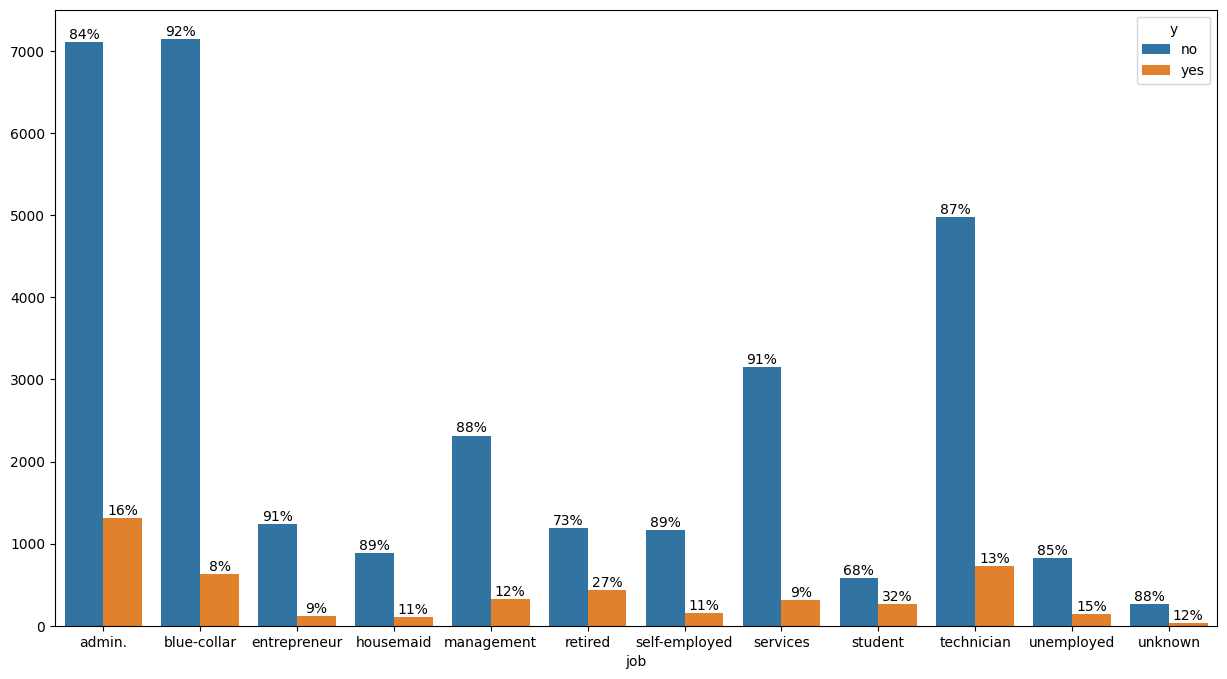

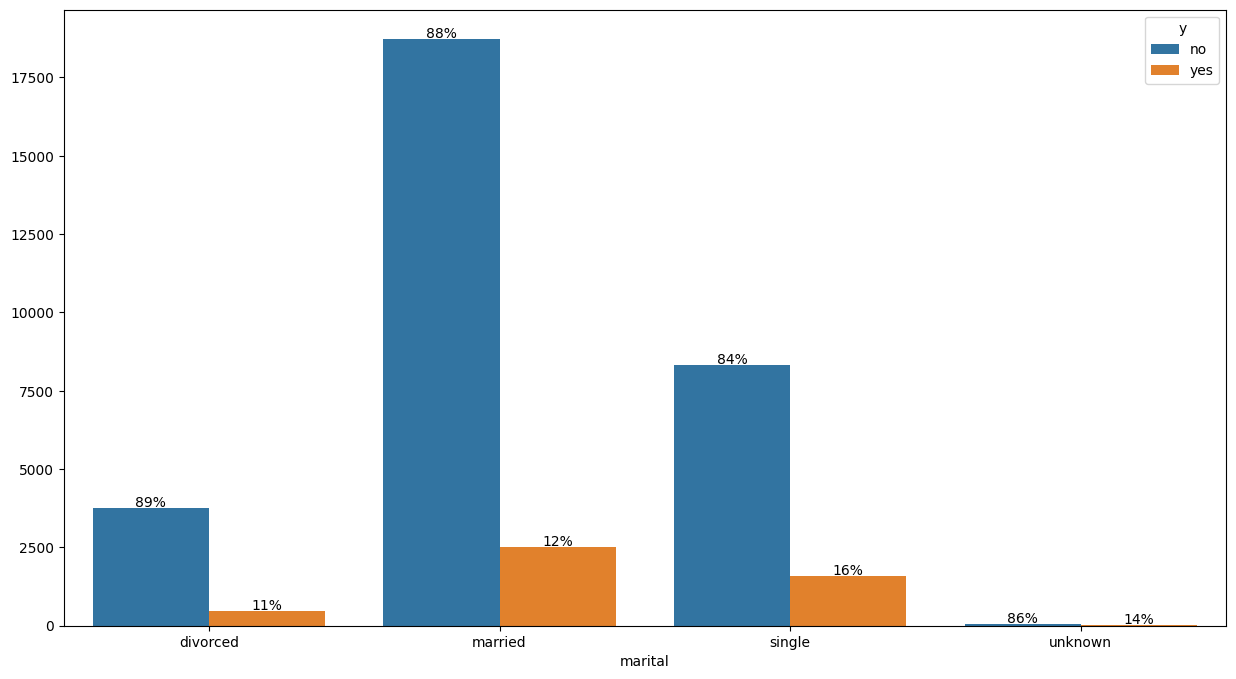

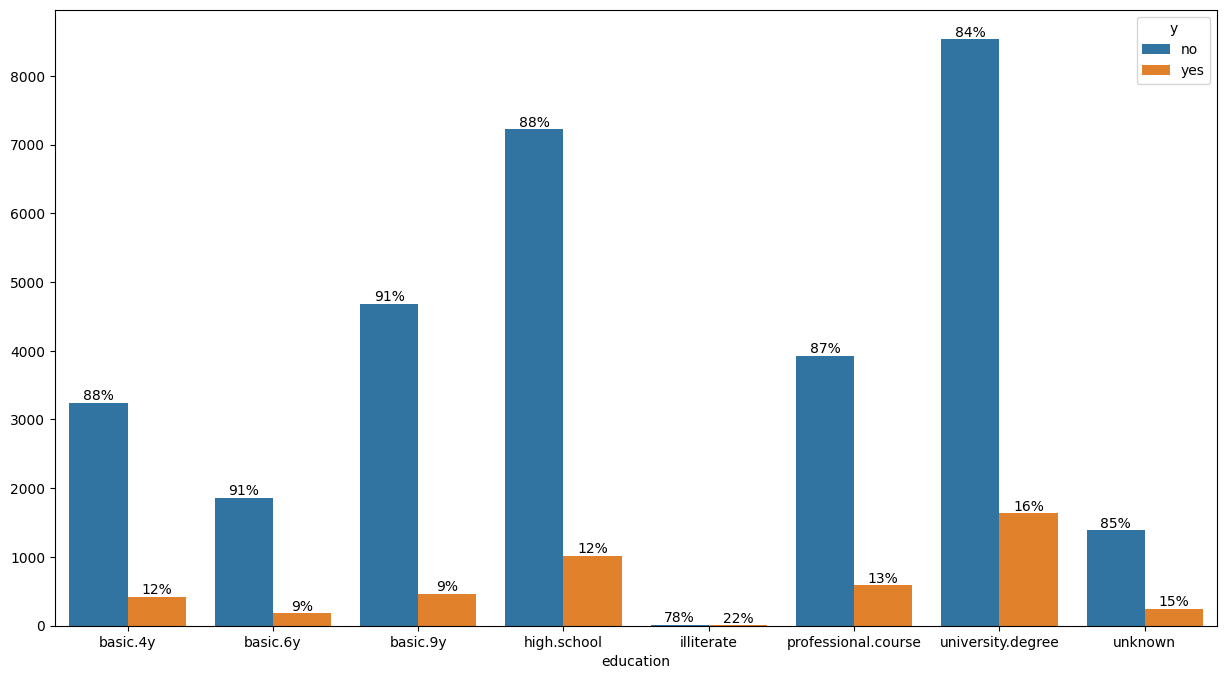

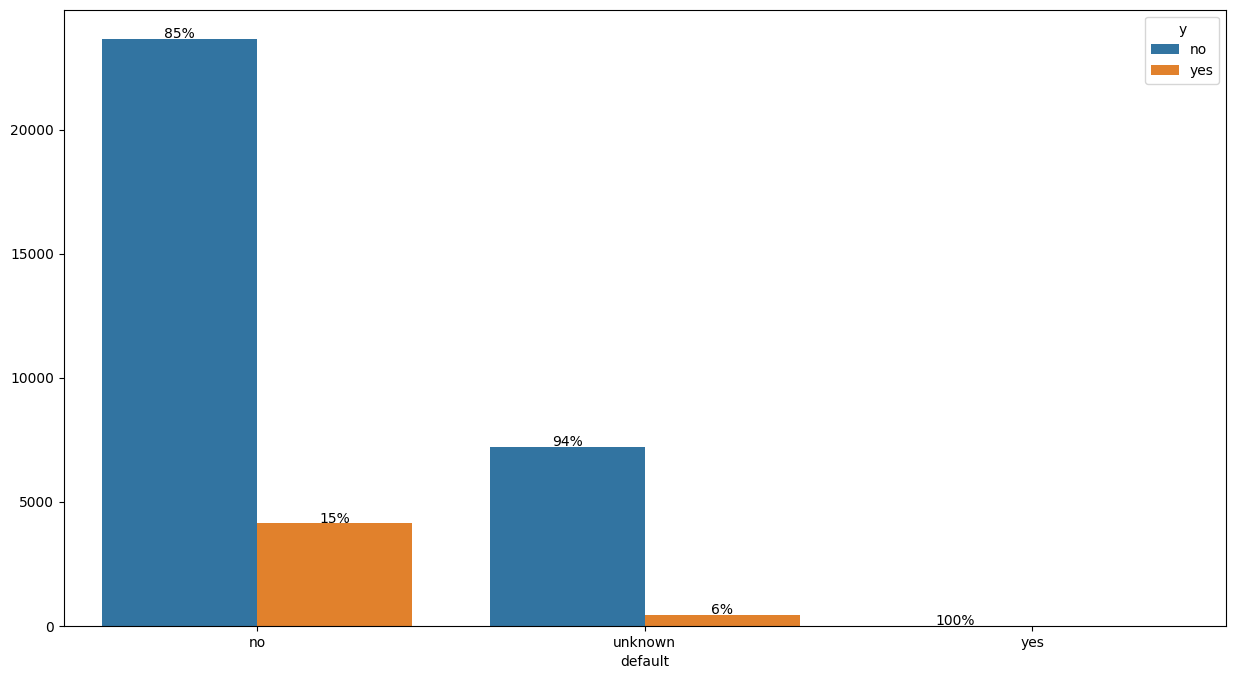

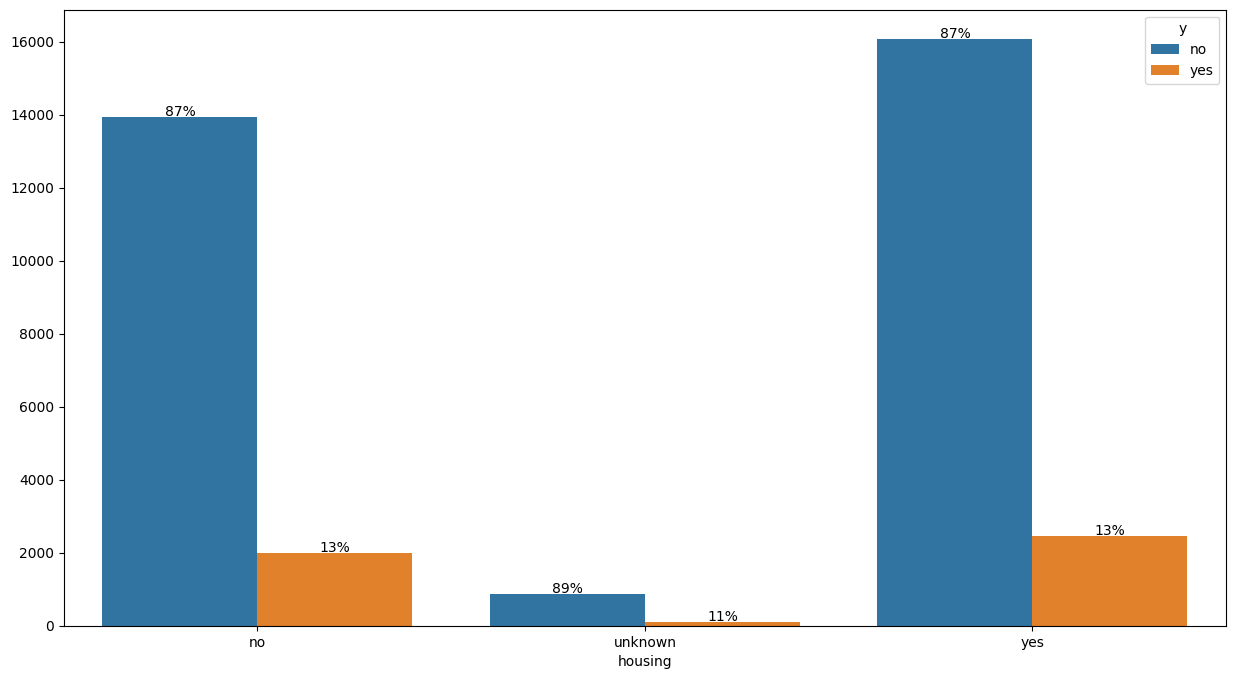

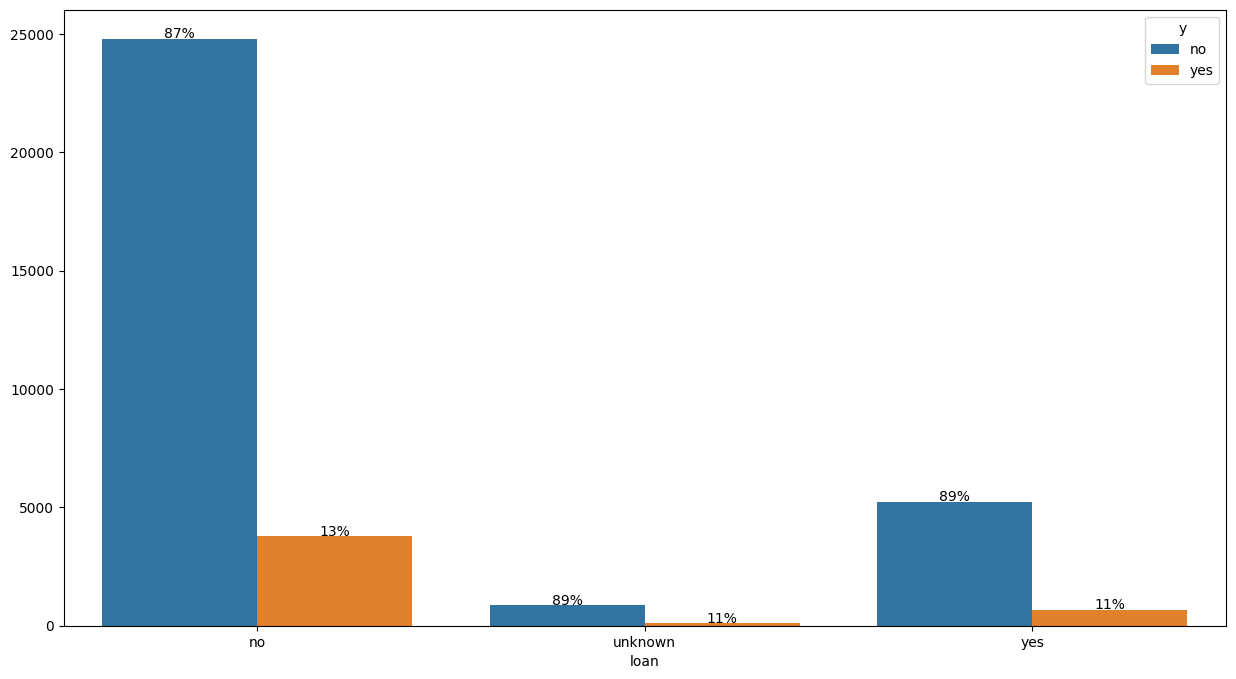

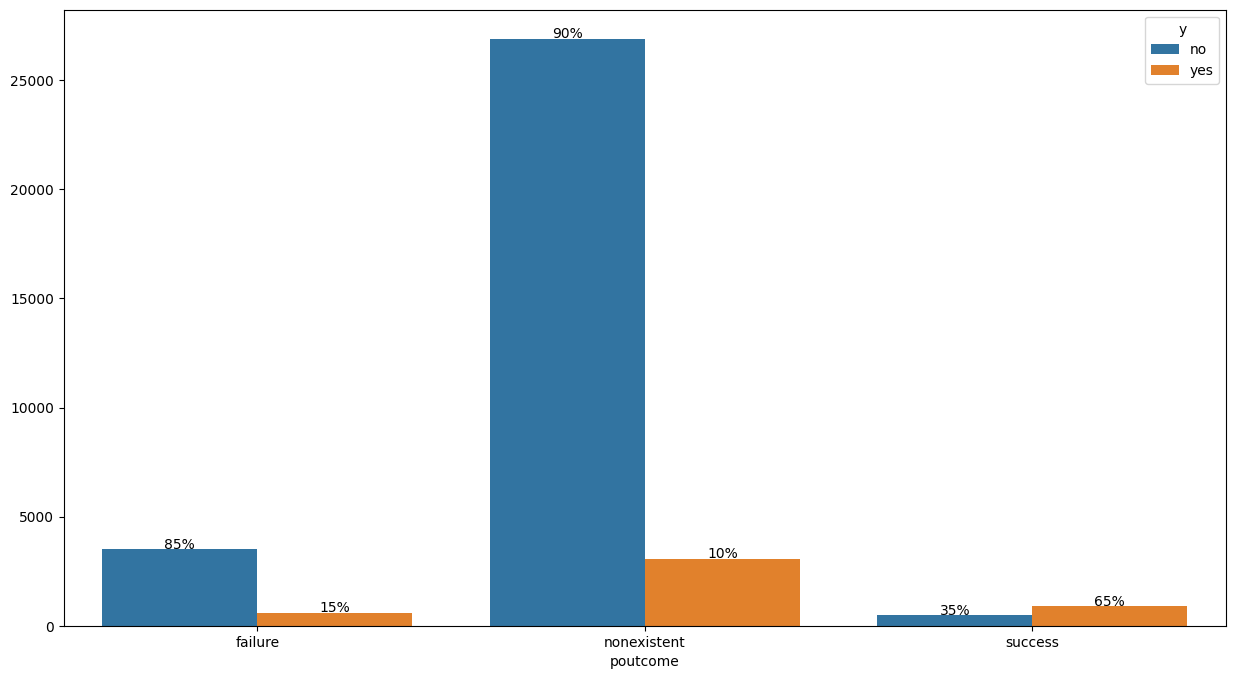

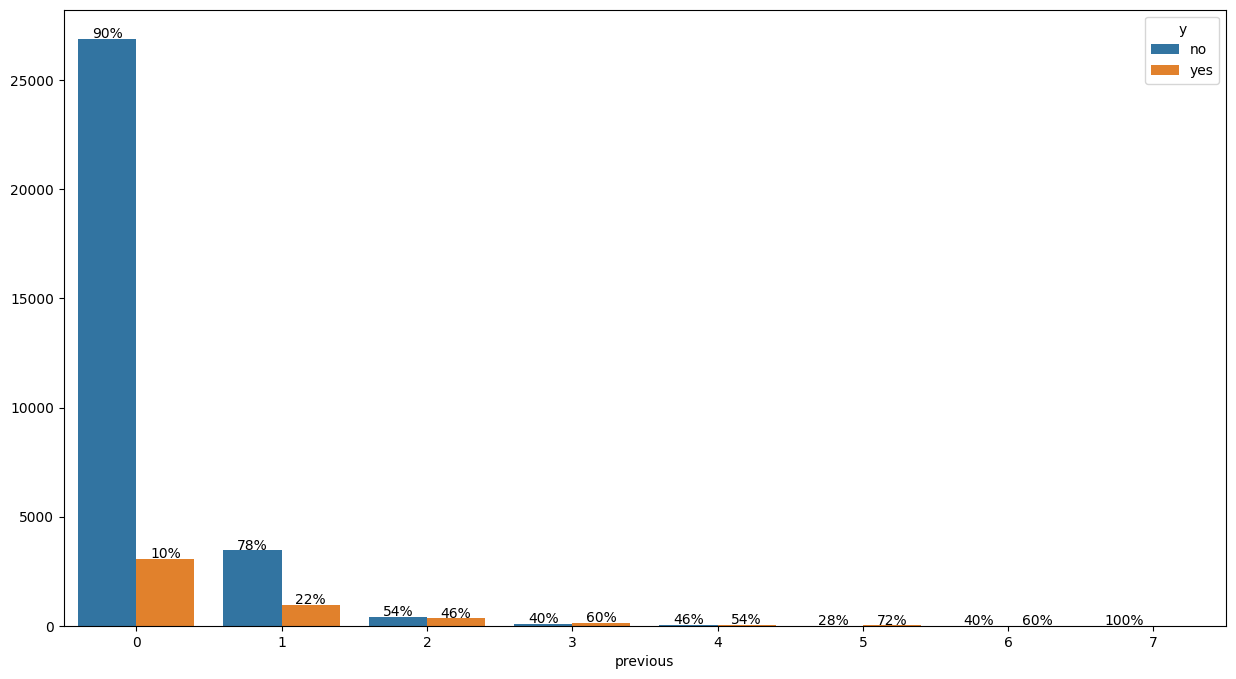

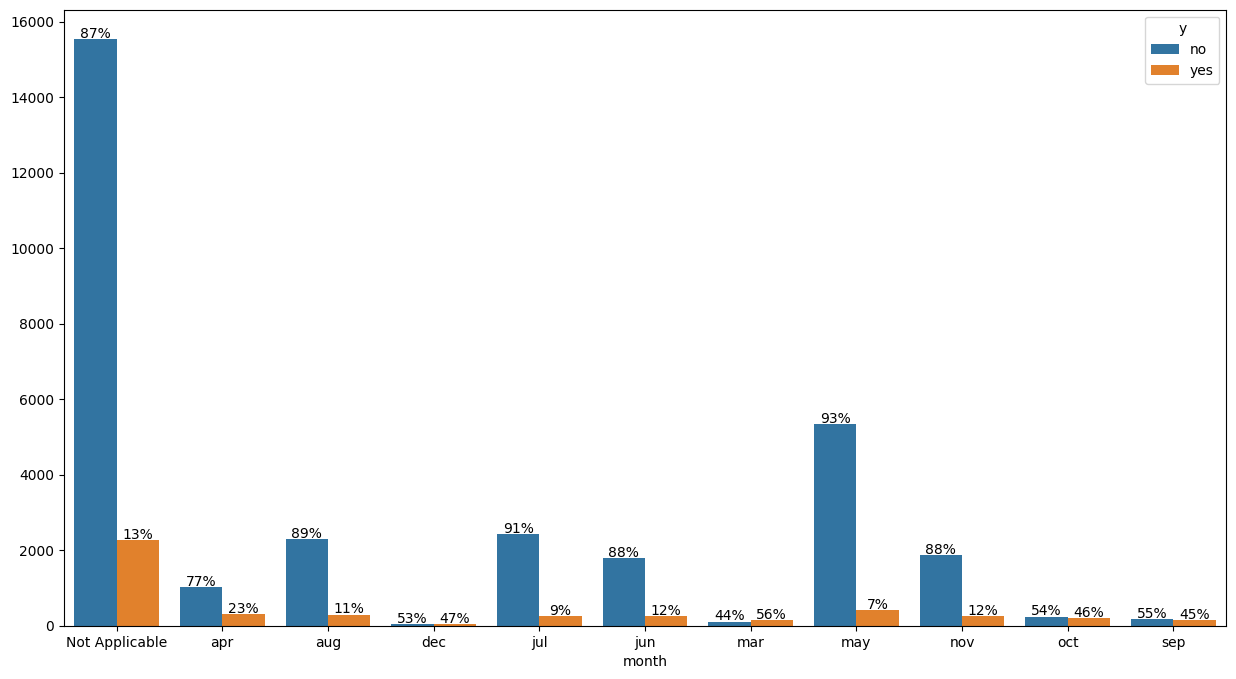

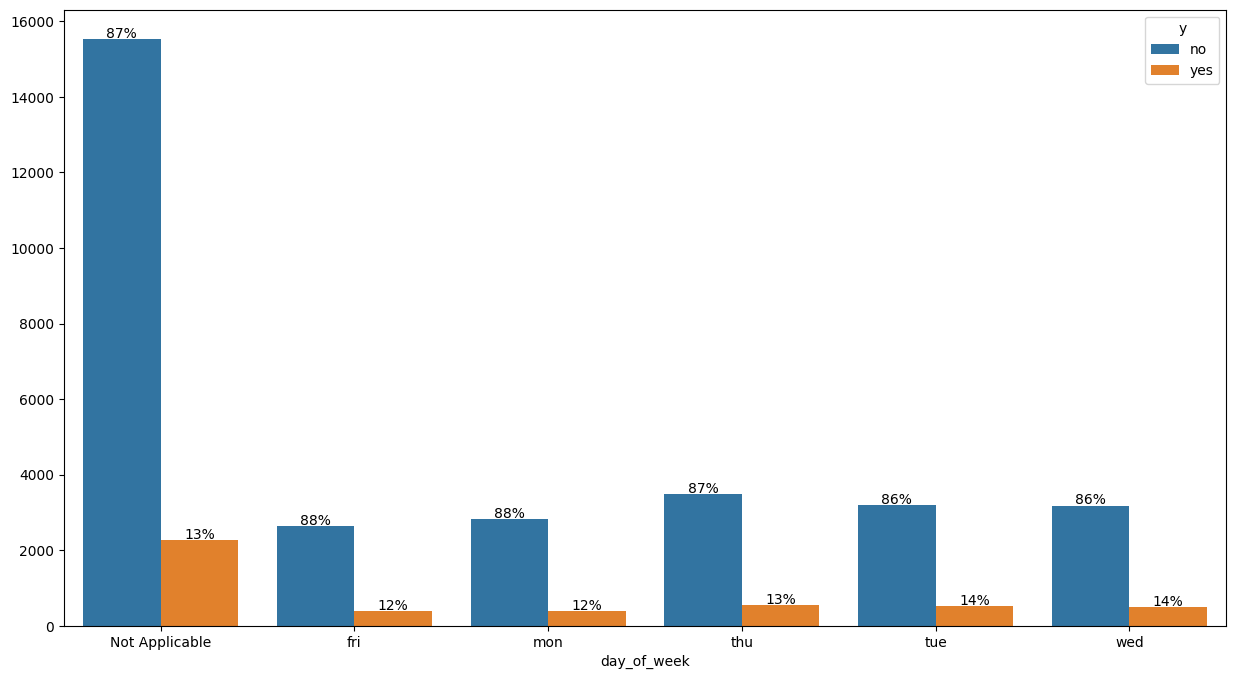

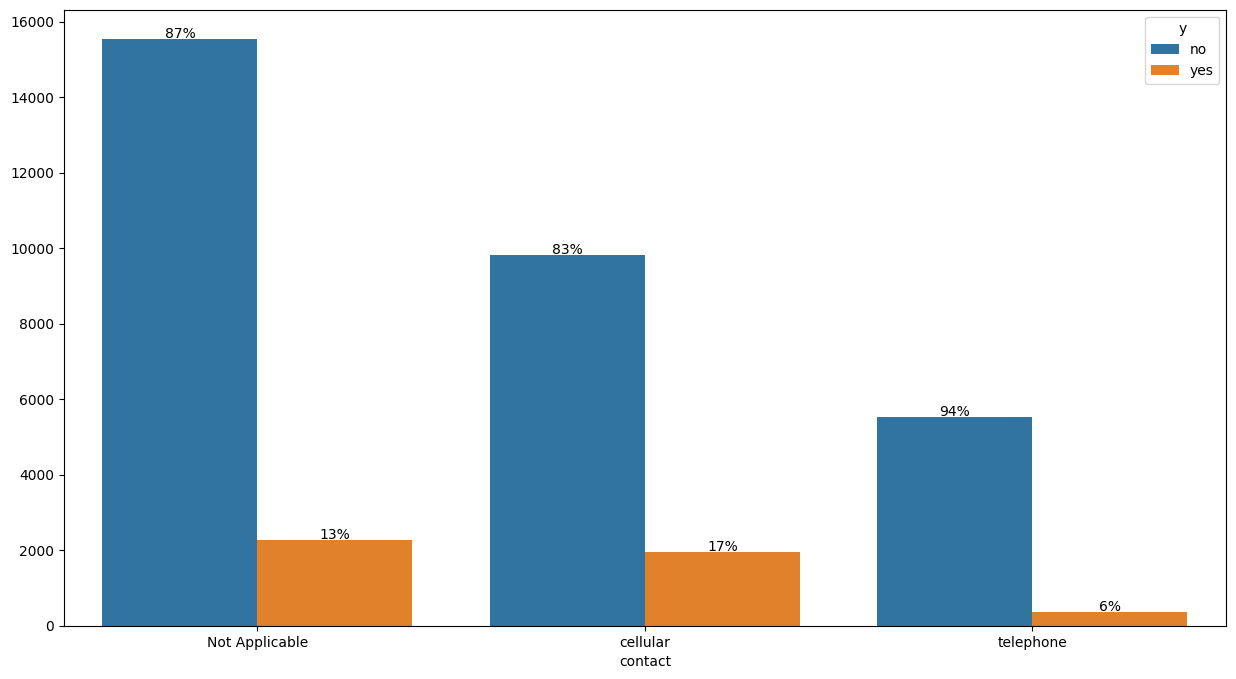

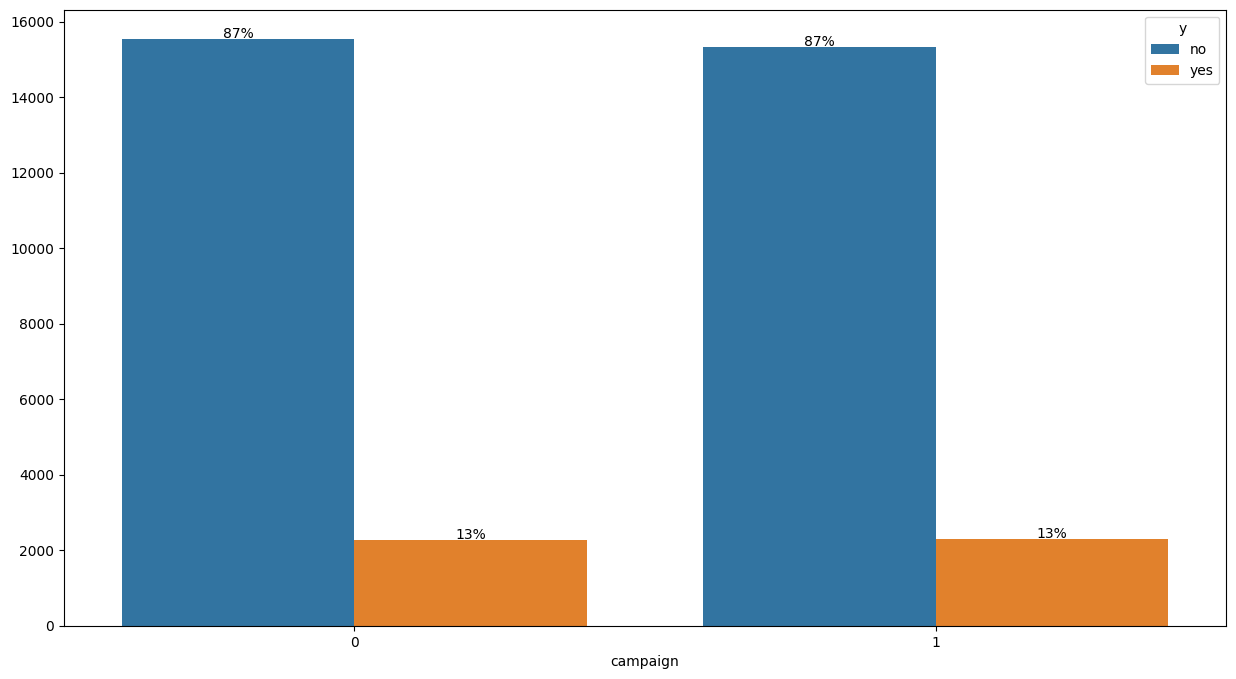

In [12]:
def countplot(column, dataset,label):
    for index, category in enumerate(column):
        plt.figure(figsize=(15,8))
        order = sorted(dataset[category].unique())
        ax = sns.countplot(x= category, data=dataset, hue=label, order=order)
        ax.set_ylabel('')

        # [A3 修正] seaborn >= 0.13 會把圖例的代理矩形也放進 ax.patches，且計數為 0 的組合不畫柱，
        # 原本「前半 / 後半」切 ax.patches 的配對會錯位、百分比標錯（不會報錯）。
        # 改用 ax.containers（每個 hue 一組柱），依柱子所在的類別位置配對加總，再標各柱佔該類別的比例。
        totals = {}
        for container in ax.containers:
            for bar in container:
                pos = int(round(bar.get_x() + bar.get_width()/2.))
                totals[pos] = totals.get(pos, 0) + bar.get_height()
        for container in ax.containers:
            for bar in container:
                pos = int(round(bar.get_x() + bar.get_width()/2.))
                height = bar.get_height()
                if totals[pos] > 0:
                    ax.text(bar.get_x() + bar.get_width()/2., height + 40, '{0:.0%}'.format(height/totals[pos]), ha="center")

countplot(cat_features, campaign_data,'y')

绘制箱线图和分布图, 以理解数值特征对响应值的影响.

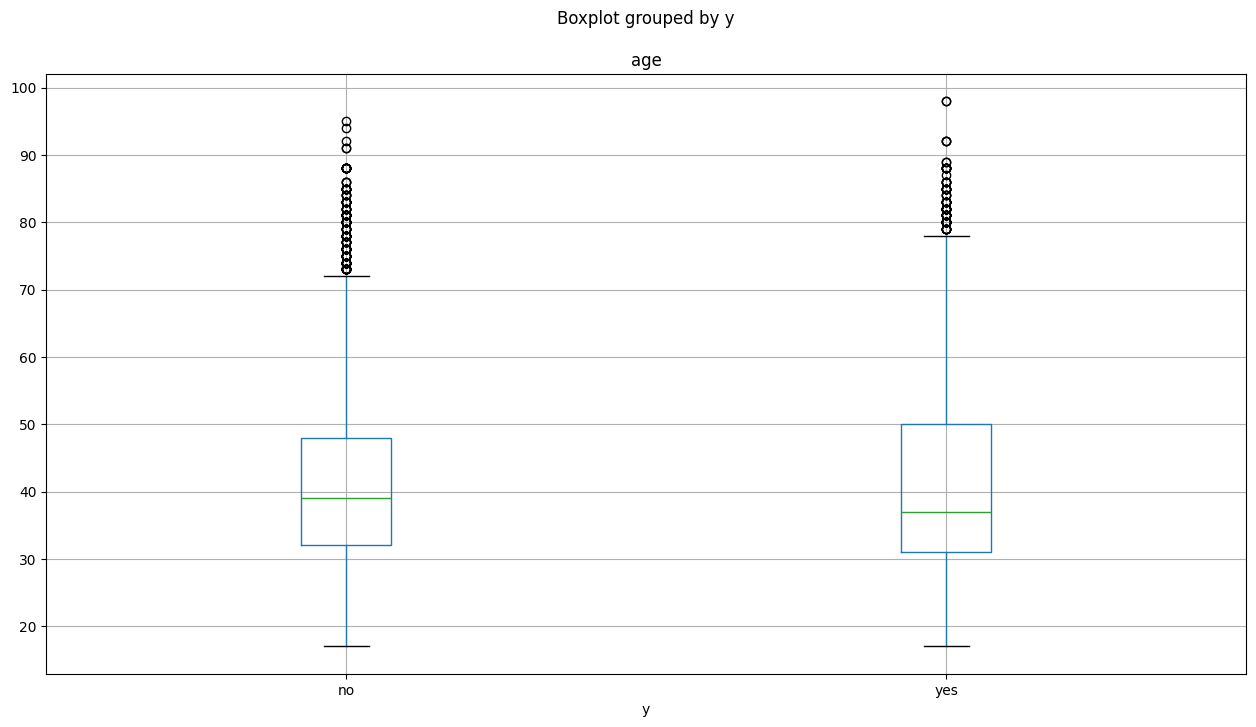

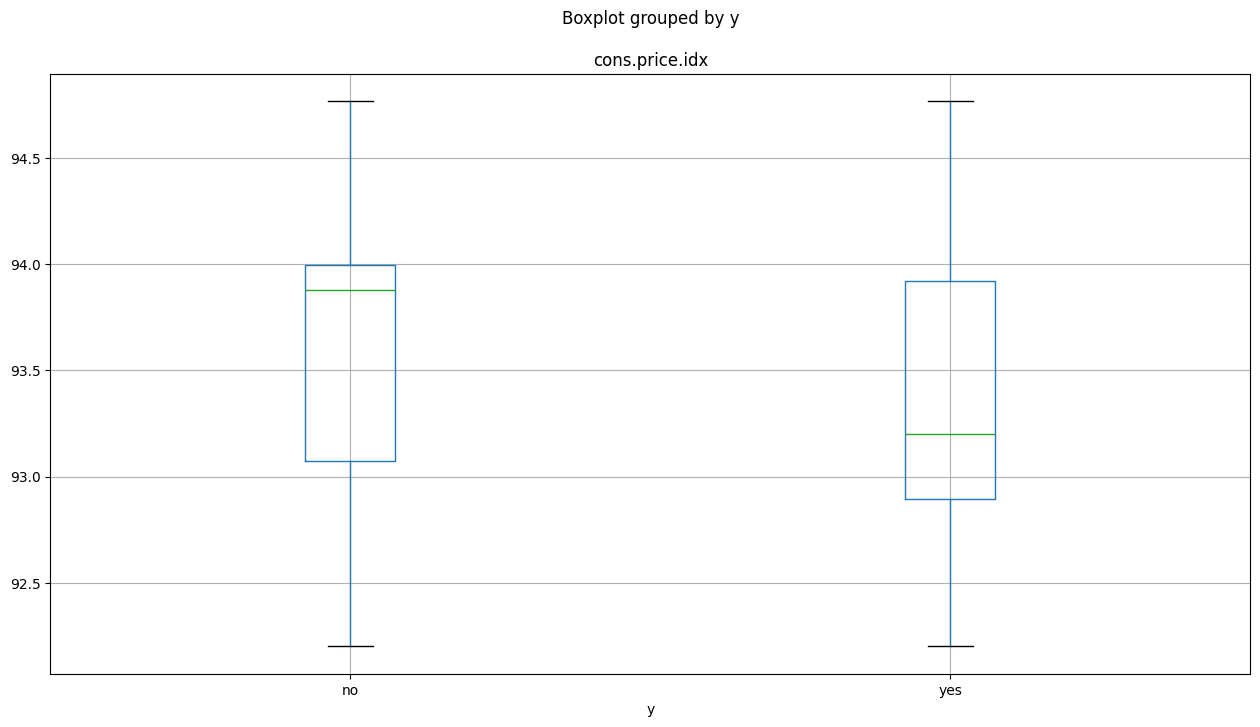

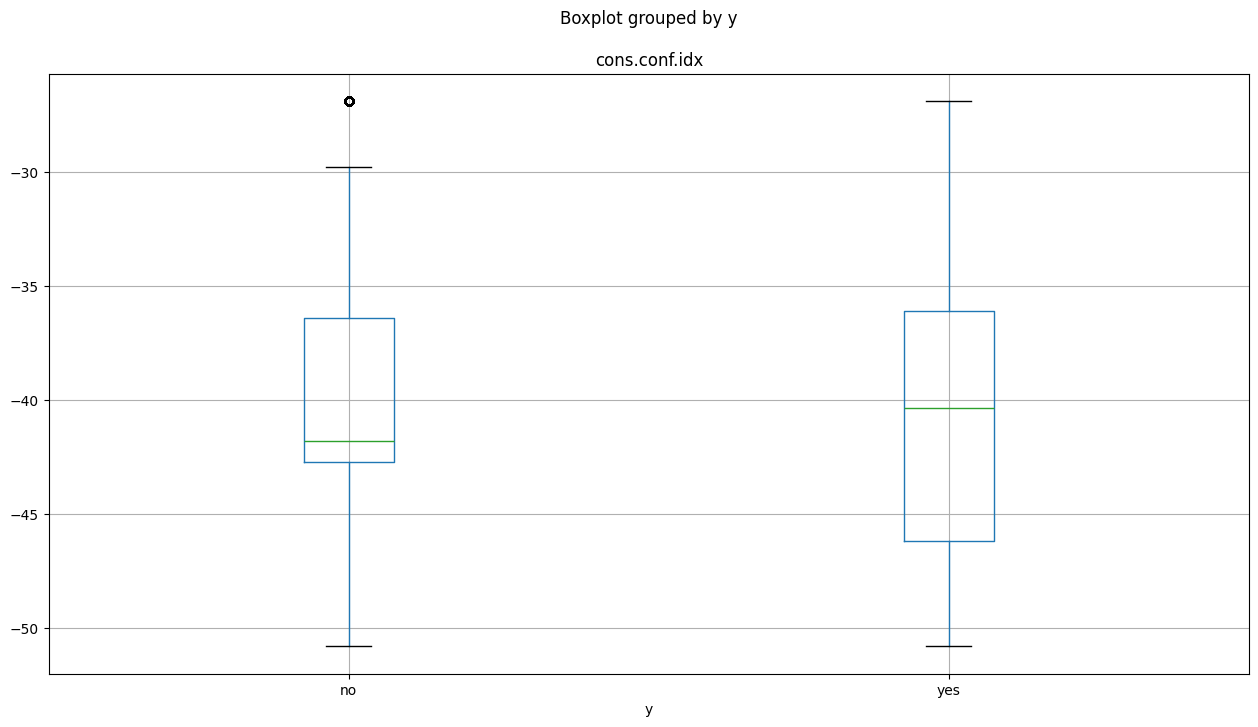

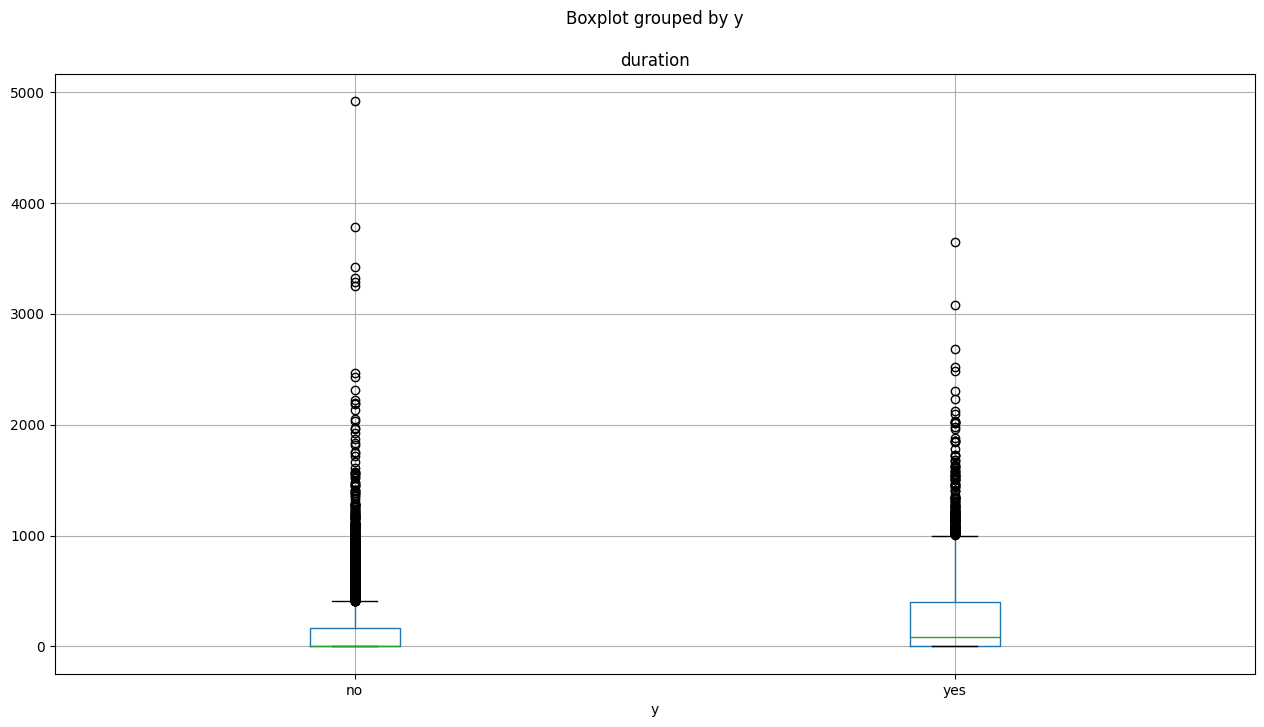

In [13]:
def boxplot_response(columns,label,dataset):
    for c in columns:
        dataset.boxplot(by=label,figsize=(15,8),column=[c])
boxplot_response(num_features, 'y', campaign_data)

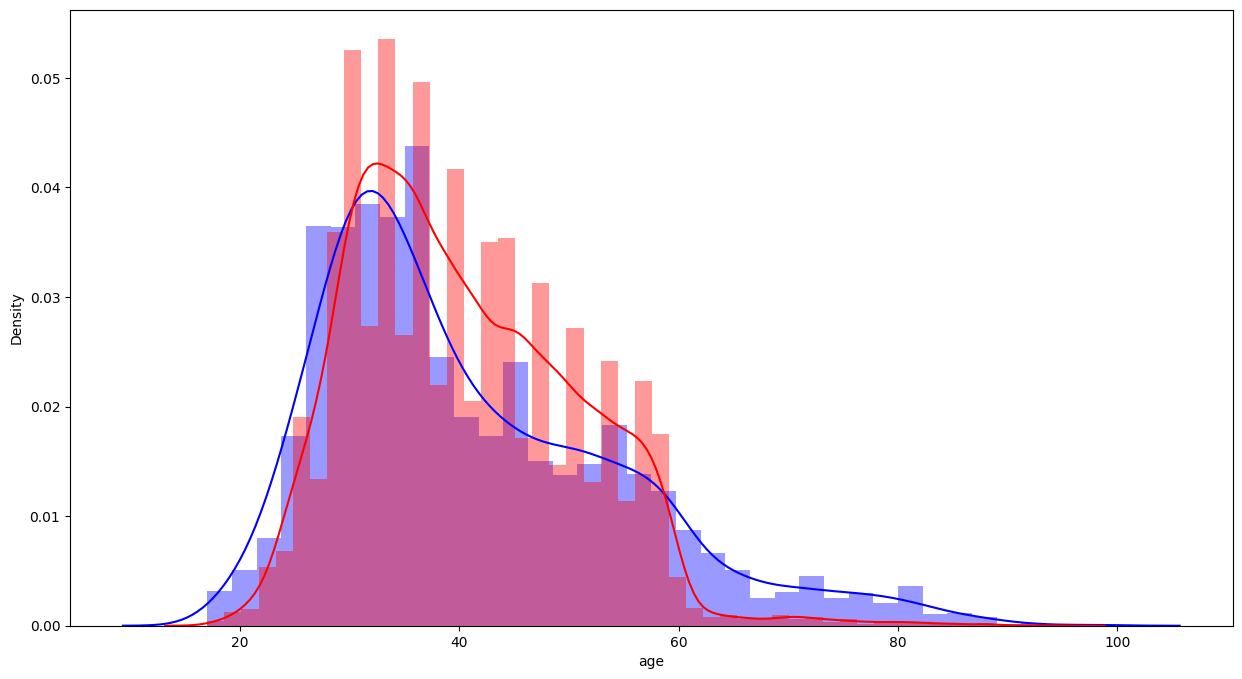

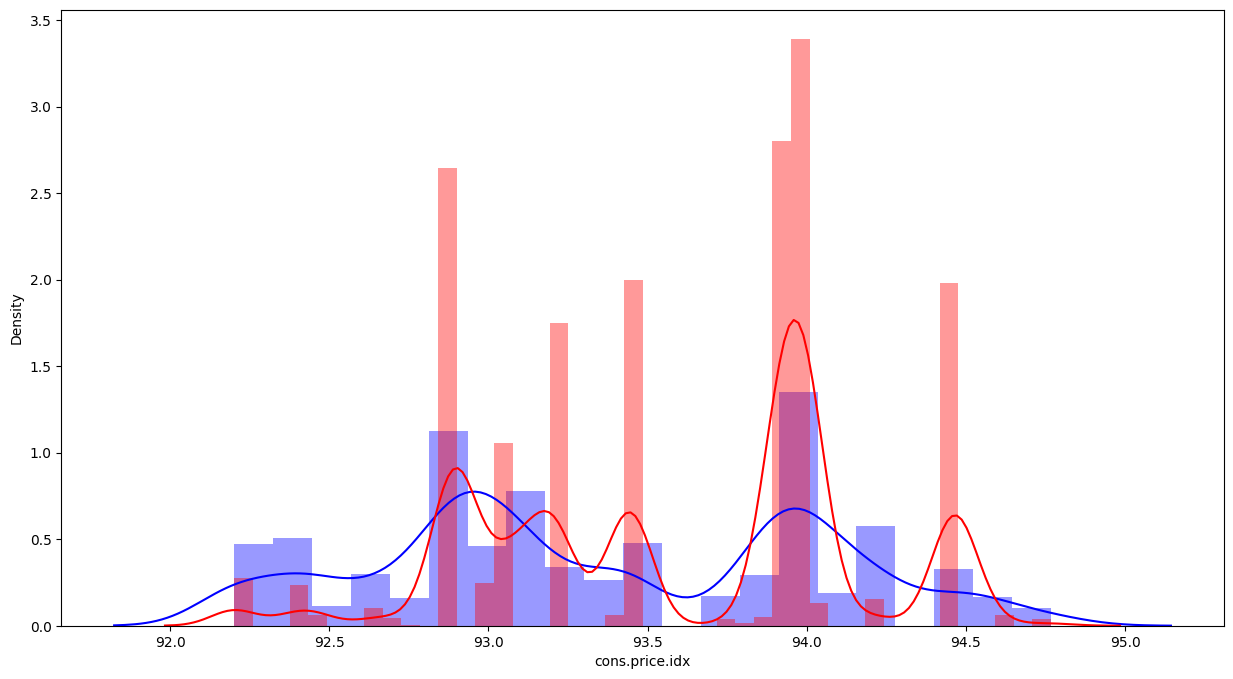

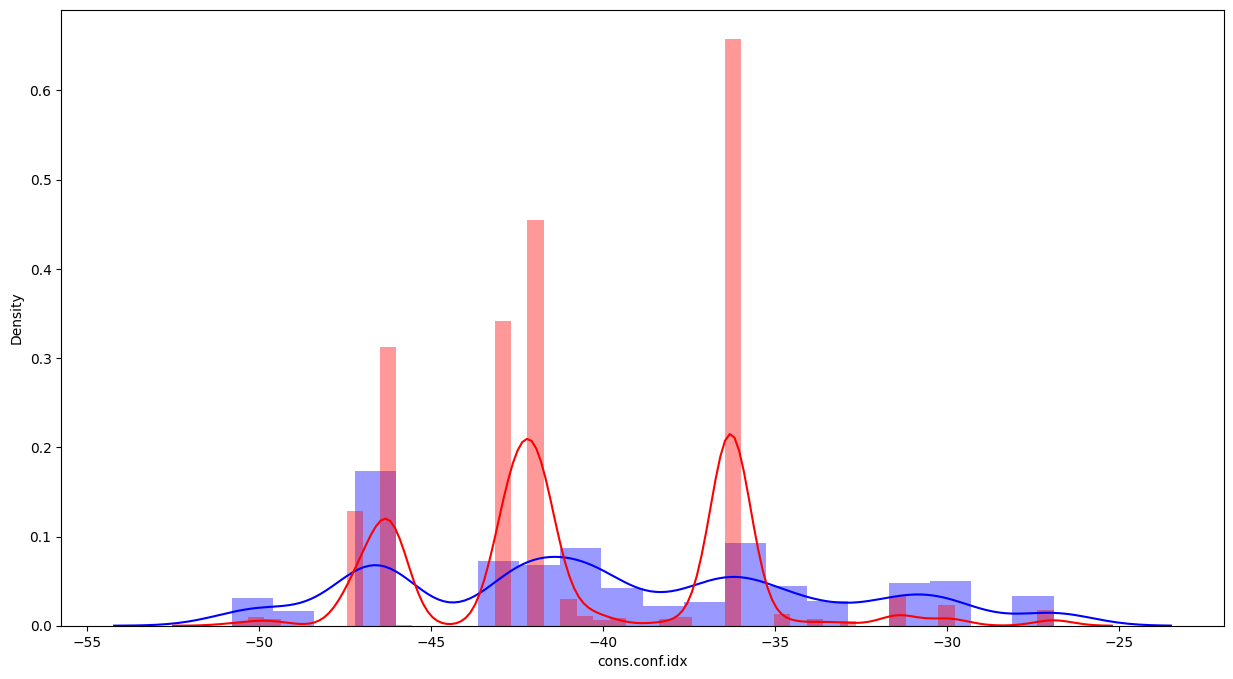

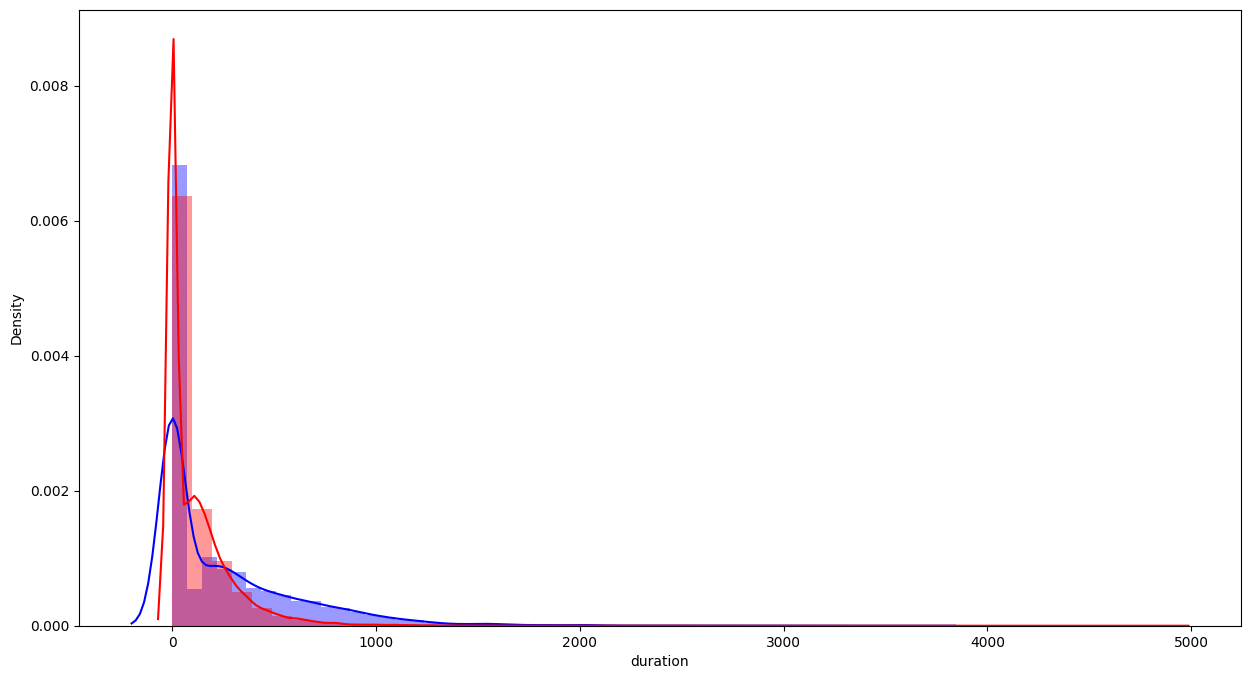

In [14]:
def dsitplot_response(column, dataset):
    for c in column:
        plt.figure(figsize=(15,8))
        ax = sns.distplot(dataset.loc[(dataset['y']=='yes')][c],color='blue')
        ax = sns.distplot(dataset.loc[(dataset['y']=='no')][c], color='red')
#         plt.show()
dsitplot_response(num_features, campaign_data)

In [15]:
# [A3 新增] EDA 數字摘要：上面三格只有圖，這裡把解讀要引用的數字印成表（只讀 campaign_data，不改動它）
def a3_conv(s):
    return round(100 * (s == 'yes').mean(), 2)

a3_T = campaign_data[campaign_data['campaign'] == '1']
a3_eda_grp = campaign_data.groupby('campaign').agg(rows=('y', 'size'), conv_pct=('y', a3_conv),
                                                   duration0_pct=('duration', lambda s: round(100 * (s == 0).mean(), 2)))
a3_eda_pout = campaign_data.groupby('poutcome')['y'].agg(rows='size', conv_pct=a3_conv)
a3_eda_contact = a3_T.groupby('contact')['y'].agg(rows='size', conv_pct=a3_conv)
a3_eda_month = a3_T.groupby('month')['y'].agg(rows='size', conv_pct=a3_conv).sort_values('conv_pct', ascending=False)
a3_eda_num = campaign_data.groupby('y')[['age', 'cons.price.idx', 'cons.conf.idx']].mean().round(2)
a3_eda_num['duration_target'] = a3_T.groupby('y')['duration'].mean().round(1)
print('[1] control (0) vs target (1): rows, conversion %, share with duration = 0\n', a3_eda_grp, '\n')
print('[2] conversion % by previous campaign outcome (all rows)\n', a3_eda_pout, '\n')
print('[3] target group: conversion % by contact channel\n', a3_eda_contact, '\n')
print('[4] target group: conversion % by month (sorted)\n', a3_eda_month, '\n')
print('[5] mean of numeric features by y (duration_target: target group only, the control group is all 0)\n', a3_eda_num, '\n')
# 計數圖上其他類別欄位（全部列）與星期（只有目標組有值）的成交率；只列 500 列以上的類別才比較高低
a3_eda_cat = {c: campaign_data.groupby(c)['y'].agg(rows='size', conv_pct=a3_conv) for c in ['job', 'education', 'default', 'housing', 'loan']}
a3_eda_dow = a3_T.groupby('day_of_week')['y'].agg(rows='size', conv_pct=a3_conv)
print('[6] conversion % by job / education / default / housing / loan (all rows) and by day of week (target group)')
for c, t in a3_eda_cat.items():
    print(t.sort_values('conv_pct', ascending=False).T.to_string(), '\n')
print(a3_eda_dow.T.to_string())
a3_base = a3_conv(campaign_data['y'])
print('\n[7] overall share of "yes" after deduplication: %.2f%% (class imbalance, about 1 in %.0f)' % (a3_base, 100 / a3_base))
# poutcome = success 依組別（A2 附錄 A 的 67.3%／62.7% 是原始全檔的目標組／對照組，母體不同）
a3_ps = campaign_data[campaign_data['poutcome'] == 'success'].groupby('campaign')['y'].agg(rows='size', conv_pct=a3_conv)
print('[8] poutcome = success by group (deduplicated; 0 = control, 1 = target)\n', a3_ps)

A3_KPI['part_a']['eda'] = {
    'base_conv_pct': a3_base,
    'cat_conv_pct': {c: {k: a3_r(v, 2) for k, v in t['conv_pct'].items()} for c, t in a3_eda_cat.items()},
    'cat_rows': {c: {k: a3_r(v) for k, v in t['rows'].items()} for c, t in a3_eda_cat.items()},
    'cat_conv_range_n500': {c: [a3_r(t.loc[t['rows'] >= 500, 'conv_pct'].min(), 2), a3_r(t.loc[t['rows'] >= 500, 'conv_pct'].max(), 2)]
                            for c, t in a3_eda_cat.items()},
    'cat_best_n500': {c: t.loc[t['rows'] >= 500, 'conv_pct'].idxmax() for c, t in a3_eda_cat.items()},
    'cat_worst_n500': {c: t.loc[t['rows'] >= 500, 'conv_pct'].idxmin() for c, t in a3_eda_cat.items()},
    'dow_conv_range': [a3_r(a3_eda_dow['conv_pct'].min(), 2), a3_r(a3_eda_dow['conv_pct'].max(), 2)],
    'rows': {k: a3_r(v) for k, v in a3_eda_grp['rows'].items()},
    'conv_pct': {k: a3_r(v, 2) for k, v in a3_eda_grp['conv_pct'].items()},
    'duration0_pct': {k: a3_r(v, 2) for k, v in a3_eda_grp['duration0_pct'].items()},
    'target_duration0_rows': a3_r((a3_T['duration'] == 0).sum()),
    'poutcome_conv_pct': {k: a3_r(v, 2) for k, v in a3_eda_pout['conv_pct'].items()},
    'poutcome_rows': {k: a3_r(v) for k, v in a3_eda_pout['rows'].items()},
    'target_contact_conv_pct': {k: a3_r(v, 2) for k, v in a3_eda_contact['conv_pct'].items()},
    'target_contact_rows': {k: a3_r(v) for k, v in a3_eda_contact['rows'].items()},
    'target_month_conv_pct': {k: a3_r(v, 2) for k, v in a3_eda_month['conv_pct'].items()},
    'target_month_rows': {k: a3_r(v) for k, v in a3_eda_month['rows'].items()},
    'mean_by_y': {c: {k: a3_r(v, 2) for k, v in a3_eda_num[c].items()} for c in a3_eda_num.columns},
    'target_duration_max': a3_r(a3_T['duration'].max()),
    'poutcome_success_by_group': {k: {'rows': int(r['rows']), 'conv_pct': a3_r(r['conv_pct'], 2)} for k, r in a3_ps.iterrows()},
}

[1] control (0) vs target (1): rows, conversion %, share with duration = 0
            rows  conv_pct  duration0_pct
campaign                                
0         17805     12.73          100.0
1         17633     13.04            0.0 

[2] conversion % by previous campaign outcome (all rows)
               rows  conv_pct
poutcome                    
failure       4109     14.70
nonexistent  29964     10.26
success       1365     65.05 

[3] target group: conversion % by contact channel
             rows  conv_pct
contact                   
cellular   11753     16.57
telephone   5880      5.99 

[4] target group: conversion % by month (sorted)
        rows  conv_pct
month                
mar     253     56.13
dec      83     46.99
oct     454     46.26
sep     328     44.82
apr    1324     23.26
jun    2043     12.29
nov    2119     11.66
aug    2594     11.33
jul    2671      9.21
may    5764      7.20 

[5] mean of numeric features by y (duration_target: target group only, the c

### 解讀：EDA（計數圖、箱形圖、分布圖與上方數字摘要）

**結論：撥號前看得到、又有區分力的訊號是前次行銷結果、時期與少數職業；duration 是洩漏，不是商業槓桿。**

- **基準與類別不平衡**：去重後全體成交 12.88%（約 8 人中 1 人），所以後面都用 AUC 與轉換率，不用準確率。對照組 17,805 列、目標組 17,633 列，轉換率 12.73% 對 13.04%，幾乎一樣；A2 用原始資料是 9.94% 對 13.04%，差別來自去重刪掉的列幾乎全在對照組（Part B-0）。
- **前次行銷與時期**：poutcome = success 在去重後全體（含對照組，1,365 列）成交 65.05%；分組看，目標組 67.27%、對照組 62.56%（A2 附錄 A 的 67.3%／62.7% 是原始全檔的目標組／對照組，母體不同）。無前次紀錄者只有 10.26%。目標組 3 月 56.13%（253 通）、5 月只有 7.2%（5,764 通）—— 通數最多的月份轉換率最低；手機 16.57% 對市話 5.99%。
- **客戶屬性**：學生 31.56%、退休 26.52% 最高，藍領 8.1% 最低（下面 chi2 也選到 job_retired、job_student）；default = unknown 5.74%，低於 no 的 14.86%（default = yes 只有 3 列）。教育程度以 university.degree 最高（16.09%）、basic.9y 最低（9.03%，只比 500 列以上的類別）；房貸（11.04%–13.29%）、信貸（11.04%–13.23%）與星期幾（11.78%–13.71%）差距小；年齡、cpi、cci 的平均在成交與否之間很接近（年齡 41.01 對 40.31 歲）。
- **duration 是洩漏**：對照組 100.0% 的列 duration = 0，目標組 0 列 →「duration = 0」等於「沒被打」。通話要打完才知道長短；成交者平均 496.9 秒、未成交 220.8 秒，比較可能是「願意辦卡才會講久」，不是「講久就會買」。
- **商業意義與注意**：月份差這麼大，任何「名單 vs 手機規則」都要同期比（Part B 業務②）。計數圖的百分比是每個類別內 no／yes 的比例，對照組與目標組混在一起；官方原本的標籤配對在 seaborn 0.13 會標錯，本檔已修正（見 A3 說明）。

## 特征工程
针对数值特征, 我们执行两项主要变换:

- 对数值数据进行缩放, 使其均值和方差为 (0,1)
- 对 ***Duration*** 字段进行幂变换, 以消除偏度.

对于类别特征, 我们应用两项主要变换, 以获得更细粒度的分类特征:  
- 序数编码器(Ordinal Encoder)
- 独热编码器(One-hot Encoder)

In [16]:
df_data = campaign_data.copy(deep=True)
train_data, test_data = train_test_split(df_data, test_size=0.4, random_state=RANDOM_SATE)

In [17]:
from sklearn.preprocessing import power_transform, StandardScaler

def feature_transform(columns, dataset, method):
    new_features=[]
    scalers = {}
    for c in columns:
        if method == 'pwr':
            dataset[c+'_tfm']=power_transform(dataset[[c]]).reshape(-1,1)
            new_features.append(c+'_tfm')
            scaler = None
        if method == 'std':
            scaler = StandardScaler()
            scaler.fit(dataset[[c]])
            scalers[c]= scaler
            dataset[c+'_scl']= scaler.transform(dataset[[c]]).reshape(-1,1)
            new_features.append(c+'_scl')
    return new_features, scalers, dataset

在训练数据上拟合缩放器和幂变换器

In [18]:
num_features_tfm, _ , train_data = feature_transform(['duration'], train_data, 'pwr')
num_features_scl, std_scaler, train_data = feature_transform(num_features, train_data, 'std')

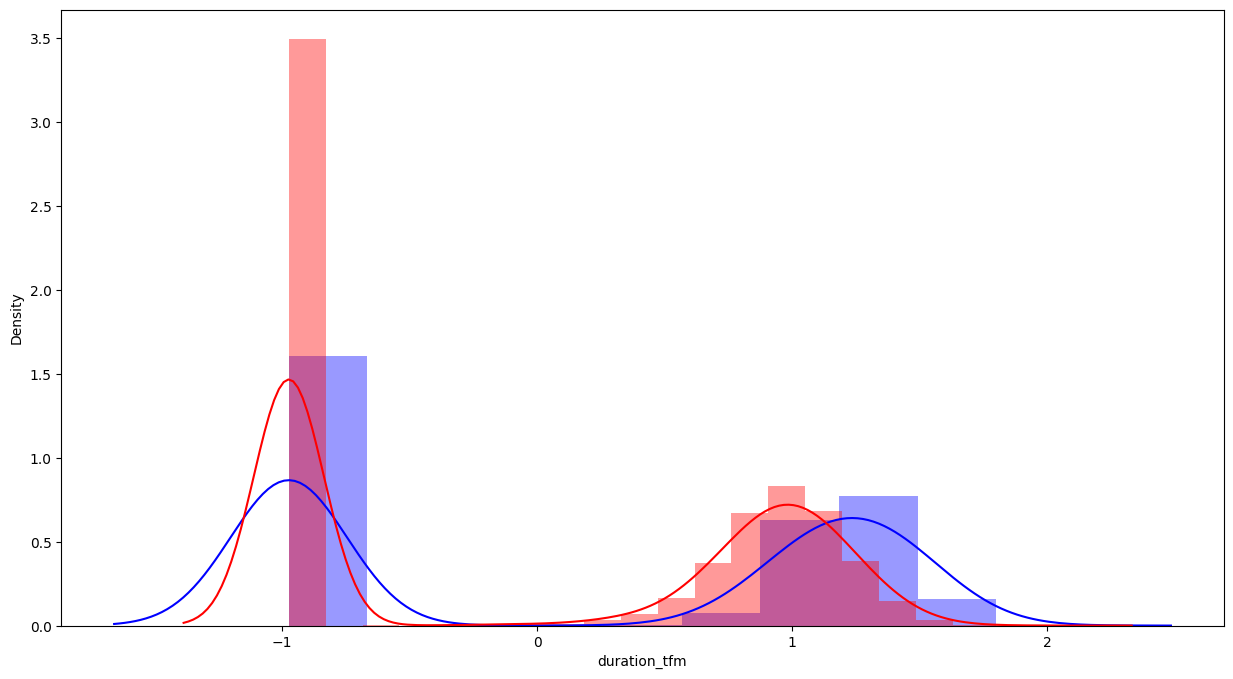

In [19]:
dsitplot_response(num_features_tfm, train_data)

在测试数据上应用缩放器

In [20]:
_,_,test_data = feature_transform(['duration'], test_data, 'pwr')
for c in num_features:
    test_data[c+'_scl'] = std_scaler[c].transform(test_data[[c]]).reshape(-1,1)

在训练数据上拟合序数编码器, 并应用到测试数据

In [21]:
def encoder(dataset, columns):
    # label_encoder = LabelEncoder()
    # dataset['response'] = label_encoder.fit_transform(dataset['y'].to_numpy().reshape(-1,1))
    encoder_models = {}
    new_feature = []
    for c in columns:
        ord_encoder = OrdinalEncoder()
        ord_encoder.fit(dataset[c].to_numpy().reshape(-1,1))
        encoder_models[c]= ord_encoder
        dataset[c+'_int'] = encoder_models[c].transform(dataset[c].to_numpy().reshape(-1,1))
        new_feature.append(c+'_int')
    return encoder_models, new_feature, dataset

encoder_models, int_features, train_data = encoder(train_data, cat_features)
for c in cat_features:
    test_data[c+'_int'] = encoder_models[c].transform(test_data[c].to_numpy().reshape(-1,1))

对训练集和测试集中的目标变量应用标签编码器

In [22]:
label_encoder = LabelEncoder()
train_data['response'] = label_encoder.fit_transform(train_data['y'].to_numpy().reshape(-1,1))
# TODO 2: use LabelEncode() function and transform test_data["response"]
# Edit the code by replacing the underscore
# [A3 修正] 補完 TODO 2：測試集只用訓練集擬合好的 label_encoder 做 transform，不重新 fit（防洩漏）
test_data['response'] = label_encoder.transform(test_data['y'].to_numpy().reshape(-1,1))

在训练数据上拟合独热编码器, 并应用到测试数据

In [23]:
def oh_encoder(dataset, features):
    ohe_models={}
    new_features=[]
    for c in features:
        oh_encoder=OneHotEncoder(handle_unknown='ignore')
        oh_encoder.fit(dataset[c].to_numpy().reshape(-1,1))
        out = oh_encoder.transform(dataset[c].to_numpy().reshape(-1,1))
        df= pd.DataFrame.sparse.from_spmatrix(out, columns=[c+'_'+n for n in oh_encoder.categories_[0]],)
        dataset = pd.concat([dataset,df.set_index(dataset.index)], axis=1)
        ohe_models[c]=oh_encoder
        new_features.extend([c+'_'+n for n in oh_encoder.categories_[0]])
    return ohe_models, new_features, dataset

In [24]:
oh_models, oh_features, train_data = oh_encoder(train_data, cat_features)
for c in cat_features:
    out = oh_models[c].transform(test_data[c].to_numpy().reshape(-1,1))
    df= pd.DataFrame.sparse.from_spmatrix(out, columns=[c+'_'+n for n in oh_models[c].categories_[0]],)
    test_data = pd.concat([test_data,df.set_index(test_data.index)], axis=1)

## 二维可视化
很容易想到用 TSNE 来查看变换后的特征在二维空间中相对于响应值的表现.

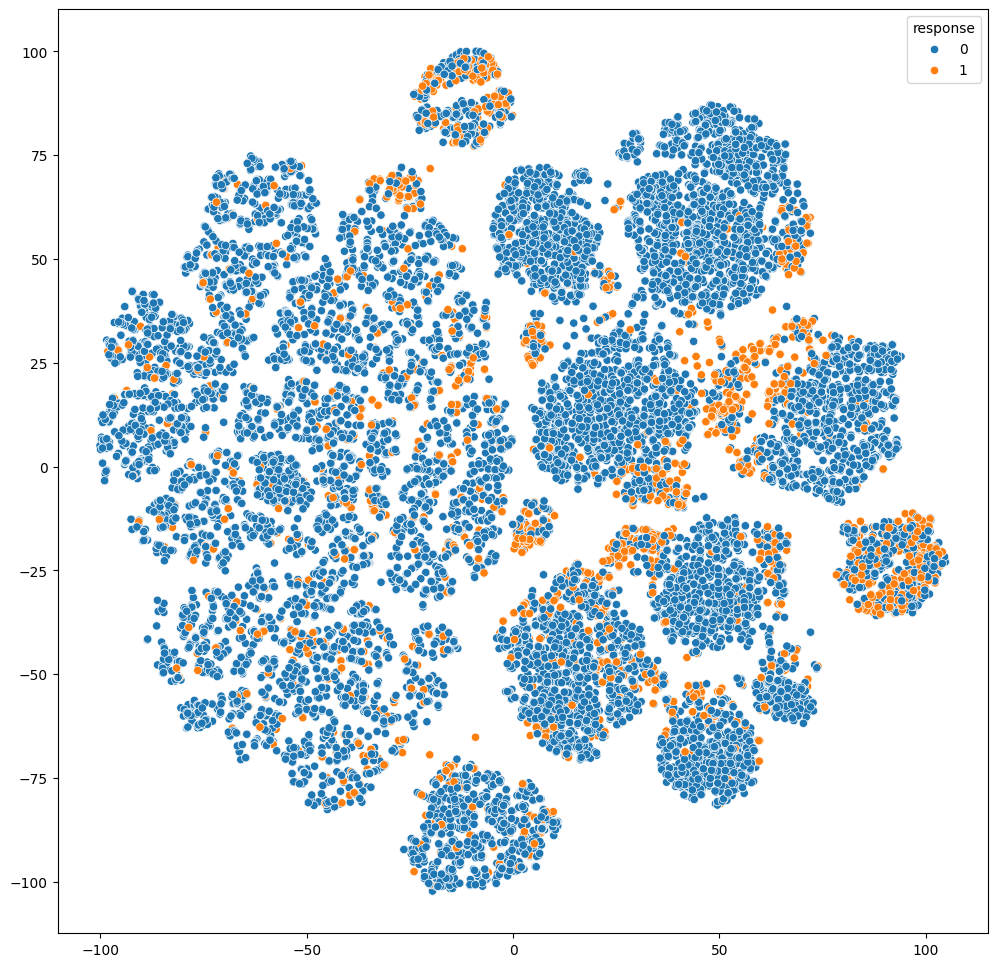

In [25]:
tsne_model = TSNE(n_components=2,random_state=RANDOM_SATE, perplexity=30)
tnse_data = tsne_model.fit_transform(train_data[num_features_scl+
                                                num_features_tfm+
                                                oh_features])
plt.figure(figsize=(12,12))
sns.scatterplot(x=tnse_data[:,0], y=tnse_data[:,1], hue=train_data['response'])
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

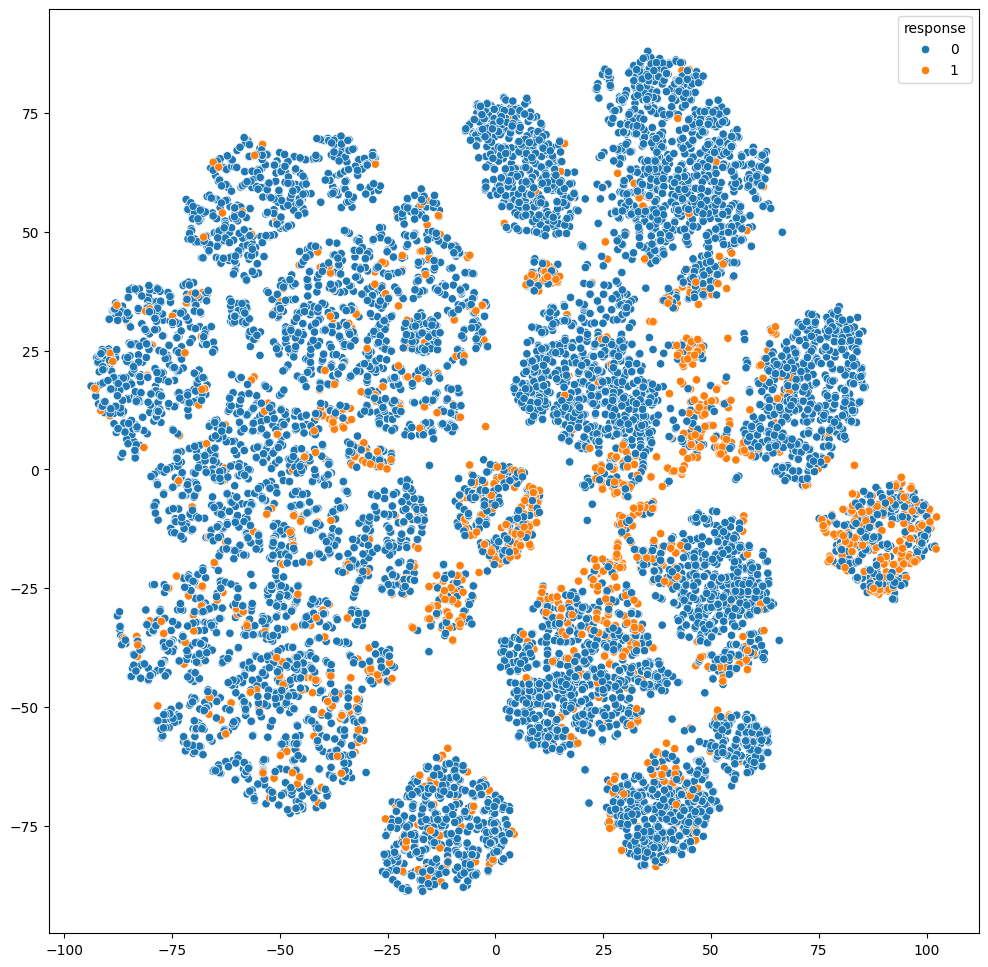

In [26]:
tsne_model = TSNE(n_components=2,random_state=RANDOM_SATE, perplexity=30)
tnse_data = tsne_model.fit_transform(test_data[num_features_scl+
                                                num_features_tfm+
                                                oh_features])
plt.figure(figsize=(12,12))
sns.scatterplot(x=tnse_data[:,0], y=tnse_data[:,1], hue=test_data['response'])
plt.show

In [27]:
# [A3 新增] t-SNE 的輸入規模與成交比例（TODO 2 補完後 test_data['response'] 才存在）
a3_tsne_inputs = num_features_scl + num_features_tfm + oh_features
A3_KPI['part_a']['tsne'] = {
    'train_rows': len(train_data), 'test_rows': len(test_data),
    'n_inputs': len(a3_tsne_inputs), 'n_onehot': len(oh_features),
    'onehot_group_flags': [f for f in oh_features if f.startswith('campaign') or 'Not Applicable' in f],
    'train_pos_pct': a3_r(100 * train_data['response'].mean(), 2),
    'test_pos_pct': a3_r(100 * test_data['response'].mean(), 2),
    'label_classes': [str(c) for c in label_encoder.classes_],
}
# 量化圖上看到的結構：在測試集的 t-SNE 平面上，每個點最近的 10 個鄰居有多少比例與它「同組」（對照 / 目標）、多少比例「同結果」
from sklearn.neighbors import NearestNeighbors
a3_nb = NearestNeighbors(n_neighbors=11).fit(tnse_data).kneighbors(tnse_data, return_distance=False)[:, 1:]
a3_g = (test_data['campaign'] == '1').to_numpy()
a3_y = test_data['response'].to_numpy()
a3_same_g, a3_same_y = (a3_g[a3_nb] == a3_g[:, None]).mean(), (a3_y[a3_nb] == a3_y[:, None]).mean()
a3_base_g = a3_g.mean() ** 2 + (1 - a3_g.mean()) ** 2
a3_base_y = a3_y.mean() ** 2 + (1 - a3_y.mean()) ** 2
A3_KPI['part_a']['tsne'].update({'knn_same_group_pct': a3_r(100 * a3_same_g, 1), 'knn_same_group_random_pct': a3_r(100 * a3_base_g, 1),
                                 'knn_same_outcome_pct': a3_r(100 * a3_same_y, 1), 'knn_same_outcome_random_pct': a3_r(100 * a3_base_y, 1)})
# 官方 cell-23／24 的冪變換分布圖：訓練集 duration 變換前後的偏度
from scipy.stats import skew
A3_KPI['part_a']['tsne'].update({'duration_skew_train': a3_r(skew(train_data['duration']), 2),
                                 'duration_tfm_skew_train': a3_r(skew(train_data['duration_tfm']), 2)})
print(A3_KPI['part_a']['tsne'])
print('10 nearest neighbours on the test-set map: same group %.1f%% (random %.1f%%), same outcome %.1f%% (random %.1f%%)'
      % (100 * a3_same_g, 100 * a3_base_g, 100 * a3_same_y, 100 * a3_base_y))

{'train_rows': 21262, 'test_rows': 14176, 'n_inputs': 71, 'n_onehot': 66, 'onehot_group_flags': ['month_Not Applicable', 'day_of_week_Not Applicable', 'contact_Not Applicable', 'campaign_0', 'campaign_1'], 'train_pos_pct': 12.76, 'test_pos_pct': 13.08, 'label_classes': ['no', 'yes'], 'knn_same_group_pct': 100.0, 'knn_same_group_random_pct': 50.0, 'knn_same_outcome_pct': 82.3, 'knn_same_outcome_random_pct': 77.3, 'duration_skew_train': 3.78, 'duration_tfm_skew_train': 0.12}
10 nearest neighbours on the test-set map: same group 100.0% (random 50.0%), same outcome 82.3% (random 77.3%)


### 解讀：t-SNE 二維圖（訓練集、測試集各一張）

**結論：二維結構主要把「有沒有被打」分開，對「會不會買」只多一點資訊。**

- **輸入**：71 欄 = 4 個標準化數值（含 duration）＋ 1 個冪變換 duration ＋ 66 個獨熱欄，其中 5 個是組別旗標（campaign_0／1，以及 contact、month、day_of_week 的 Not Applicable）。冪變換（官方 cell-23、24 的分布圖）把訓練集 duration 的偏度從 3.78 降到 0.12，但對照組全是 0，變換後仍是一根獨立的柱。
- **量化**：在測試集的平面上，每個點最近的 10 個鄰居有 100.0% 與它同組（隨機 50.0%），但只有 82.3% 與它同樣成交／未成交（隨機 77.3%）。
- **解讀**：不先拿掉組別旗標與 duration，模型學到的大半是組別（呼應 EDA）。
- **注意**：t-SNE 不保留距離與密度，只能看鄰近關係，不能拿來挑客戶；訓練、測試是兩次獨立的嵌入，座標不能互相對照。測試集的冪變換是在測試集上重新擬合的（官方 cell-26）：它對 RF 測試 AUC 的影響約 +0.0004（見模型比較的解讀）；對這張 t-SNE 版面的影響沒有量化。

## 特征选择
### 单变量特征选择:
对类别特征使用以下两种方法进行特征选择, 以选出排名前 10 的显著预测变量:  
- Chi2(卡方检验)
- f_classif

In [28]:
# TODO: Tech Focus Only:
# Add one or two other feature selection methods and present the feature importance

In [29]:
def feature_selection_univariate(features, dataset, method, label,top_k):
    fselect_model = SelectKBest(method,k='all').fit(dataset[features],dataset[label])
    importances = fselect_model.scores_
    indices = np.argsort(importances)[-top_k:]
    selected_features =[features[i] for i in reversed(indices)]
    return fselect_model, selected_features

def plot_feature_importance(fselect_model, features):
    importances = fselect_model.scores_
    p_value = fselect_model.pvalues_
    indices = np.argsort(importances)[-10:]
    plt.figure(figsize=(15,8))
    plt.title('Feature Importances')
    plt.barh(range(len(indices)), importances[indices], color='blue', align='center')
    plt.yticks(range(len(indices)), [features[i] for i in indices])
    plt.xlabel('Relative Importance')
    for i, v in enumerate(indices):
        plt.text(importances[v]+3, i, str(p_value[v]), color='black', fontweight='bold')
    plt.show()

In [30]:
features = int_features + oh_features
fselect_model_f_classif, selected_features_f_classif = feature_selection_univariate(
    features, train_data,f_classif,'response',10)
fselect_model_chi2, selected_features_chi2, = feature_selection_univariate(
    features, train_data,chi2,'response',10)

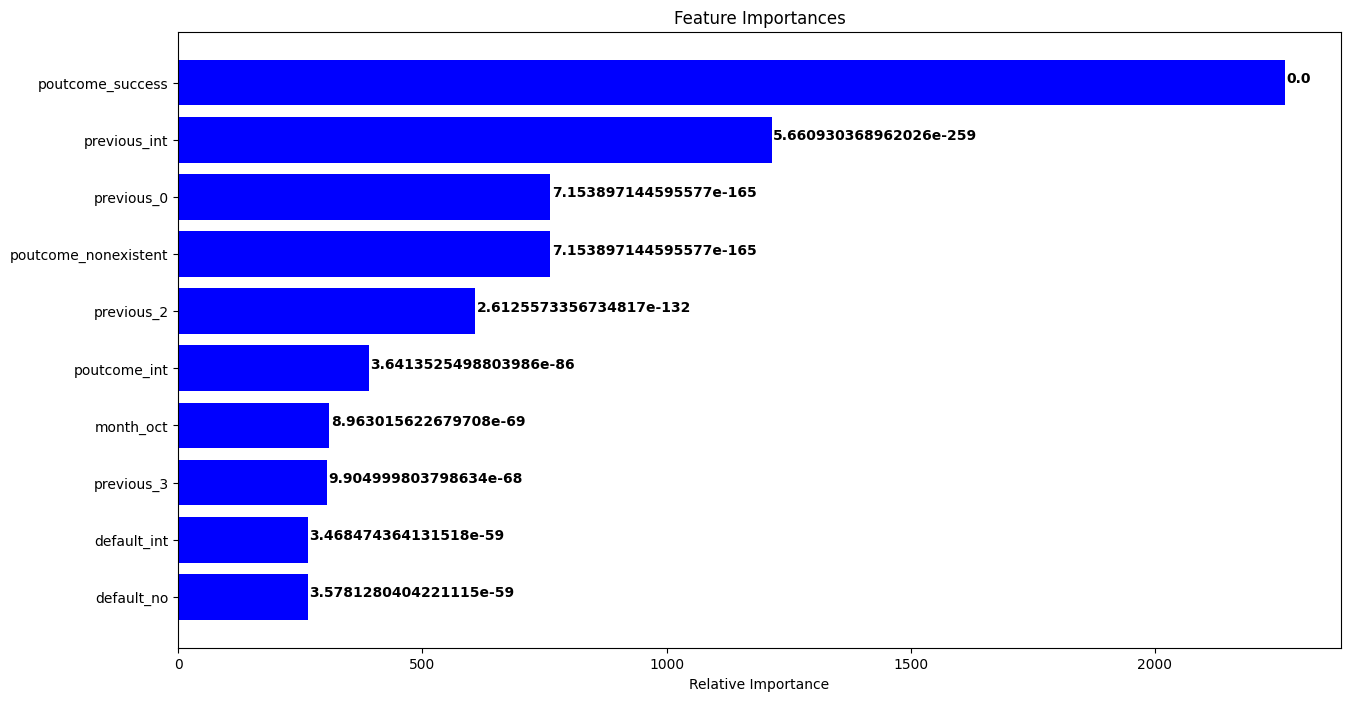

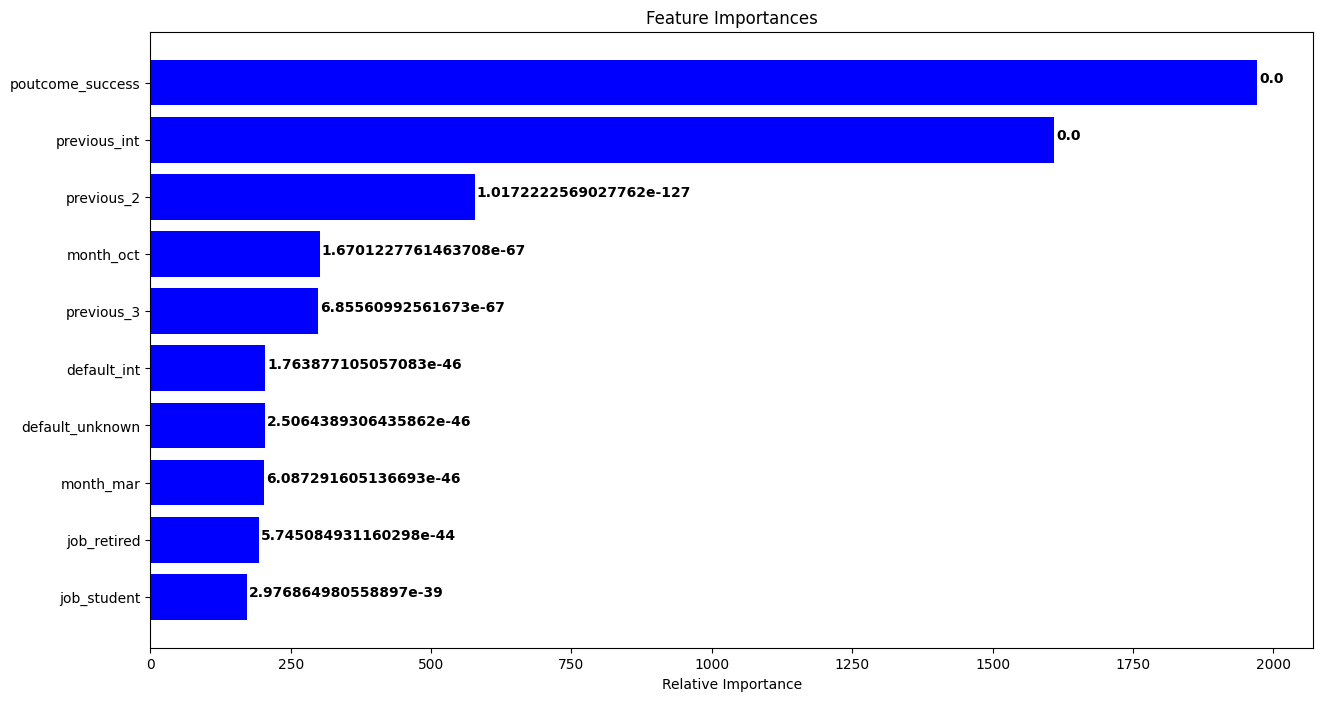

In [31]:
plot_feature_importance(fselect_model_f_classif, features)
plot_feature_importance(fselect_model_chi2, features)

In [32]:
# [A3 新增] 兩種單變量方法選出的前 10 名（上面的圖由下往上排，這裡印成清單並比對重疊）
def a3_tag(f):
    """依「撥號前能不能知道」替特徵貼標籤（商業解讀用）"""
    if f.startswith('duration'):
        return 'post-call (duration)'
    if f.startswith('campaign') or 'Not Applicable' in f:
        return 'group flag (control vs target)'
    if f.startswith(('contact', 'month', 'day_of_week')):
        return 'scheduling (Not Applicable for control)'
    return 'pre-call'

a3_uni = pd.DataFrame({'f_classif top10': selected_features_f_classif, 'chi2 top10': selected_features_chi2})
a3_uni['f_classif tag'] = a3_uni['f_classif top10'].map(a3_tag)
a3_uni['chi2 tag'] = a3_uni['chi2 top10'].map(a3_tag)
print(a3_uni.to_string())
a3_overlap = [f for f in selected_features_f_classif if f in selected_features_chi2]
print('\noverlap (%d):' % len(a3_overlap), a3_overlap)
A3_KPI['part_a']['univariate'] = {
    'f_classif_top10': list(selected_features_f_classif), 'chi2_top10': list(selected_features_chi2),
    'overlap': a3_overlap, 'n_overlap': len(a3_overlap), 'n_features_tested': len(features),
    'f_classif_group_or_post_call': sum(a3_tag(f) != 'pre-call' for f in selected_features_f_classif),
    'chi2_group_or_post_call': sum(a3_tag(f) != 'pre-call' for f in selected_features_chi2),
}

        f_classif top10        chi2 top10                            f_classif tag                                 chi2 tag
0      poutcome_success  poutcome_success                                 pre-call                                 pre-call
1          previous_int      previous_int                                 pre-call                                 pre-call
2            previous_0        previous_2                                 pre-call                                 pre-call
3  poutcome_nonexistent         month_oct                                 pre-call  scheduling (Not Applicable for control)
4            previous_2        previous_3                                 pre-call                                 pre-call
5          poutcome_int       default_int                                 pre-call                                 pre-call
6             month_oct   default_unknown  scheduling (Not Applicable for control)                                 pre-call
7       

### 解讀：單變量特徵選擇（f_classif、chi2）

**結論：兩種方法都把「前次行銷成功」排第一；它是撥號前最強的單一訊號，但也最容易把折扣送給本來就會買的人。**

- **觀察**：在 78 個序數／獨熱欄中，兩種方法的前 10 名重疊 6 個；前幾名都是前次行銷紀錄（poutcome、previous）。chi2 另外選到 job_retired、job_student（EDA 中成交率最高的兩個職業）。f_classif 前 10 名有 1 個是排程變數（month_oct），chi2 有 2 個（month_oct、month_mar）。
- **商業意義**：A2 表 2 註 1 已指出，前次成功者在對照組（沒被打）也有 62.7% 會買（原始全檔）—— 只依接受機率排名單，會把折扣送給本來就會買的人（業務④）。
- **注意**：這兩種方法只比序數／獨熱欄，duration 與數值欄沒有一起比；兩萬列下 p < 0.01 幾乎必然成立，「顯著」不等於「有商業價值」，也看不到欄位之間的交互作用。

可以看出, 这两种方法各自选出的排名前 10 的特征, 都对响应值预测有显著贡献(**p 值小于 0.01**).

### 基于机器学习模型的特征选择
使用能够提供特征重要性的机器学习模型进行特征选择. 同时绘制所选特征之间的相关性图, 以确保特征之间不存在高度相关性. 用于特征选择的模型如下:
- 随机森林分类器(Random Forest Classifier)
- XGBoost 分类器
- 逻辑回归分类器

In [33]:
def feature_selection_model(dataset, features, label, model, k):
    X = np.asarray(dataset[features])
    y = np.asarray(dataset[label])
    if model=='RF':
        clf = RandomForestClassifier(n_estimators=50,
                                     class_weight='balanced',
                                     random_state=RANDOM_SATE,
                                     n_jobs=8)
    elif model=='GB':
        clf = XGBClassifier(n_estimators=50,
                            scale_pos_weight=87,
                            random_state=RANDOM_SATE,
                            n_jobs=8)
    elif model =='LR':
        clf = LogisticRegression(C=1000,
                                 class_weight='balanced',
                                 max_iter=10000,
                                 n_jobs=8)
    else :
        print('please prvide proper model such as RF or GB or LR ')
    rfe = RFE(clf, n_features_to_select=k)
    rfe_model = rfe.fit(X, y)
    feature_list = {}
    for i, v in zip(features, rfe_model.ranking_):
        feature_list[i]=v
    selected_features = {k:v for k,v in feature_list.items() if v<=1}
    # [A3 修正] 回傳 list 而不是 dict：pandas >= 2.1 不准用 dict 當欄位索引，cell-45/47/50 的 train_data[...] 會 TypeError（Colab 也會）
    return list(selected_features)

['duration_tfm', 'age_scl', 'cons.price.idx_scl', 'cons.conf.idx_scl', 'duration_scl', 'job_int', 'education_int', 'poutcome_int', 'month_int', 'poutcome_success']


<Axes: >

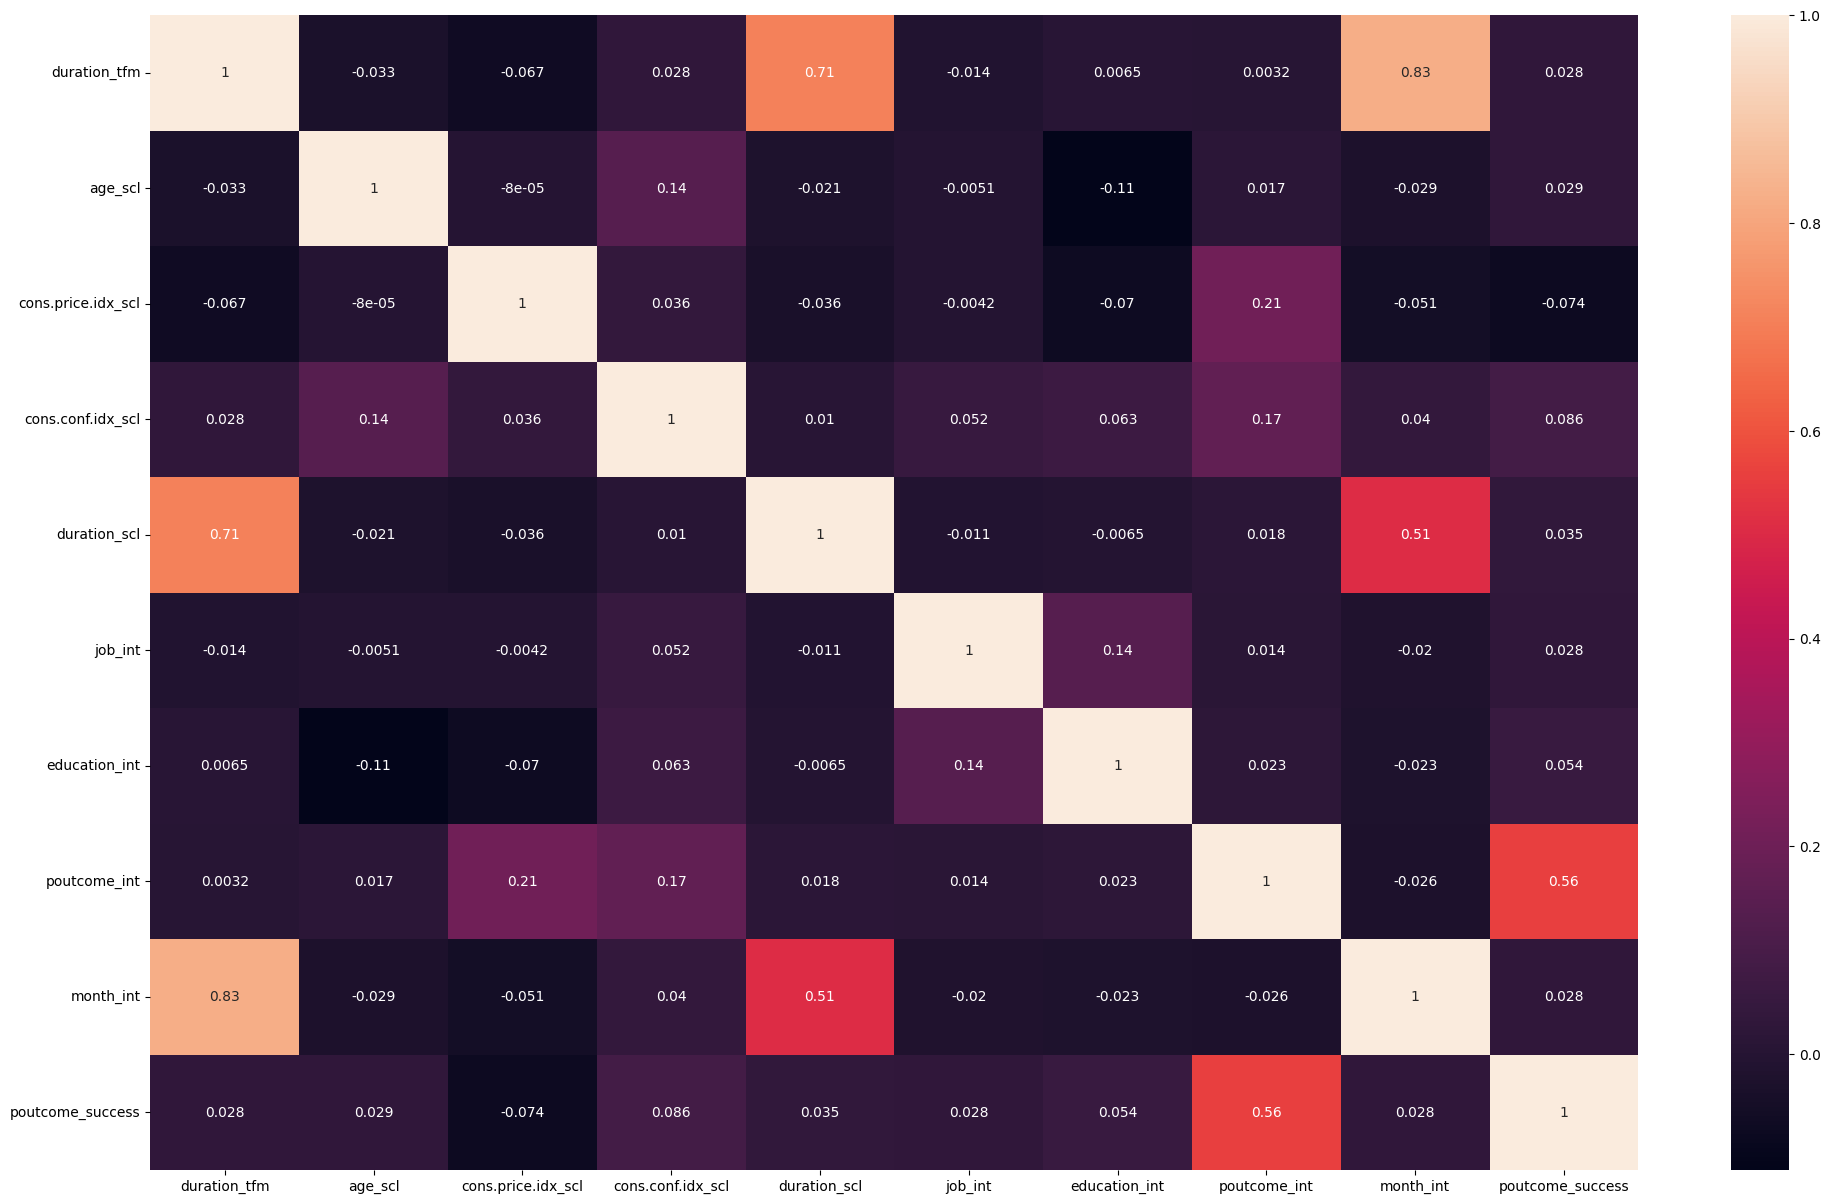

In [34]:
selected_feature_RF = feature_selection_model(dataset=train_data,
                   features=num_features_tfm+num_features_scl+int_features+oh_features,
                   label='response',
                   model='RF',
                   k=10)
print(selected_feature_RF)
plt.figure(figsize=(24,15))
sns.heatmap(train_data[selected_feature_RF].corr(), annot=True)

In [35]:
# TODO 3: run featuer selection using feature_selection_model() and logistic Regresion ('LR')
#[Similar to above code block that used Random Forest ('RF')]
# Edit the code by replacing the underscore

['duration_tfm', 'campaign_int', 'poutcome_success', 'month_mar', 'month_oct', 'month_sep', 'day_of_week_Not Applicable', 'contact_Not Applicable', 'campaign_0', 'campaign_1']


<Axes: >

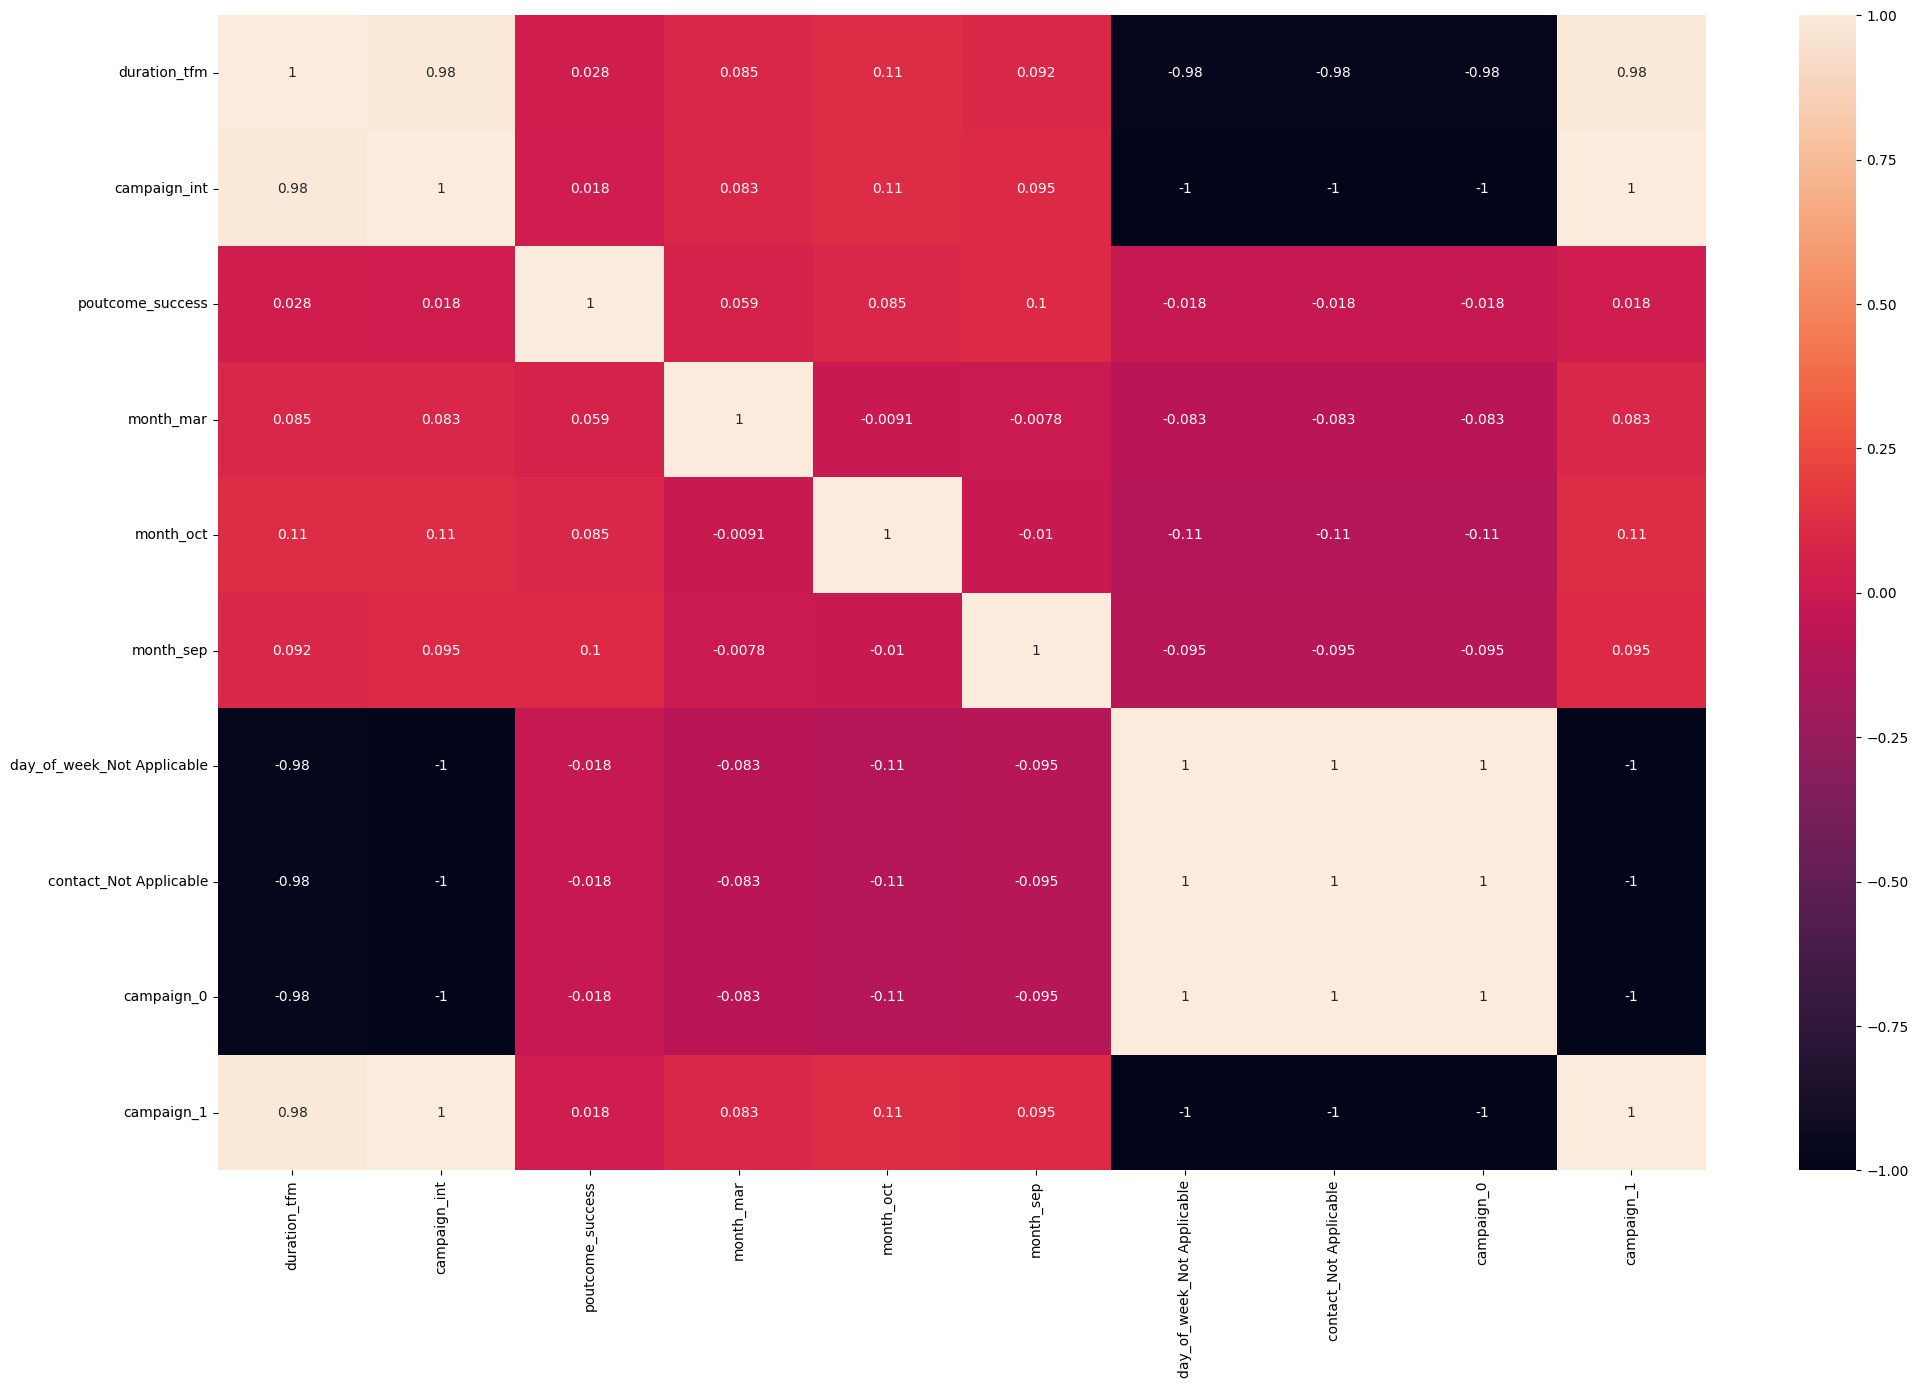

In [36]:
selected_feature_LR = feature_selection_model(dataset=train_data,
                   features=num_features_tfm+num_features_scl+int_features+oh_features,
                   label='response',   # [A3 修正] 補完 TODO 3：與上一格 RF 相同的數值標籤
                   model='LR',         # [A3 修正] 補完 TODO 3：邏輯迴歸
                   k=10)               # [A3 修正] 補完 TODO 3：與 RF 相同選 10 個
print(selected_feature_LR)
plt.figure(figsize=(24,15))
sns.heatmap(train_data[selected_feature_LR].corr(), annot=True)

In [37]:
# [A3 新增] 四種特徵選擇方法的比較表（cell-41 兩種單變量、cell-45 RF-RFE、cell-47 LR-RFE）＋商業標籤
a3_all = sorted(set(selected_features_f_classif) | set(selected_features_chi2) | set(selected_feature_RF) | set(selected_feature_LR))
a3_fs = pd.DataFrame({'feature': a3_all})
for name, lst in [('f_classif', selected_features_f_classif), ('chi2', selected_features_chi2),
                  ('RF-RFE', selected_feature_RF), ('LR-RFE', selected_feature_LR)]:
    a3_fs[name] = a3_fs['feature'].isin(lst).map({True: 'x', False: ''})
a3_fs['n_methods'] = (a3_fs[['f_classif', 'chi2', 'RF-RFE', 'LR-RFE']] == 'x').sum(axis=1)
a3_fs['tag'] = a3_fs['feature'].map(a3_tag)
print(a3_fs.sort_values(['n_methods', 'feature'], ascending=[False, True]).to_string(index=False))
a3_tag_counts = {name: pd.Series([a3_tag(f) for f in lst]).value_counts().to_dict()
                 for name, lst in [('RF-RFE', selected_feature_RF), ('LR-RFE', selected_feature_LR)]}
print('\ntags of the RFE selections:', a3_tag_counts)
A3_TAG_CODE = {'pre-call': 'pre_call', 'post-call (duration)': 'post_call',
               'group flag (control vs target)': 'group_flag', 'scheduling (Not Applicable for control)': 'scheduling'}

# 熱圖（官方 cell-45、47）上的數字：RF 選中欄位兩兩之間最大的 |r|；LR 選中欄位與 response 的相關
def a3_dense(cols):
    return pd.DataFrame(np.asarray(train_data[cols], dtype=float), columns=cols, index=train_data.index)


a3_rf_c = a3_dense(list(selected_feature_RF)).corr()
a3_pairs = a3_rf_c.where(np.triu(np.ones(a3_rf_c.shape, dtype=bool), 1)).stack().abs().sort_values(ascending=False)
print('\nlargest |r| between RF-selected columns:', {'%s ~ %s' % k: round(v, 3) for k, v in a3_pairs.head(3).items()})
a3_lr_cols = list(selected_feature_LR)
a3_lr_resp = a3_dense(a3_lr_cols + ['response']).corr()['response'].drop('response')
print('correlation of each LR-RFE column with response:', a3_lr_resp.round(3).to_dict())
a3_flags = [f for f in a3_lr_cols if a3_tag(f) == 'group flag (control vs target)']
a3_g0 = np.asarray(train_data['campaign_0'], dtype=float)
a3_collinear = {'campaign_0 + campaign_1 = 1': bool(np.all(a3_g0 + np.asarray(train_data['campaign_1'], dtype=float) == 1)),
                'campaign_int = campaign_1': bool(np.all(np.asarray(train_data['campaign_int'], dtype=float) == np.asarray(train_data['campaign_1'], dtype=float)))}
for f in ['contact_Not Applicable', 'month_Not Applicable', 'day_of_week_Not Applicable']:
    a3_collinear[f + ' = campaign_0'] = bool(np.all(np.asarray(train_data[f], dtype=float) == a3_g0))
print('exact collinearity among the group flags:', a3_collinear)
# 用與 RFE 相同設定的 LR（C = 1000、balanced）在這 10 欄上重新擬合，只為了看係數大小（說明 RFE 為什麼留下這些欄位；不影響官方流程）
a3_lr_fit = LogisticRegression(C=1000, class_weight='balanced', max_iter=10000).fit(np.asarray(train_data[a3_lr_cols], dtype=float),
                                                                                     train_data['response'])
a3_lr_coef = pd.Series(a3_lr_fit.coef_[0], index=a3_lr_cols).sort_values(key=abs, ascending=False)
print('LR coefficients on the LR-RFE columns (C = 1000):', a3_lr_coef.round(2).to_dict())

# 對照實驗（各重跑一次與官方 cell-44 相同的 LR-RFE，只改一個條件）：(1) C = 1；(2) 拿掉兩個 duration 欄
a3_fs_cols = num_features_tfm + num_features_scl + int_features + oh_features
def a3_lr_rfe(cols, C):
    r_ = RFE(LogisticRegression(C=C, class_weight='balanced', max_iter=10000), n_features_to_select=10)
    r_.fit(np.asarray(train_data[cols]), np.asarray(train_data['response']))
    return [f for f, s in zip(cols, r_.support_) if s]


a3_lr_c1 = a3_lr_rfe(a3_fs_cols, 1)
a3_lr_nodur = a3_lr_rfe([f for f in a3_fs_cols if not f.startswith('duration')], 1000)
a3_ctl = pd.DataFrame({'official (C = 1000)': pd.Series([a3_tag(f) for f in a3_lr_cols]).value_counts(),
                       'control 1: C = 1': pd.Series([a3_tag(f) for f in a3_lr_c1]).value_counts(),
                       'control 2: no duration columns': pd.Series([a3_tag(f) for f in a3_lr_nodur]).value_counts()}).fillna(0).astype(int)
print('\nLR-RFE control runs: tags of the 10 selected columns')
print(a3_ctl.to_string())
print('control 1 selects the same columns as the official run:', sorted(a3_lr_c1) == sorted(a3_lr_cols))
print('control 2 selection:', a3_lr_nodur)
a3_dtfm_c = train_data.loc[train_data['campaign'] == '0', 'duration_tfm']
print('duration_tfm in the control group: one constant value %.3f (target group minimum %.3f)'
      % (a3_dtfm_c.iloc[0], train_data.loc[train_data['campaign'] == '1', 'duration_tfm'].min()))

A3_KPI['part_a']['model_fs'] = {
    'rf_rfe': list(selected_feature_RF), 'lr_rfe': list(selected_feature_LR),
    'rf_lr_overlap': [f for f in selected_feature_RF if f in selected_feature_LR],
    'tag_counts': {k.replace('-', '_'): {A3_TAG_CODE[t]: int(n) for t, n in v.items()} for k, v in a3_tag_counts.items()},
    'in_all_four': a3_fs.loc[a3_fs['n_methods'] == 4, 'feature'].tolist(),
    'rf_max_pair_text': '%s 與 %s 的 |r| = %.3f' % (a3_pairs.index[0][0], a3_pairs.index[0][1], a3_pairs.iloc[0]),
    'rf_max_pair_abs_r': a3_r(a3_pairs.iloc[0], 3),
    'rf_dur_pair_abs_r': a3_r(abs(a3_rf_c.loc['duration_tfm', 'duration_scl']), 3)
    if {'duration_tfm', 'duration_scl'} <= set(a3_rf_c.columns) else None,
    'lr_flags': a3_flags,
    'lr_flag_max_abs_corr_with_response': a3_r(a3_lr_resp[a3_flags].abs().max(), 3) if a3_flags else None,
    'collinear': a3_collinear,
    'lr_coef_top_text': '、'.join('%s %+.2f' % (k, v) for k, v in a3_lr_coef.head(6).items()),
    'lr_flag_coef_abs_max': a3_r(a3_lr_coef[a3_flags].abs().max(), 2) if a3_flags else None,
    'lr_ctl_c1_same': sorted(a3_lr_c1) == sorted(a3_lr_cols),
    'lr_ctl_c1_flags': sum(a3_tag(f) == 'group flag (control vs target)' for f in a3_lr_c1),
    'lr_ctl_nodur_flags': sum(a3_tag(f) == 'group flag (control vs target)' for f in a3_lr_nodur),
    'lr_ctl_nodur_tags': {A3_TAG_CODE[t]: int(n) for t, n in pd.Series([a3_tag(f) for f in a3_lr_nodur]).value_counts().items()},
    'lr_ctl_nodur': a3_lr_nodur,
    'control_duration_tfm': a3_r(a3_dtfm_c.iloc[0], 3), 'control_duration_tfm_constant': bool(a3_dtfm_c.nunique() == 1),
    'target_duration_tfm_min': a3_r(train_data.loc[train_data['campaign'] == '1', 'duration_tfm'].min(), 3),
}

                   feature f_classif chi2 RF-RFE LR-RFE  n_methods                                     tag
          poutcome_success         x    x      x      x          4                                pre-call
                 month_oct         x    x             x          3 scheduling (Not Applicable for control)
               default_int         x    x                        2                                pre-call
              duration_tfm                     x      x          2                    post-call (duration)
                 month_mar              x             x          2 scheduling (Not Applicable for control)
              poutcome_int         x           x                 2                                pre-call
                previous_2         x    x                        2                                pre-call
                previous_3         x    x                        2                                pre-call
              previous_int         x 


largest |r| between RF-selected columns: {'duration_tfm ~ month_int': 0.826, 'duration_tfm ~ duration_scl': 0.707, 'poutcome_int ~ poutcome_success': 0.557}
correlation of each LR-RFE column with response: {'duration_tfm': 0.052, 'campaign_int': 0.006, 'poutcome_success': 0.31, 'month_mar': 0.098, 'month_oct': 0.12, 'month_sep': 0.089, 'day_of_week_Not Applicable': -0.006, 'contact_Not Applicable': -0.006, 'campaign_0': -0.006, 'campaign_1': 0.006}
exact collinearity among the group flags: {'campaign_0 + campaign_1 = 1': True, 'campaign_int = campaign_1': True, 'contact_Not Applicable = campaign_0': True, 'month_Not Applicable = campaign_0': True, 'day_of_week_Not Applicable = campaign_0': True}
LR coefficients on the LR-RFE columns (C = 1000): {'duration_tfm': 5.99, 'campaign_1': -3.09, 'campaign_int': -3.09, 'poutcome_success': 2.83, 'month_oct': 2.71, 'month_mar': 2.7, 'campaign_0': 2.18, 'contact_Not Applicable': 2.18, 'day_of_week_Not Applicable': 2.18, 'month_sep': 1.94}



LR-RFE control runs: tags of the 10 selected columns
                                         official (C = 1000)  control 1: C = 1  control 2: no duration columns
group flag (control vs target)                             5                 5                               0
post-call (duration)                                       1                 1                               0
pre-call                                                   1                 1                               3
scheduling (Not Applicable for control)                    3                 3                               7
control 1 selects the same columns as the official run: True
control 2 selection: ['poutcome_success', 'previous_0', 'previous_1', 'month_aug', 'month_jul', 'month_mar', 'month_may', 'month_nov', 'month_oct', 'contact_cellular']
duration_tfm in the control group: one constant value -0.973 (target group minimum -0.668)


### 解讀：模型式特徵選擇（RF 與 LR 的 RFE）

**結論：RF 的 RFE 以撥號前欄位為主，但含兩個 duration；LR 的 RFE 留下一組完全共線、與成交幾乎無關的組別旗標。對照實驗顯示，這些旗標是被 duration 的洩漏帶進來的：不是 C = 1000 造成的，也不是 LR 學到了「先排除對照組」。**

- **RF 的 RFE**：10 欄 = 7 欄撥號前可得、2 欄 duration（冪變換與標準化兩種版本）、1 欄月份。熱圖上相關最高的一對是 duration_tfm 與 month_int 的 |r| = 0.826：對照組的 duration 都是 0、月份都是 Not Applicable，兩欄都帶著「是不是對照組」的資訊；duration_tfm 與 duration_scl 是同一欄的兩種轉換（|r| = 0.707），RFE 也照樣兩個都留下。官方說熱圖是為了「確保特徵之間不存在高度相關」，但選完並沒有處理。
- **LR 的 RFE（TODO 3）**：5 欄組別旗標、3 欄月份、1 欄 duration，撥號前的客戶欄位只有 1 欄（poutcome_success）。這些旗標與 response 的相關最大只有 0.006（去重後兩組轉換率只差 0.3 個百分點），而且彼此完全共線：campaign_0 = 1 − campaign_1、campaign_int = campaign_1，contact 與 day_of_week 的 Not Applicable 就是 campaign_0。
- **為什麼會被留下（兩個對照實驗）**：用與 RFE 相同的設定在這 10 欄上重新擬合，係數絕對值最大的是 duration_tfm +5.99、campaign_1 -3.09、campaign_int -3.09、poutcome_success +2.83、month_oct +2.71、month_mar +2.70。對照組的 duration_tfm 全部是同一個值 -0.973（目標組最低也有 -0.668）：線性模型用 duration 描述「講越久越會買」時，會把對照組預測成幾乎不買，但對照組的實際轉換率和目標組差不多，旗標就被用來把對照組的預測拉回來。(1) 把 C 從 1000 改成 1，選出的 10 欄完全相同 —— 不是正則化太弱造成的；(2) 拿掉兩個 duration 欄（C 仍為 1000），組別旗標從 5 個變成 0 個，改選 7 個月份／管道欄與 3 個撥號前欄位。旗標彼此完全共線，所以留下哪一個不穩定，但「留下旗標」本身是 duration 洩漏的副產品。四種方法都選到的只有 poutcome_success。
- **商業意義**：上線版必須先拿掉 duration、campaign 與排程欄（撥號前不可用），Part B 的撥號前模型就是這樣建的。
- **注意**：LR 的 RFE 吃的是未標準化的序數碼與獨熱欄混合，數值收斂可能隨套件版本略有不同，所以這裡用標籤計數描述。

In [38]:
# TODO: Tech Focus Only:
# Evaluate the selected features from previous methods (univariate and model selected) and propose which
# features should be used in traning.

假设由随机森林(RF)选出的特征能提供更好的结果. 因此我们使用这些选定特征进行建模, 并在测试数据上比较结果. 使用 RF 和 XGB 进行建模, 是因为它们都能够处理复杂的模式. 此外, 它们还具有类别不平衡加权机制, 可以很好地处理不平衡问题.

In [39]:
def modeling(train_data, test_data, selected_faeture):
    rf_parameters = {'max_depth':[5],
                     'criterion':['gini'] ,
                     'n_estimators':[100]}
    gb_parameters = {'learning_rate':[0.01],
                     'n_estimators':[100],
                     'max_depth':[5],
                     'colsample_bytree':[0.1],
                     'subsample':[0.1]}

    rf = RandomForestClassifier(random_state=RANDOM_SATE,
                                n_jobs=8,
                                class_weight='balanced')

    gb = XGBClassifier(random_state=RANDOM_SATE,
                       n_jobs=8,
                       scale_pos_weight=87)

    clf_rf = GridSearchCV(estimator=rf,
                          param_grid=rf_parameters,
                          scoring='roc_auc',
                          n_jobs=8,
                          verbose=10,
                          cv=5)
    clf_gb = RandomizedSearchCV(estimator=gb,
                                param_distributions=gb_parameters,
                                scoring='roc_auc',
                                n_iter=20,
                                n_jobs=8,
                                verbose=10,
                                cv=5)

    model_rf = clf_rf.fit(train_data[selected_faeture], train_data['response'])
    model_gb = clf_gb.fit(train_data[selected_faeture], train_data['response'])

    auc_score={}
    auc_score['rf'] = roc_auc_score(test_data['response'], model_rf.best_estimator_.predict(test_data[selected_faeture]))
    auc_score['gb'] = roc_auc_score(test_data['response'], model_gb.best_estimator_.predict(test_data[selected_faeture]))
    return model_rf, model_gb, auc_score

In [40]:
rf, gb, auc_score = modeling(train_data, test_data, selected_feature_RF)
auc_score

Fitting 5 folds for each of 1 candidates, totalling 5 fits


Fitting 5 folds for each of 1 candidates, totalling 5 fits


{'rf': np.float64(0.7359283357907652), 'gb': np.float64(0.5)}

In [41]:
# [A3 新增] cell-50 用 .predict() 的 0/1 標籤算 AUC，那衡量不到「排序」能力；這裡用 predict_proba 重算（只讀 rf、gb，不重新訓練）
a3_Xte = test_data[selected_feature_RF]
a3_auc_rf = roc_auc_score(test_data['response'], rf.best_estimator_.predict_proba(a3_Xte)[:, 1])
a3_auc_gb = roc_auc_score(test_data['response'], gb.best_estimator_.predict_proba(a3_Xte)[:, 1])
a3_ratio = (train_data['response'] == 0).sum() / (train_data['response'] == 1).sum()
a3_gb_pos = (gb.best_estimator_.predict(a3_Xte) == 1).mean()
a3_rf_pos = (rf.best_estimator_.predict(a3_Xte) == 1).mean()
print(pd.DataFrame({
    'official (predict labels)': [auc_score['rf'], auc_score['gb']],
    'predict_proba AUC (test)': [a3_auc_rf, a3_auc_gb],
    '5-fold CV AUC (train)': [rf.best_score_, gb.best_score_],
    'share predicted "yes" (test)': [a3_rf_pos, a3_gb_pos]}, index=['RF', 'XGB']).round(4))
print('\nnegative / positive ratio in the deduplicated training data: %.2f (XGB uses scale_pos_weight = 87)' % a3_ratio)

# cell-26 在測試集上重新擬合冪變換（power_transform 每次呼叫都重新 fit）：比較 λ，並量它對 RF 測試 AUC 的影響
a3_pt_train = PowerTransformer().fit(train_data[['duration']])
a3_pt_test = PowerTransformer().fit(test_data[['duration']])
a3_auc_rf_fix = None
if 'duration_tfm' in a3_Xte.columns:
    a3_Xte_fix = a3_Xte.copy()
    a3_Xte_fix['duration_tfm'] = a3_pt_train.transform(test_data[['duration']]).ravel()   # 正確做法：用訓練集擬合的轉換器
    a3_auc_rf_fix = roc_auc_score(test_data['response'], rf.best_estimator_.predict_proba(a3_Xte_fix)[:, 1])
print('Yeo-Johnson lambda fitted on train %.4f vs on test %.4f' % (a3_pt_train.lambdas_[0], a3_pt_test.lambdas_[0]))
print('RF test AUC with the train-fitted transform %.4f vs as run (test-fitted) %.4f: train-fitted minus as-run = %+.5f'
      % (a3_auc_rf_fix or float('nan'), a3_auc_rf, (a3_auc_rf_fix or float('nan')) - a3_auc_rf))

A3_KPI['part_a']['model_compare'] = {
    'official_predict_auc': {'rf': a3_r(auc_score['rf']), 'gb': a3_r(auc_score['gb'])},
    'proba_auc_test': {'rf': a3_r(a3_auc_rf), 'gb': a3_r(a3_auc_gb)},
    'cv_auc_train': {'rf': a3_r(rf.best_score_), 'gb': a3_r(gb.best_score_)},
    'share_predicted_yes': {'rf': a3_r(a3_rf_pos), 'gb': a3_r(a3_gb_pos)},
    'share_predicted_yes_pct': {'rf': a3_r(100 * a3_rf_pos, 1), 'gb': a3_r(100 * a3_gb_pos, 1)},
    'proba_gap_rf_minus_gb': a3_r(a3_auc_rf - a3_auc_gb),
    'neg_pos_ratio_train': a3_r(a3_ratio, 2), 'scale_pos_weight_used': 87,
    'lambda_train': a3_r(a3_pt_train.lambdas_[0]), 'lambda_test': a3_r(a3_pt_test.lambdas_[0]),
    'rf_auc_train_fitted_transform': None if a3_auc_rf_fix is None else a3_r(a3_auc_rf_fix),
    'rf_auc_trainfit_minus_asrun': None if a3_auc_rf_fix is None else a3_r(a3_auc_rf_fix - a3_auc_rf, 5),
    'rf_cv_sd': a3_r(rf.cv_results_['std_test_score'][rf.best_index_]),
    'features': list(selected_feature_RF),
}

     official (predict labels)  predict_proba AUC (test)  \
RF                      0.7359                    0.8426   
XGB                     0.5000                    0.8355   

     5-fold CV AUC (train)  share predicted "yes" (test)  
RF                  0.8298                        0.1718  
XGB                 0.8238                        1.0000  

negative / positive ratio in the deduplicated training data: 6.84 (XGB uses scale_pos_weight = 87)
Yeo-Johnson lambda fitted on train -0.0703 vs on test -0.0621
RF test AUC with the train-fitted transform 0.8430 vs as run (test-fitted) 0.8426: train-fitted minus as-run = +0.00043


In [42]:
# [A3 新增] 純診斷：官方 cell-50 的 XGB 只改一兩個參數重跑，檢查官方 cell-53「RF 優於 XGB」是否成立（官方 rf、gb 物件都不動）
# 同樣 10 欄（RF 選的）、同樣 5 折 CV（cv=5）、同樣的測試集；XGB 用 n_jobs=1 讓結果可重現
from sklearn.model_selection import cross_val_score
a3_xgb_base = dict(learning_rate=0.01, n_estimators=100, max_depth=5, colsample_bytree=0.1, subsample=0.1,
                   random_state=RANDOM_SATE, n_jobs=1)
a3_xgb_cfg = [('official: scale_pos_weight = 87', dict(scale_pos_weight=87)),
              ('scale_pos_weight = %.2f (actual neg/pos)' % a3_ratio, dict(scale_pos_weight=a3_ratio)),
              ('scale_pos_weight = 87, subsample = colsample = 1.0', dict(scale_pos_weight=87, subsample=1.0, colsample_bytree=1.0)),
              ('scale_pos_weight = 87, learning_rate = 0.1', dict(scale_pos_weight=87, learning_rate=0.1))]
a3_Xtr = train_data[selected_feature_RF]
a3_rows = [{'model': 'RF (official cell-50, as run)', 'cv_auc': rf.best_score_, 'cv_sd': rf.cv_results_['std_test_score'][rf.best_index_],
            'test_auc_proba': a3_auc_rf, 'share_pred_yes_pct': 100 * a3_rf_pos, 'test_auc_labels': auc_score['rf']}]
for a3_name, a3_kw in a3_xgb_cfg:
    a3_m = XGBClassifier(**{**a3_xgb_base, **a3_kw})
    a3_cv = cross_val_score(a3_m, a3_Xtr, train_data['response'], cv=5, scoring='roc_auc')
    a3_m.fit(a3_Xtr, train_data['response'])
    a3_lab = a3_m.predict(a3_Xte)
    a3_rows.append({'model': 'XGB ' + a3_name, 'cv_auc': a3_cv.mean(), 'cv_sd': a3_cv.std(),
                    'test_auc_proba': roc_auc_score(test_data['response'], a3_m.predict_proba(a3_Xte)[:, 1]),
                    'share_pred_yes_pct': 100 * (a3_lab == 1).mean(), 'test_auc_labels': roc_auc_score(test_data['response'], a3_lab)})
a3_xgb = pd.DataFrame(a3_rows).set_index('model')
print(a3_xgb.round(4).to_string())
a3_fixd = a3_xgb.iloc[2]
print('\nXGB with the actual ratio minus RF: CV %+.4f, test %+.4f (RF CV fold sd %.4f)'
      % (a3_fixd['cv_auc'] - rf.best_score_, a3_fixd['test_auc_proba'] - a3_auc_rf, a3_rows[0]['cv_sd']))
print('official XGB settings re-run here with n_jobs = 1: CV %.4f; the official object (n_jobs = 8) reported %.4f'
      % (a3_xgb.iloc[1]['cv_auc'], gb.best_score_))
A3_KPI['part_a']['xgb_diag'] = {
    'rows': [{'model': k, **{c: a3_r(v) for c, v in r.items()}} for k, r in a3_xgb.iterrows()],
    'official_cv_reproduced': bool(abs(a3_xgb.iloc[1]['cv_auc'] - gb.best_score_) < 1e-6),
    'ratio': a3_r(a3_ratio, 2),
    'fixed_cv_auc': a3_r(a3_fixd['cv_auc']), 'fixed_cv_sd': a3_r(a3_fixd['cv_sd']),
    'fixed_test_auc': a3_r(a3_fixd['test_auc_proba']), 'fixed_label_auc': a3_r(a3_fixd['test_auc_labels']),
    'fixed_share_yes_pct': a3_r(a3_fixd['share_pred_yes_pct'], 1),
    'official_share_yes_pct': a3_r(a3_xgb.iloc[1]['share_pred_yes_pct'], 1),
    'subcol1_share_yes_pct': a3_r(a3_xgb.iloc[3]['share_pred_yes_pct'], 1),
    'lr01_share_yes_pct': a3_r(a3_xgb.iloc[4]['share_pred_yes_pct'], 1),
    'xgb_minus_rf_cv': a3_r(a3_fixd['cv_auc'] - rf.best_score_), 'xgb_minus_rf_test': a3_r(a3_fixd['test_auc_proba'] - a3_auc_rf),
}

                                                        cv_auc   cv_sd  test_auc_proba  share_pred_yes_pct  test_auc_labels
model                                                                                                                      
RF (official cell-50, as run)                           0.8298  0.0092          0.8426             17.1840           0.7359
XGB official: scale_pos_weight = 87                     0.8231  0.0093          0.8367            100.0000           0.5000
XGB scale_pos_weight = 6.84 (actual neg/pos)            0.8518  0.0036          0.8618             22.1642           0.7886
XGB scale_pos_weight = 87, subsample = colsample = 1.0  0.8362  0.0084          0.8458             94.9986           0.5285
XGB scale_pos_weight = 87, learning_rate = 0.1          0.8417  0.0090          0.8564             81.6450           0.6043

XGB with the actual ratio minus RF: CV +0.0220, test +0.0192 (RF CV fold sd 0.0092)
official XGB settings re-run here with n_jobs =

### 解讀：模型比較（RF vs XGB）與上方診斷

**結論：官方「RF 優於 XGB」的比較不成立 —— 把 XGB 的 scale_pos_weight 改成實際比例後，XGB 的 CV 與測試 AUC 都比 RF 高。最終 pipeline 用 RF，是沿用官方流程，不是這次比較的結果。**

- **口徑**：官方 `modeling()`（cell-50、51）用 `.predict()` 的 0／1 標籤算 AUC，得到 RF 0.7359、XGB 0.5000；改用 `predict_proba`，測試 AUC 是 RF 0.8426、XGB 0.8355，訓練集 5 折 CV 是 0.8298 對 0.8238。
- **純診斷（只改 XGB 參數，官方物件不動）**：scale_pos_weight 由 87 改成去重訓練集的實際負／正比 6.84，XGB 的 CV AUC 0.8518（RF 0.8298，高 0.0220，RF 折間標準差 0.0092）、測試 AUC 0.8618（RF 0.8426）；預測「會買」的比例由 100.0% 降到 22.2%。
- **XGB 的 0.5 怎麼來的**：主因是 scale_pos_weight = 87（實際只有 6.84）加上學習率 0.01 × 100 棵樹 —— 模型離不開加權後的先驗，100.0% 的人都被預測成「會買」，0／1 標籤的 AUC 必然是 0.5。subsample、colsample_bytree 只有 0.1 不是主因：兩者改成 1.0 時仍有 95.0% 被預測成會買；學習率改 0.1 則降到 81.6%。
- **用測試集選模**：官方 cell-53 依測試集下結論，同一份測試集之後又報最終 AUC，所以最終 AUC 只能當樂觀估計（A2 表 4 的 ML① 本來就定為「只當樂觀參考」）。A2 表 7 把 XGB 定為挑戰者、勝出幅度大於種子間波動才替換；Part B 的撥號前模型照這條規則只在訓練資料上重比（B-1），並對勝出的 XGB 做完整的十條評估（B-11）。
- **官方 cell-26 在測試集上重新擬合冪變換**：λ 訓練 -0.0703、測試 -0.0621。它影響測試集的 t-SNE（cell-36）與 cell-50／51 的測試 AUC：改用訓練集擬合的轉換器，RF 測試 AUC 為 0.8430（比原值高 0.0004，可忽略）。兩種 RFE 只用訓練集、最終 pipeline 在 cell-56 重新切分，都不受影響。

In [43]:
# TODO: Tech Focus Only:
# Add more hyperparameters to above models and iterate to see how the models behaviour
# and select the btter model.

从上面可以看出, RF 的表现优于 XGB. 因此我们在最终流程中采用 RF 模型以及由 RF 选出的特征集.

## 最终流程
借助 sklearn 的 pipeline, 将所有数据预处理和建模步骤整合到一个流程中. 该流程包括:
- 幂变换
- 标准缩放
- 独热编码
- 递归特征消除
- 通过交叉验证进行随机森林训练

In [44]:
cat_features=['job', 'marital', 'education', 'default', 'housing','loan',
              'poutcome','previous','month','day_of_week','contact','campaign']
num_features=['age','cons.price.idx', 'cons.conf.idx','duration']

In [45]:
df_data = campaign_data.copy(deep=True)
train_data, test_data = train_test_split(df_data, test_size=0.4, random_state=RANDOM_SATE)

*** 这可能需要一些时间 ***

In [46]:
from sklearn.compose import ColumnTransformer
num_transformer = Pipeline(steps=[('power',PowerTransformer())])
num_scaler = Pipeline(steps=[('scaler', StandardScaler())])
cat_encoder = Pipeline(steps=[('order', OrdinalEncoder()),
                              ('ohe',OneHotEncoder(handle_unknown='ignore'))])
prep = ColumnTransformer(
            transformers=[('dur', num_transformer,['duration']),
                          ('scaler',num_scaler,['age','cons.price.idx', 'cons.conf.idx','duration']),
                          ('encoder',cat_encoder, cat_features)
                         ]
                        )

clf = RandomForestClassifier(n_estimators=50,
                             class_weight='balanced',
                             random_state=123,
                             n_jobs=8)
rfe = RFE(clf,n_features_to_select=10)

# TODO: add more hyper parameter valus for max_depth and n_estimators
# Edit the code by replacing the underscore

# [A3 修正] 補完超參數：max_depth 第三值 9、n_estimators 第三值 300（理由見最終 pipeline 之後的解讀，依本次 CV 結果）
rf_parameters = {'max_depth':[3,5,9],
                 'criterion':['gini', 'entropy'] ,
                 'n_estimators':[100,200,300]
                }
rf = RandomForestClassifier(class_weight='balanced',
                            random_state=RANDOM_SATE,
                            n_jobs=8)
clf_cv = GridSearchCV(estimator=rf,
                      param_grid=rf_parameters,
                      scoring='roc_auc',
                      n_jobs=8,
                      verbose=10,
                      cv=5)

pipe= Pipeline(steps=[('prep',prep),
                      ('rfe' ,rfe),
                      ('clf' ,clf_cv)
                     ])

ml_pipe = pipe.fit(X=train_data, y=train_data['y'])

Fitting 5 folds for each of 18 candidates, totalling 90 fits


In [47]:
dump(ml_pipe, 'ml_pipe.joblib')
print("AUC of model on Traning Data: "+ str(ml_pipe.score(X=train_data, y=train_data['y'])))
print("AUC of model on Test Data: "+ str(ml_pipe.score(X=test_data,   y=test_data['y'])))

AUC of model on Traning Data: 0.8951253985481319
AUC of model on Test Data: 0.8714757477657681


In [48]:
# [A3 新增] 最終 pipeline 的補充診斷：只用 predict_proba / transform，不對 ml_pipe、prep、rfe、clf_cv 呼叫 fit
from sklearn.model_selection import cross_val_score
a3_gs = ml_pipe.named_steps['clf']
a3_cvres = pd.DataFrame(a3_gs.cv_results_)[['param_criterion', 'param_max_depth', 'param_n_estimators',
                                             'mean_test_score', 'std_test_score', 'rank_test_score']]
print('[1] 5-fold CV AUC of the 18 grid settings (cell-58), best first')
print(a3_cvres.sort_values('rank_test_score').round(4).to_string(index=False))
a3_best = a3_gs.best_params_
a3_by_depth = a3_cvres.groupby('param_max_depth')['mean_test_score'].max()
a3_by_nest = a3_cvres[(a3_cvres['param_criterion'] == a3_best['criterion']) &
                      (a3_cvres['param_max_depth'] == a3_best['max_depth'])].set_index('param_n_estimators')['mean_test_score']
print('\nbest CV AUC by max_depth:', a3_by_depth.round(4).to_dict())
print('CV AUC by n_estimators at the best criterion/depth:', a3_by_nest.round(4).to_dict())

# [2] 9 在網格邊界：用同一份（已擬合的）前處理 + RFE 輸出，掃 max_depth 7 / 9 / 11（其餘超參數同最佳組；同樣 5 折）
a3_Xtr_rfe = ml_pipe[:-1].transform(train_data)
a3_Xte_rfe = ml_pipe[:-1].transform(test_data)
a3_ytr, a3_yte = (train_data['y'] == 'yes').to_numpy(), (test_data['y'] == 'yes').to_numpy()
a3_sweep = []
for d in (7, 9, 11):
    m = RandomForestClassifier(max_depth=d, criterion=a3_best['criterion'], n_estimators=a3_best['n_estimators'],
                               class_weight='balanced', random_state=RANDOM_SATE, n_jobs=8)
    cv = cross_val_score(m, a3_Xtr_rfe, train_data['y'], cv=5, scoring='roc_auc').mean()
    m.fit(a3_Xtr_rfe, train_data['y'])
    tr = roc_auc_score(a3_ytr, m.predict_proba(a3_Xtr_rfe)[:, 1])
    te = roc_auc_score(a3_yte, m.predict_proba(a3_Xte_rfe)[:, 1])
    a3_sweep.append({'max_depth': d, 'cv_auc': cv, 'train_auc': tr, 'test_auc': te, 'train_minus_test': tr - te})
a3_sweep = pd.DataFrame(a3_sweep)
print('\n[2] depth sweep on the same RFE features (diagnostic only; the official grid is not changed)')
print(a3_sweep.round(4).to_string(index=False))

# [2b] RFE 在整個訓練集上擬合後才進 GridSearchCV 的 5 折：驗證折的標籤參與了特徵篩選。量偏誤大小：
#      最佳設定（criterion / max_depth / n_estimators 同上）在同樣的 cv=5 折上比較
#      非巢狀（RFE 用整個訓練集擬合一次）vs 巢狀（每一折只用訓練折重做 RFE）。
#      前處理（無監督、不用標籤）沿用已擬合的官方 prep；為了速度轉成密集矩陣（官方是稀疏矩陣，樹的分割細節略有不同，
#      所以兩邊都用密集矩陣重算，只看兩者的差）。
a3_Xp = ml_pipe.named_steps['prep'].transform(train_data)
a3_Xp = a3_Xp.toarray() if hasattr(a3_Xp, 'toarray') else np.asarray(a3_Xp)
def a3_rfe_new(n_jobs):
    return RFE(RandomForestClassifier(n_estimators=50, class_weight='balanced', random_state=123, n_jobs=n_jobs), n_features_to_select=10)
def a3_rf_best(n_jobs):
    return RandomForestClassifier(class_weight='balanced', random_state=RANDOM_SATE, n_jobs=n_jobs, **a3_best)
a3_rfe_full = a3_rfe_new(8).fit(a3_Xp, train_data['y'])
a3_cv_flat = cross_val_score(a3_rf_best(8), a3_rfe_full.transform(a3_Xp), train_data['y'], cv=5, scoring='roc_auc')
a3_cv_nest = cross_val_score(Pipeline([('rfe', a3_rfe_new(4)), ('clf', a3_rf_best(4))]), a3_Xp, train_data['y'],
                             cv=5, scoring='roc_auc', n_jobs=5)
print('\n[2b] RFE selection bias, best setting, same 5 folds (dense copy of the prep output)')
print('     non-nested (RFE fitted once on all training rows) CV AUC %.4f | nested (RFE refitted inside each fold) %.4f'
      ' | difference %+.4f' % (a3_cv_flat.mean(), a3_cv_nest.mean(), a3_cv_flat.mean() - a3_cv_nest.mean()))
print('     per fold, non-nested:', np.round(a3_cv_flat, 4), ' nested:', np.round(a3_cv_nest, 4))
print('     same RFE columns as the official run:', bool(np.array_equal(a3_rfe_full.support_, ml_pipe.named_steps['rfe'].support_)))

# [3] AUC：整體（= cell-59）以及只看目標組 / 只看對照組
a3_p_tr = ml_pipe.predict_proba(train_data)[:, 1]
a3_p_te = ml_pipe.predict_proba(test_data)[:, 1]
a3_auc_tr, a3_auc_te = roc_auc_score(a3_ytr, a3_p_tr), roc_auc_score(a3_yte, a3_p_te)
a3_tmask = (test_data['campaign'] == '1').to_numpy()
a3_auc_te_T = roc_auc_score(a3_yte[a3_tmask], a3_p_te[a3_tmask])
a3_auc_te_C = roc_auc_score(a3_yte[~a3_tmask], a3_p_te[~a3_tmask])
print('\n[3] AUC train %.4f | test %.4f | test target group only %.4f | test control group only %.4f'
      % (a3_auc_tr, a3_auc_te, a3_auc_te_T, a3_auc_te_C))
print('    mean predicted probability on test %.3f vs actual share of "yes" %.3f (class_weight=balanced: scores are not calibrated)'
      % (a3_p_te.mean(), a3_yte.mean()))

# [4] RFE 選到的 10 欄（把 one-hot 欄名解碼回類別）與最終 RF 的重要度
a3_prep = ml_pipe.named_steps['prep']
a3_names = a3_prep.get_feature_names_out()[ml_pipe.named_steps['rfe'].support_]
a3_cats = a3_prep.named_transformers_['encoder'].named_steps['order'].categories_

def a3_decode(n):
    if not n.startswith('encoder__'):
        return n
    col, val = n[len('encoder__'):].rsplit('_', 1)
    return '%s = %s' % (col, a3_cats[cat_features.index(col)][int(float(val))])

a3_imp = pd.Series(a3_gs.best_estimator_.feature_importances_, index=[a3_decode(n) for n in a3_names]).sort_values(ascending=False)
print('\n[4] the 10 RFE-selected columns and their importance in the final RF')
print(a3_imp.round(4).to_string())
a3_dur_share = a3_imp[[i for i in a3_imp.index if i.endswith('duration')]].sum()
print('duration enters twice (dur__ and scaler__); combined importance share %.3f' % a3_dur_share)

# [5] 切分沒有分層（stratify）：訓練 / 測試的成交比例
a3_pos_tr, a3_pos_te = a3_ytr.mean(), a3_yte.mean()
print('\n[5] share of "yes": train %.4f | test %.4f (no stratify)' % (a3_pos_tr, a3_pos_te))

A3_KPI['part_a']['final_pipeline'] = {
    'best_params': {k: (v if isinstance(v, str) else int(v)) for k, v in a3_best.items()},
    'best_cv_auc': a3_r(a3_gs.best_score_),
    'cv_auc_by_depth': {int(k): a3_r(v) for k, v in a3_by_depth.items()},
    'cv_auc_by_n_estimators_at_best': {int(k): a3_r(v) for k, v in a3_by_nest.items()},
    'n_grid': len(a3_cvres),
    'depth_sweep': [{k: (int(v) if k == 'max_depth' else a3_r(v)) for k, v in r.items()} for r in a3_sweep.to_dict('records')],
    'auc_train': a3_r(a3_auc_tr), 'auc_test': a3_r(a3_auc_te), 'gap_train_minus_test': a3_r(a3_auc_tr - a3_auc_te),
    'auc_test_target_only': a3_r(a3_auc_te_T), 'auc_test_control_only': a3_r(a3_auc_te_C),
    'rfe_features': list(a3_imp.index),
    'rfe_importance': {k.replace(' = ', '_eq_').replace('.', '_'): a3_r(v) for k, v in a3_imp.items()},
    'duration_importance_share': a3_r(a3_dur_share, 3),
    'pos_share_train_pct': a3_r(100 * a3_pos_tr, 2), 'pos_share_test_pct': a3_r(100 * a3_pos_te, 2),
    'pos_share_diff_pp': a3_r(100 * (a3_pos_te - a3_pos_tr), 2),
    'mean_pred_prob_test': a3_r(a3_p_te.mean(), 3), 'actual_yes_share_test': a3_r(a3_yte.mean(), 3),
    'rfe_has_group_columns': [n for n in a3_names if any(k in n for k in ('campaign', 'contact', 'month', 'day_of_week'))],
    'cv_minus_test': a3_r(a3_gs.best_score_ - a3_auc_te),
    'rfe_bias': {'nonnested_cv_auc': a3_r(a3_cv_flat.mean()), 'nested_cv_auc': a3_r(a3_cv_nest.mean()),
                 'nonnested_minus_nested': a3_r(a3_cv_flat.mean() - a3_cv_nest.mean()),
                 'fold_diff_min': a3_r((a3_cv_flat - a3_cv_nest).min()), 'fold_diff_max': a3_r((a3_cv_flat - a3_cv_nest).max()),
                 'same_columns_as_official': bool(np.array_equal(a3_rfe_full.support_, ml_pipe.named_steps['rfe'].support_))},
}

[1] 5-fold CV AUC of the 18 grid settings (cell-58), best first
param_criterion  param_max_depth  param_n_estimators  mean_test_score  std_test_score  rank_test_score
        entropy                9                 300           0.8613          0.0069                1
        entropy                9                 200           0.8609          0.0072                2
        entropy                9                 100           0.8608          0.0080                3
           gini                9                 300           0.8583          0.0075                4
           gini                9                 200           0.8581          0.0080                5
           gini                9                 100           0.8563          0.0088                6
        entropy                5                 300           0.8389          0.0063                7
           gini                5                 300           0.8389          0.0062                8
        e


[2] depth sweep on the same RFE features (diagnostic only; the official grid is not changed)
 max_depth  cv_auc  train_auc  test_auc  train_minus_test
         7  0.8553     0.8697    0.8643            0.0054
         9  0.8613     0.8951    0.8715            0.0236
        11  0.8557     0.9206    0.8666            0.0540



[2b] RFE selection bias, best setting, same 5 folds (dense copy of the prep output)
     non-nested (RFE fitted once on all training rows) CV AUC 0.8609 | nested (RFE refitted inside each fold) 0.8598 | difference +0.0011
     per fold, non-nested: [0.8603 0.866  0.848  0.869  0.8612]  nested: [0.8572 0.862  0.849  0.8684 0.8623]
     same RFE columns as the official run: False

[3] AUC train 0.8951 | test 0.8715 | test target group only 0.9300 | test control group only 0.7667
    mean predicted probability on test 0.345 vs actual share of "yes" 0.131 (class_weight=balanced: scores are not calibrated)

[4] the 10 RFE-selected columns and their importance in the final RF
scaler__cons.conf.idx     0.2109
scaler__duration          0.1839
dur__duration             0.1805
poutcome = success        0.1372
scaler__cons.price.idx    0.1369
scaler__age               0.0731
poutcome = nonexistent    0.0319
default = unknown         0.0315
marital = married         0.0073
housing = no           

### 解讀：最終 pipeline 與超參數補值的理由（GridSearchCV 18 組、訓練／測試 AUC）

**結論：補值取 max_depth 9、n_estimators 300（CV 最高）；測試 AUC 0.8715 達 A2 ML① 門檻，但它回答的是「電話打完後，猜他買了沒」，不能當上線依據。**

- **補值理由（依本次 CV）**：18 組中 CV 最高的是 criterion = entropy、max_depth = 9、n_estimators = 300（CV 0.8613）。各深度最佳 CV：3 → 0.8154、5 → 0.8389、9 → 0.8613；最佳設定下樹數 100／200／300 為 0.8608／0.8609／0.8613，300 最高但差距已小於 0.001。9 在網格邊界，所以另掃深度 7／9／11（只是診斷，官方網格沒改）：CV 0.8553／0.8613／0.8557，訓練 − 測試差 0.0054／0.0236／0.0540：9 是 CV 峰值，11 的差超過 A2 的 0.05。
- **結果**：訓練 AUC 0.8951、測試 0.8715，差 0.0236（A2 表 4 引用的 0.843／0.845 是官方檔原本存著的 8 組網格輸出）。只看測試集目標組 AUC = 0.9300、只看對照組 = 0.7667：在目標組，模型可以用「講了多久」把成交者挑出來。duration 進了兩次（ColumnTransformer 同時放進冪變換 `dur` 與標準化 `scaler`），合計佔重要度 0.364；RFE 沒選到 campaign、contact、month、day_of_week，模型分辨「打／沒打」只靠 duration = 0。
- **方法偏誤與影響大小**：(1) RFE 先用整個訓練集擬合，才進 GridSearchCV 的 5 折，驗證折的標籤參與了特徵篩選 → CV 偏樂觀。上方 [2b] 量了大小：最佳設定在同樣 5 折上，RFE 只擬合一次的 CV AUC 0.8609、每折重做 RFE（巢狀）0.8598，差 +0.0011（逐折 -0.0011 到 +0.0040）—— 偏誤約千分之一，可忽略。所以官方 CV（0.8613）比測試（0.8715）低 0.0102，是切分的抽樣差異，不是偏誤方向相反。這項比較用前處理輸出的密集矩陣重算（官方是稀疏矩陣，樹的分割細節略有不同，密集版 RFE 選出的 10 欄也與官方不完全相同），只看兩個密集版本的差；前處理本身（不用標籤）沿用官方已擬合的版本。(2) 切分沒有 stratify：成交比例訓練 12.76% 對測試 13.08%，差 0.32 個百分點，影響很小。(3) class_weight = 'balanced'：測試集平均預測 0.345，實際成交比例只有 0.131，分數只能排序、不能當機率。
- **上線風險**：官方前處理的 `OrdinalEncoder()` 用預設 `handle_unknown='error'`，評分時遇到訓練沒見過的類別值會直接報錯 —— 上線前要先做資料驗證（A2 表 10 的 schema 檢查）。
- **商業意義**：達到 A2 的 ML①（≥ 0.80，只當樂觀參考），但不能當上線依據；上線版要用撥號前欄位重建（Part B）。

In [49]:
# TODO: Tech Focus Only:
# Try other metrics than 'roc_auc'in the pipeline and compare the results

## 客户评分
对特征 "Duration" 进行变换, 并为时长创建 11 个区间


In [50]:
duration_df = pd.DataFrame()
duration_df['duration'] = train_data['duration']
duration_df['tfm_duration']=PowerTransformer().fit_transform(train_data['duration'].to_numpy().reshape(-1,1))
duration_df['buk_duration']=KBinsDiscretizer(n_bins=11,
                                             encode='ordinal',
                                             strategy='uniform').fit_transform(duration_df['tfm_duration'].to_numpy().reshape(-1,1))
duration = dict(duration_df.groupby(['buk_duration'])['duration'].mean().round())
print(duration)

{0.0: np.float64(0.0), 1.0: np.float64(1.0), 2.0: np.float64(5.0), 3.0: np.float64(8.0), 4.0: np.float64(19.0), 5.0: np.float64(41.0), 6.0: np.float64(88.0), 7.0: np.float64(188.0), 8.0: np.float64(416.0), 9.0: np.float64(936.0), 10.0: np.float64(2474.0)}


计算在每个时长区间内响应为正的概率, 并最终为一批客户样本计算分数

In [51]:
sample_customer = pd.DataFrame()
sample_customer = test_data.sample(n=200, random_state=143)
sample_customer['original_duration']= sample_customer['duration']
for k, v in duration.items():
    sample_customer['duration']= duration[k]
    sample_customer['pr'+str(int(k))]= ml_pipe.predict_proba(X=sample_customer)[:,1]

sample_customer['score'] = sum([200*sample_customer['pr'+str(int(k))] if k==0 else
                                (100-k*2)*sample_customer['pr'+str(int(k))]
                                for k, v in duration.items()])/11

In [52]:
sample_customer.sort_values(["score"], ascending=False)

,age,job,marital,education,default,housing,loan,campaign,contact,month,day_of_week,duration,previous,poutcome,cons.price.idx,cons.conf.idx,y,original_duration,pr0,pr1,pr2,pr3,pr4,pr5,pr6,pr7,pr8,pr9,pr10,score
39719,80,retired,married,basic.4y,no,no,no,1,cellular,may,mon,2474.0,3,success,93.876,-40.0,yes,382,0.912546,0.738094,0.657982,0.619184,0.598440,0.559205,0.570345,0.823841,0.990760,0.927907,0.682697,74.233226
40153,52,technician,married,basic.6y,no,yes,no,1,cellular,jul,thu,2474.0,1,success,94.215,-40.3,yes,219,0.917737,0.672997,0.578655,0.557427,0.508816,0.500929,0.515336,0.834563,0.979537,0.929392,0.655595,70.673251
39074,43,management,married,unknown,no,yes,no,0,Not Applicable,Not Applicable,Not Applicable,2474.0,1,success,92.713,-33.0,yes,0,0.822675,0.740111,0.674981,0.630194,0.609235,0.555748,0.547529,0.865262,0.948102,0.786892,0.448808,69.984964
39502,63,housemaid,married,basic.9y,no,yes,no,1,cellular,apr,fri,2474.0,0,nonexistent,93.749,-34.6,no,164,0.821640,0.682835,0.577463,0.547980,0.500405,0.454469,0.513661,0.608066,0.846045,0.812621,0.657758,64.813734
38647,27,blue-collar,single,basic.9y,no,no,no,1,cellular,nov,tue,2474.0,2,failure,92.649,-30.1,yes,217,0.798844,0.725306,0.529875,0.456921,0.384907,0.284497,0.390933,0.724386,0.860953,0.760849,0.730994,61.415624
27870,36,admin.,married,high.school,no,yes,no,0,Not Applicable,Not Applicable,Not Applicable,2474.0,0,nonexistent,92.843,-50.0,yes,0,0.790916,0.600824,0.452110,0.392195,0.369151,0.325607,0.429913,0.726167,0.748938,0.808064,0.744886,59.058637
39425,37,management,single,university.degree,no,no,no,1,cellular,apr,mon,2474.0,1,failure,93.749,-34.6,no,161,0.713615,0.576217,0.431621,0.405779,0.367623,0.332737,0.378473,0.667063,0.824045,0.860742,0.767971,57.677296
38477,30,unemployed,single,high.school,no,yes,no,1,cellular,oct,mon,2474.0,0,nonexistent,92.431,-26.9,no,67,0.803963,0.728751,0.560514,0.472648,0.387544,0.289307,0.434923,0.665303,0.892646,0.476713,0.379905,57.463144
40318,63,retired,married,basic.4y,no,no,no,1,cellular,jul,fri,2474.0,0,nonexistent,94.215,-40.3,no,273,0.783953,0.503341,0.374171,0.368907,0.361162,0.331781,0.391684,0.608622,0.730277,0.859084,0.735427,56.112269
39393,32,management,married,university.degree,no,yes,no,1,telephone,mar,wed,2474.0,0,nonexistent,93.369,-34.8,no,30,0.704210,0.548268,0.434117,0.405709,0.353020,0.321257,0.385473,0.572564,0.774515,0.903577,0.732091,56.059733


In [53]:
# [A3 新增] 客戶評分（cell-62～65）的診斷：只用 sample_customer 的複本，不改官方物件
from scipy.stats import spearmanr
a3_sc = sample_customer.copy()
a3_bucket_sec = {int(k): float(v) for k, v in duration.items()}
a3_bucket_cost = {k: round(v / 3600 * 50, 2) for k, v in a3_bucket_sec.items()}   # A2 時薪 A$50 下，該桶平均秒數的通話成本
print('bucket mean seconds:', a3_bucket_sec)
print('bucket call cost at A$50/h (A$):', a3_bucket_cost)
print('cost units used by the official score (100 - 2k):', {k: 100 - 2 * k for k in a3_bucket_sec if k > 0})
# 把官方的「單位」換成 A$ 才能比較（假設的換算）：官方分數「不打也買」= 200 單位、「打了才買」= 100 − 2k 單位，
# 對應 A2 的 2:1 → 200 單位 = 收益 2D，1 單位 = D / 100；D 取 A2 附錄 A 的示例 A$36 → 第 k 桶的通話成本 = 2k 單位 ≈ A$0.72k
a3_D = 36.0
a3_unit_aud = {k: round(2 * k * a3_D / 100, 2) for k in a3_bucket_sec if k > 0}
a3_cross = min([k for k in a3_unit_aud if a3_bucket_cost[k] > a3_unit_aud[k]], default=None)
print('official call cost per bucket converted to A$ (1 unit = D/100, D = A$36):', a3_unit_aud)
print('first bucket where the A2-wage call cost exceeds the official cost: %s' % a3_cross)

# cell-64 讓每位客戶都回答 11 個情境，但 campaign 不切換：訓練資料裡有沒有這些組合？
a3_supp_T0 = int(((train_data['campaign'] == '1') & (train_data['duration'] == 0)).sum())
a3_supp_Cpos = int(((train_data['campaign'] == '0') & (train_data['duration'] > 0)).sum())
a3_nT = int((a3_sc['campaign'] == '1').sum())
print('\nsample of 200: %d target-group customers, %d control-group customers' % (a3_nT, 200 - a3_nT))
print('training rows with campaign=1 and duration=0: %d ; with campaign=0 and duration>0: %d' % (a3_supp_T0, a3_supp_Cpos))

# 分數中「200·pr0」（不打也會買）這一項的佔比
a3_part0_share = float((200 * a3_sc['pr0'] / 11).sum() / a3_sc['score'].sum())
print('share of the total score coming from the 200 * pr0 term: %.3f' % a3_part0_share)

# RFE 選出的 10 欄有沒有組別欄位？沒有的話，模型分辨「打 / 沒打」只能靠 duration = 0
print('group / scheduling columns among the 10 RFE-selected columns:', A3_KPI['part_a']['final_pipeline']['rfe_has_group_columns'])
# 把目標組客戶的 pr0 改用「對照組樣貌」重算（campaign='0'、三欄 Not Applicable、duration=0），看排名變多少
a3_cols = list(campaign_data.columns)
a3_sw = a3_sc.loc[a3_sc['campaign'] == '1', a3_cols].copy()
a3_sw['campaign'] = '0'
a3_sw[['contact', 'month', 'day_of_week']] = 'Not Applicable'
a3_sw['duration'] = 0
a3_pr0_sw = pd.Series(ml_pipe.predict_proba(a3_sw)[:, 1], index=a3_sw.index)
a3_score_sw = a3_sc['score'].copy()
a3_score_sw.loc[a3_sw.index] += 200 * (a3_pr0_sw - a3_sc.loc[a3_sw.index, 'pr0']) / 11
a3_rho = spearmanr(a3_sc['score'], a3_score_sw).correlation
a3_top = set(a3_sc['score'].nlargest(20).index)
a3_top_sw = set(a3_score_sw.nlargest(20).index)
print('target-group customers: mean pr0 as run %.3f -> with a control-group profile %.3f'
      % (a3_sc.loc[a3_sw.index, 'pr0'].mean(), a3_pr0_sw.mean()))
print('Spearman rank correlation official vs switched score: %.3f ; top-20 overlap: %d / 20' % (a3_rho, len(a3_top & a3_top_sw)))

# 分數排序與實際結果（只是 200 人的小樣本）
a3_top40 = a3_sc.nlargest(40, 'score')
a3_top10 = a3_sc.nlargest(10, 'score')
print('conversion in the top 40 by score %.1f%% (%d of 40) vs all 200 %.1f%% ; target-group share in the top 40: %.0f%%'
      % (100 * (a3_top40['y'] == 'yes').mean(), (a3_top40['y'] == 'yes').sum(), 100 * (a3_sc['y'] == 'yes').mean(),
         100 * (a3_top40['campaign'] == '1').mean()))
print('top 10 by score: %d target-group / %d control-group customers, %d bought, %d with poutcome = success, mean age %.0f'
      % ((a3_top10['campaign'] == '1').sum(), (a3_top10['campaign'] == '0').sum(), (a3_top10['y'] == 'yes').sum(),
         (a3_top10['poutcome'] == 'success').sum(), a3_top10['age'].mean()))
A3_KPI['part_a']['scoring'] = {
    'bucket_mean_seconds': a3_bucket_sec, 'bucket_call_cost_aud': a3_bucket_cost,
    'sample_target_n': a3_nT, 'sample_control_n': 200 - a3_nT,
    'train_rows_campaign1_duration0': a3_supp_T0, 'train_rows_campaign0_duration_pos': a3_supp_Cpos,
    'pr0_term_share_of_score': a3_r(a3_part0_share, 3),
    'target_mean_pr0_as_run': a3_r(a3_sc.loc[a3_sw.index, 'pr0'].mean(), 3),
    'target_mean_pr0_control_profile': a3_r(a3_pr0_sw.mean(), 3),
    'spearman_official_vs_switched': a3_r(a3_rho, 3), 'top20_overlap': len(a3_top & a3_top_sw),
    'top40_conv_pct': a3_r(100 * (a3_top40['y'] == 'yes').mean(), 1),
    'sample_conv_pct': a3_r(100 * (a3_sc['y'] == 'yes').mean(), 1),
    'top40_target_share_pct': a3_r(100 * (a3_top40['campaign'] == '1').mean(), 0),
    'top40_yes': int((a3_top40['y'] == 'yes').sum()), 'sample_yes': int((a3_sc['y'] == 'yes').sum()),
    'top10_target_n': int((a3_top10['campaign'] == '1').sum()), 'top10_control_n': int((a3_top10['campaign'] == '0').sum()),
    'top10_yes': int((a3_top10['y'] == 'yes').sum()), 'top10_prev_success': int((a3_top10['poutcome'] == 'success').sum()),
    'pr0_term_share_pct': a3_r(100 * a3_part0_share, 1),
    'official_cost_aud_at_D36': a3_unit_aud, 'crossover_bucket': a3_cross,
    'bucket10_understate_x': a3_r(a3_bucket_cost[10] / a3_unit_aud[10], 1),
}

bucket mean seconds: {0: 0.0, 1: 1.0, 2: 5.0, 3: 8.0, 4: 19.0, 5: 41.0, 6: 88.0, 7: 188.0, 8: 416.0, 9: 936.0, 10: 2474.0}
bucket call cost at A$50/h (A$): {0: 0.0, 1: 0.01, 2: 0.07, 3: 0.11, 4: 0.26, 5: 0.57, 6: 1.22, 7: 2.61, 8: 5.78, 9: 13.0, 10: 34.36}
cost units used by the official score (100 - 2k): {1: 98, 2: 96, 3: 94, 4: 92, 5: 90, 6: 88, 7: 86, 8: 84, 9: 82, 10: 80}
official call cost per bucket converted to A$ (1 unit = D/100, D = A$36): {1: 0.72, 2: 1.44, 3: 2.16, 4: 2.88, 5: 3.6, 6: 4.32, 7: 5.04, 8: 5.76, 9: 6.48, 10: 7.2}
first bucket where the A2-wage call cost exceeds the official cost: 8

sample of 200: 90 target-group customers, 110 control-group customers
training rows with campaign=1 and duration=0: 0 ; with campaign=0 and duration>0: 0
share of the total score coming from the 200 * pr0 term: 0.250
group / scheduling columns among the 10 RFE-selected columns: []
target-group customers: mean pr0 as run 0.418 -> with a control-group profile 0.418
Spearman rank correl

### 解讀：客戶評分（duration 分桶、11 種情境與分數排序）

**結論：官方分數同時獎勵「不打也會買」與「打了才會買」，通話成本又按桶號而不是秒數計，只能當排序參考，不能當期望收益。**

- **桶與成本**：duration 冪變換後等寬切 11 桶（官方 cell-62），各桶平均 1 秒到 2,474 秒。官方分數（cell-64）用「單位」計：不打也買 200、打了才買 100 − 2k。要和通話成本比，得先把單位換成 A\$（這是假設的換算）：200 單位對應 A2 的收益 2D，所以 1 單位 = D／100；取 A2 附錄 A 的示例 D = A\$36，第 k 桶的官方通話成本 2k 單位約 A\$0.72k。依 A2 時薪 A\$50 算的實際通話成本：第 1 桶約 A\$0.01（官方 A\$0.72）、第 7 桶約 A\$2.61（官方 A\$5.04）、第 10 桶約 A\$34.36（官方 A\$7.20，低估約 4.8 倍）。從第 8 桶起實際成本高於官方：官方分數高估短通話、低估長通話的成本。
- **排名前段是誰**（200 人隨機樣本，目標組 90、對照組 110 人）：分數前 10 名中目標組 8 人、對照組 2 人，實際成交 5 人，前次行銷成功 3 人；前 40 名成交率 30.0%（12／40），全部 200 人 9.0%（18／200）—— 樣本很小，只能當方向。
- **cell-64 沒有切換 campaign，影響大小為 0**：最終模型的 10 個 RFE 欄位沒有 campaign、contact、month、day_of_week。把目標組客戶的 pr0 改用對照組樣貌重算，平均 pr0 0.418 → 0.418，排名的 Spearman 相關 1.0、前 20 名 20／20 相同。但評分本身是外推：訓練資料中「campaign = 1 且 duration = 0」有 0 列、「campaign = 0 且 duration > 0」有 0 列，都是模型沒看過的組合；duration 也不是行員能事先決定的槓桿。
- **分數組成**：「200 × pr0」（不打也會買）佔總分的 25.0%；pr 來自 class_weight = 'balanced' 的模型，未校準（平均預測 0.345 對實際 0.131），「收益 × 機率」的期望值解讀不成立。
- **商業意義**：A2 表 4 註指出，2:1 下每人代價最高的錯誤是把折扣送給本來就會買的人；A2 的兩步走（先排接受機率、12 週後改排增量）就是為此。Part B 改用撥號前模型，並用對照組量增量。

## 聚类分析(可选)
我们使用所选特征进行简要的聚类分析, 以获取关于客户及其在不同聚类中的模式的有用信息. 我们希望看看是否能够以有意义的方式对客户进行细分.  

In [54]:
# [A3 新增] 分群（cell-67、68）的 KMeans 沒有設 random_state，會用 numpy 的全域亂數；先固定種子，讓同一環境重跑結果一致。
# 不同套件版本的群號仍可能不同，所以下面的解讀只用「依成交率排名」，不引用群號。
np.random.seed(RANDOM_SATE)

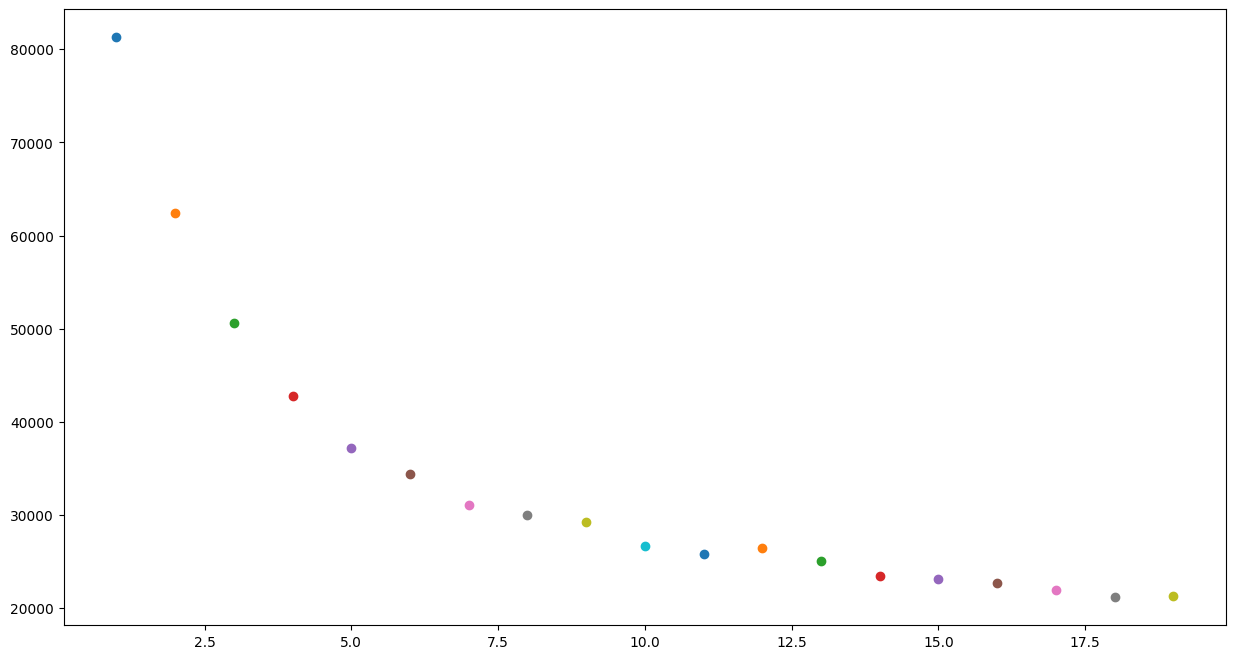

In [55]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, Normalizer
from sklearn.cluster import KMeans
cluster_data = train_data.copy(deep=True)
rss = {}

for k in range(1,20):
    kmeans = KMeans(n_clusters=k).fit(
        ml_pipe.steps[1][1].transform(ml_pipe.steps[0][1].transform(train_data))[:,(1,2,3,5,6,7,8,9)]
    )
    rss[k] = kmeans.inertia_
plt.figure(figsize=(15,8))
for k in rss:
    plt.scatter(int(k), rss[k])
plt.savefig('test.png')

In [56]:
cluster_data['cluster'] = KMeans(n_clusters=8).fit_predict(
    ml_pipe.steps[1][1].transform(ml_pipe.steps[0][1].transform(cluster_data)))
cluster_data.to_csv('cluster_data.csv')

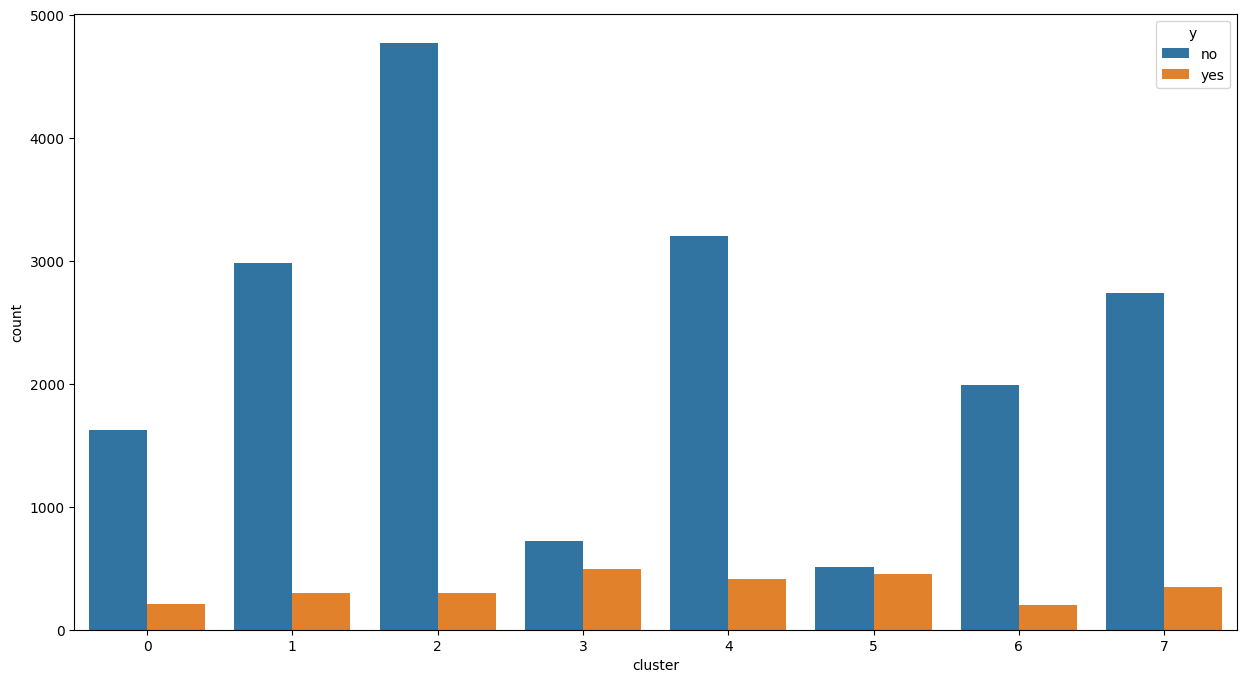

In [57]:
con = (cluster_data['campaign']=='1')
plt.figure(figsize=(15,8))
ax = sns.countplot(x="cluster", hue="y", data=cluster_data)

<Axes: xlabel='cluster', ylabel='cons.conf.idx'>

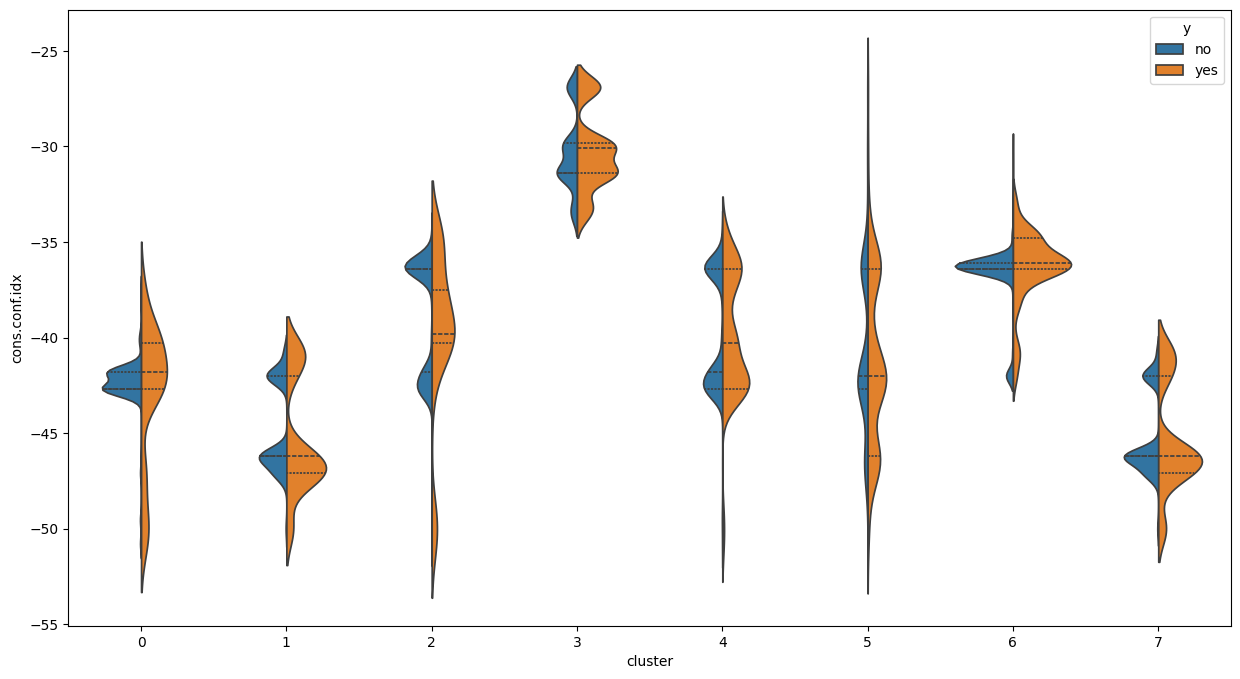

In [58]:
plt.figure(figsize=(15,8))
sns.violinplot(data=cluster_data, x="cluster", y="cons.conf.idx",hue='y',split=True, inner="quart")

<Axes: xlabel='cluster', ylabel='cons.price.idx'>

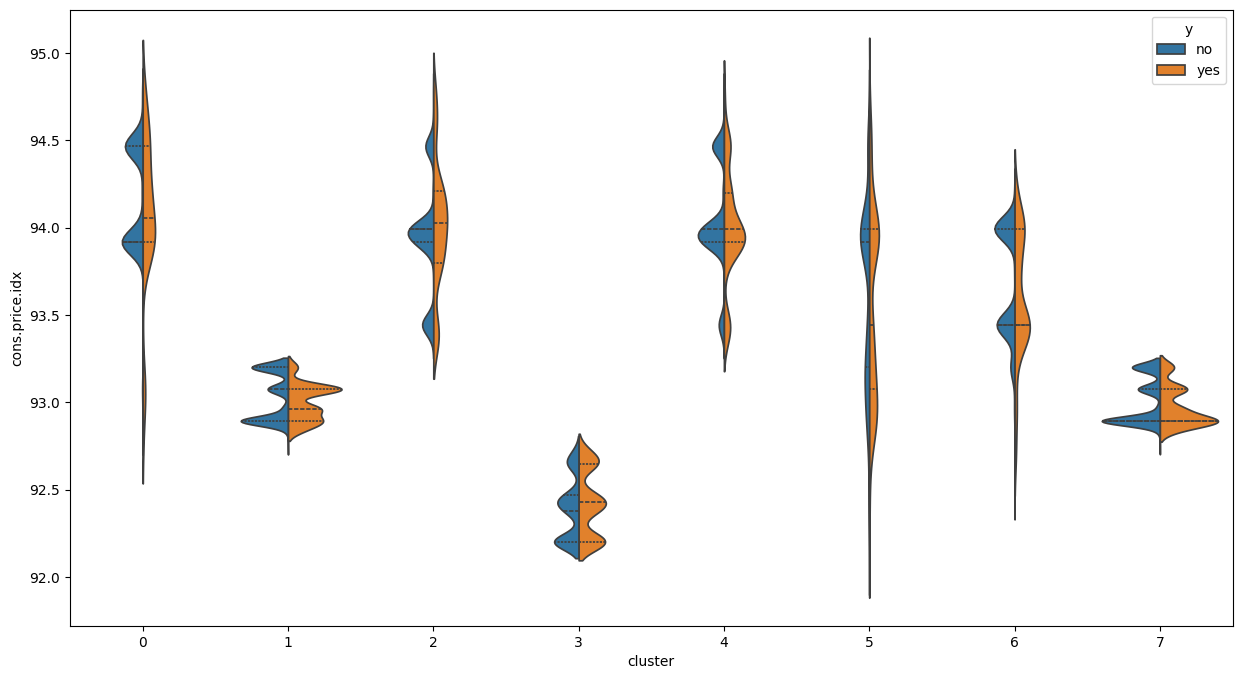

In [59]:
plt.figure(figsize=(15,8))
sns.violinplot(data=cluster_data, x="cluster", y="cons.price.idx",hue='y',split=True, inner="quart")

<Axes: xlabel='cluster', ylabel='age'>

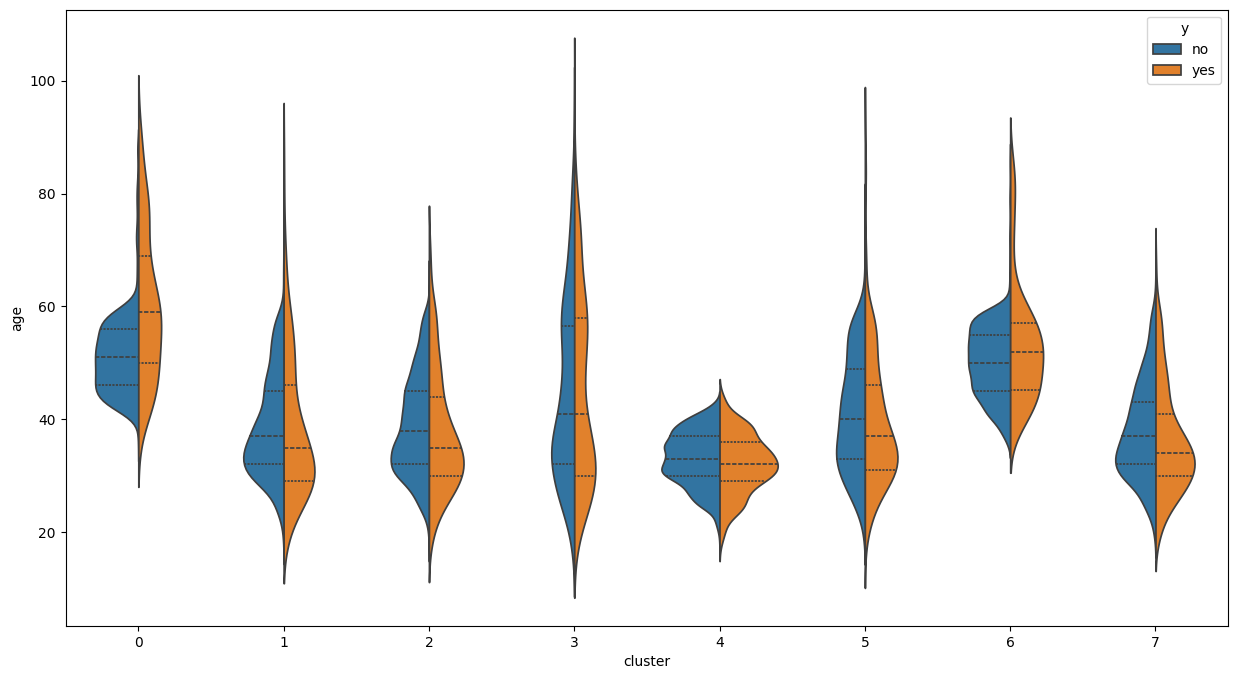

In [60]:
plt.figure(figsize=(15,8))
sns.violinplot(data=cluster_data, x="cluster", y="age",hue='y',split=True, inner="quart")

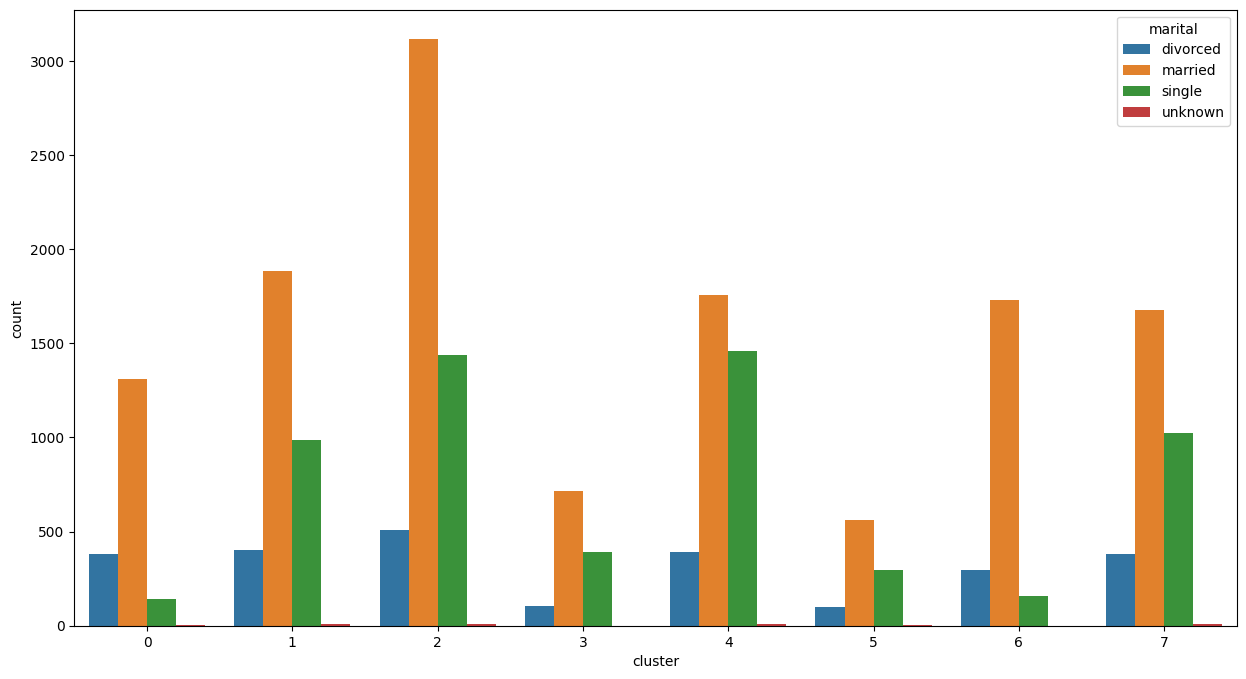

In [61]:
plt.figure(figsize=(15,8))
ax = sns.countplot(x="cluster", hue="marital", data=cluster_data)

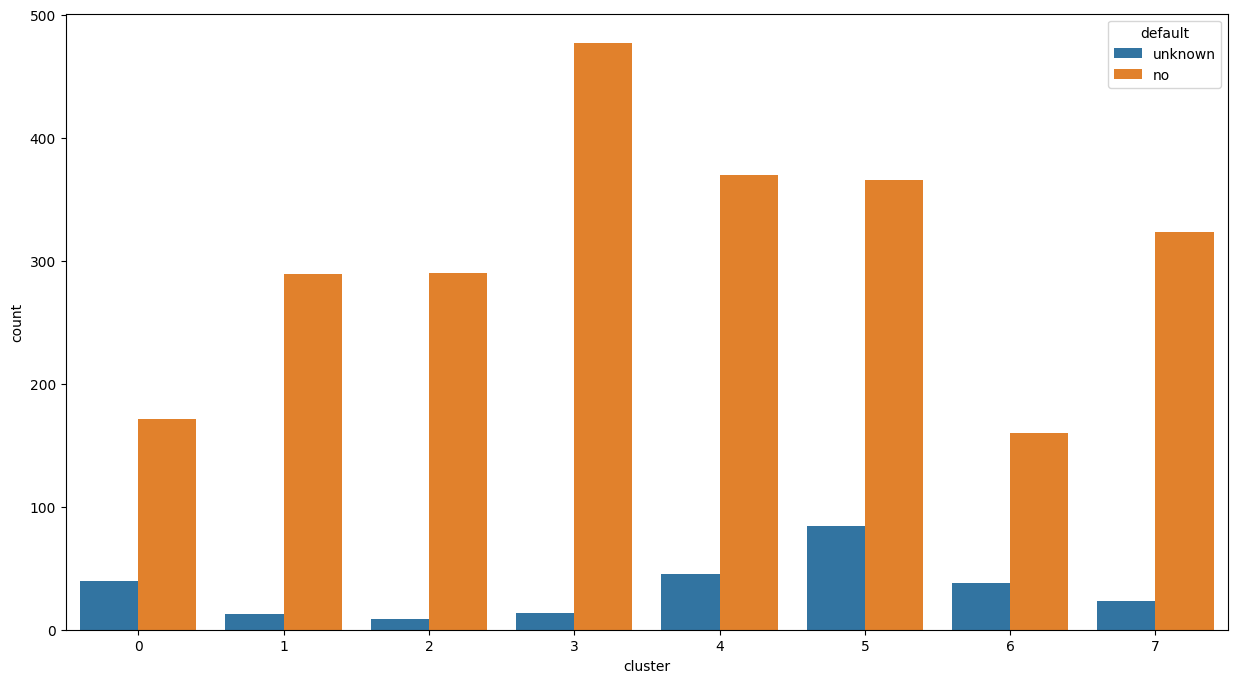

In [62]:
plt.figure(figsize=(15,8))
# ax = sns.countplot(x="cluster", hue="housing", data=sample_customer)
ax = sns.countplot(x="cluster", hue="default", data=cluster_data.loc[(cluster_data['y']=='yes')])

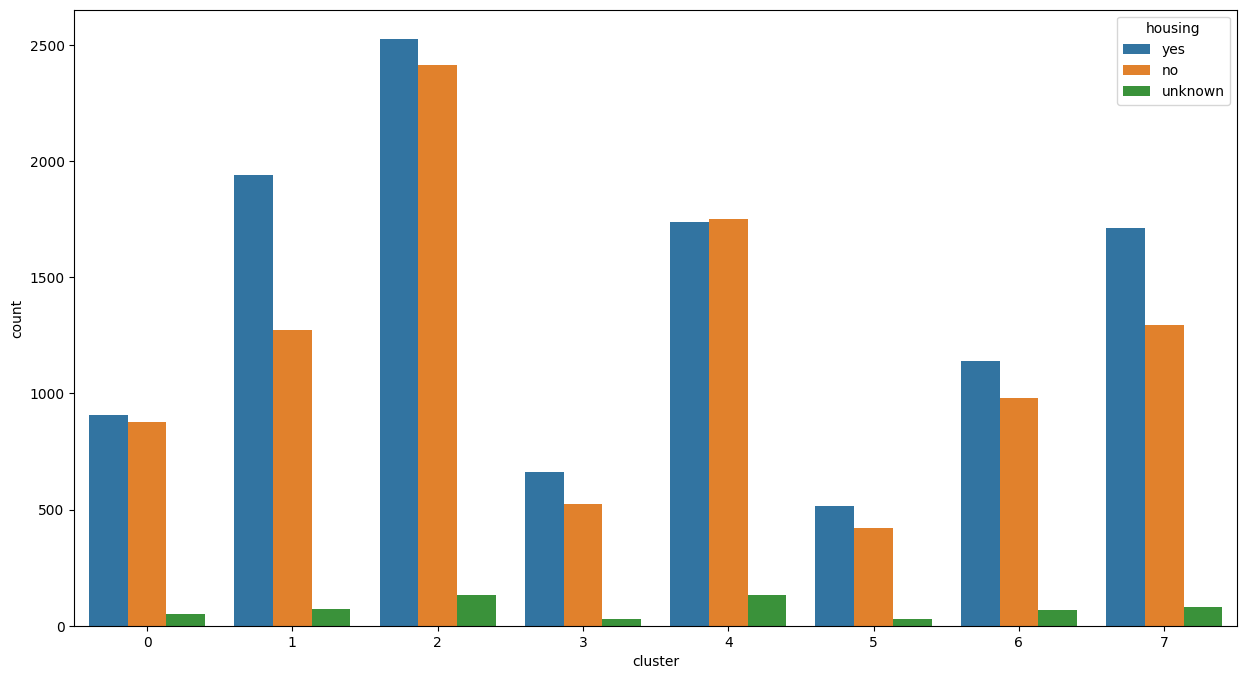

In [63]:
plt.figure(figsize=(15,8))
ax = sns.countplot(x="cluster", hue="housing", data=cluster_data)

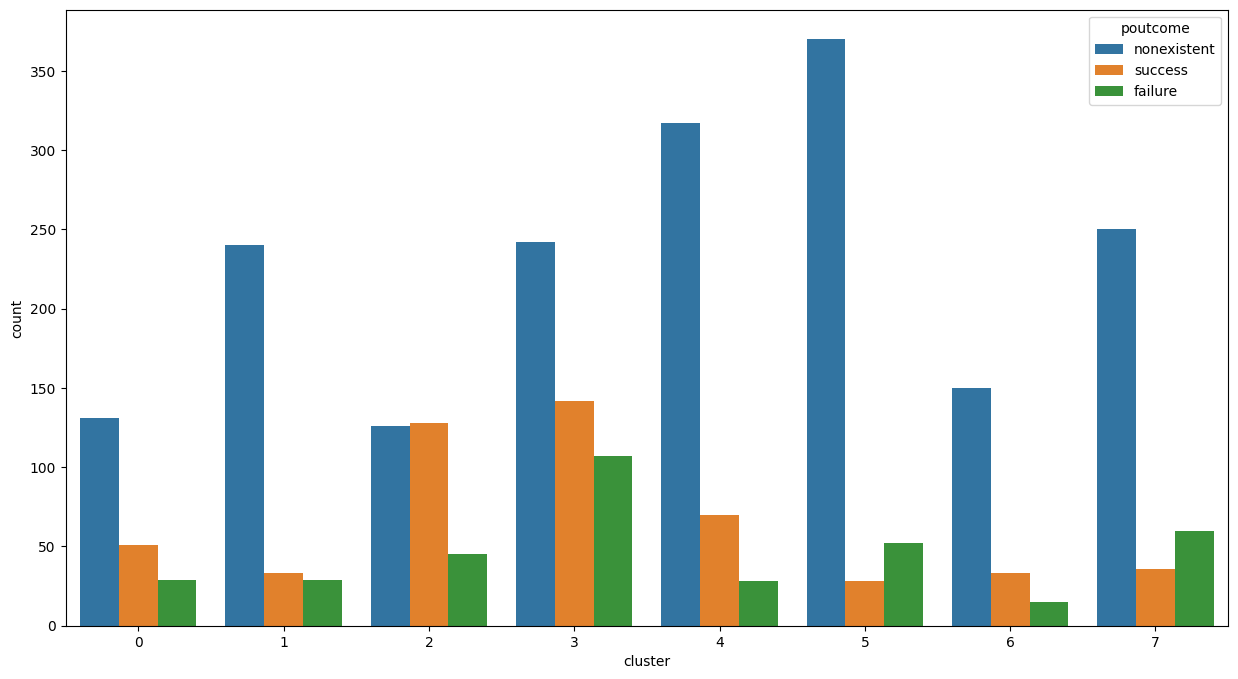

In [64]:
plt.figure(figsize=(15,8))
ax = sns.countplot(x="cluster", hue="poutcome", data=cluster_data.loc[(cluster_data['y']=='yes')])

In [65]:
# [A3 新增] 分群剖面表：依成交率排序、用名次表示（不用群號）；欄位對應官方 cell-69～76 的圖
def a3_share(v, col):
    return lambda s: 100 * (s == v).mean()


a3_cl = cluster_data.groupby('cluster').agg(
    rows=('y', 'size'), conv_pct=('y', a3_share('yes', 'y')),
    target_share_pct=('campaign', a3_share('1', 'campaign')),
    mean_age=('age', 'mean'), mean_cpi=('cons.price.idx', 'mean'), mean_cci=('cons.conf.idx', 'mean'),
    mean_duration=('duration', 'mean'), prev_success_pct=('poutcome', a3_share('success', 'poutcome')),
    married_pct=('marital', a3_share('married', 'marital')), single_pct=('marital', a3_share('single', 'marital')),
    housing_yes_pct=('housing', a3_share('yes', 'housing')), default_unknown_pct=('default', a3_share('unknown', 'default')),
)
# 官方 cell-74、76 只畫成交者：成交者中 default = unknown、poutcome = success 的比例
a3_yes = cluster_data[cluster_data['y'] == 'yes'].groupby('cluster')
a3_cl['yes_default_unknown_pct'] = a3_yes['default'].apply(lambda s: 100 * (s == 'unknown').mean())
a3_cl['yes_prev_success_pct'] = a3_yes['poutcome'].apply(lambda s: 100 * (s == 'success').mean())
a3_cl = a3_cl.sort_values('conv_pct', ascending=False).reset_index(drop=True)
a3_cl.index = ['rank%d' % (i + 1) for i in range(len(a3_cl))]
print(a3_cl.round(1).to_string())
a3_overall = {'married_pct': 100 * (cluster_data['marital'] == 'married').mean(), 'single_pct': 100 * (cluster_data['marital'] == 'single').mean(),
              'housing_yes_pct': 100 * (cluster_data['housing'] == 'yes').mean(), 'prev_success_pct': 100 * (cluster_data['poutcome'] == 'success').mean(),
              'default_unknown_pct': 100 * (cluster_data['default'] == 'unknown').mean(),
              'mean_age': cluster_data['age'].mean(), 'mean_cpi': cluster_data['cons.price.idx'].mean(), 'mean_cci': cluster_data['cons.conf.idx'].mean(),
              'yes_prev_success_pct': 100 * (cluster_data.loc[cluster_data['y'] == 'yes', 'poutcome'] == 'success').mean()}
print('all training rows:', {k: round(v, 2) for k, v in a3_overall.items()})
# 手肘圖（官方 cell-67）用的是 RFE 輸出 10 欄中的第 1、2、3、5～9 欄；最終分群（cell-68）用全部 10 欄
a3_elbow_cols = [a3_decode(a3_names[i]) for i in (1, 2, 3, 5, 6, 7, 8, 9)]
a3_elbow_out = [a3_decode(a3_names[i]) for i in (0, 4)]
print('elbow uses 8 columns; left out:', a3_elbow_out)
print('inertia by k:', {k: round(v) for k, v in rss.items()})
A3_KPI['clustering'] = {   # KMeans 無 random_state：此區不列入跨次執行一致性比對
    'profile': {i: {k: a3_r(v, 2) for k, v in r.items()} for i, r in a3_cl.iterrows()},
    'overall': {k: a3_r(v, 2) for k, v in a3_overall.items()},
    'elbow_inertia': {int(k): int(round(v)) for k, v in rss.items()},
    'elbow_left_out': a3_elbow_out, 'elbow_n_columns': len(a3_elbow_cols),
    'elbow_n_increase': int(sum(rss[k + 1] > rss[k] for k in range(1, 19))),
    'overall_conv_pct': a3_r(100 * (cluster_data['y'] == 'yes').mean(), 2),
    'rest_conv_min': a3_r(a3_cl['conv_pct'].iloc[2:].min(), 1), 'rest_conv_max': a3_r(a3_cl['conv_pct'].iloc[2:].max(), 1),
    'n_clusters': len(a3_cl), 'n_rest': len(a3_cl) - 2,
    'n_all_target': int((a3_cl['target_share_pct'] >= 99).sum()),
    'n_mostly_control': int((a3_cl['target_share_pct'] <= 10).sum()),
}

       rows  conv_pct  target_share_pct  mean_age  mean_cpi  mean_cci  mean_duration  prev_success_pct  married_pct  single_pct  housing_yes_pct  default_unknown_pct  yes_default_unknown_pct  yes_prev_success_pct
rank1   963      46.7             100.0      40.3      93.6     -40.9          844.8               3.9         58.6        30.7             53.5                 21.4                     18.7                   6.2
rank2  1214      40.4              55.1      44.6      92.4     -30.4          127.3              18.0         58.9        32.5             54.4                  2.4                      2.9                  28.9
rank3  1836      11.5              15.1      52.5      94.1     -42.5           16.7               3.6         71.5         7.7             49.5                 36.7                     19.0                  24.2
rank4  3619      11.5               2.5      32.9      94.0     -39.8            0.4               2.7         48.6        40.3             48.0    

### 解讀：分群（手肘圖、8 群剖面與各群的圖）

**結論：8 群主要被「有沒有打、講多久」與時期切開；成交率最高的一群是「講很久的目標組客戶」，不是能在撥號前鎖定的客群。**

- **手肘圖**（官方 cell-67）：inertia 整體隨 k 下降（k = 4／5／6：42,775／37,153／34,415；k = 9／10：29,208／26,634），有 2 處 k 加 1 時反而略升（KMeans 起始點不同），沒有單一明顯拐點；k = 8 是官方指定，不是資料選出來的。手肘圖只用 RFE 輸出 10 欄中的 8 欄（沒有兩個 duration 欄），最終分群（cell-68）卻用全部 10 欄，兩者不完全對應。
- **成交率排名（不引用群號）**：第 1 名 963 人、成交 46.73%，目標組佔 100%，平均通話 845 秒；第 2 名 1,214 人、40.44%。其餘 6 群只有 5.9%–11.5%（全體 12.76%）；8 群中 3 群全是目標組、3 群的目標組不到 10%。
- **小提琴圖（cci、cpi、年齡依成交與否分開）**：第 2 名的平均 cci -30.36、cpi 92.4（全體 -40.59、93.56），是被時期切出來的一群；平均年齡 44.61 歲（全體 40.38）。
- **計數圖（marital、default、housing、poutcome）**：第 2 名的前次行銷成功比例 18.04%（全體 3.76%），default = unknown 只有 2.39%（全體 21.77%）；第 1 名的成交者中前次成功只佔 6.22%（全體成交者 19.21%）—— 它的高成交率來自講得久，不是前次紀錄。第 3、7 名年紀較大（平均 52.55、50.43 歲），已婚 71.46%、79.2%（全體 60.01%），成交率偏低。housing 的比例各群差距不大，對區分成交幫助小。
- **商業意義與注意**：撥號前能用的客群訊號是時期與前次行銷成功，可以做成不同話術或聯絡時機的實驗，但應先拿掉 duration 與組別欄位重新分群。KMeans 沒有 random_state；本檔分群前固定了 numpy 種子，同一環境可重現，但換套件版本時群的切法可能改變，所以只用排名描述，數字為本次儲存的結果。

<a id="part-b" name="part-b"></a>
# Part B｜商業評估：對照 A2 成功標準

這一部分接在官方最後一格之後，官方流程完全不動。問題只有一個：**這個模型能不能照 A2 的計畫往下走？**

> **先給答案**
> 1. 模型比隨機外撥好：與手機規則同樣通數時，名單轉換率 16.77%，隨機外撥 13.14%。
> 2. 但和現行手機規則（16.58%）同月、同通數比，只高 0.19 個百分點，95% 區間含 0 —— 看不出比手機規則好。
> 3. 三條上線硬門檻（②③⑤）沒有一條能離線判定為通過；十條中只有 ML①、ML③ 達標。
> 4. 依 A2 表 7 勝出的 XGB，十條判定與 RF 完全相同。
> 5. 建議：依 A2 表 9 階段 0，**不進影子模式**；先補撥號前的客戶特徵與有日期、客戶編號的資料，再用新的時間段重測。

**名詞**（Part B 反覆用到）
- **時期**：一組 (cpi, cci) 值。這兩個指標每月公布一次，同一組值大致是同一個年月；資料跨年，所以一個「月份」裡混有 2–3 個時期。
- **同月配對名單**：每個月打的通數與手機規則相同、取該月分數最高的人 —— 外撥日不能換月份，這是實際做得到的名單（①②與混淆矩陣用它）。**單一門檻名單**：全體分數 ≥ 門檻 t 的人；對照組沒有月份，③④⑤ 只能用它。
- **percentile 區間**：bootstrap 重抽結果的 2.5%–97.5% 分位，是評估計畫訂的判準區間。**basic 區間**：偏差校正版（2 × 點估計 − 上、下界），只當檢查（附錄 A）。
- **本來就會買**：不打電話也會買的人；用「分數同樣達門檻、但沒被打的對照組」的轉換率估計（業務④）。

**做法**
1. **資料**：notebook 去重後的 `campaign_data`，切分與官方最終流程（cell-56）相同（test_size = 0.4、random_state = 123；訓練 21,262 列、測試 14,176 列）。A2 正文用的是原始 41,188 列，兩個口徑在 B-0 並列。
2. **模型**：只用 A2 表 5 標「可」的 11 欄、只用訓練集的目標組（campaign = '1'）訓練，前處理包在 Pipeline 內。RF 是評估計畫事先指定的主模型，超參數用一條只看訓練資料、A3 自訂的規則選（in-sample AUC − CV AUC ≤ 0.05 的設定中取 CV 最高者，代理 A2 的 ML③）。XGBoost 依 A2 表 7 當挑戰者，同樣只在訓練資料上比（B-1）；它勝出，所以 B-11 對它做完整的十條評估。
3. **測試集**：模型與超參數在評分前固定，之後不回頭改。業務②的判準（B = 1,000、種子 123、95% percentile 區間下限 > 0）是計畫原本訂的；B = 5,000、basic 區間與換種子是看過第一次結果之後才加的檢查，不改判準（附錄 A）。設計階段我曾用同一份測試集預跑過，所以測試數字仍屬樂觀估計；乾淨的做法是保留一段較晚的時間當全新的驗證集（資料沒有日期，做不到；A2 已請求補日期）。
4. **同期**：A2 表 9 定義為「同一段期間、同樣通數」。主結果以同月份操作化，另以同時期做穩健性檢查。增量只和對照組中分數同樣達門檻的客戶比（A2 表 4 ③）。
5. **假設**（沿用 A2 表 1 下方假設框與附錄 A）：時薪 A\$50、只計通話時間、成交 496.8 秒／未成交 220.7 秒；收益：折扣 = 2:1。

**判定用語**（每個只有一種意思）：**達標**＝達到 A2 門檻；**未達**＝證據落在門檻錯的一邊（點估計在錯的一邊，或整個區間都在錯的一邊）；**未證實**＝點估計方向對，但 95% 區間跨過門檻，不能說已達到；**示算**＝只能在假設下試算；**不可離線驗**＝試點資料無法檢驗。另一欄「是否達 A2 門檻」只填 是／否／離線無法判定。

<a id="part-b-summary" name="part-b-summary"></a>
## Part B 十條成功標準一覽（A2 表 4；②③⑤ 是上線硬門檻）

| A2 表 4 標準 | A2 門檻 | A3 結果（RF 主模型） | 判定 | 是否達 A2 門檻 | XGB（表 7 勝出者） |
|---|---|---|---|---|---|
| 業務① 每筆成交通話成本 | ≤ A\$20.87 | 同月配對名單 A\$22.11（手機規則 A\$22.32） | **未達** | 否 | 未達 |
| 業務② 名單轉換率（硬門檻） | 高於同期手機規則組 | 同月 +0.19 pp，95% 區間 [-0.13, +0.72]；同時期 -0.21 pp | **未證實** | 否 | 未證實 |
| 業務③ 增量成交（硬門檻） | 為正（同門檻對照組） | 去重 +0.46、原始 +4.02 pp；分時期 -0.97／+0.75 pp（區間都含 0） | **未證實** | 離線無法判定 | 未證實 |
| 業務④ 本來就會買的比例 | A/B 列報；兩平參考 50% | 去重 97.4%、原始 77.2%（區間都高於 50%） | **未達** | 否（區間高於 50% 兩平參考） | 未達 |
| 業務⑤ 式 1 淨值（硬門檻） | 不低於同期手機規則組 | 2:1 示算為負：-0.166／-0.096 D 每通 | **示算** | 離線無法判定 | 示算 |
| ML① 概念驗證 AUC | ≥ 0.80（樂觀參考） | 0.8715 | **達標** | 是 | 達標 |
| ML② 撥號前 AUC | ≥ 0.75，且 ② 通過 | 0.7912（同一時期內 0.5390）；② 未通過 | **未證實** | 否 | 未證實 |
| ML③ 過擬合 | 訓練 − 測試 ≤ 0.05 | 概念驗證 0.0236、撥號前 0.0367 | **達標** | 是 | 達標 |
| ML④ 分群一致性 | 各群 AUC 差 ≤ 0.05 | 年齡 0.115、婚姻 0.016、月份 0.214 | **未達** | 否 | 未達 |
| ML⑤ 增量排序模型 | 名單內平均增量 > 全體 | 未建（12 週後才有資料） | **不可離線驗** | 離線無法判定 | 不可離線驗 |

ML ①–⑤ 是 A2 表 4 五個 ML 列的依序編號。①② 用同月配對名單，③④⑤ 用單一門檻名單。每條的 A2 草稿行號、完整區間與說明在 B-12 的總表。

In [66]:
# [Part B-0] 資料口徑對照：A2 正文（原始 41,188 列）vs A3（notebook 去重後、與 cell-56 相同的切分）
import json, sys
import scipy, sklearn, matplotlib, xgboost
from IPython.display import display
from scipy.stats import rankdata
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score, train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
from sklearn.inspection import permutation_importance

pd.set_option('display.html.use_mathjax', False)    # 表格裡的 A$ 不要被當成數學式
pd.set_option('styler.html.mathjax', False)
pd.set_option('display.max_colwidth', None)          # 表格內的文字（區間、理由、設定）不截斷
PB_SEED = RANDOM_SATE                                # 123，與官方 notebook 同一個種子
PB_HOURLY = 50.0                                     # A2 假設時薪 A$50（A2 表 1 下方「主要假設與限制」框、附錄 A）
PB_ACCENT, PB_GREY, PB_LIGHT = '#1f5fa8', '#555555', '#b4b4b4'


def pb_clean(df):
    """與 cell-13 相同的清理，但不去重：三欄補 'Not Applicable'、previous / campaign 轉字串"""
    d = df.copy()
    d[['contact', 'month', 'day_of_week']] = d[['contact', 'month', 'day_of_week']].fillna('Not Applicable')
    d['previous'] = d['previous'].apply(str)
    d['campaign'] = d['campaign'].apply(str)
    return d


def pb_conv(df):
    return float((df['y'] == 'yes').mean())


def pb_pct(x, nd=2):
    return round(100 * float(x), nd)


pb_raw = pb_clean(read_data(path=csv_path))      # A2 正文口徑：原始 41,188 列（不去重）
pb_data = campaign_data.copy(deep=True)          # A3 主口徑：cell-13 去重後 35,438 列
pb_train, pb_test = train_test_split(pb_data, test_size=0.4, random_state=RANDOM_SATE)
assert (len(pb_train), len(pb_test)) == (21262, 14176)
assert pb_train.index.equals(train_data.index) and pb_test.index.equals(test_data.index)   # 與 cell-56 完全同一批列

# A2 表 4 ① 的成本公式：每通成本 c(r) = (r x 成交平均秒數 + (1 - r) x 未成交平均秒數) / 3600 x 時薪；每筆成交成本 = c(r) / r
pb_rawT, pb_rawC = pb_raw[pb_raw['campaign'] == '1'], pb_raw[pb_raw['campaign'] == '0']
PB_SEC_YES = float(pb_rawT.loc[pb_rawT['y'] == 'yes', 'duration'].mean())
PB_SEC_NO = float(pb_rawT.loc[pb_rawT['y'] == 'no', 'duration'].mean())


def pb_call_cost(r):
    return (r * PB_SEC_YES + (1 - r) * PB_SEC_NO) / 3600 * PB_HOURLY


def pb_cost_per_conv(r):
    return pb_call_cost(r) / r


PB_CALL_NO = PB_SEC_NO / 3600 * PB_HOURLY             # 未成交電話每通成本（未取整，約 A$3.07）
PB_CALL_YES = PB_SEC_YES / 3600 * PB_HOURLY           # 成交電話每通成本（未取整，約 A$6.90）


def pb_actual_cost_per_conv(df):
    """輔助口徑：所選列的實際通話秒數換成 A$ 再除以成交數（duration 只當事後成本帳，不當特徵）"""
    return float(df['duration'].sum() / 3600 * PB_HOURLY / (df['y'] == 'yes').sum())


rows = []
for name, d in [('A2 text: raw file', pb_raw), ('A3: deduplicated file', pb_data),
                ('A3: train split', pb_train), ('A3: test split', pb_test)]:
    t, c = d[d['campaign'] == '1'], d[d['campaign'] == '0']
    m = t[t['contact'] == 'cellular']
    rows.append({'data': name, 'rows': len(d), 'target_n': len(t), 'target_conv_pct': pb_pct(pb_conv(t)),
                 'control_n': len(c), 'control_conv_pct': pb_pct(pb_conv(c)),
                 'diff_pp': round(100 * (pb_conv(t) - pb_conv(c)), 2),
                 'mobile_n': len(m), 'mobile_conv_pct': pb_pct(pb_conv(m))})
pb_reconcile = pd.DataFrame(rows)
display(pb_reconcile.rename(columns={'target_n': 'target n', 'target_conv_pct': 'target conv %', 'control_n': 'control n',
                                     'control_conv_pct': 'control conv %', 'diff_pp': 'target - control (pp)',
                                     'mobile_n': 'mobile-rule n', 'mobile_conv_pct': 'mobile-rule conv %'}))

pb_r_pilot, pb_r_ctrl_raw = pb_conv(pb_rawT), pb_conv(pb_rawC)
PB_PILOT_COST = float(pb_rawT['duration'].sum() / 3600 * PB_HOURLY)   # 試點每輪通話成本（未取整，約 A$62,905）
pb_a2 = {
    'raw_rows': len(pb_raw), 'dedup_rows': len(pb_data), 'removed_rows': len(pb_raw) - len(pb_data),
    'removed_control': int(len(pb_rawC) - (pb_data['campaign'] == '0').sum()),
    'removed_target': int(len(pb_rawT) - (pb_data['campaign'] == '1').sum()),
    'sec_yes': round(PB_SEC_YES, 2), 'sec_no': round(PB_SEC_NO, 2),
    'call_cost_yes': round(PB_SEC_YES / 3600 * PB_HOURLY, 2), 'call_cost_no': round(PB_SEC_NO / 3600 * PB_HOURLY, 2),
    'pilot_target_n': len(pb_rawT), 'pilot_target_conv_pct': pb_pct(pb_r_pilot),
    'pilot_control_n': len(pb_rawC), 'pilot_control_conv_pct': pb_pct(pb_r_ctrl_raw),
    'pilot_uplift_pp': round(100 * (pb_r_pilot - pb_r_ctrl_raw), 2),
    'pilot_incremental_sales': round(len(pb_rawT) * (pb_r_pilot - pb_r_ctrl_raw), 1),
    'pilot_would_buy_share_pct': pb_pct(pb_r_ctrl_raw / pb_r_pilot, 1),
    'pilot_total_call_cost': round(pb_rawT['duration'].sum() / 3600 * PB_HOURLY, 0),
    'cost_per_conv_pilot': round(pb_cost_per_conv(pb_r_pilot), 2),
    'cost_per_conv_target_18pct': round(pb_cost_per_conv(0.18), 2),
    'mobile_raw_n': int((pb_rawT['contact'] == 'cellular').sum()),
    'mobile_raw_conv_pct': pb_pct(pb_conv(pb_rawT[pb_rawT['contact'] == 'cellular'])),
    # 兩組組成：前次行銷成功者的比例（原始全檔 vs 去重後）
    'prev_success_share_pct': {'raw_target': pb_pct((pb_rawT['poutcome'] == 'success').mean(), 2),
                               'raw_control': pb_pct((pb_rawC['poutcome'] == 'success').mean(), 2),
                               'dedup_target': pb_pct((pb_data.loc[pb_data['campaign'] == '1', 'poutcome'] == 'success').mean(), 2),
                               'dedup_control': pb_pct((pb_data.loc[pb_data['campaign'] == '0', 'poutcome'] == 'success').mean(), 2)},
}
assert (pb_a2['cost_per_conv_pilot'], pb_a2['cost_per_conv_target_18pct']) == (27.35, 20.87)   # 與 A2 表 4 ① 一致
for k, v in pb_a2.items():
    print('%-28s %s' % (k, v))
A3_KPI['part_b']['a2_recomputed'] = pb_a2
A3_KPI['part_b']['reconcile'] = [{k: (a3_r(v, 2) if not isinstance(v, str) else v) for k, v in r.items()} for r in rows]

,data,rows,target n,target conv %,control n,control conv %,target - control (pp),mobile-rule n,mobile-rule conv %
0,A2 text: raw file,41188,17642,13.04,23546,9.94,3.10,11759,16.57
1,A3: deduplicated file,35438,17633,13.04,17805,12.73,0.31,11753,16.57
2,A3: train split,21262,10539,12.97,10723,12.54,0.43,7001,16.55
3,A3: test split,14176,7094,13.14,7082,13.02,0.12,4752,16.58


raw_rows                     41188
dedup_rows                   35438
removed_rows                 5750
removed_control              5741
removed_target               9
sec_yes                      496.78
sec_no                       220.74
call_cost_yes                6.9
call_cost_no                 3.07
pilot_target_n               17642
pilot_target_conv_pct        13.04
pilot_control_n              23546
pilot_control_conv_pct       9.94
pilot_uplift_pp              3.1
pilot_incremental_sales      546.7
pilot_would_buy_share_pct    76.2
pilot_total_call_cost        62905.0
cost_per_conv_pilot          27.35
cost_per_conv_target_18pct   20.87
mobile_raw_n                 11759
mobile_raw_conv_pct          16.57
prev_success_share_pct       {'raw_target': 4.1, 'raw_control': 2.76, 'dedup_target': 4.11, 'dedup_control': 3.6}


### B-0 解讀：資料口徑（A2 原始 vs A3 去重）

**結論：A2 的基準在這裡全部重算吻合；去重幾乎只刪對照組的列，所以凡是用到對照組的 ③④⑤ 兩個口徑都報。**

- **觀察**：notebook 的 `drop_duplicates()` 刪掉 5,750 列，其中對照組 5,741 列、目標組只有 9 列。對照組轉換率因此從 9.94% 升到 12.73%，「目標組 − 對照組」從 A2 的 3.10 個百分點縮成 0.31；測試集只剩 0.12。手機規則幾乎不受影響（原始 16.57%、測試集 16.58%）。
- **兩組組成**：前次行銷成功者的比例，原始全檔目標組 4.10% 對對照組 2.76%，去重後 4.11% 對 3.60% —— 去重讓兩組較接近，但仍不同；兩組不是隨機分派。
- **A2 基準重算**：每筆成交通話成本 A\$27.35、轉換率 18% 時 A\$20.87；增量約 547 人；成交者中本來就會買 76.2%；成交／未成交平均通話 496.78／220.74 秒（每通約 A\$6.90／A\$3.07）。
- **商業意義**：沒有客戶編號，無法判斷那 5,741 列是真的重複，還是屬性剛好相同的不同客戶（對照組少了 contact、month、day_of_week、duration 四欄，本來就容易「相同」）；A2 附錄 A 把去重版定為極端情境。只用目標組的指標（①②、ML①–④）兩個口徑幾乎一樣，用主口徑即可。
- **注意**：A2 的 13.04%、16.6%、A\$27.35 是原始全檔數字；以下 A3 的數字是去重後測試集（目標組 7,094 人），兩者可以並列，不可直接相減。

In [67]:
# [Part B-1] 撥號前模型：11 個撥號前欄位；只用「訓練集目標組」訓練；超參數與挑戰者比較都只用訓練資料（此格完全不碰測試集）
PB_NUM = ['age', 'cons.price.idx', 'cons.conf.idx']
PB_CAT = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'previous', 'poutcome']
PB_FEATURES = PB_NUM + PB_CAT                      # 11 欄 = A2 表 5 標「可」的欄位
PB_FEATURES_CT = PB_FEATURES + ['contact']         # 敏感度版本「+contact」
display(pd.DataFrame([
    ('duration', '通話結束才知道；對照組全為 0（duration = 0 ⇔ 沒被打），放進去等於告訴模型組別（A2 表 5 duration 列：預測當下可得＝否）'),
    ('campaign', '是「要不要打」的分組決策本身，不是客戶屬性（A2 表 5 分組列）'),
    ('contact', '本次活動實際使用的管道、對照組全空，且是比較組「手機規則」的定義欄位 → 主版本不放，另做 +contact 敏感度版（A2 表 5：條件式，排程後才知）'),
    ('month', '排程變數：同一外撥日的候選人月份相同，對當日排序沒有資訊；離線只會把時期效應灌進 AUC；對照組全空。只用來定義「同期」'),
    ('day_of_week', '排程變數，理由同 month；對照組全空'),
], columns=['excluded column', '理由']))

pb_trT = pb_train[pb_train['campaign'] == '1']
pb_y_trT = (pb_trT['y'] == 'yes').astype(int)
pb_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=PB_SEED)


def pb_pipeline(model, cat, num=None):
    """前處理包在 Pipeline 裡，只在（CV 的）訓練折上擬合"""
    prep_ = ColumnTransformer([('num', StandardScaler(), PB_NUM if num is None else num),
                               ('cat', OneHotEncoder(handle_unknown='ignore'), cat)])
    return Pipeline([('prep', prep_), ('clf', model)])


def pb_rf(n_jobs=1, **kw):
    # 重現性：樹的建立各有種子，多執行緒訓練結果固定；但多執行緒 predict_proba 的加總順序不固定（約 1e-16 的差），
    # 而 11 個撥號前欄位下有很多完全相同的客戶（同分），先後一變，名單就不同。所以預測一律用單執行緒。
    return RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=PB_SEED, n_jobs=n_jobs, **kw)


def pb_select_rf(X, y, cat, label):
    """A3 自訂、只看訓練資料的選模規則（用來代理 A2 的 ML③；A2 只規定『訓練與測試 AUC 差 ≤ 0.05』，沒有這條）：
    在『in-sample 訓練 AUC − 平均 CV AUC ≤ 0.05』的設定中，取平均 CV AUC 最高者"""
    grid = GridSearchCV(pb_pipeline(pb_rf(n_jobs=1), cat), {'clf__max_depth': [5, 7, 9], 'clf__min_samples_leaf': [1, 20]},
                        scoring='roc_auc', cv=pb_cv, n_jobs=-1, refit=False).fit(X, y)
    rows_, fitted = [], {}
    for p, cv_m, cv_s in zip(grid.cv_results_['params'], grid.cv_results_['mean_test_score'], grid.cv_results_['std_test_score']):
        key = (p['clf__max_depth'], p['clf__min_samples_leaf'])
        m = pb_pipeline(pb_rf(n_jobs=-1, max_depth=key[0], min_samples_leaf=key[1]), cat).fit(X, y)
        m.set_params(clf__n_jobs=1)   # 多執行緒 predict_proba 的加總順序不固定，同分客戶的先後會變；預測一律單執行緒
        tr = roc_auc_score(y, m.predict_proba(X)[:, 1])
        fitted[key] = m
        rows_.append({'model': label, 'max_depth': key[0], 'min_samples_leaf': key[1], 'cv_auc': cv_m, 'cv_sd': cv_s,
                      'train_auc_in_sample': tr, 'train_minus_cv': tr - cv_m})
    tab = pd.DataFrame(rows_)
    tab['gap_ok'] = tab['train_minus_cv'] <= 0.05
    pool = tab[tab['gap_ok']] if tab['gap_ok'].any() else tab.nsmallest(1, 'train_minus_cv')
    best = pool.sort_values(['cv_auc', 'max_depth'], ascending=[False, True]).iloc[0]
    key = (int(best['max_depth']), int(best['min_samples_leaf']))
    tab['selected'] = (tab['max_depth'] == key[0]) & (tab['min_samples_leaf'] == key[1])
    i = [k for k, p in enumerate(grid.cv_results_['params']) if (p['clf__max_depth'], p['clf__min_samples_leaf']) == key][0]
    folds = np.array([grid.cv_results_['split%d_test_score' % f][i] for f in range(pb_cv.get_n_splits())])
    return tab, fitted[key], {'max_depth': key[0], 'min_samples_leaf': key[1], 'n_estimators': 300}, folds


pb_main_tab, pb_main, pb_main_params, pb_main_folds = pb_select_rf(pb_trT[PB_FEATURES], pb_y_trT, PB_CAT, 'RF pre-call 11 (main)')
pb_ct_tab, pb_ct, pb_ct_params, _ = pb_select_rf(pb_trT[PB_FEATURES_CT], pb_y_trT, PB_CAT + ['contact'], 'RF +contact (sensitivity)')
pb_lr = pb_pipeline(LogisticRegression(class_weight='balanced', max_iter=2000), PB_CAT)
pb_lr_cv = cross_val_score(pb_lr, pb_trT[PB_FEATURES], pb_y_trT, cv=pb_cv, scoring='roc_auc')
pb_lr.fit(pb_trT[PB_FEATURES], pb_y_trT)
pb_lr_train = roc_auc_score(pb_y_trT, pb_lr.predict_proba(pb_trT[PB_FEATURES])[:, 1])

# A2 表 7（XGBoost 列）：挑戰者要「與隨機森林用同一批驗證折、同一指標重比；勝出幅度大於不同隨機種子間的波動才替換」。
# 照字面執行（只用訓練資料）：XGB 先在同樣 5 折上從 4 組設定選一組；再用 5 個隨機種子（123–127，每個種子同時改變
# 5 折的切法與模型的 random_state）重比 RF 選定設定與 XGB 選定設定。替換條件：5 個種子的平均勝出幅度
# 大於 RF 的 CV AUC 在種子之間的最大差距（max − min），而且每個種子都勝出。
from xgboost import XGBClassifier
pb_ratio = float((pb_y_trT == 0).sum() / (pb_y_trT == 1).sum())
pb_xgb_grid = GridSearchCV(pb_pipeline(XGBClassifier(n_estimators=200, scale_pos_weight=pb_ratio, random_state=PB_SEED, n_jobs=1), PB_CAT),
                           {'clf__max_depth': [3, 5], 'clf__learning_rate': [0.05, 0.1]},
                           scoring='roc_auc', cv=pb_cv, n_jobs=-1, refit=False).fit(pb_trT[PB_FEATURES], pb_y_trT)
pb_xi = int(np.argmax(pb_xgb_grid.cv_results_['mean_test_score']))
pb_xgb_cv, pb_xgb_sd = float(pb_xgb_grid.cv_results_['mean_test_score'][pb_xi]), float(pb_xgb_grid.cv_results_['std_test_score'][pb_xi])
pb_xgb_params = {k.replace('clf__', ''): v for k, v in pb_xgb_grid.cv_results_['params'][pb_xi].items()}
pb_xgb_folds = np.array([pb_xgb_grid.cv_results_['split%d_test_score' % f][pb_xi] for f in range(pb_cv.get_n_splits())])
pb_main_cv = float(pb_main_tab.loc[pb_main_tab['selected'], 'cv_auc'].iloc[0])
pb_main_sd = float(pb_main_tab.loc[pb_main_tab['selected'], 'cv_sd'].iloc[0])
print('same 5 folds, XGB minus RF per fold:', np.round(pb_xgb_folds - pb_main_folds, 4))
pb_seed_rows = []
for s_ in range(PB_SEED, PB_SEED + 5):
    cv_ = StratifiedKFold(n_splits=5, shuffle=True, random_state=s_)
    rf_ = pb_pipeline(RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=s_, n_jobs=1,
                                             max_depth=pb_main_params['max_depth'], min_samples_leaf=pb_main_params['min_samples_leaf']), PB_CAT)
    xg_ = pb_pipeline(XGBClassifier(n_estimators=200, scale_pos_weight=pb_ratio, random_state=s_, n_jobs=1, **pb_xgb_params), PB_CAT)
    a_ = cross_val_score(rf_, pb_trT[PB_FEATURES], pb_y_trT, cv=cv_, scoring='roc_auc', n_jobs=-1).mean()
    b_ = cross_val_score(xg_, pb_trT[PB_FEATURES], pb_y_trT, cv=cv_, scoring='roc_auc', n_jobs=-1).mean()
    pb_seed_rows.append({'seed': s_, 'RF CV AUC': a_, 'XGB CV AUC': b_, 'XGB - RF': b_ - a_})
pb_seed_tab = pd.DataFrame(pb_seed_rows)
pb_margin = float(pb_seed_tab['XGB - RF'].mean())
pb_rf_seed_range = float(pb_seed_tab['RF CV AUC'].max() - pb_seed_tab['RF CV AUC'].min())
pb_xgb_replace = bool(pb_margin > pb_rf_seed_range and (pb_seed_tab['XGB - RF'] > 0).all())
assert abs(pb_seed_tab.loc[0, 'RF CV AUC'] - pb_main_cv) < 1e-9          # 種子 123 = 上面選模用的同一批折
# 依表 7 勝出的挑戰者在整個訓練集目標組上擬合一次；B-2 起每一條都與 RF 並列，B-11 對十條標準做完整的平行評估
pb_xgb = pb_pipeline(XGBClassifier(n_estimators=200, scale_pos_weight=pb_ratio, random_state=PB_SEED, n_jobs=1, **pb_xgb_params), PB_CAT)
pb_xgb.fit(pb_trT[PB_FEATURES], pb_y_trT)

display(pd.concat([pb_main_tab, pb_ct_tab], ignore_index=True).round(4))
display(pd.DataFrame([('LR baseline (balanced)', pb_lr_cv.mean(), pb_lr_cv.std(), '-'),
                      ('RF main (selected)', pb_main_cv, pb_main_sd, str(pb_main_params)),
                      ('XGB challenger (best of 4, scale_pos_weight = %.2f)' % pb_ratio, pb_xgb_cv, pb_xgb_sd, str(pb_xgb_params))],
                     columns=['model (same 5 folds, training target group only)', 'CV AUC', 'fold sd', 'settings']).round(4))
print('A2 table 7 replacement check: RF vs XGB (selected settings) over 5 random seeds')
display(pb_seed_tab.round(4))
print('training target group: %d rows, %d conversions (%.2f%%)' % (len(pb_trT), pb_y_trT.sum(), 100 * pb_y_trT.mean()))
print('LR baseline (balanced): CV AUC %.4f (sd %.4f), train in-sample %.4f' % (pb_lr_cv.mean(), pb_lr_cv.std(), pb_lr_train))
print('A2 table 7: mean margin XGB - RF over 5 seeds %+.4f vs RF seed-to-seed range %.4f; XGB ahead on every seed: %s '
      '-> XGB replaces RF as the candidate: %s' % (pb_margin, pb_rf_seed_range, bool((pb_seed_tab['XGB - RF'] > 0).all()), pb_xgb_replace))
print('selected main:', pb_main_params, '| selected +contact:', pb_ct_params)


def pb_tab_records(tab):
    return [{k: (a3_r(v) if not isinstance(v, str) else v) for k, v in r.items()} for r in tab.to_dict('records')]


A3_KPI['part_b']['models'] = {
    'features_main': PB_FEATURES, 'features_sensitivity': PB_FEATURES_CT,
    'train_target_rows': len(pb_trT), 'train_target_conversions': int(pb_y_trT.sum()),
    'train_target_conv_pct': a3_r(100 * pb_y_trT.mean(), 2),
    'main_params': pb_main_params, 'contact_params': pb_ct_params,
    'main_grid': pb_tab_records(pb_main_tab), 'contact_grid': pb_tab_records(pb_ct_tab),
    'main_selected': pb_tab_records(pb_main_tab[pb_main_tab['selected']])[0],
    'main_best_cv_overall': pb_tab_records(pb_main_tab.sort_values('cv_auc', ascending=False).head(1))[0],
    'main_rejected_by_gap': pb_tab_records(pb_main_tab[~pb_main_tab['gap_ok']]),
    'contact_selected': pb_tab_records(pb_ct_tab[pb_ct_tab['selected']])[0],
    'rf_minus_lr_cv': a3_r(pb_main_cv - pb_lr_cv.mean()),
    'lr_cv_auc': a3_r(pb_lr_cv.mean()), 'lr_cv_sd': a3_r(pb_lr_cv.std()), 'lr_train_auc': a3_r(pb_lr_train),
    'rf_cv_sd': a3_r(pb_main_sd), 'xgb_cv_auc': a3_r(pb_xgb_cv), 'xgb_cv_sd': a3_r(pb_xgb_sd),
    'xgb_params': {k: (float(v) if isinstance(v, float) else int(v)) for k, v in pb_xgb_params.items()},
    'xgb_scale_pos_weight': a3_r(pb_ratio, 2), 'xgb_minus_rf_cv': a3_r(pb_xgb_cv - pb_main_cv), 'xgb_replace': pb_xgb_replace,
    'xgb_minus_rf_by_fold': [a3_r(v) for v in pb_xgb_folds - pb_main_folds],
    'xgb_folds_better': int((pb_xgb_folds > pb_main_folds).sum()),
    'xgb_minus_rf_fold_min': a3_r((pb_xgb_folds - pb_main_folds).min()), 'xgb_minus_rf_fold_max': a3_r((pb_xgb_folds - pb_main_folds).max()),
    'table7_rule': {'seeds': [int(v) for v in pb_seed_tab['seed']], 'rf_cv': [a3_r(v) for v in pb_seed_tab['RF CV AUC']],
                    'xgb_cv': [a3_r(v) for v in pb_seed_tab['XGB CV AUC']], 'margin_mean': a3_r(pb_margin),
                    'margin_min': a3_r(pb_seed_tab['XGB - RF'].min()), 'margin_max': a3_r(pb_seed_tab['XGB - RF'].max()),
                    'rf_seed_range': a3_r(pb_rf_seed_range), 'rf_seed_sd': a3_r(pb_seed_tab['RF CV AUC'].std(ddof=1)),
                    'xgb_ahead_every_seed': bool((pb_seed_tab['XGB - RF'] > 0).all()), 'replace': pb_xgb_replace},
}

,excluded column,理由
0,duration,通話結束才知道；對照組全為 0（duration = 0 ⇔ 沒被打），放進去等於告訴模型組別（A2 表 5 duration 列：預測當下可得＝否）
1,campaign,是「要不要打」的分組決策本身，不是客戶屬性（A2 表 5 分組列）
2,contact,本次活動實際使用的管道、對照組全空，且是比較組「手機規則」的定義欄位 → 主版本不放，另做 +contact 敏感度版（A2 表 5：條件式，排程後才知）
3,month,排程變數：同一外撥日的候選人月份相同，對當日排序沒有資訊；離線只會把時期效應灌進 AUC；對照組全空。只用來定義「同期」
4,day_of_week,排程變數，理由同 month；對照組全空


same 5 folds, XGB minus RF per fold: [0.0049 0.009  0.0097 0.0187 0.0082]


,model,max_depth,min_samples_leaf,cv_auc,cv_sd,train_auc_in_sample,train_minus_cv,gap_ok,selected
0,RF pre-call 11 (main),5,1,0.7814,0.0116,0.7956,0.0143,True,False
1,RF pre-call 11 (main),5,20,0.7828,0.0103,0.7942,0.0115,True,False
2,RF pre-call 11 (main),7,1,0.7884,0.0108,0.8229,0.0345,True,False
3,RF pre-call 11 (main),7,20,0.7899,0.0091,0.8114,0.0215,True,False
4,RF pre-call 11 (main),9,1,0.7897,0.0117,0.8576,0.0678,False,False
5,RF pre-call 11 (main),9,20,0.7940,0.0079,0.8279,0.0339,True,True
6,RF +contact (sensitivity),5,1,0.7912,0.0031,0.8048,0.0136,True,False
7,RF +contact (sensitivity),5,20,0.7913,0.0031,0.8011,0.0098,True,False
8,RF +contact (sensitivity),7,1,0.8007,0.0054,0.8341,0.0334,True,False
9,RF +contact (sensitivity),7,20,0.8005,0.0047,0.8208,0.0203,True,False


,"model (same 5 folds, training target group only)",CV AUC,fold sd,settings
0,LR baseline (balanced),0.7403,0.0108,-
1,RF main (selected),0.7940,0.0079,"{'max_depth': 9, 'min_samples_leaf': 20, 'n_estimators': 300}"
2,"XGB challenger (best of 4, scale_pos_weight = 6.71)",0.8041,0.0081,"{'learning_rate': 0.05, 'max_depth': 3}"


A2 table 7 replacement check: RF vs XGB (selected settings) over 5 random seeds


,seed,RF CV AUC,XGB CV AUC,XGB - RF
0,123,0.7940,0.8041,0.0101
1,124,0.7920,0.8059,0.0139
2,125,0.7948,0.8072,0.0124
3,126,0.7921,0.8023,0.0102
4,127,0.7937,0.8060,0.0123


training target group: 10539 rows, 1367 conversions (12.97%)
LR baseline (balanced): CV AUC 0.7403 (sd 0.0108), train in-sample 0.7497
A2 table 7: mean margin XGB - RF over 5 seeds +0.0118 vs RF seed-to-seed range 0.0028; XGB ahead on every seed: True -> XGB replaces RF as the candidate: True
selected main: {'max_depth': 9, 'min_samples_leaf': 20, 'n_estimators': 300} | selected +contact: {'max_depth': 9, 'min_samples_leaf': 20, 'n_estimators': 300}


### B-1 解讀：撥號前模型的訓練、選模與 A2 表 7 的挑戰者規則（只用訓練資料）

**結論：RF 選定深度 9、葉節點至少 20 人（CV 0.7940）。依 A2 表 7 的規則，XGBoost 勝出：5 個隨機種子平均高 0.0118，遠大於 RF 在種子之間的波動（最大差距 0.0028），而且每個種子都較高 → XGB 取代 RF，成為往下一階段的候選模型。B-2 起每一條以事先指定的 RF 呈現、XGB 並列，B-11 對 XGB 做完整的十條評估。**

- **訓練資料**：訓練集目標組 10,539 人、成交 12.97%。
- **選模（A3 代理規則）**：6 組 RF 設定中，深度 9、葉節點 1 的「in-sample − CV」差 0.0678 超過 0.05 而被排除；選中者的差為 0.0339，它同時也是 CV 最高的設定。這條規則是 A3 自訂的訓練端代理，不能保證 ML③，ML③ 仍要看 B-2 的測試結果。
- **基準與挑戰者**：LR 基準 CV 0.7403，比 RF 低 0.0537。XGBoost（scale_pos_weight = 實際負／正比 6.71；4 組設定中最佳為 learning_rate 0.05、max_depth 3）在選模用的同一批 5 折上 CV 0.8041，5 折全部較高（逐折差 +0.0049 到 +0.0187）。＋contact 版 RF 的 CV 0.8052。
- **A2 表 7 的替換規則（照字面執行）**：表 7 寫「與隨機森林用同一批驗證折、同一指標重比；勝出幅度大於不同隨機種子間的波動才替換」。用種子 123–127（每個種子同時改變 5 折的切法與模型的隨機種子）重比兩個選定設定：XGB − RF 的 CV AUC 差介於 +0.0101 到 +0.0139；RF 自己在 5 個種子間的 CV AUC 最大差距只有 0.0028（標準差 0.0012）→ 依表 7 應替換。
- **為什麼仍以 RF 為主呈現**：RF 是 A3 評估計畫在比較挑戰者之前就指定的主模型，也是 Part A 官方流程的模型；看到挑戰者的結果之後才換主角，容易變成挑結果。所以兩個模型都完整評估：十條判定完全相同（B-11），「停在階段 0」不受模型選擇影響。日後補資料重建、通過階段 0 時，依表 7 應以 XGB 進入影子模式。
- **注意**：葉節點至少 20 位客戶，分數不會因個別客戶而跳動；class_weight = 'balanced' 與 scale_pos_weight 的分數只用來排序，不能當機率。年齡、婚姻能否用於評分要法遵確認（A2 表 9 階段 0），拿掉它們重訓的代價在 B-10。

In [68]:
# [Part B-2] 從這裡開始用測試集：模型與超參數都已固定，之後的數字都是對這些固定模型的報告（含敏感度與診斷），不回頭改模型。
# 業務②的判準（B = 1,000、種子 123、percentile 區間下限 > 0）是評估計畫原本訂的；B-3 另加的 B = 5,000、basic 區間與換種子
# 是看過第一次結果之後才加的穩健性檢查，不改判準。報 ML①（概念驗證）、ML②（撥號前）、ML③（過擬合差）
pb_teT = pb_test[pb_test['campaign'] == '1'].copy()
pb_teC = pb_test[pb_test['campaign'] == '0'].copy()
pb_y_teT = (pb_teT['y'] == 'yes').astype(int).to_numpy()
pb_teT['s'] = pb_main.predict_proba(pb_teT[PB_FEATURES])[:, 1]
pb_teC['s'] = pb_main.predict_proba(pb_teC[PB_FEATURES])[:, 1]
pb_teT['s_ct'] = pb_ct.predict_proba(pb_teT[PB_FEATURES_CT])[:, 1]
pb_teT['s_lr'] = pb_lr.predict_proba(pb_teT[PB_FEATURES])[:, 1]
pb_teT['s_x'] = pb_xgb.predict_proba(pb_teT[PB_FEATURES])[:, 1]          # XGB（依 A2 表 7 勝出的候選）
pb_teC['s_x'] = pb_xgb.predict_proba(pb_teC[PB_FEATURES])[:, 1]
# (cpi, cci) 時期：兩個指標每月公布一次，同一組 (cpi, cci) ＝ 同一個年月；資料跨年，所以同一個「月份」可能包含好幾個時期
for d_ in (pb_teT, pb_teC):
    d_['period'] = d_['cons.price.idx'].map('{:.3f}'.format) + ' | ' + d_['cons.conf.idx'].map('{:.1f}'.format)


def pb_auc(y, s):
    """ROC-AUC 的秩公式（同分取平均秩；與 sklearn roc_auc_score 相同，但快，供 bootstrap 用）"""
    y = np.asarray(y).astype(bool)
    r = rankdata(s)
    n1 = y.sum()
    n0 = len(y) - n1
    return float((r[y].sum() - n1 * (n1 + 1) / 2) / (n1 * n0))


def pb_within_auc(df, key, col='s'):
    """每一層（月份或時期）內各算 AUC，再依該層列數加權；只有一種結果的層不計"""
    w = []
    for k, g in df.groupby(key):
        yy = (g['y'] == 'yes').to_numpy()
        if 0 < yy.sum() < len(yy):
            w.append((k, len(g), pb_auc(yy, g[col])))
    return sum(n * a for _, n, a in w) / sum(n for _, n, _ in w), w


pb_poc = A3_KPI['part_a']['final_pipeline']           # ML①：官方 ml_pipe（cell-59 的值，含 duration）
pb_auc_te = pb_auc(pb_y_teT, pb_teT['s'])
assert abs(pb_auc_te - roc_auc_score(pb_y_teT, pb_teT['s'])) < 1e-12
pb_auc_tr = roc_auc_score(pb_y_trT, pb_main.predict_proba(pb_trT[PB_FEATURES])[:, 1])
pb_auc_ct = pb_auc(pb_y_teT, pb_teT['s_ct'])
pb_auc_lr = pb_auc(pb_y_teT, pb_teT['s_lr'])
pb_auc_wm, pb_wm = pb_within_auc(pb_teT, 'month')       # 月內 AUC（扣掉「不同月份轉換率不同」）
pb_auc_wp, pb_wp = pb_within_auc(pb_teT, 'period')      # 時期內 AUC（扣掉「不同年月轉換率不同」）
pb_ppm = pb_teT.groupby('month')['period'].nunique()
pb_auc_x = pb_auc(pb_y_teT, pb_teT['s_x'])
pb_auc_x_tr = roc_auc_score(pb_y_trT, pb_xgb.predict_proba(pb_trT[PB_FEATURES])[:, 1])
pb_auc_x_wm, _ = pb_within_auc(pb_teT, 'month', 's_x')
pb_auc_x_wp, _ = pb_within_auc(pb_teT, 'period', 's_x')

# 受控診斷：同樣設定的撥號前 RF 只多加 duration（量 duration 的份量；不是候選模型）
pb_dur = pb_pipeline(pb_rf(n_jobs=-1, max_depth=pb_main_params['max_depth'], min_samples_leaf=pb_main_params['min_samples_leaf']),
                     PB_CAT, PB_NUM + ['duration']).fit(pb_trT[PB_FEATURES + ['duration']], pb_y_trT)
pb_dur.set_params(clf__n_jobs=1)
pb_auc_dur = pb_auc(pb_y_teT, pb_dur.predict_proba(pb_teT[PB_FEATURES + ['duration']])[:, 1])

pb_ml_tab = pd.DataFrame([
    ('ML① proof of concept (official ml_pipe, with duration)', 'all test rows (14,176)', pb_poc['auc_train'], pb_poc['auc_test'], None),
    ('ML② pre-call RF (main)', 'test target group (7,094)', pb_auc_tr, pb_auc_te, pb_main_cv),
    ('   within-month AUC, weighted by rows', 'test target group', None, pb_auc_wm, None),
    ('   within-period AUC ((cpi, cci) = one year-month), weighted', 'test target group', None, pb_auc_wp, None),
    ('   LR baseline (same 11 features)', 'test target group', pb_lr_train, pb_auc_lr, float(pb_lr_cv.mean())),
    ('   RF +contact (sensitivity)', 'test target group', None, pb_auc_ct, float(pb_ct_tab.loc[pb_ct_tab['selected'], 'cv_auc'].iloc[0])),
    ('   XGB (A2 table 7 winner)', 'test target group', pb_auc_x_tr, pb_auc_x, pb_xgb_cv),
    ('   XGB: within-month AUC', 'test target group', None, pb_auc_x_wm, None),
    ('   XGB: within-period AUC', 'test target group', None, pb_auc_x_wp, None),
    ('   diagnostic: same RF + duration', 'test target group', None, pb_auc_dur, None),
], columns=['model', 'evaluated on', 'train AUC (in-sample)', 'test AUC', 'CV AUC (train)'])
pb_ml_tab['train - test'] = pb_ml_tab['train AUC (in-sample)'] - pb_ml_tab['test AUC']
display(pb_ml_tab.round(4).astype(object).where(pb_ml_tab.notna(), '-'))   # '-' = 不適用
print('within-month AUC by month:', {m: round(a, 3) for m, _, a in pb_wm})
print('(cpi, cci) periods in the test target group: %d; periods per month: %s' % (pb_teT['period'].nunique(), pb_ppm.to_dict()))
print('test target group: %d rows, %d conversions (%.2f%%)' % (len(pb_teT), pb_y_teT.sum(), 100 * pb_y_teT.mean()))

A3_KPI['part_b']['ml'] = {
    'ml1_poc_train_auc': pb_poc['auc_train'], 'ml1_poc_test_auc': pb_poc['auc_test'],
    'ml1_poc_gap': pb_poc['gap_train_minus_test'],
    'ml1_poc_target_only_auc': pb_poc['auc_test_target_only'], 'ml1_poc_control_only_auc': pb_poc['auc_test_control_only'],
    'ml2_test_auc': a3_r(pb_auc_te), 'ml2_within_month_auc': a3_r(pb_auc_wm), 'ml2_within_period_auc': a3_r(pb_auc_wp),
    'ml2_cv_auc': a3_r(pb_main_cv),
    'ml1_target_only_minus_ml2': a3_r(pb_poc['auc_test_target_only'] - pb_auc_te),
    'ml2_with_duration_auc': a3_r(pb_auc_dur), 'duration_gain_controlled': a3_r(pb_auc_dur - pb_auc_te),
    'poc_minus_controlled_other': a3_r(pb_poc['auc_test_target_only'] - pb_auc_dur),
    'ml2_rf_minus_lr_test': a3_r(pb_auc_te - pb_auc_lr),
    'ml2_minus_within_month': a3_r(pb_auc_te - pb_auc_wm), 'ml2_minus_within_period': a3_r(pb_auc_te - pb_auc_wp),
    'ml2_lr_test_auc': a3_r(pb_auc_lr), 'ml2_contact_test_auc': a3_r(pb_auc_ct),
    'ml2_within_month_by_month': {m: a3_r(a, 3) for m, _, a in pb_wm},
    'xgb_test_auc': a3_r(pb_auc_x), 'xgb_train_auc': a3_r(pb_auc_x_tr), 'xgb_gap': a3_r(pb_auc_x_tr - pb_auc_x),
    'xgb_within_month_auc': a3_r(pb_auc_x_wm), 'xgb_within_period_auc': a3_r(pb_auc_x_wp),
    'n_periods_test_target': int(pb_teT['period'].nunique()),
    'periods_per_month_min': int(pb_ppm.min()), 'periods_per_month_max': int(pb_ppm.max()),
    'ml3_precall_train_auc': a3_r(pb_auc_tr), 'ml3_precall_gap': a3_r(pb_auc_tr - pb_auc_te),
    'ml3_precall_cv_minus_test': a3_r(pb_main_cv - pb_auc_te),
    'test_target_rows': len(pb_teT), 'test_target_conversions': int(pb_y_teT.sum()),
    'test_target_conv_pct': a3_r(100 * pb_y_teT.mean(), 2),
    'test_control_rows': len(pb_teC), 'test_control_conv_pct': a3_r(100 * pb_conv(pb_teC), 2),
}

,model,evaluated on,train AUC (in-sample),test AUC,CV AUC (train),train - test
0,"ML① proof of concept (official ml_pipe, with duration)","all test rows (14,176)",0.8951,0.8715,-,0.0236
1,ML② pre-call RF (main),"test target group (7,094)",0.8279,0.7912,0.794,0.0367
2,"within-month AUC, weighted by rows",test target group,-,0.7223,-,-
3,"within-period AUC ((cpi, cci) = one year-month), weighted",test target group,-,0.539,-,-
4,LR baseline (same 11 features),test target group,0.7497,0.7327,0.7403,0.0171
5,RF +contact (sensitivity),test target group,-,0.8005,0.8052,-
6,XGB (A2 table 7 winner),test target group,0.8369,0.8034,0.8041,0.0335
7,XGB: within-month AUC,test target group,-,0.7299,-,-
8,XGB: within-period AUC,test target group,-,0.5454,-,-
9,diagnostic: same RF + duration,test target group,-,0.917,-,-


within-month AUC by month: {'apr': 0.713, 'aug': 0.729, 'dec': 0.656, 'jul': 0.707, 'jun': 0.769, 'mar': 0.572, 'may': 0.729, 'nov': 0.749, 'oct': 0.555, 'sep': 0.654}
(cpi, cci) periods in the test target group: 26; periods per month: {'apr': 2, 'aug': 3, 'dec': 2, 'jul': 3, 'jun': 3, 'mar': 2, 'may': 3, 'nov': 3, 'oct': 3, 'sep': 2}
test target group: 7094 rows, 932 conversions (13.14%)


### B-2 解讀：ML① ② ③（AUC 與過擬合）

**結論：兩個 AUC 門檻都過了，但撥號前模型在同一 (cpi, cci) 時期內的排序能力只有 0.5390，接近亂猜 —— AUC 0.7912 大半來自認出時期。**

- **ML① 概念驗證**（≥ 0.80，只當樂觀參考）：測試 AUC 0.8715（訓練 0.8951）→ 達標。在同一批 7,094 位測試集目標組客戶上，它的 AUC 是 0.9300，撥號前模型 0.7912，差 0.1388。受控比較（同樣的撥號前 RF、只多加 duration）AUC 為 0.9170：約 0.1258（受控比較）到 0.1388（與概念驗證比較）的差距主要來自 duration（事後資訊），其餘約 0.013 來自訓練母體、特徵與超參數不同。
- **ML② 撥號前**（≥ 0.75，且 ② 勝過同期手機規則組）：測試集目標組 AUC 0.7912、CV 0.7940，兩者一致 → AUC 這半條達標，但 ② 未通過（B-3），所以 ML② 整條是未證實；LR 基準 0.7327 未達 0.75；XGB 0.8034（訓練 − 測試 0.0335）。
- **時期**：月內 AUC 0.7223；但資料跨年，每個月份內有 2–3 個時期（測試集目標組共 26 個），cpi、cci 只在同一時期內才是常數，所以月內 AUC 仍含跨年的時期訊號。同一時期內的加權 AUC 只有 0.5390（比全體低 0.2522；XGB 0.5454）。外撥日的候選人都在同一時期，這才是名單排序實際能用的能力。
- **ML③ 過擬合**（≤ 0.05）：概念驗證 0.0236、撥號前 0.0367 → 達標；撥號前的 CV − 測試只有 0.0028。
- **商業意義**：A2 階段 1 的影子模式只有 3 週，大約落在一個時期內，在那裡量到的 AUC 會比較接近時期內的數字，很可能低於 0.75；AUC 過門檻也還不代表名單比手機規則好（下一格）。

In [69]:
# [Part B-3] 業務②（上線硬門檻）：同期、同通數下，ML 名單 vs 手機規則
# 主結果：同期＝同月份。每月 K_m = 該月手機通數；ML 名單 = 該月撥號前分數最高的 K_m 人（可以包含市話客戶）
# 穩健性：同期＝同一 (cpi, cci) 時期（同一個年月），做法相同
# 判準（評估計畫原本訂的）：各月內 bootstrap B = 1,000、種子 123，差 > 0 且 95% percentile 區間下限 > 0 才算通過
# 看過第一次結果後才加的穩健性檢查（不改判準，細節見附錄 A）：B = 5,000、偏差校正的 basic 區間、另外 10 個種子
PB_B2_B = 1000
PB_B2_B_CHECK = 5000


def pb_matched_idx(df, col, key='month'):
    idx = []
    for _, g in df.groupby(key):
        k = int((g['contact'] == 'cellular').sum())
        idx.extend(g.sort_values(col, ascending=False, kind='mergesort').index[:k])
    return pd.Index(idx)


def pb_boot_matched(df, col, key='month', B=PB_B2_B, seed=PB_SEED, chunk=1000):
    """各層（月份或時期）內有放回重抽列（以多項分配計數實作，等同逐列重抽），每次依重抽後的手機通數重選名單；
    回傳 B 個「ML − 手機」轉換率差。ML 名單與手機組大量重疊，不能用獨立兩比例檢定。同分時沿用點估計的排序。"""
    rng = np.random.default_rng(seed)
    out = []
    groups = []
    for _, g in df.groupby(key):
        g = g.sort_values(col, ascending=False, kind='mergesort')
        groups.append(((g['y'] == 'yes').to_numpy(dtype=float), (g['contact'] == 'cellular').to_numpy()))
    for b0 in range(0, B, chunk):
        nb = min(chunk, B - b0)
        ml, mob, n = np.zeros(nb), np.zeros(nb), np.zeros(nb)
        for y, c in groups:
            m = len(y)
            cnt = rng.multinomial(m, np.full(m, 1.0 / m), size=nb)
            k = cnt[:, c].sum(axis=1)
            take = np.clip(k[:, None] - (np.cumsum(cnt, axis=1) - cnt), 0, cnt)   # 依分數由高往低取，取滿 k 為止
            ml += take @ y
            mob += cnt[:, c] @ y[c]
            n += k
        out.append((ml - mob) / n)
    return np.concatenate(out)


def pb_ci(boot, est):
    """percentile 區間，以及偏差校正的 basic 區間（2θ − 上界, 2θ − 下界）；重抽會複製高分成交者，bootstrap 分布往上偏"""
    lo, hi = np.percentile(boot, [2.5, 97.5])
    return {'pct_lo': lo, 'pct_hi': hi, 'basic_lo': 2 * est - hi, 'basic_hi': 2 * est - lo, 'boot_mean': float(boot.mean())}


def pb_compare(key, col):
    L = pb_teT.loc[pb_matched_idx(pb_teT, col, key)]
    d = pb_conv(L) - pb_conv(pb_mob)
    ci = pb_ci(pb_boot_matched(pb_teT, col, key, B=PB_B2_B), d)
    ok = bool(d > 0 and ci['pct_lo'] > 0)                  # 判準：差 > 0 且 95% percentile 區間下限 > 0（B = 1,000）
    return L, d, ci, ok


pb_mob = pb_teT[pb_teT['contact'] == 'cellular']
pb_K = len(pb_mob)
pb_L, pb_diff, pb_ci_m, pb_b2_pass = pb_compare('month', 's')
pb_Lct, pb_diff_ct, pb_ci_ct, pb_b2_ct_pass = pb_compare('month', 's_ct')
pb_Lp, pb_diff_p, pb_ci_p, pb_b2_p_pass = pb_compare('period', 's')
pb_Lpct, pb_diff_pct, pb_ci_pct, pb_b2_pct_pass = pb_compare('period', 's_ct')
pb_Lx, pb_diff_x, pb_ci_x, pb_b2_x_pass = pb_compare('month', 's_x')          # XGB（依 A2 表 7 勝出的候選）
pb_Lpx, pb_diff_px, pb_ci_px, pb_b2_px_pass = pb_compare('period', 's_x')
assert len(pb_L) == pb_K == len(pb_Lct) == len(pb_Lp) == len(pb_Lpct) == len(pb_Lx) == len(pb_Lpx)
# 穩健性檢查（事後加、不改判準）：同月配對的 RF、+contact、XGB 三份名單，(a) B = 5,000；(b) 另外 10 個種子（B = 1,000）的 percentile 下限
pb_ci5k = {c: pb_ci(pb_boot_matched(pb_teT, c, 'month', B=PB_B2_B_CHECK), d)
           for c, d in (('s', pb_diff), ('s_ct', pb_diff_ct), ('s_x', pb_diff_x))}
pb_seed_lo = {c: [float(np.percentile(pb_boot_matched(pb_teT, c, 'month', B=PB_B2_B, seed=PB_SEED + i), 2.5)) for i in range(1, 11)]
              for c in ('s', 's_ct', 's_x')}
pb_ci_main = {'s': pb_ci_m, 's_ct': pb_ci_ct, 's_x': pb_ci_x}


def pb_borderline(c):
    """下限在 0 附近：11 個種子（123 與另外 10 個）有的 > 0、有的 ≤ 0，或種子 123 的下限離 0 不到 0.05 pp"""
    lows = pb_seed_lo[c] + [pb_ci_main[c]['pct_lo']]
    return bool((min(lows) <= 0 < max(lows)) or abs(pb_ci_main[c]['pct_lo']) < 0.0005)


pb_ct_borderline, pb_x_borderline = pb_borderline('s_ct'), pb_borderline('s_x')

pb_r_mob, pb_r_L, pb_r_Lct, pb_r_Lp, pb_r_Lpct = map(pb_conv, (pb_mob, pb_L, pb_Lct, pb_Lp, pb_Lpct))
pb_r_rand = pb_conv(pb_teT)


def pb_mix_random(key):
    """依手機規則在各層（月份或時期）的通數組成隨機抽的期望轉換率"""
    g = pb_teT.groupby(key)
    return float(sum(int((x['contact'] == 'cellular').sum()) * pb_conv(x) for _, x in g) / pb_K)


pb_r_rand_mm, pb_r_rand_pm = pb_mix_random('month'), pb_mix_random('period')
pb_month_rows = []
for m, g in pb_teT.groupby('month'):
    gm = g[g['contact'] == 'cellular']
    pb_month_rows.append({'month': m, 'rows': len(g), 'K_m (mobile calls)': len(gm), 'month conv %': 100 * pb_conv(g),
                          'mobile rule conv %': 100 * pb_conv(gm) if len(gm) else np.nan,
                          'ML list conv %': 100 * pb_conv(pb_L[pb_L['month'] == m]) if len(gm) else np.nan,
                          'ML +contact conv %': 100 * pb_conv(pb_Lct[pb_Lct['month'] == m]) if len(gm) else np.nan,
                          '(cpi, cci) periods': g['period'].nunique()})
pb_month_tab = pd.DataFrame(pb_month_rows)
pb_month_tab['_o'] = pb_month_tab['month'].map({m: i for i, m in enumerate(['mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec'])})
pb_month_tab = pb_month_tab.sort_values('_o').drop(columns='_o').reset_index(drop=True)
pb_r_pooled = pb_conv(pb_teT.sort_values('s', ascending=False, kind='mergesort').head(pb_K))
display(pb_month_tab.round(2))


def pb_iv(lo, hi):
    return '[%+.2f, %+.2f]' % (100 * lo, 100 * hi)


def pb_row(name, r, n=None, d=None, ci=None, ok=None, ci5=None):
    n = pb_K if n is None else n
    if d is None:
        return (name, n, 100 * r, '', '', '', '', '')
    return (name, n, 100 * r, '%+.2f' % (100 * d), pb_iv(ci['pct_lo'], ci['pct_hi']), 'yes' if ok else 'no',
            pb_iv(ci['basic_lo'], ci['basic_hi']), '' if ci5 is None else pb_iv(ci5['pct_lo'], ci5['pct_hi']))


display(pd.DataFrame([
    pb_row('Random calling (all 7,094, unmatched)', pb_r_rand, len(pb_teT)),
    pb_row('Random with the mobile-rule month mix (expected)', pb_r_rand_mm),
    pb_row('Random with the mobile-rule (cpi, cci) period mix (expected)', pb_r_rand_pm),
    pb_row('Mobile rule (contact = cellular)', pb_r_mob),
    pb_row('RF list, same calls per month (MAIN)', pb_r_L, None, pb_diff, pb_ci_m, pb_b2_pass, pb_ci5k['s']),
    pb_row('RF list, same calls per month, +contact', pb_r_Lct, None, pb_diff_ct, pb_ci_ct, pb_b2_ct_pass, pb_ci5k['s_ct']),
    pb_row('XGB list (A2 table 7 winner), same calls per month', pb_conv(pb_Lx), None, pb_diff_x, pb_ci_x, pb_b2_x_pass, pb_ci5k['s_x']),
    pb_row('RF list, same calls per period (robustness)', pb_r_Lp, None, pb_diff_p, pb_ci_p, pb_b2_p_pass),
    pb_row('RF list, same calls per period, +contact', pb_r_Lpct, None, pb_diff_pct, pb_ci_pct, pb_b2_pct_pass),
    pb_row('XGB list, same calls per period', pb_conv(pb_Lpx), None, pb_diff_px, pb_ci_px, pb_b2_px_pass),
    pb_row('Counter-example: pooled top-K, no matching', pb_r_pooled),
], columns=['list', 'calls', 'conversion %', 'list - mobile (pp)', '95% CI, B = 1,000 (plan)', 'gate passed (plan rule)',
            'basic CI, B = 1,000 (check)', '95% CI, B = 5,000 (check)']).round(2))
print('plan rule: difference > 0 and lower bound of the 95% percentile CI (B = 1,000, seed 123) > 0')
print('bootstrap mean vs point estimate (RF month): %+.3f vs %+.3f pp' % (100 * pb_ci_m['boot_mean'], 100 * pb_diff))
for c_, lab_ in (('s', 'RF'), ('s_ct', 'RF +contact'), ('s_x', 'XGB')):
    print('%-12s percentile lower bound, seed 123: %+.3f pp; 10 other seeds: [%+.3f, %+.3f] pp, %d of 10 above 0'
          % (lab_, 100 * pb_ci_main[c_]['pct_lo'], 100 * min(pb_seed_lo[c_]), 100 * max(pb_seed_lo[c_]), sum(v > 0 for v in pb_seed_lo[c_])))

# 同層同深度曲線（圖 1、圖 2 與業務①用）：每月（或每個時期）都只打分數前 d 比例
pb_depths = np.round(np.arange(0.05, 1.0001, 0.05), 2)


def pb_depth_curve(df, col, key='month'):
    tot = int((df['y'] == 'yes').sum())
    out = []
    for d in pb_depths:
        sel = pd.concat([g.sort_values(col, ascending=False, kind='mergesort').head(int(round(d * len(g))))
                         for _, g in df.groupby(key)])
        r = pb_conv(sel)
        out.append({'depth': d, 'called': len(sel), 'called_share': len(sel) / len(df), 'conv': r,
                    'captured_share': (sel['y'] == 'yes').sum() / tot,
                    'cost_formula': pb_cost_per_conv(r), 'cost_actual': pb_actual_cost_per_conv(sel)})
    return pd.DataFrame(out)


pb_curve = pb_depth_curve(pb_teT, 's', 'month')
pb_curve_p = pb_depth_curve(pb_teT, 's', 'period')


def pb_ci_rec(d, ci, prefix='', ci5=None):
    out = {prefix + 'diff_pp': a3_r(100 * d, 2), prefix + 'ci_low_pp': a3_r(100 * ci['pct_lo'], 2), prefix + 'ci_high_pp': a3_r(100 * ci['pct_hi'], 2),
           prefix + 'basic_low_pp': a3_r(100 * ci['basic_lo'], 2), prefix + 'basic_high_pp': a3_r(100 * ci['basic_hi'], 2),
           prefix + 'boot_mean_pp': a3_r(100 * ci['boot_mean'], 2)}
    if ci5 is not None:
        out.update({prefix + 'b5k_ci_low_pp': a3_r(100 * ci5['pct_lo'], 2), prefix + 'b5k_ci_high_pp': a3_r(100 * ci5['pct_hi'], 2),
                    prefix + 'b5k_basic_low_pp': a3_r(100 * ci5['basic_lo'], 2), prefix + 'b5k_basic_high_pp': a3_r(100 * ci5['basic_hi'], 2)})
    return out


A3_KPI['part_b']['b2'] = {
    'K_mobile_calls': pb_K, 'mobile_conv_pct': a3_r(100 * pb_r_mob, 2), 'ml_conv_pct': a3_r(100 * pb_r_L, 2),
    'ml_contact_conv_pct': a3_r(100 * pb_r_Lct, 2), 'random_conv_pct': a3_r(100 * pb_r_rand, 2),
    'random_month_matched_conv_pct': a3_r(100 * pb_r_rand_mm, 2), 'random_period_matched_conv_pct': a3_r(100 * pb_r_rand_pm, 2),
    'pooled_topK_conv_pct': a3_r(100 * pb_r_pooled, 2),
    'pooled_minus_mobile_pp': a3_r(100 * (pb_r_pooled - pb_r_mob), 2), 'pooled_minus_ml_pp': a3_r(100 * (pb_r_pooled - pb_r_L), 2),
    'called_share_pct': a3_r(100 * pb_K / len(pb_teT), 1),
    'ml_captured_pct': a3_r(100 * (pb_L['y'] == 'yes').sum() / pb_y_teT.sum(), 1),
    'ml_period_captured_pct': a3_r(100 * (pb_Lp['y'] == 'yes').sum() / pb_y_teT.sum(), 1),
    'mobile_captured_pct': a3_r(100 * (pb_mob['y'] == 'yes').sum() / pb_y_teT.sum(), 1),
    'random_mm_captured_pct': a3_r(100 * pb_r_rand_mm * pb_K / pb_y_teT.sum(), 1),
    'random_pm_captured_pct': a3_r(100 * pb_r_rand_pm * pb_K / pb_y_teT.sum(), 1),
    **pb_ci_rec(pb_diff, pb_ci_m, ci5=pb_ci5k['s']), 'pass': pb_b2_pass,
    **pb_ci_rec(pb_diff_ct, pb_ci_ct, 'contact_', pb_ci5k['s_ct']), 'contact_pass': pb_b2_ct_pass, 'contact_borderline': pb_ct_borderline,
    'seed_low_min_pp': a3_r(100 * min(pb_seed_lo['s']), 2), 'seed_low_max_pp': a3_r(100 * max(pb_seed_lo['s']), 2),
    'seed_n_above0': int(sum(v > 0 for v in pb_seed_lo['s'])),
    'contact_seed_low_min_pp': a3_r(100 * min(pb_seed_lo['s_ct']), 2), 'contact_seed_low_max_pp': a3_r(100 * max(pb_seed_lo['s_ct']), 2),
    'contact_seed_n_above0': int(sum(v > 0 for v in pb_seed_lo['s_ct'])), 'n_seeds_extra': 10,
    'period': {'ml_conv_pct': a3_r(100 * pb_r_Lp, 2), 'ml_contact_conv_pct': a3_r(100 * pb_r_Lpct, 2),
               **pb_ci_rec(pb_diff_p, pb_ci_p), 'pass': pb_b2_p_pass,
               **pb_ci_rec(pb_diff_pct, pb_ci_pct, 'contact_'), 'contact_pass': pb_b2_pct_pass},
    'xgb': {'ml_conv_pct': a3_r(100 * pb_conv(pb_Lx), 2), **pb_ci_rec(pb_diff_x, pb_ci_x, ci5=pb_ci5k['s_x']), 'pass': pb_b2_x_pass,
            'borderline': pb_x_borderline, 'seed_low_min_pp': a3_r(100 * min(pb_seed_lo['s_x']), 2),
            'seed_low_max_pp': a3_r(100 * max(pb_seed_lo['s_x']), 2), 'seed_n_above0': int(sum(v > 0 for v in pb_seed_lo['s_x'])),
            'captured_pct': a3_r(100 * (pb_Lx['y'] == 'yes').sum() / pb_y_teT.sum(), 1),
            'period_ml_conv_pct': a3_r(100 * pb_conv(pb_Lpx), 2), **pb_ci_rec(pb_diff_px, pb_ci_px, 'period_'), 'period_pass': pb_b2_px_pass},
    'mobile_yes': int((pb_mob['y'] == 'yes').sum()), 'ml_yes': int((pb_L['y'] == 'yes').sum()),
    'ml_cellular_share_pct': a3_r(100 * (pb_L['contact'] == 'cellular').mean(), 1),
    'month_share_of_mobile_advantage_pp': a3_r(100 * (pb_r_rand_mm - pb_r_rand), 2),
    'period_extra_over_month_pp': a3_r(100 * (pb_r_rand_pm - pb_r_rand_mm), 2),
    'within_month_mobile_advantage_pp': a3_r(100 * (pb_r_mob - pb_r_rand_mm), 2),
    'within_period_mobile_advantage_pp': a3_r(100 * (pb_r_mob - pb_r_rand_pm), 2),
    'ml_period_minus_random_period_pp': a3_r(100 * (pb_r_Lp - pb_r_rand_pm), 2),
    'by_month': [{k: (v if isinstance(v, str) else a3_r(v, 2)) for k, v in r.items()} for r in pb_month_tab.to_dict('records')],
    'months_ml_better': int((pb_month_tab['ML list conv %'] > pb_month_tab['mobile rule conv %']).sum()),
    'months_ml_worse': int((pb_month_tab['ML list conv %'] < pb_month_tab['mobile rule conv %']).sum()),
    'bootstrap_B': PB_B2_B, 'bootstrap_B_check': PB_B2_B_CHECK,
    'ci_low_sales': int(round(pb_K * pb_ci_m['pct_lo'])), 'ci_high_sales': int(round(pb_K * pb_ci_m['pct_hi'])),
}

,month,rows,K_m (mobile calls),month conv %,mobile rule conv %,ML list conv %,ML +contact conv %,"(cpi, cci) periods"
0,mar,110,98,60.91,63.27,62.24,61.22,2
1,apr,541,516,23.66,23.64,24.61,24.61,2
2,may,2317,1037,7.29,12.63,12.44,12.44,3
3,jun,813,195,12.18,35.38,33.85,34.87,3
4,jul,1065,893,9.39,9.97,10.30,10.64,3
5,aug,1041,982,10.09,9.78,10.29,10.39,3
6,sep,141,112,45.39,51.79,48.21,49.11,2
7,oct,199,149,42.71,43.62,40.94,42.28,3
8,nov,837,751,12.19,11.72,12.92,12.65,3
9,dec,30,19,43.33,42.11,47.37,47.37,2


,list,calls,conversion %,list - mobile (pp),"95% CI, B = 1,000 (plan)",gate passed (plan rule),"basic CI, B = 1,000 (check)","95% CI, B = 5,000 (check)"
0,"Random calling (all 7,094, unmatched)",7094,13.14,,,,,
1,Random with the mobile-rule month mix (expected),4752,14.27,,,,,
2,"Random with the mobile-rule (cpi, cci) period mix (expected)",4752,15.79,,,,,
3,Mobile rule (contact = cellular),4752,16.58,,,,,
4,"RF list, same calls per month (MAIN)",4752,16.77,+0.19,"[-0.13, +0.72]",no,"[-0.34, +0.51]","[-0.15, +0.69]"
5,"RF list, same calls per month, +contact",4752,16.90,+0.32,"[-0.02, +0.73]",no,"[-0.10, +0.65]","[+0.00, +0.73]"
6,"XGB list (A2 table 7 winner), same calls per month",4752,16.96,+0.38,"[+0.00, +0.84]",no,"[-0.09, +0.76]","[-0.02, +0.84]"
7,"RF list, same calls per period (robustness)",4752,16.37,-0.21,"[-0.60, +0.19]",no,"[-0.61, +0.18]",
8,"RF list, same calls per period, +contact",4752,16.50,-0.08,"[-0.38, +0.23]",no,"[-0.40, +0.21]",
9,"XGB list, same calls per period",4752,16.48,-0.11,"[-0.46, +0.32]",no,"[-0.53, +0.25]",


plan rule: difference > 0 and lower bound of the 95% percentile CI (B = 1,000, seed 123) > 0
bootstrap mean vs point estimate (RF month): +0.268 vs +0.189 pp
RF           percentile lower bound, seed 123: -0.128 pp; 10 other seeds: [-0.189, -0.126] pp, 0 of 10 above 0
RF +contact  percentile lower bound, seed 123: -0.021 pp; 10 other seeds: [-0.042, +0.021] pp, 3 of 10 above 0
XGB          percentile lower bound, seed 123: +0.000 pp; 10 other seeds: [-0.042, +0.000] pp, 0 of 10 above 0


### B-3 解讀：業務② 名單轉換率 vs 同期手機規則（上線硬門檻）

**結論：與手機規則同通數、同月份比，RF 名單只高 0.19 個百分點，95% 區間 [-0.13, +0.72] 含 0 → 未證實；改成同一時期比，名單反而低 0.21 個百分點。XGB 名單高 0.38 個百分點，但區間下限是 +0.00，沒有大於 0，同樣未通過。② 離線不通過。**

- **同月（主結果，計畫判準）**：手機 4,752 通、轉換率 16.58%；每月取同樣通數、分數最高的人，RF 名單 16.77%，差 +0.19 pp；各月內 bootstrap（B = 1,000、種子 123）的 95% percentile 區間 [-0.13, +0.72]。逐月看名單勝 5 個月、輸 5 個月。B = 5,000、basic 區間與另外 10 個種子都不改變判定（附錄 A）。
- **同時期（穩健性）**：每個 (cpi, cci) 時期取同樣通數，RF 名單 16.37%，差 -0.21 pp，95% 區間 [-0.60, +0.19]。
- **手機規則的優勢從哪來**：隨機外撥 13.14% → 依手機規則的月份組成隨機抽 14.27% → 依時期組成 15.79% → 手機規則 16.58%：同一時期內只剩 +0.79 pp，手機規則的優勢大半也是時期組成。反例：不配對、直接取全體分數前 4,752 名是 17.55%，看起來「贏」0.97 pp —— 那是挑到轉換率高的月份，外撥日不能換月份。
- **敏感度**：(a) ＋contact（假設撥號前已知有無手機，A2 表 2、附錄 A）：同月 16.9%，差 +0.32 pp，區間 [-0.02, +0.73] → 未通過；換種子時下限在 0 上下（另外 10 個種子中 3 個 > 0），處在統計邊界；同時期比 -0.08 pp。(b) XGB（表 7 勝出者）：同月 +0.38 pp，區間 [+0.00, +0.84]，下限沒有大於 0；另外 10 個種子的下限介於 -0.04 到 +0.00，沒有一個 > 0；同時期 -0.11 pp。主版本名單有 89.8% 本來就是手機客戶，兩份名單大量重疊。
- **商業意義**：A2 第 1–4 週離線回測的結論是「看不出比手機規則好」：同月差的區間 [-0.13, +0.72] 個百分點，以 4,752 通計，約從少 6 筆到多 34 筆成交。這裡沒有做等效性檢定，所以不能說「兩者一樣好」，只能說沒有證據顯示名單較好。依 A2 表 9 階段 0，不進影子模式。限制：候選池只有本次被打過的客戶；contact 是本次活動實際使用的管道。

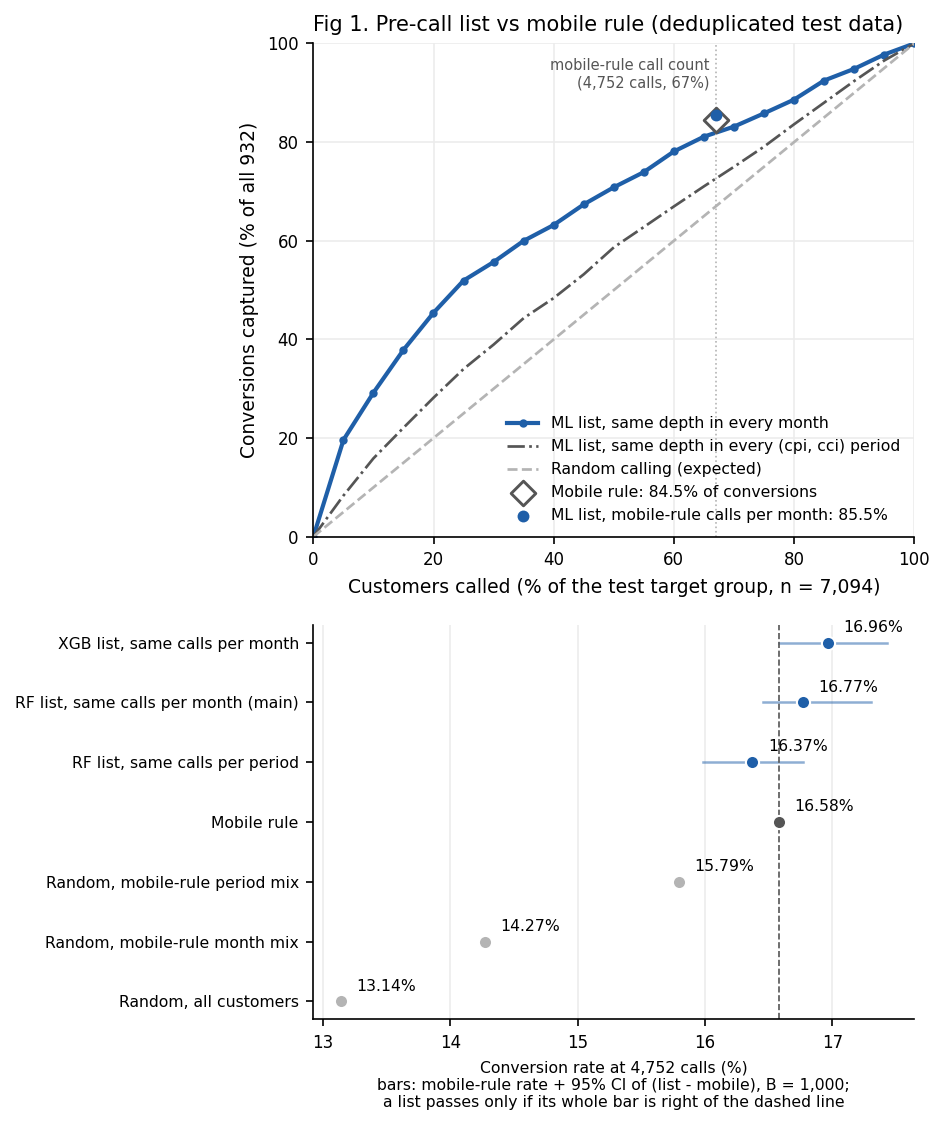

In [70]:
# [Fig 1] 上：同月同深度累積增益；下：與手機規則同通數時各名單的轉換率（圖中文字用英文）
pb_tot_yes = int(pb_y_teT.sum())
fig, (ax, ax2) = plt.subplots(2, 1, figsize=(6.4, 7.6), dpi=150, gridspec_kw={'height_ratios': [1.25, 1]})
ax.plot(100 * np.r_[0, pb_curve['called_share']], 100 * np.r_[0, pb_curve['captured_share']], color=PB_ACCENT, lw=2,
        marker='o', ms=3, label='ML list, same depth in every month')
ax.plot(100 * np.r_[0, pb_curve_p['called_share']], 100 * np.r_[0, pb_curve_p['captured_share']], color=PB_GREY, lw=1.3,
        ls='-.', label='ML list, same depth in every (cpi, cci) period')
ax.plot([0, 100], [0, 100], color=PB_LIGHT, ls='--', lw=1.3, label='Random calling (expected)')
pb_x = 100 * pb_K / len(pb_teT)
ax.axvline(pb_x, color=PB_LIGHT, lw=0.8, ls=':')
ax.text(pb_x - 1, 97, 'mobile-rule call count\n(%s calls, %.0f%%)' % (format(pb_K, ','), pb_x), fontsize=7, color=PB_GREY,
        ha='right', va='top')
pb_mob_cap = 100 * (pb_mob['y'] == 'yes').sum() / pb_tot_yes
pb_ml_cap = 100 * (pb_L['y'] == 'yes').sum() / pb_tot_yes
ax.scatter([pb_x], [pb_mob_cap], s=70, marker='D', facecolor='white', edgecolor=PB_GREY, lw=1.4, zorder=5,
           label='Mobile rule: %.1f%% of conversions' % pb_mob_cap)
ax.scatter([pb_x], [pb_ml_cap], s=22, color=PB_ACCENT, zorder=6,
           label='ML list, mobile-rule calls per month: %.1f%%' % pb_ml_cap)
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.set_xlabel('Customers called (%% of the test target group, n = %s)' % format(len(pb_teT), ','), fontsize=9)
ax.set_ylabel('Conversions captured (%% of all %s)' % format(pb_tot_yes, ','), fontsize=9)
ax.set_title('Fig 1. Pre-call list vs mobile rule (deduplicated test data)', loc='left', fontsize=10)
ax.tick_params(labelsize=8)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(color='#ececec', lw=0.8)
ax.legend(frameon=False, fontsize=7.5, loc='lower right')

pb_pts = [('Random, all customers', pb_r_rand, None, PB_LIGHT),
          ('Random, mobile-rule month mix', pb_r_rand_mm, None, PB_LIGHT),
          ('Random, mobile-rule period mix', pb_r_rand_pm, None, PB_LIGHT),
          ('Mobile rule', pb_r_mob, None, PB_GREY),
          ('RF list, same calls per period', pb_r_Lp, pb_ci_p, PB_ACCENT),
          ('RF list, same calls per month (main)', pb_r_L, pb_ci_m, PB_ACCENT),
          ('XGB list, same calls per month', pb_conv(pb_Lx), pb_ci_x, PB_ACCENT)]
for i, (lab, r, ci, colr) in enumerate(pb_pts):
    if ci is not None:   # 誤差線 = 手機規則轉換率 + (ML − 手機) 的 95% percentile 區間（B = 1,000，計畫判準用的區間）
        ax2.plot([100 * (pb_r_mob + ci['pct_lo']), 100 * (pb_r_mob + ci['pct_hi'])], [i, i], color=PB_ACCENT, lw=1.2, alpha=0.5)
    ax2.scatter([100 * r], [i], s=40, color=colr, zorder=3, edgecolor='white')
    ax2.text(100 * r + 0.12, i + 0.18, '%.2f%%' % (100 * r), fontsize=7.5, color='black')
ax2.axvline(100 * pb_r_mob, color=PB_GREY, lw=0.8, ls='--')
ax2.set_yticks(range(len(pb_pts)))
ax2.set_yticklabels([p[0] for p in pb_pts], fontsize=7.5)
ax2.set_xlabel('Conversion rate at %s calls (%%)\nbars: mobile-rule rate + 95%% CI of (list - mobile), B = 1,000;\n'
               'a list passes only if its whole bar is right of the dashed line' % format(pb_K, ','), fontsize=7.5)
ax2.tick_params(axis='x', labelsize=8)
ax2.spines[['top', 'right']].set_visible(False)
ax2.grid(axis='x', color='#ececec', lw=0.8)
ax2.set_axisbelow(True)
fig.tight_layout()
plt.show()

### B-3 圖 1 解讀：名單 vs 手機規則

**結論：模型確實把會買的人往前排，但「往前排」有一大部分是時期；在手機規則的通數上，名單與手機規則看不出差別（RF 名單的差，95% 區間 [-0.13, +0.72] 個百分點；未做等效性檢定，不能說兩者一樣好）。**

- **上圖**：每個月都只打分數前 d%，前 20% 抓到 45.4% 的成交、前 50% 抓到 70.8%；改成每個時期都只打前 d%，前 20% 只抓到 28.2%、前 50% 58.7% —— 同月曲線左半段的陡峭，有不少來自時期。在手機規則的通數上（67.0% 的客戶），手機規則抓到 84.5% 的成交（菱形），同月配對名單 85.5%（實心點；XGB 86.5%），兩點幾乎重疊。
- **下圖**：同樣 4,752 通，隨機 13.14%、依月份組成 14.27%、依時期組成 15.79%、手機規則 16.58%、RF 同時期 16.37%、RF 同月 16.77%、XGB 同月 16.96%。誤差線 = 手機規則轉換率 + 差的 95% 區間；名單要整條在虛線右邊才算通過，三條都碰到或跨過虛線。
- **商業意義**：這就是業務②「未證實」在圖上的樣子。

In [71]:
# [Part B-4] 業務①：每筆成交的通話成本（A2 目標 ≤ A$20.87，即名單轉換率 ≥ 18%；A2 把它列為 A/B 列報項，不是硬門檻）
pb_cost_tab = pd.DataFrame([
    ('Random calling (test target group, all)', pb_r_rand, pb_actual_cost_per_conv(pb_teT)),
    ('Random, mobile-rule month mix (expected)', pb_r_rand_mm, np.nan),
    ('Mobile rule', pb_r_mob, pb_actual_cost_per_conv(pb_mob)),
    ('ML list, same calls per month (pre-call 11)', pb_r_L, pb_actual_cost_per_conv(pb_L)),
    ('ML list, same calls per month (+contact)', pb_r_Lct, pb_actual_cost_per_conv(pb_Lct)),
    ('ML list, same calls per period (robustness)', pb_r_Lp, pb_actual_cost_per_conv(pb_Lp)),
], columns=['list', 'conv', 'cost per conversion, actual seconds (A$)'])
pb_cost_tab.insert(2, 'cost per conversion, A2 formula c(r)/r (A$)', pb_cost_tab['conv'].map(pb_cost_per_conv))
PB_TARGET_COST = pb_cost_per_conv(0.18)     # A2 目標 A$20.87 的未取整值；差值都用未取整的數字相減後才取整
pb_cost_tab['vs A2 target 20.87'] = pb_cost_tab['cost per conversion, A2 formula c(r)/r (A$)'] - PB_TARGET_COST
pb_cost_tab['conv'] = 100 * pb_cost_tab['conv']
display(pb_cost_tab.rename(columns={'conv': 'conversion %'}).round(2).astype(object).where(pb_cost_tab.rename(columns={'conv': 'conversion %'}).notna(), '-'))

# 描述性：成本 vs 名單深度（不拿來挑截斷點）；同月配對與同時期配對並列
display(pd.DataFrame({'depth %': 100 * pb_curve['depth'], 'month: conv %': 100 * pb_curve['conv'], 'month: c(r)/r': pb_curve['cost_formula'],
                      'month: actual': pb_curve['cost_actual'], 'period: conv %': 100 * pb_curve_p['conv'],
                      'period: c(r)/r': pb_curve_p['cost_formula']}).round(2).T)


def pb_deepest_ok(curve, col='cost_formula'):
    ok = curve[curve[col] <= pb_a2['cost_per_conv_target_18pct']]
    return float(ok['called_share'].max()) if len(ok) else None


pb_dstar, pb_dstar_act, pb_dstar_p = pb_deepest_ok(pb_curve), pb_deepest_ok(pb_curve, 'cost_actual'), pb_deepest_ok(pb_curve_p)
# 單次測試樣本的雜訊：同月配對 50% 深度那一點，轉換率 ± 1.96 個標準誤換算成的成本範圍
pb_r50, pb_n50 = float(pb_curve.loc[pb_curve['depth'] == 0.5, 'conv'].iloc[0]), int(pb_curve.loc[pb_curve['depth'] == 0.5, 'called'].iloc[0])
pb_se50 = np.sqrt(pb_r50 * (1 - pb_r50) / pb_n50)
pb_cost50_rng = (pb_cost_per_conv(pb_r50 + 1.96 * pb_se50), pb_cost_per_conv(pb_r50 - 1.96 * pb_se50))
print('deepest depth with c(r)/r <= A$%.2f: same depth per month %s, per period %s (actual seconds, per month: %s)'
      % (pb_a2['cost_per_conv_target_18pct'], *['%.0f%%' % (100 * v) if v else 'none' for v in (pb_dstar, pb_dstar_p, pb_dstar_act)]))
print('month-matched 50%% depth: conversion %.2f%% (n = %d), cost A$%.2f, 95%% range from sampling noise A$%.2f to A$%.2f'
      % (100 * pb_r50, pb_n50, pb_cost_per_conv(pb_r50), *pb_cost50_rng))


# 外推到 A2 的「一輪」（同樣 2,300 筆成交）：外撥 N = 2,300 / r，整輪成本 = 2,300 x c(r) / r；只能外推，不是測得的
def pb_round_cost(r):
    calls = 2300 / r
    return {'calls': round(calls), 'call_cost': round(2300 * pb_cost_per_conv(r)), 'call_cost_exact': round(2300 * pb_cost_per_conv(r), 2),
            'fewer_calls_vs_pilot_pct': round(100 * (1 - calls / pb_a2['pilot_target_n']), 1)}


pb_ext = {'ml_list': pb_round_cost(pb_r_L), 'ml_list_period': pb_round_cost(pb_r_Lp), 'mobile': pb_round_cost(pb_r_mob),
          'a2_target_18pct': pb_round_cost(0.18)}
print('one A2 round (2,300 conversions):', pb_ext)
A3_KPI['part_b']['b1'] = {
    'rows': [{'list': r['list'], 'conv_pct': a3_r(r['conv'], 2),
              'cost_formula': a3_r(r['cost per conversion, A2 formula c(r)/r (A$)'], 2),
              'cost_actual': None if pd.isna(r['cost per conversion, actual seconds (A$)']) else a3_r(r['cost per conversion, actual seconds (A$)'], 2)}
             for _, r in pb_cost_tab.iterrows()],
    'ml_cost_formula': a3_r(pb_cost_per_conv(pb_r_L), 2), 'ml_cost_actual': a3_r(pb_actual_cost_per_conv(pb_L), 2),
    'ml_period_cost_formula': a3_r(pb_cost_per_conv(pb_r_Lp), 2),
    'ml_minus_target': a3_r(pb_cost_per_conv(pb_r_L) - PB_TARGET_COST, 2),
    'mobile_minus_target': a3_r(pb_cost_per_conv(pb_r_mob) - PB_TARGET_COST, 2),
    'random_minus_ml': a3_r(pb_cost_per_conv(pb_r_rand) - pb_cost_per_conv(pb_r_L), 2),
    'mobile_minus_ml': a3_r(pb_cost_per_conv(pb_r_mob) - pb_cost_per_conv(pb_r_L), 2),
    'mobile_cost_formula': a3_r(pb_cost_per_conv(pb_r_mob), 2), 'mobile_cost_actual': a3_r(pb_actual_cost_per_conv(pb_mob), 2),
    'random_cost_formula': a3_r(pb_cost_per_conv(pb_r_rand), 2), 'random_mm_cost_formula': a3_r(pb_cost_per_conv(pb_r_rand_mm), 2),
    'target': pb_a2['cost_per_conv_target_18pct'], 'pass': bool(pb_cost_per_conv(pb_r_L) <= pb_a2['cost_per_conv_target_18pct']),
    'deepest_ok_depth_pct': None if pb_dstar is None else a3_r(100 * pb_dstar, 1),
    'deepest_ok_depth_actual_pct': None if pb_dstar_act is None else a3_r(100 * pb_dstar_act, 1),
    'deepest_ok_depth_period_pct': None if pb_dstar_p is None else a3_r(100 * pb_dstar_p, 1),
    'depth50_conv_pct': a3_r(100 * pb_r50, 2), 'depth50_n': pb_n50, 'depth50_cost': a3_r(pb_cost_per_conv(pb_r50), 2),
    'depth50_cost_low': a3_r(pb_cost50_rng[0], 2), 'depth50_cost_high': a3_r(pb_cost50_rng[1], 2),
    'curve': [{'depth_pct': a3_r(100 * r['called_share'], 1), 'conv_pct': a3_r(100 * r['conv'], 2),
               'captured_pct': a3_r(100 * r['captured_share'], 1),
               'cost_formula': a3_r(r['cost_formula'], 2), 'cost_actual': a3_r(r['cost_actual'], 2)} for _, r in pb_curve.iterrows()],
    'curve_period': [{'depth_pct': a3_r(100 * r['called_share'], 1), 'conv_pct': a3_r(100 * r['conv'], 2),
                      'captured_pct': a3_r(100 * r['captured_share'], 1), 'cost_formula': a3_r(r['cost_formula'], 2)}
                     for _, r in pb_curve_p.iterrows()],
    'one_round_extrapolation': pb_ext,
}

,list,conversion %,"cost per conversion, A2 formula c(r)/r (A$)","cost per conversion, actual seconds (A$)",vs A2 target 20.87
0,"Random calling (test target group, all)",13.14,27.17,27.14,6.3
1,"Random, mobile-rule month mix (expected)",14.27,25.31,-,4.45
2,Mobile rule,16.58,22.32,22.22,1.46
3,"ML list, same calls per month (pre-call 11)",16.77,22.11,21.47,1.25
4,"ML list, same calls per month (+contact)",16.9,21.98,21.41,1.11
5,"ML list, same calls per period (robustness)",16.37,22.56,21.98,1.69


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
depth %,5.00,10.00,15.00,20.00,25.00,30.00,35.00,40.00,45.00,50.00,55.00,60.00,65.00,70.00,75.00,80.00,85.00,90.00,95.00,100.00
month: conv %,51.40,38.36,33.18,29.83,27.30,24.39,22.52,20.76,19.67,18.62,17.66,17.10,16.39,15.60,15.03,14.55,14.30,13.85,13.52,13.14
month: c(r)/r,9.80,11.83,13.07,14.11,15.06,16.40,17.45,18.60,19.42,20.30,21.20,21.76,22.54,23.48,24.23,24.90,25.28,25.97,26.51,27.17
month: actual,8.05,9.80,11.43,12.67,13.41,14.75,16.01,17.44,18.37,19.19,20.17,20.90,21.79,22.89,23.79,24.53,25.02,25.84,26.46,27.14
period: conv %,21.88,20.87,19.34,18.51,17.87,17.06,16.63,15.89,15.53,15.41,15.00,14.66,14.36,14.08,13.85,13.73,13.60,13.48,13.35,13.14
period: c(r)/r,17.85,18.52,19.68,20.40,20.99,21.81,22.27,23.13,23.58,23.73,24.27,24.74,25.19,25.61,25.96,26.16,26.38,26.57,26.80,27.17


deepest depth with c(r)/r <= A$20.87: same depth per month 50%, per period 20% (actual seconds, per month: 55%)
month-matched 50% depth: conversion 18.62% (n = 3544), cost A$20.30, 95% range from sampling noise A$19.24 to A$21.51
one A2 round (2,300 conversions): {'ml_list': {'calls': 13713, 'call_cost': 50861, 'call_cost_exact': 50860.64, 'fewer_calls_vs_pilot_pct': 22.3}, 'ml_list_period': {'calls': 14048, 'call_cost': 51887, 'call_cost_exact': 51887.39, 'fewer_calls_vs_pilot_pct': 20.4}, 'mobile': {'calls': 13870, 'call_cost': 51341, 'call_cost_exact': 51340.82, 'fewer_calls_vs_pilot_pct': 21.4}, 'a2_target_18pct': {'calls': 12778, 'call_cost': 47992, 'call_cost_exact': 47992.13, 'fewer_calls_vs_pilot_pct': 27.6}}


### B-4 解讀：業務① 每筆成交的通話成本（A2 目標 ≤ A\$20.87）

**結論：與手機規則同通數的名單每筆成交 A\$22.11，未達 A\$20.87；名單變淺成本會下降，但能降多少取決於時期，截斷深度必須由 A/B 校準，不能從這份離線資料挑。**

- **觀察**：同月配對名單 A\$22.11（A2 情境公式 c(r)/r）、A\$21.47（實際秒數）；同時期配對 A\$22.56；手機規則 A\$22.32、隨機外撥 A\$27.17（A2 全檔為 A\$27.35）；XGB 名單 A\$21.91。RF 名單比隨機省 A\$5.06、比手機規則只省 A\$0.21，比目標高 A\$1.25（手機規則高 A\$1.46）→ 未達。
- **描述性曲線（不拿來挑截斷點）**：同月配對時，每月只打前 50% 的成本 A\$20.30（轉換率 18.62%）；但同時期配對時要淺到約 20% 才低於 A\$20.87，50% 時是 A\$23.73。兩種配對差這麼多，表示「淺一點就達標」的離線證據大半靠時期挑選。單次測試樣本本身也有雜訊：50% 那一點只有 3,544 人，轉換率的 95% 範圍換算成本約 A\$19.24–A\$21.51，跨過目標。
- **外推一輪**（同樣 2,300 筆成交）：同月配對名單約 13,713 通、A\$50,861（A2：現況 A\$62,905、目標約 A\$48,000），目標層級的對照見 B-13 與圖 7。
- **商業意義與注意**：① 在 A2 是 A/B 列報項，不是硬門檻；名單變淺會漏掉更多成交，是產能與營收的取捨，深度要在 A/B 中校準。時薪 A\$50、每通時長維持試點平均都是 A2 的假設；實際秒數用到 duration，只當事後成本帳。

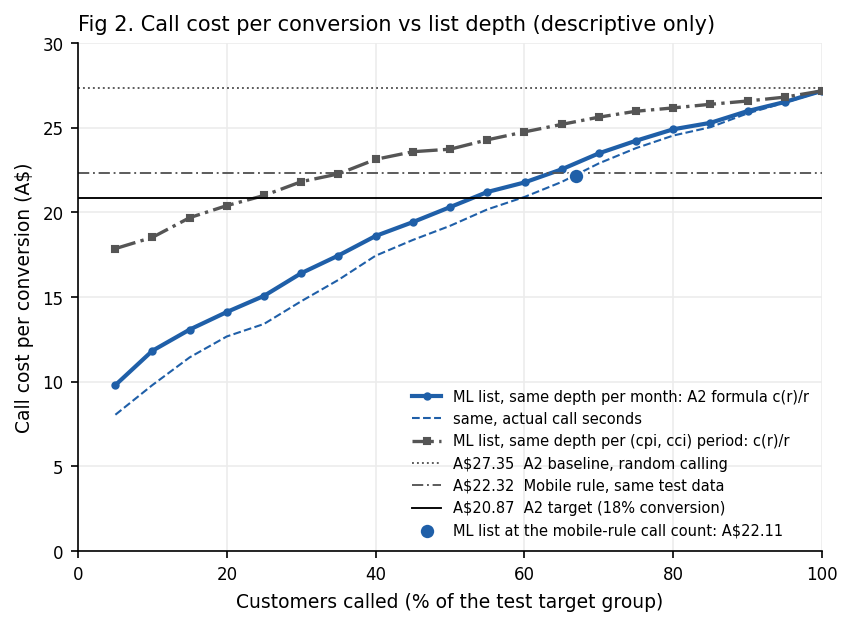

In [72]:
# [Fig 2] 每筆成交的通話成本 vs 名單深度（描述性；不拿來挑截斷點）
fig, ax = plt.subplots(figsize=(6.4, 4.4), dpi=150)
ax.plot(100 * pb_curve['called_share'], pb_curve['cost_formula'], color=PB_ACCENT, lw=2, marker='o', ms=3,
        label='ML list, same depth per month: A2 formula c(r)/r')
ax.plot(100 * pb_curve['called_share'], pb_curve['cost_actual'], color=PB_ACCENT, lw=1, ls='--', label='same, actual call seconds')
ax.plot(100 * pb_curve_p['called_share'], pb_curve_p['cost_formula'], color=PB_GREY, lw=1.6, ls='-.', marker='s', ms=2.5,
        label='ML list, same depth per (cpi, cci) period: c(r)/r')
for yv, lab, ls in [(pb_a2['cost_per_conv_pilot'], 'A2 baseline, random calling', ':'),
                    (pb_cost_per_conv(pb_r_mob), 'Mobile rule, same test data', (0, (6, 2, 1, 2))),
                    (pb_a2['cost_per_conv_target_18pct'], 'A2 target (18% conversion)', '-')]:
    ax.axhline(yv, color=PB_GREY if ls != '-' else 'black', ls=ls, lw=0.9, label=r'A\$%.2f  %s' % (yv, lab))
ax.scatter([100 * pb_K / len(pb_teT)], [pb_cost_per_conv(pb_r_L)], s=55, color=PB_ACCENT, edgecolor='white', zorder=6,
           label=r'ML list at the mobile-rule call count: A\$%.2f' % pb_cost_per_conv(pb_r_L))
ax.set_xlim(0, 100)
ax.set_ylim(0, max(30, float(pb_curve_p['cost_formula'].max()) + 2))
ax.set_xlabel('Customers called (% of the test target group)', fontsize=9)
ax.set_ylabel(r'Call cost per conversion (A\$)', fontsize=9)
ax.set_title('Fig 2. Call cost per conversion vs list depth (descriptive only)', loc='left', fontsize=10)
ax.tick_params(labelsize=8)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(color='#ececec', lw=0.8)
ax.legend(frameon=False, fontsize=7, loc='lower right')
plt.show()

### B-4 圖 2 解讀：每筆成交成本 vs 名單深度

**結論：名單越深成本越高；同時期配對的成本線整條在同月配對之上，所以「多淺才達標」沒有可靠的離線答案。**

- 同月配對：前 20% 約 A\$14.11、與手機同通數時 A\$22.11，全部都打回到 A\$27.17（測試集的隨機外撥；A2 全檔 A\$27.35）。實際秒數（虛線）略低於 A2 公式：名單裡成交者的實際通話比 A2 的平均短一些。
- 同時期配對：前 20% 已是 A\$20.40、前 50% A\$23.73。
- 這張圖只描述成本隨深度上升；截斷點不由它決定。

In [73]:
# [Part B-5] 混淆矩陣（測試集目標組，K = 手機通數 4,752）
# 主表：B-3 的同月同通數名單（外撥日不能換月份，這是實際做得到的名單）
# 參考：全體單一門檻 t（分數第 K 名）。它含月份組成（B-3 的反例），只因為對照組沒有月份，B-6 的增量比較必須用它
pb_t = float(np.sort(pb_teT['s'].to_numpy())[::-1][pb_K - 1])
pb_yes = pb_y_teT.astype(bool)


def pb_confusion(called):
    tp, fp = int((called & pb_yes).sum()), int((called & ~pb_yes).sum())
    fn, tn = int((~called & pb_yes).sum()), int((~called & ~pb_yes).sum())
    return {'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn, 'list_size': int(called.sum()),
            'precision_pct': a3_r(100 * tp / (tp + fp), 2), 'recall_pct': a3_r(100 * tp / (tp + fn), 2),
            'fp_cost_aud': round(fp * PB_CALL_NO), 'tn_saving_aud': round(tn * PB_CALL_NO)}


pb_cm_m = pb_confusion(pb_teT.index.isin(pb_L.index))
pb_cm_p = pb_confusion((pb_teT['s'] >= pb_t).to_numpy())
pb_mob_rec = (pb_mob['y'] == 'yes').sum() / pb_y_teT.sum()
display(pd.DataFrame([
    ('TP: on the list, bought', pb_cm_m['TP'], pb_cm_p['TP'], '成交電話每通約 A$%.2f＋一份折扣；其中多少人「不打也會買」看 B-6、B-8' % PB_CALL_YES),
    ('FP: on the list, did not buy', pb_cm_m['FP'], pb_cm_p['FP'], '白打一通，每通約 A$%.2f（主表合計約 A$%s）' % (PB_CALL_NO, format(pb_cm_m['fp_cost_aud'], ','))),
    ('FN: not on the list, bought', pb_cm_m['FN'], pb_cm_p['FN'], '試點裡他們有被打；不打時可能仍會買，損失只有「打了才會買」的那部分（B-8）'),
    ('TN: not on the list, did not buy', pb_cm_m['TN'], pb_cm_p['TN'], '省下的電話，每通約 A$%.2f（主表合計約 A$%s）' % (PB_CALL_NO, format(pb_cm_m['tn_saving_aud'], ','))),
    ('precision % (= list conversion)', pb_cm_m['precision_pct'], pb_cm_p['precision_pct'], ''),
    ('recall %% (mobile rule: %.1f%%)' % (100 * pb_mob_rec),pb_cm_m['recall_pct'], pb_cm_p['recall_pct'], ''),
], columns=['cell', 'same calls per month (main)', 'pooled cut-off t (reference)', '商業意義（A2 假設：時薪 A$50、只計通話時間）']))
print('pooled cut-off score t = %.4f; both lists have %d customers' % (pb_t, pb_K))
A3_KPI['part_b']['confusion'] = {'K': pb_K, 'threshold': a3_r(pb_t), 'month_matched': pb_cm_m, 'pooled': pb_cm_p,
                                 'mobile_recall_pct': a3_r(100 * pb_mob_rec, 2),
                                 'pooled_minus_month_precision_pp': a3_r(pb_cm_p['precision_pct'] - pb_cm_m['precision_pct'], 2),
                                 'call_cost_no_exact': a3_r(PB_CALL_NO, 4)}

,cell,same calls per month (main),pooled cut-off t (reference),商業意義（A2 假設：時薪 A$50、只計通話時間）
0,"TP: on the list, bought",797.00,834.00,成交電話每通約 A$6.90＋一份折扣；其中多少人「不打也會買」看 B-6、B-8
1,"FP: on the list, did not buy",3955.00,3918.00,"白打一通，每通約 A$3.07（主表合計約 A$12,125）"
2,"FN: not on the list, bought",135.00,98.00,試點裡他們有被打；不打時可能仍會買，損失只有「打了才會買」的那部分（B-8）
3,"TN: not on the list, did not buy",2207.00,2244.00,"省下的電話，每通約 A$3.07（主表合計約 A$6,766）"
4,precision % (= list conversion),16.77,17.55,
5,recall % (mobile rule: 84.5%),85.52,89.48,


pooled cut-off score t = 0.3154; both lists have 4752 customers


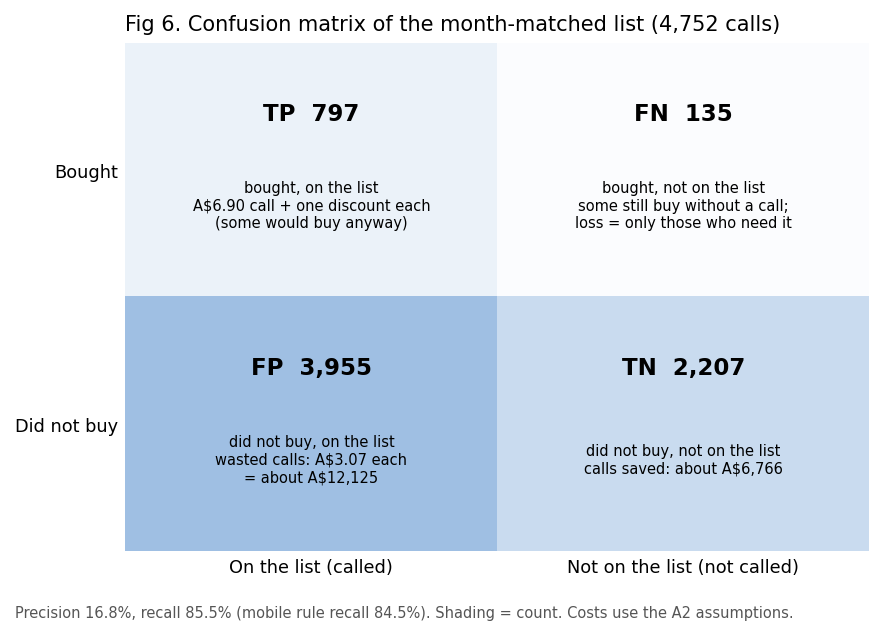

In [74]:
# [Fig 6] 混淆矩陣（B-5 主表：同月同通數名單）畫成 2×2；格內是人數與通話成本（A2 假設：時薪 A$50、只計通話時間）
from matplotlib.colors import LinearSegmentedColormap
pb_cmg = np.array([[pb_cm_m['TP'], pb_cm_m['FN']], [pb_cm_m['FP'], pb_cm_m['TN']]])
fig, ax = plt.subplots(figsize=(6.4, 4.4), dpi=150)
ax.imshow(pb_cmg / pb_cmg.max(), cmap=LinearSegmentedColormap.from_list('a3', ['#ffffff', '#9fbfe3']), vmin=0, vmax=1, aspect='auto')
pb_cm_txt = [[('TP  %s' % format(pb_cm_m['TP'], ','), 'bought, on the list\nA\\$%.2f call + one discount each\n(some would buy anyway)' % PB_CALL_YES),
              ('FN  %s' % format(pb_cm_m['FN'], ','), 'bought, not on the list\nsome still buy without a call;\nloss = only those who need it')],
             [('FP  %s' % format(pb_cm_m['FP'], ','), 'did not buy, on the list\nwasted calls: A\\$%.2f each\n= about A\\$%s' % (PB_CALL_NO, format(pb_cm_m['fp_cost_aud'], ','))),
              ('TN  %s' % format(pb_cm_m['TN'], ','), 'did not buy, not on the list\ncalls saved: about A\\$%s' % format(pb_cm_m['tn_saving_aud'], ','))]]
for i in range(2):
    for j in range(2):
        head, body = pb_cm_txt[i][j]
        ax.text(j, i - 0.22, head, ha='center', va='center', fontsize=11, fontweight='bold')
        ax.text(j, i + 0.14, body, ha='center', va='center', fontsize=7)
ax.set_xticks([0, 1])
ax.set_xticklabels(['On the list (called)', 'Not on the list (not called)'], fontsize=8.5)
ax.set_yticks([0, 1])
ax.set_yticklabels(['Bought', 'Did not buy'], fontsize=8.5)
ax.tick_params(length=0)
for sp in ax.spines.values():
    sp.set_visible(False)
ax.set_title('Fig 6. Confusion matrix of the month-matched list (%s calls)' % format(pb_K, ','), loc='left', fontsize=10)
fig.text(0.01, 0.01, 'Precision %.1f%%, recall %.1f%% (mobile rule recall %.1f%%). Shading = count. Costs use the A2 assumptions.'
         % (pb_cm_m['precision_pct'], pb_cm_m['recall_pct'], 100 * pb_mob_rec), fontsize=7, color=PB_GREY)
plt.show()

### B-5 解讀：混淆矩陣（上表與圖 6）

**結論：在實際做得到的同月配對名單上，精確率 16.77%、召回率 85.52%，和手機規則的召回率 84.55% 相近；混淆矩陣看不到「打給本來就會買的人」這種錯誤，它藏在 TP 裡（B-8 估算）。**

- **主表與圖 6（同月同通數名單，4,752 人）**：成交（TP）797、白打（FP）3,955；名單外仍成交（FN）135、名單外未成交（TN）2,207。
- **參考（單一門檻名單）**：TP 834、FP 3,918、FN 98、TN 2,244，精確率 17.55%、召回率 89.48%。這份名單含月份組成（B-3 的反例），精確率比同月配對高 0.78 pp；只因為對照組沒有月份，B-6 的增量比較必須用它：門檻同時作用在兩組，增量不受月份挑選影響，但名單轉換率 r 偏高，所以 ⑤ 的絕對值只作示算。
- **錢花在哪**（A2 假設）：FP 每通約 A\$3.07，主表合計約 A\$12,125；TN 是省下的電話，約 A\$6,766。
- **看不到的錯誤**：A2 表 4 註指出，2:1 下每人代價最高的是「打給本來就會買的人」（白送一份折扣，再加一通約 A\$6.90 的成交電話）—— 它藏在 TP 裡；FN 也分不出是不是本來就會買。B-8 用對照組估算，並看折扣額 D 改變時排序會不會變。
- **商業意義**：調低門檻可以少漏成交，但每多一人就多一通約 A\$3.07 的電話，還可能多送折扣給本來就會買的人；門檻是成本決策，不是統計決策。

In [75]:
# [Part B-6] 業務③（上線硬門檻）、④（列報）：同門檻對照組比較
# 用同一個撥號前模型替「沒被打」的對照組評分（模型不用 duration / contact / month，對照組也能評分）。
# 入選門檻 t = 測試集目標組第 K 名的分數，K = 測試集目標組的手機通數；對照組沒有月份，所以只能用全體單一門檻。
# 門檻同時作用在兩組，增量不受月份挑選影響；但名單轉換率 r 含月份組成而偏高（B-5），⑤ 的絕對值因此只作示算。
# bootstrap：名單與同門檻對照組各自有放回重抽（B = 1,000），門檻固定為 t；同一批重抽也給出④（對照 ÷ 名單）的區間。
# 時期分層（穩健性）：門檻仍用全體 t；在每個 (cpi, cci) 時期內比較名單與對照組（兩邊都至少 20 人的時期才納入），
# 再依名單人數加權；另報不設 20 人下限的版本。分層增量的區間：各時期內兩組各自重抽（B = 1,000），再同樣加權。
def pb_uplift(teT, teC, K, B=1000):
    t = float(np.sort(teT['s'].to_numpy())[::-1][K - 1])
    L, Cc = teT[teT['s'] >= t], teC[teC['s'] >= t]
    yL, yC = (L['y'] == 'yes').to_numpy(), (Cc['y'] == 'yes').to_numpy()
    rng = np.random.default_rng(PB_SEED)
    bL, bC = np.zeros(B), np.zeros(B)
    for b in range(B):
        bL[b] = yL[rng.integers(0, len(yL), len(yL))].mean()
        bC[b] = yC[rng.integers(0, len(yC), len(yC))].mean()
    lo, hi = np.percentile(bL - bC, [2.5, 97.5])
    wlo, whi = np.percentile(bC / bL, [2.5, 97.5])

    def strat(min_n):
        num = den = 0
        cells = []
        for p, gT in L.groupby('period'):
            gC = Cc[Cc['period'] == p]
            if len(gT) >= min_n and len(gC) >= min_n:
                num += len(gT) * (pb_conv(gT) - pb_conv(gC))
                den += len(gT)
                cells.append((len(gT), pb_conv(gT), len(gC), pb_conv(gC)))
        return (num / den if den else None), den, cells
    ps, pden, pcells = strat(20)
    ps0, pden0, _ = strat(1)
    rng2 = np.random.default_rng(PB_SEED)
    sb = np.zeros(B)
    for nT_, rT_, nC_, rC_ in pcells:     # 一個比例的有放回重抽 = 二項分配
        sb += nT_ * (rng2.binomial(nT_, rT_, B) / nT_ - rng2.binomial(nC_, rC_, B) / nC_)
    slo, shi = np.percentile(sb / pden, [2.5, 97.5]) if pden else (np.nan, np.nan)
    rL, rC = yL.mean(), yC.mean()
    rT_all, rC_all = pb_conv(teT), pb_conv(teC)
    rep = {'threshold': a3_r(t), 'K': int(K), 'list_n': len(L), 'control_above_n': len(Cc),
           'target_above_share_pct': a3_r(100 * len(L) / len(teT), 1), 'control_above_share_pct': a3_r(100 * len(Cc) / len(teC), 1),
           'list_conv_pct': a3_r(100 * rL, 2), 'control_above_conv_pct': a3_r(100 * rC, 2),
           'uplift_pp': a3_r(100 * (rL - rC), 2), 'uplift_ci_low_pp': a3_r(100 * lo, 2), 'uplift_ci_high_pp': a3_r(100 * hi, 2),
           'uplift_per_1000_calls': a3_r(1000 * (rL - rC), 1),
           'would_buy_share_pct': a3_r(100 * rC / rL, 1),
           'would_buy_ci_low_pct': a3_r(100 * wlo, 1), 'would_buy_ci_high_pct': a3_r(100 * whi, 1),
           'period_stratified_uplift_pp': None if ps is None else a3_r(100 * ps, 2),
           'period_stratified_ci_low_pp': a3_r(100 * slo, 2), 'period_stratified_ci_high_pp': a3_r(100 * shi, 2),
           'period_coverage_pct': a3_r(100 * pden / len(L), 1),
           'period_stratified_uplift_nomin_pp': None if ps0 is None else a3_r(100 * ps0, 2),
           'period_coverage_nomin_pct': a3_r(100 * pden0 / len(L), 1),
           'overall_target_conv_pct': a3_r(100 * rT_all, 2), 'overall_control_conv_pct': a3_r(100 * rC_all, 2),
           'overall_uplift_pp': a3_r(100 * (rT_all - rC_all), 2),
           'overall_would_buy_share_pct': a3_r(100 * rC_all / rT_all, 1),
           'test_target_n': len(teT), 'test_control_n': len(teC)}
    ex = {'t': t, 'r': rL, 'rC': rC, 'u': rL - rC, 'u_period': ps, 'rT_all': rT_all, 'rC_all': rC_all, 'n_list': len(L),
          'teT': teT, 'teC': teC}
    return rep, ex


pb_up, pb_upx = pb_uplift(pb_teT, pb_teC, pb_K)

# 敏感度：原始資料（不去重）用同樣的清理、同樣 0.4 / 123 切分、同樣固定的超參數，只用原始訓練集目標組重訓
pb_rtr, pb_rte = train_test_split(pb_raw, test_size=0.4, random_state=RANDOM_SATE)
pb_rtrT = pb_rtr[pb_rtr['campaign'] == '1']
pb_raw_model = pb_pipeline(pb_rf(n_jobs=-1, max_depth=pb_main_params['max_depth'],
                                 min_samples_leaf=pb_main_params['min_samples_leaf']), PB_CAT)
pb_raw_model.fit(pb_rtrT[PB_FEATURES], (pb_rtrT['y'] == 'yes').astype(int))
pb_raw_model.set_params(clf__n_jobs=1)
pb_rteT = pb_rte[pb_rte['campaign'] == '1'].copy()
pb_rteC = pb_rte[pb_rte['campaign'] == '0'].copy()
for d_ in (pb_rteT, pb_rteC):
    d_['s'] = pb_raw_model.predict_proba(d_[PB_FEATURES])[:, 1]
    d_['period'] = d_['cons.price.idx'].map('{:.3f}'.format) + ' | ' + d_['cons.conf.idx'].map('{:.1f}'.format)
pb_K_raw = int((pb_rteT['contact'] == 'cellular').sum())
pb_up_raw, pb_upx_raw = pb_uplift(pb_rteT, pb_rteC, pb_K_raw)
pb_up_raw['raw_test_target_auc'] = a3_r(pb_auc((pb_rteT['y'] == 'yes').to_numpy(), pb_rteT['s']))
pb_up_raw['raw_train_target_rows'] = len(pb_rtrT)

pb_up_show = pd.DataFrame({'deduplicated (main)': pd.Series(pb_up, dtype=object),
                           'raw data (sensitivity)': pd.Series(pb_up_raw, dtype=object)})
display(pb_up_show.where(pb_up_show.notna(), '-'))   # '-' = 只有原始資料版才有的欄位
A3_KPI['part_b']['b3b4'] = {'dedup': pb_up, 'raw': pb_up_raw,
                             'raw_minus_raw_strat_pp': a3_r(100 * (pb_upx_raw['u'] - pb_upx_raw['u_period']), 2),
                             'strat_raw_minus_dedup_pp': a3_r(100 * (pb_upx_raw['u_period'] - pb_upx['u_period']), 2)}

,deduplicated (main),raw data (sensitivity)
K,4752,4772
control_above_conv_pct,17.09,13.64
control_above_n,4559,5805
control_above_share_pct,64.4,61.8
list_conv_pct,17.55,17.67
list_n,4752,4772
overall_control_conv_pct,13.02,10.05
overall_target_conv_pct,13.14,13.35
overall_uplift_pp,0.12,3.29
overall_would_buy_share_pct,99.1,75.3


### B-6 解讀：業務③ 增量（上線硬門檻）與業務④ 本來就會買的比例（列報）

**結論：不控制時期時，增量隨重複列的處理落在 +0.46 到 +4.02 個百分點；控制 (cpi, cci) 時期後兩個口徑分別為 -0.97 與 +0.75，兩個區間都含 0。離線無法判定增量為正（未證實）。④ 兩個口徑的區間都高於 50% 兩平點（未達）。**

- **去重（主口徑）**：分數 ≥ 門檻的目標組名單 4,752 人、轉換率 17.55%；對照組中分數同樣 ≥ 門檻的 4,559 人、17.09% → 增量 +0.46 pp（95% 區間 [-1.03, +1.90]，含 0）；成交者中本來就會買 97.4%（區間 89.7%–106.2%）。
- **原始資料（敏感度）**：同樣流程，名單 17.67% 對 13.64% → 增量 +4.02 pp [+2.64, +5.42]；本來就會買 77.2%（區間 70.4%–84.4%），和 A2 試點全體的 76.2% 相近，沒有看到 A2 擔心的「第一步會升高」。
- **控制時期之後**：門檻仍用全體 t，在每個 (cpi, cci) 時期內比較名單與對照組（兩邊都至少 20 人的時期才納入，涵蓋名單的 98.9%／99.3%），再依名單人數加權：去重 -0.97 pp（區間 [-2.36, +0.44]）、原始 +0.75 pp（區間 [-0.67, +2.10]）；不設 20 人下限時 -0.89／+0.75。點估計都在 ±1 個百分點內，但區間寬，無法判定正負。
- **原始口徑的 +4 pp 從哪來：兩件事都有份**。(1) 時期組成：原始口徑在各時期內比只剩 +0.75，比未分層少了 3.27 個百分點 —— 大部分來自兩組在各時期的人數組成不同。(2) 重複列的處理：分層後兩個口徑仍差 1.72 個百分點（-0.97 對 +0.75）：被刪的列幾乎全在對照組，去重同時改變了對照組的轉換率與它在各時期的組成。兩個分層區間部分重疊，這 1.72 個百分點的差本身也還不確定。
- **組成與方法**：分數 ≥ 門檻的比例，目標組 67.0%、對照組 64.4%（去重），兩組並非完全可比。bootstrap：名單與同門檻對照組各自有放回重抽（B = 1,000），門檻固定為 t；分時期的區間是在每個時期內兩組各自重抽後再加權。
- **商業意義**：③ 是上線硬門檻，但離線只能看方向，方向又取決於資料版本與是否控制時期 —— 這正是 A2 把 ③ 的確認排在 A/B（常設對照組同樣評分、不外撥）的理由。④ 高於 50% 表示 2:1 下名單每多打一通都虧（與 B-7 一致）。

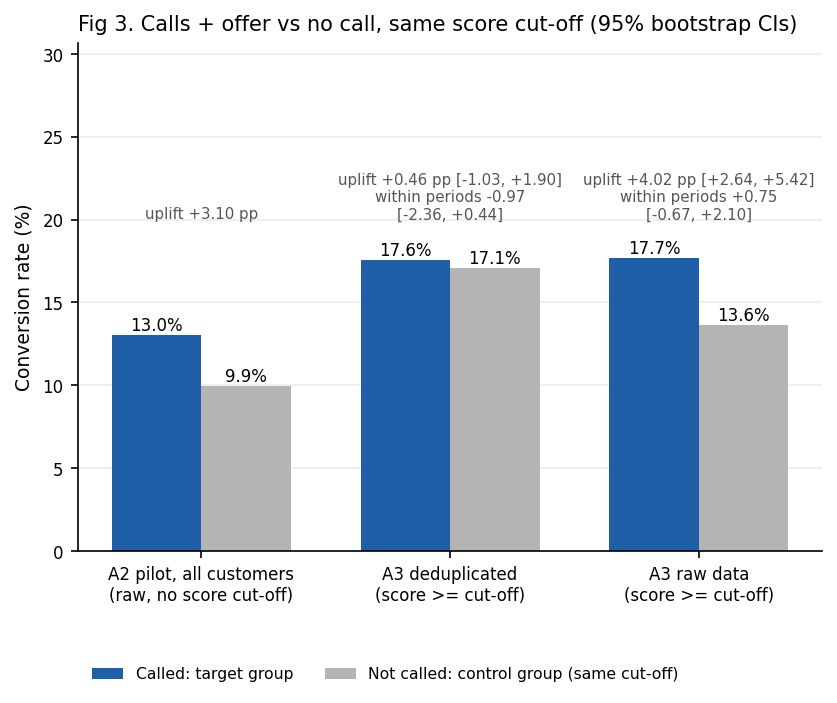

In [76]:
# [Fig 3] 名單 vs 同門檻對照組的轉換率（去重 vs 原始資料）；A2 試點全體當參考
fig, ax = plt.subplots(figsize=(6.4, 4.4), dpi=150)
pb_groups = ['A2 pilot, all customers\n(raw, no score cut-off)', 'A3 deduplicated\n(score >= cut-off)', 'A3 raw data\n(score >= cut-off)']
pb_called_v = [pb_a2['pilot_target_conv_pct'], pb_up['list_conv_pct'], pb_up_raw['list_conv_pct']]
pb_ctrl_v = [pb_a2['pilot_control_conv_pct'], pb_up['control_above_conv_pct'], pb_up_raw['control_above_conv_pct']]
pb_notes = ['uplift %+.2f pp' % pb_a2['pilot_uplift_pp']] + [
    'uplift %+.2f pp [%+.2f, %+.2f]\nwithin periods %+.2f\n[%+.2f, %+.2f]' % (u_['uplift_pp'], u_['uplift_ci_low_pp'], u_['uplift_ci_high_pp'],
                                                                         u_['period_stratified_uplift_pp'], u_['period_stratified_ci_low_pp'],
                                                                         u_['period_stratified_ci_high_pp']) for u_ in (pb_up, pb_up_raw)]
xg = np.arange(3)
w = 0.36
b1 = ax.bar(xg - w / 2, pb_called_v, w, color=PB_ACCENT, label='Called: target group')
b2 = ax.bar(xg + w / 2, pb_ctrl_v, w, color=PB_LIGHT, label='Not called: control group (same cut-off)')
for bars in (b1, b2):
    for b in bars:
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.3, '%.1f%%' % b.get_height(), ha='center', fontsize=8)
ymax = max(pb_called_v + pb_ctrl_v)
for i, note in enumerate(pb_notes):
    ax.text(i, ymax + 2.2, note, ha='center', fontsize=7.2, color=PB_GREY, va='bottom')
ax.set_xticks(xg)
ax.set_xticklabels(pb_groups, fontsize=8)
ax.set_ylim(0, ymax + 13)
ax.set_ylabel('Conversion rate (%)', fontsize=9)
ax.set_title('Fig 3. Calls + offer vs no call, same score cut-off (95% bootstrap CIs)', loc='left', fontsize=10)
ax.tick_params(axis='y', labelsize=8)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', color='#ececec', lw=0.8)
ax.set_axisbelow(True)
ax.legend(frameon=False, fontsize=7.5, loc='upper left', bbox_to_anchor=(0, -0.2), ncol=2)
plt.show()

### B-6 圖 3 解讀：打電話＋優惠 vs 不打（同一分數門檻）

**結論：被模型排到前面的人，不打也差不多會買 —— 名單轉換率高不等於打電話有用。**

- 左：A2 試點全體（原始資料、沒有門檻）13.04% 對 9.94%，增量 3.10 pp。中：去重後名單與對照組幾乎一樣高。右：原始資料下名單高約 4 pp（區間不含 0），但在各時期內只剩 +0.75，區間含 0（圖上的 within periods）。
- 中、右兩組的藍柱都比左邊的全體高，表示模型確實把「會買的人」往前排；A2 的第二步（增量模型）就是要把「會買」和「打了才會買」分開。

In [77]:
# [Part B-7] 業務⑤（上線硬門檻）只能示算：式 1 每通淨值（相對於不外撥）= D x (2u - r) - c(r)
# u = 增量（名單轉換率 − 同門檻對照轉換率），r = 名單轉換率，收益 = 2D（A2 的 2:1 假設），c(r) = 每通通話成本
# 全部用未取整的 u、r 計算，只在顯示時取整
PB_D = 36.0     # A2 附錄 A 的「兩平折扣額」約 A$36，只是示例，不是真實折扣


def pb_net(u, r):
    k = 2 * u - r
    return {'u_pp': a3_r(100 * u, 2), 'r_pct': a3_r(100 * r, 2), 'net_D_per_call_excl_call_cost': a3_r(k, 4),
            'net_D_per_1000_calls': a3_r(1000 * k, 1), 'call_cost_per_call': a3_r(pb_call_cost(r), 2),
            'net_aud_per_call_at_D36': a3_r(PB_D * k - pb_call_cost(r), 2),
            'net_aud_per_1000_calls_at_D36': a3_r(1000 * (PB_D * k - pb_call_cost(r)), 0),
            'break_even_D': a3_r(pb_call_cost(r) / k, 2) if k > 0 else None,
            'revenue_multiple_needed': a3_r(r / u, 1) if u > 0 else None}


pb_b5 = {
    'dedup_ml_list': pb_net(pb_upx['u'], pb_upx['r']),
    'dedup_random': pb_net(pb_upx['rT_all'] - pb_upx['rC_all'], pb_upx['rT_all']),
    'raw_ml_list': pb_net(pb_upx_raw['u'], pb_upx_raw['r']),
    'raw_random': pb_net(pb_upx_raw['rT_all'] - pb_upx_raw['rC_all'], pb_upx_raw['rT_all']),
    'a2_pilot_all': pb_net(pb_r_pilot - pb_r_ctrl_raw, pb_r_pilot),
}
pb_b5_show = pd.DataFrame(pb_b5).T
pb_b5_show['break_even_D'] = pb_b5_show['break_even_D'].map(lambda v: 'none (2u - r < 0)' if pd.isna(v) else v)
pb_b5_show['revenue_multiple_needed'] = pb_b5_show['revenue_multiple_needed'].map(lambda v: 'none (u <= 0)' if pd.isna(v) else v)
display(pb_b5_show.rename(columns={
    'u_pp': 'uplift u (pp)', 'r_pct': 'conversion r (%)', 'net_D_per_call_excl_call_cost': '2u - r (D per call)',
    'net_D_per_1000_calls': '2u - r per 1,000 calls (D)', 'call_cost_per_call': 'call cost c(r) (A$)',
    'net_aud_per_call_at_D36': 'net per call at D = A$36 (A$)', 'net_aud_per_1000_calls_at_D36': 'net per 1,000 calls at D = A$36 (A$)',
    'break_even_D': 'break-even D (2:1)', 'revenue_multiple_needed': 'revenue / discount needed, r / u (no 2:1)'}))
print('2u - r >= 0  <=>  (would-buy share) <= 50%: the A2 formula-2 break-even, before call cost')
print('mobile rule: its net value needs its own uplift, i.e. un-called mobile customers; the control group has no contact '
      'field, so it cannot be computed offline (A2 places the check in the A/B stage)')
A3_KPI['part_b']['b5'] = pb_b5

,uplift u (pp),conversion r (%),2u - r (D per call),"2u - r per 1,000 calls (D)",call cost c(r) (A$),net per call at D = A$36 (A$),"net per 1,000 calls at D = A$36 (A$)",break-even D (2:1),"revenue / discount needed, r / u (no 2:1)"
dedup_ml_list,0.46,17.55,-0.1662,-166.2,3.74,-9.72,-9723.0,none (2u - r < 0),37.9
dedup_random,0.12,13.14,-0.1290,-129.0,3.57,-8.21,-8213.0,none (2u - r < 0),110.5
raw_ml_list,4.02,17.67,-0.0962,-96.2,3.74,-7.21,-7207.0,none (2u - r < 0),4.4
raw_random,3.29,13.35,-0.0676,-67.6,3.58,-6.01,-6011.0,none (2u - r < 0),4.1
a2_pilot_all,3.10,13.04,-0.0684,-68.4,3.57,-6.03,-6028.0,none (2u - r < 0),4.2


2u - r >= 0  <=>  (would-buy share) <= 50%: the A2 formula-2 break-even, before call cost
mobile rule: its net value needs its own uplift, i.e. un-called mobile customers; the control group has no contact field, so it cannot be computed offline (A2 places the check in the A/B stage)


### B-7 解讀：業務⑤ 式 1 淨值（只能示算）

**結論：在 2:1 假設下，名單、隨機外撥與 A2 試點的每通淨值全部為負，名單比隨機更負；⑤ 的門檻（不低於手機規則組）離線無法判定。**

- **公式**：每通淨值（相對於不外撥）= D ×（2u − r）− c(r)；u = 增量、r = 名單轉換率、收益 = 2D、c(r) = 每通通話成本。2u − r ≥ 0 ⇔ 本來就會買的比例 ≤ 50%（A2 式 2）。全部用未取整的 u、r 計算。
- **結果（每通，以折扣 D 為單位、未計通話成本）**：去重名單 -0.166 D、隨機 -0.129 D；原始名單 -0.096 D、隨機 -0.068 D；A2 試點全體 -0.068 D；XGB 名單 -0.182／-0.104 D。2u − r 全部小於 0，所以 2:1 下任何折扣都沒有兩平點（表中 break-even D 為 none），與 A2「1.31 倍 < 2 倍」一致。以 A2 的示例 D = A\$36、計入通話成本，RF 名單每通約 −A\$9.72（去重）、−A\$7.21（原始），每千通約 −A\$9,723（去重）。
- **為什麼名單更負**：模型把本來就會買的人排在前面（業務④），每通送出更多白給的折扣；而且 r 用的是單一門檻名單，含月份組成而偏高（B-5），絕對值只作示算。
- **為什麼只能示算**：⑤ 的門檻是「不低於同期手機規則組」，需要手機規則組自己的增量 ——「沒被打的手機客戶」的轉換率；對照組沒有 contact，離線算不出來。折扣與收益的實際金額 A2 也還未定（由財務提供）。
- **商業意義**：第一步名單上線不會讓淨值轉正；它的價值是少打電話（業務①）與替第二步累積資料，必須在 A/B 中以 ⑤ 把關（A2 表 9 階段 2）。

In [78]:
# [Part B-8] 三種錯誤的代價（A2 表 4 註）與「漏掉的是誰」（A2 表 8 註）；門檻與 B-6 相同（全體單一門檻 t）
# ① 打給本來就會買的人：白送一份折扣 D，再加一通成交電話；人數 ≈ 名單人數 × 同門檻對照組轉換率
# ② 漏掉打了才會買的人：少一份淨收益（收益 − 折扣 = D），扣掉省下的一通成交電話；人數 ≈ 未入選目標組人數 × 未入選者的增量
#    （增量的點估計 ≤ 0 時「估計不出」，不截成 0；另用 95% 區間上限換算人數上限）
# ③ 打給不會買的人：每通約 A$3.07；人數 = 名單中未成交者（FP）
# D 是示例折扣額（A2 未定，由財務提供）：A$36 是 A2 附錄 A 的兩平示例，另列 A$10、A$100 看排序是否改變
PB_D_LIST = (10.0, 36.0, 100.0)


def pb_errors(ex, B=1000):
    teT_, teC_, t = ex['teT'], ex['teC'], ex['t']
    T_lo, C_lo = teT_[teT_['s'] < t], teC_[teC_['s'] < t]
    yT, yC = (T_lo['y'] == 'yes').to_numpy(), (C_lo['y'] == 'yes').to_numpy()
    rT_lo, rC_lo = yT.mean(), yC.mean()
    rng = np.random.default_rng(PB_SEED)
    bd = np.zeros(B)
    for b in range(B):
        bd[b] = yT[rng.integers(0, len(yT), len(yT))].mean() - yC[rng.integers(0, len(yC), len(yC))].mean()
    dlo, dhi = np.percentile(bd, [2.5, 97.5])
    u_lo = rT_lo - rC_lo
    n1 = ex['n_list'] * min(ex['rC'], ex['r'])
    n2 = len(T_lo) * u_lo if u_lo > 0 else None
    n2_hi = len(T_lo) * max(dhi, 0.0)
    n3 = ex['n_list'] * (1 - ex['r'])
    by_D = {}
    for D in PB_D_LIST:
        unit = (D + PB_CALL_YES, D - PB_CALL_YES, PB_CALL_NO)
        tot = [n1 * unit[0], None if n2 is None else n2 * unit[1], n3 * unit[2]]
        tot2_hi = n2_hi * unit[1]
        largest = int(np.argmax([v if v is not None else -1 for v in tot]))
        by_D['%d' % D] = {'unit': [a3_r(v, 2) for v in unit], 'total': [None if v is None else int(round(v)) for v in tot],
                          'total_2_upper': int(round(tot2_hi)), 'largest': ['1', '2', '3'][largest]}
    return {'below_target_n': len(T_lo), 'below_control_n': len(C_lo),
            'below_target_conv_pct': a3_r(100 * rT_lo, 2), 'below_control_conv_pct': a3_r(100 * rC_lo, 2),
            'below_uplift_pp': a3_r(100 * u_lo, 2), 'below_uplift_ci_low_pp': a3_r(100 * dlo, 2), 'below_uplift_ci_high_pp': a3_r(100 * dhi, 2),
            'n_wouldbuy_on_list': int(round(n1)), 'n_missed_incremental': None if n2 is None else int(round(n2)),
            'n_missed_upper': int(round(n2_hi)), 'n_fp': int(round(n3)),
            'unit_cost_at_D36': by_D['36']['unit'], 'total_at_D36': by_D['36']['total'], 'by_D': by_D}


pb_err = {'dedup': pb_errors(pb_upx), 'raw': pb_errors(pb_upx_raw)}
display(pd.DataFrame([
    ('not selected (score < t): target group conversion %', pb_err['dedup']['below_target_conv_pct'], pb_err['raw']['below_target_conv_pct']),
    ('not selected (score < t): control group conversion %', pb_err['dedup']['below_control_conv_pct'], pb_err['raw']['below_control_conv_pct']),
    ('difference (pp) = uplift among the not selected', pb_err['dedup']['below_uplift_pp'], pb_err['raw']['below_uplift_pp']),
    ('95% bootstrap CI of the difference (pp)', '[%+.2f, %+.2f]' % (pb_err['dedup']['below_uplift_ci_low_pp'], pb_err['dedup']['below_uplift_ci_high_pp']),
     '[%+.2f, %+.2f]' % (pb_err['raw']['below_uplift_ci_low_pp'], pb_err['raw']['below_uplift_ci_high_pp'])),
], columns=['A2 table 8 note: who is missed', 'deduplicated', 'raw data']))


def pb_n2_txt(e):
    if e['n_missed_incremental'] is None:
        return 'not estimable (uplift < 0); upper bound %d' % e['n_missed_upper']
    return '%d (upper bound %d)' % (e['n_missed_incremental'], e['n_missed_upper'])


def pb_tot_txt(v):
    return 'not estimable' if v is None else v


pb_err_tab = pd.DataFrame([
    ('① calls a would-buy customer (discount given away + call)', 'D + A$%.2f' % PB_CALL_YES, pb_err['dedup']['unit_cost_at_D36'][0],
     pb_err['dedup']['n_wouldbuy_on_list'], pb_err['dedup']['total_at_D36'][0], pb_err['raw']['n_wouldbuy_on_list'], pb_err['raw']['total_at_D36'][0]),
    ('② misses a customer who buys only if called (net revenue lost - call saved)', 'D - A$%.2f' % PB_CALL_YES, pb_err['dedup']['unit_cost_at_D36'][1],
     pb_n2_txt(pb_err['dedup']), pb_tot_txt(pb_err['dedup']['total_at_D36'][1]), pb_n2_txt(pb_err['raw']), pb_tot_txt(pb_err['raw']['total_at_D36'][1])),
    ('③ calls a customer who does not buy', 'A$%.2f' % PB_CALL_NO, pb_err['dedup']['unit_cost_at_D36'][2],
     pb_err['dedup']['n_fp'], pb_err['dedup']['total_at_D36'][2], pb_err['raw']['n_fp'], pb_err['raw']['total_at_D36'][2]),
], columns=['error (A2 table 4 note)', 'cost per person', 'per person at D = A$36 (illustrative)', 'people (dedup)', 'total A$ (dedup)',
            'people (raw)', 'total A$ (raw)'])
display(pb_err_tab)
pb_dtab = []
for v_ in ('dedup', 'raw'):
    for D_, r_ in pb_err[v_]['by_D'].items():
        pb_dtab.append((v_, 'A$' + D_, r_['total'][0], pb_tot_txt(r_['total'][1]), r_['total_2_upper'], r_['total'][2], 'error ' + r_['largest']))
print('Illustrative discount amounts D (A2 has not fixed D; finance to supply): total cost of each error, test target group')
display(pd.DataFrame(pb_dtab, columns=['data', 'D', '① total A$', '② total A$', '② upper bound A$', '③ total A$', 'largest total']))
print('per person: ① - ② = 2 x A$%.2f > 0 for any D; ② > ③ only when D > A$%.2f' % (PB_CALL_YES, PB_CALL_YES + PB_CALL_NO))
print('scale: one test target group (%d customers, list of %d) under the A2 2:1 assumption' % (len(pb_teT), pb_K))
A3_KPI['part_b']['errors'] = {**pb_err, 'D_where_2_exceeds_3': a3_r(PB_CALL_YES + PB_CALL_NO, 2), 'D_list': list(PB_D_LIST)}

,A2 table 8 note: who is missed,deduplicated,raw data
0,not selected (score < t): target group conversion %,4.18,4.45
1,not selected (score < t): control group conversion %,5.67,4.24
2,difference (pp) = uplift among the not selected,-1.48,0.21
3,95% bootstrap CI of the difference (pp),"[-2.73, -0.30]","[-0.88, +1.32]"


,error (A2 table 4 note),cost per person,per person at D = A$36 (illustrative),people (dedup),total A$ (dedup),people (raw),total A$ (raw)
0,① calls a would-buy customer (discount given away + call),D + A$6.90,42.90,812,34834,651,27930
1,② misses a customer who buys only if called (net revenue lost - call saved),D - A$6.90,29.10,not estimable (uplift < 0); upper bound 0,not estimable,5 (upper bound 30),140
2,③ calls a customer who does not buy,A$3.07,3.07,3918,12012,3929,12046


Illustrative discount amounts D (A2 has not fixed D; finance to supply): total cost of each error, test target group


,data,D,① total A$,② total A$,② upper bound A$,③ total A$,largest total
0,dedup,A$10,13722,not estimable,0,12012,error 1
1,dedup,A$36,34834,not estimable,0,12012,error 1
2,dedup,A$100,86800,not estimable,0,12012,error 1
3,raw,A$10,11003,15,94,12046,error 3
4,raw,A$36,27930,140,886,12046,error 1
5,raw,A$100,69599,449,2835,12046,error 1


per person: ① - ② = 2 x A$6.90 > 0 for any D; ② > ③ only when D > A$9.97
scale: one test target group (7094 customers, list of 4752) under the A2 2:1 assumption


### B-8 解讀：三種錯誤的代價（A2 表 4 註、表 8 註）

**結論：以示例折扣額 D = A\$36，「打給本來就會買的人」每人約 A\$42.90，合計也最大；但排序取決於 D —— D = A\$10 時，原始口徑下「打給不會買的人」的合計反而最大。「打了才會買」卻被漏掉的人，離線估不出來。**

- **漏掉的是誰（A2 表 8 註）**：分數低於門檻、沒被選上的人裡，有被打的目標組轉換率 4.18%、沒被打的對照組 5.67%：去重口徑差 -1.48 pp，95% 區間 [-2.73, -0.30]，整個區間都在 0 以下 —— 被打的反而比沒被打的低。打電話不太可能讓人更不想買，比較合理的解釋是兩組不可比：去重只刪了對照組的列（不對稱），對照組的組成因此和目標組不同。所以這不是「名單外的成交者本來就會買」的證據。原始口徑 4.45% 對 4.24%，差 +0.21 pp（區間 [-0.88, +1.32]），才接近 A2 規則說的「相近」。
- **三種錯誤（測試集目標組規模，D = A\$36）**：① 打給本來就會買的人 每人 A\$42.90，約 812 人、A\$34,834（原始 651 人、A\$27,930）。② 漏掉打了才會買的人 每人 A\$29.10：去重口徑的增量為負，人數估計不出來（區間上限換算也是 0 人）；原始口徑約 5 人、A\$140（區間上限 30 人、A\$886）。這些都是用不可比的對照組估的（去重口徑的對照組轉換率反而較高，可能低估），只作示算。③ 打給不會買的人 每人 A\$3.07，約 3,918 人、A\$12,012。
- **排序取決於 D（示例折扣額，A2 未定）**：每人代價 ① 永遠比 ② 高 2 × A\$6.90；② 只有在 D 高於約 A\$9.97 時才比 ③ 貴。合計金額：D = A\$36 或 A\$100 時兩個口徑都是 ① 最大；D = A\$10 時，去重口徑仍是 ①（A\$13,722 對 ③ A\$12,012），原始口徑則是 ③（A\$12,046）大於 ①（A\$11,003）。A2「最貴的錯誤是打給本來就會買的人」在 D 不太小時成立；D 要由財務提供。
- **對門檻的含意**：調低門檻是為了少漏 ②，但離線看不到 ②，多打的人主要會落在 ① 與 ③；接受機率模型分不出 ① 與 ②，所以 A2 的第二步改排增量。這些人數假設兩組可比（B-6 已說明它們並非完全可比），只作示算。

In [79]:
# [Part B-9] ML④ 分群一致性：測試集目標組上，各群 AUC（附 bootstrap 95% 區間）與入選比例
# 入選比例兩種：主欄 = B-3 同月同通數名單（實際可行的名單）；參考欄 = 全體單一門檻 t（B-6 用的門檻，含月份組成）
pb_teT['age_band'] = pd.cut(pb_teT['age'], [0, 29, 39, 49, 59, 200], labels=['<30', '30-39', '40-49', '50-59', '60+'])
pb_teT['on_list'] = pb_teT.index.isin(pb_L.index)
PB_ORDER = {'age_band': ['<30', '30-39', '40-49', '50-59', '60+'], 'marital': ['divorced', 'married', 'single', 'unknown'],
            'month': ['mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']}
PB_RULE = {'age_band': lambda g, n1: True,                      # 年齡層：全部納入判定
           'marital': lambda g, n1: g != 'unknown',              # 婚姻 unknown 只有十幾列：只列報
           'month': lambda g, n1: n1 >= 30}                      # 成交少於 30 筆的月份：只列報
pb_seg_rows = []
rng_seg = np.random.default_rng(PB_SEED)
for dim, order in PB_ORDER.items():
    for gname in order:
        g = pb_teT[pb_teT[dim].astype(str) == gname]
        y = (g['y'] == 'yes').to_numpy()
        s = g['s'].to_numpy()
        n1 = int(y.sum())
        auc = pb_auc(y, s) if 0 < n1 < len(y) else np.nan
        bs = []
        for _ in range(500):
            i = rng_seg.integers(0, len(y), len(y))
            if 0 < y[i].sum() < len(y):
                bs.append(pb_auc(y[i], s[i]))
        lo, hi = np.percentile(bs, [2.5, 97.5]) if bs else (np.nan, np.nan)
        pb_seg_rows.append({'dimension': dim, 'group': gname, 'n': len(g), 'conversions': n1, 'conv_pct': 100 * y.mean(),
                            'auc': auc, 'ci_low': lo, 'ci_high': hi, 'selected_pct': 100 * g['on_list'].mean(),
                            'selected_pct_pooled': 100 * (s >= pb_t).mean(), 'in_gate': bool(PB_RULE[dim](gname, n1))})
pb_seg = pd.DataFrame(pb_seg_rows)
display(pb_seg.rename(columns={'conv_pct': 'conv %', 'auc': 'AUC', 'ci_low': 'CI low', 'ci_high': 'CI high',
                               'selected_pct': 'selected % (month-matched list)', 'selected_pct_pooled': 'selected % (pooled cut-off t)',
                               'in_gate': 'in gate'}).round(3))
pb_gap = {}
for dim in PB_ORDER:
    e = pb_seg[(pb_seg['dimension'] == dim) & pb_seg['in_gate']]
    pb_gap[dim] = {'max_minus_min': a3_r(e['auc'].max() - e['auc'].min()), 'pass': bool(e['auc'].max() - e['auc'].min() <= 0.05),
                   'lowest': e.loc[e['auc'].idxmin(), 'group'], 'highest': e.loc[e['auc'].idxmax(), 'group'],
                   'lowest_auc': a3_r(e['auc'].min(), 3), 'highest_auc': a3_r(e['auc'].max(), 3),
                   'groups_in_gate': int(len(e)),
                   'three_lowest': e.nsmallest(3, 'auc')['group'].tolist()}
print('AUC gap (max - min over groups in the gate):', pb_gap)
A3_KPI['part_b']['ml4'] = {'gaps': pb_gap, 'overall_test_auc': a3_r(pb_auc_te),
                           'segments': [{k: (v if isinstance(v, (str, bool)) else a3_r(v, 3)) for k, v in r.items()} for r in pb_seg_rows],
                           'bootstrap_B': 500}

,dimension,group,n,conversions,conv %,AUC,CI low,CI high,selected % (month-matched list),selected % (pooled cut-off t),in gate
0,age_band,<30,979,175,17.875,0.800,0.762,0.833,77.732,85.495,True
1,age_band,30-39,2907,360,12.384,0.768,0.738,0.796,69.625,70.588,True
2,age_band,40-49,1799,169,9.394,0.768,0.724,0.809,56.587,53.752,True
3,age_band,50-59,1149,128,11.140,0.767,0.713,0.819,61.358,55.962,True
4,age_band,60+,260,100,38.462,0.686,0.618,0.750,93.846,97.308,True
5,marital,divorced,774,95,12.274,0.789,0.739,0.842,63.178,66.925,True
6,marital,married,4312,511,11.851,0.784,0.762,0.808,61.758,57.607,True
7,marital,single,1991,322,16.173,0.801,0.770,0.825,79.558,87.042,True
8,marital,unknown,17,4,23.529,0.615,0.133,1.000,94.118,100.000,False
9,month,mar,110,67,60.909,0.572,0.454,0.681,89.091,100.000,True


AUC gap (max - min over groups in the gate): {'age_band': {'max_minus_min': 0.1146, 'pass': False, 'lowest': '60+', 'highest': '<30', 'lowest_auc': 0.686, 'highest_auc': 0.8, 'groups_in_gate': 5, 'three_lowest': ['60+', '50-59', '40-49']}, 'marital': {'max_minus_min': 0.0163, 'pass': True, 'lowest': 'married', 'highest': 'single', 'lowest_auc': 0.784, 'highest_auc': 0.801, 'groups_in_gate': 3, 'three_lowest': ['married', 'divorced', 'single']}, 'month': {'max_minus_min': 0.214, 'pass': False, 'lowest': 'oct', 'highest': 'jun', 'lowest_auc': 0.555, 'highest_auc': 0.769, 'groups_in_gate': 9, 'three_lowest': ['oct', 'mar', 'sep']}}


### B-9 解讀：ML④ 分群一致性（年齡層、婚姻、月份）

**結論：只有婚姻達標；年齡層與月份的 AUC 差都超過 0.05 → ML④ 未達。**

- **年齡層**：AUC 最低是 60+（0.6860）、最高是 <30（0.8000），差 0.115 > 0.05；60 歲以上只有 260 人（100 筆成交），區間很寬。
- **婚姻**：divorced／married／single 差 0.016 → 達標（unknown 只有 17 人，只列報）。
- **月份（A2 表 4 寫的是「時期」，這裡以月份代理）**：成交至少 30 筆的 9 個月份差 0.214；AUC 最低的三個月是 oct、mar、sep，原因不明（轉換率高、樣本小、月內混有不同時期都可能）。XGB 的三個差為 0.057／0.019／0.129，判定相同。
- **入選比例**（實際可行的同月配對名單）：60 歲以上 94%、30 歲以下 78%，40–49、50–59 歲 57%、61%；單身 80%、已婚 62%。用單一門檻名單時方向相同、幅度較大（60 歲以上 97%、30 歲以下 85%）。60 歲以上的轉換率 38.5%，入選比例的差異可能部分反映時期組成；這正是 A2 要求入選比例交法遵複核的原因。
- **注意**：各群轉換率本來就不同，AUC 差不全是模型問題；這是舊資格標準下的母體。

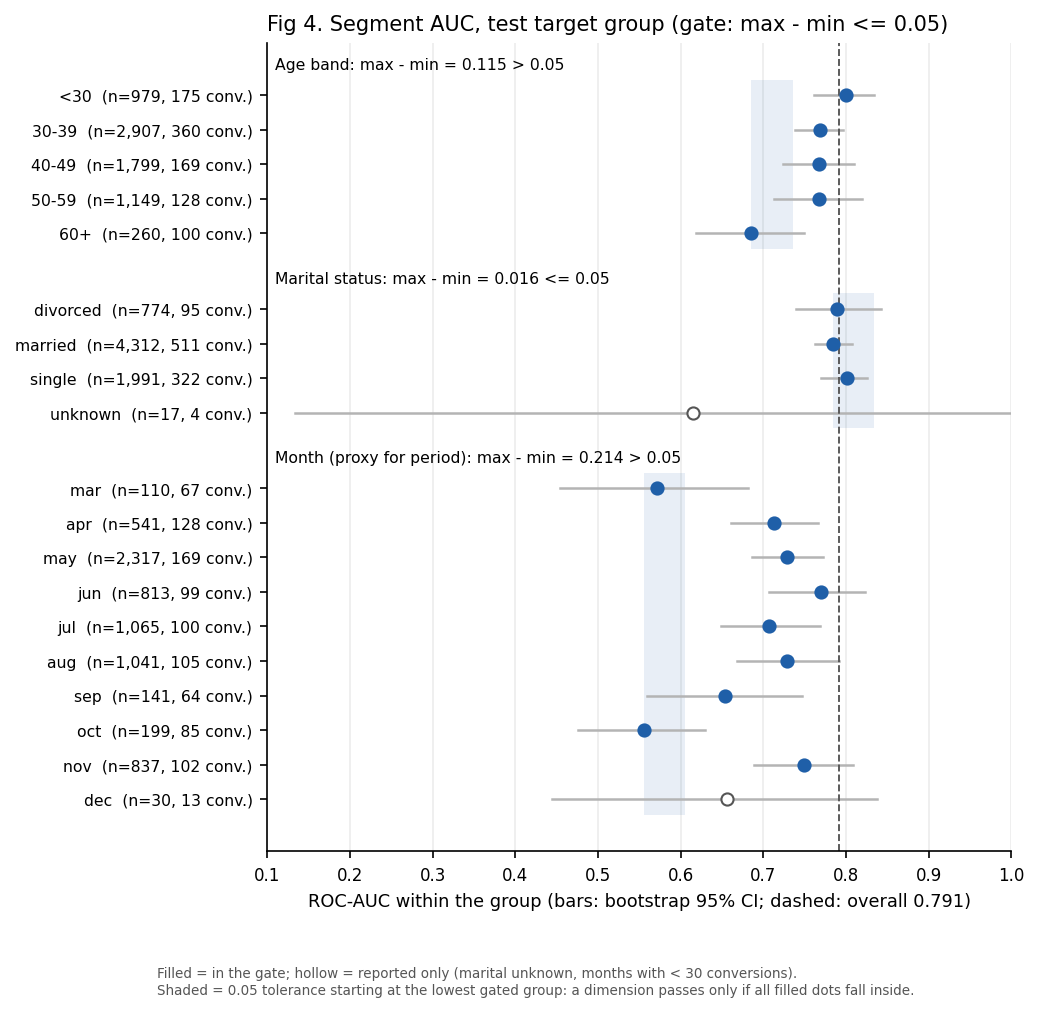

In [80]:
# [Fig 4] 分群 AUC 點圖：實心 = 納入判定的群、空心 = 只列報；淺色帶 = 從該維度最低 AUC 起算 0.05 的容許寬度
pb_dim_lab = {'age_band': 'Age band', 'marital': 'Marital status', 'month': 'Month (proxy for period)'}
fig, ax = plt.subplots(figsize=(6.4, 7.0), dpi=150)
ypos, ylabels, y = [], [], 0
for dim in PB_ORDER:
    seg = pb_seg[pb_seg['dimension'] == dim]
    y0 = y
    for _, r in seg.iterrows():
        filled = r['in_gate']
        ax.plot([r['ci_low'], r['ci_high']], [y, y], color=PB_LIGHT, lw=1.2, zorder=2)
        ax.scatter([r['auc']], [y], s=34, zorder=3, color=PB_ACCENT if filled else 'white',
                   edgecolor=PB_ACCENT if filled else PB_GREY)
        ylabels.append('%s  (n=%s, %d conv.)' % (r['group'], format(int(r['n']), ','), r['conversions']))
        ypos.append(y)
        y += 1
    e = seg[seg['in_gate']]
    lo_auc = e['auc'].min()
    ax.fill_betweenx([y0 - 0.45, y - 0.55], lo_auc, lo_auc + 0.05, color=PB_ACCENT, alpha=0.10, lw=0)
    gap = pb_gap[dim]['max_minus_min']
    ax.text(0.01, y0 - 0.75, '%s: max - min = %.3f %s 0.05' % (pb_dim_lab[dim], gap, '<=' if gap <= 0.05 else '>'),
            transform=ax.get_yaxis_transform(), ha='left', fontsize=7.5, color='black')
    y += 1.2
ax.axvline(pb_auc_te, color=PB_GREY, ls='--', lw=0.9)
ax.set_yticks(ypos)
ax.set_yticklabels(ylabels, fontsize=7.5)
ax.invert_yaxis()
ax.set_xlabel('ROC-AUC within the group (bars: bootstrap 95%% CI; dashed: overall %.3f)' % pb_auc_te, fontsize=8.5)
ax.set_xlim(0.1, 1.0)
ax.set_title('Fig 4. Segment AUC, test target group (gate: max - min <= 0.05)', loc='left', fontsize=10)
ax.tick_params(axis='x', labelsize=8)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='x', color='#ececec', lw=0.8)
ax.set_axisbelow(True)
fig.text(0.01, 0.0, 'Filled = in the gate; hollow = reported only (marital unknown, months with < 30 conversions).\n'
         'Shaded = 0.05 tolerance starting at the lowest gated group: a dimension passes only if all filled dots fall inside.',
         fontsize=6.5, color=PB_GREY, va='top')
plt.show()

### B-9 圖 4 解讀：分群 AUC

**結論：婚姻三群都落在 0.05 的容許帶內；年齡的兩端與月份散得最開。**

- 淺色帶是從各維度最低 AUC 起算 0.05 的寬度，實心點全落在帶內，該維度才算達標。
- 小群（3 月、10 月、60 歲以上）的區間寬度都超過 0.05，單輪資料本來就量不準 —— A2 表 10 用「連續 2 輪」才觸發重驗，就是這個原因。

In [81]:
# [Part B-10] 撥號前模型的 permutation importance（測試集目標組；把某欄打亂後 ROC-AUC 下降多少；n_repeats = 10）
pb_pi = permutation_importance(pb_main, pb_teT[PB_FEATURES], pb_y_teT, scoring='roc_auc', n_repeats=10,
                               random_state=PB_SEED, n_jobs=-1)
pb_pi_tab = pd.DataFrame({'feature': PB_FEATURES, 'mean AUC drop': pb_pi.importances_mean,
                          'sd': pb_pi.importances_std}).sort_values('mean AUC drop', ascending=False).reset_index(drop=True)
display(pb_pi_tab.round(4))
# 拿掉年齡、婚姻（法遵可能不准用，A2 表 9 階段 0）後重訓：同樣固定的超參數、同樣只用訓練集目標組；測試 AUC 只當敏感度
pb_drop = {}
for drop in (['age'], ['marital'], ['age', 'marital']):
    num_, cat_ = [c for c in PB_NUM if c not in drop], [c for c in PB_CAT if c not in drop]
    m_ = pb_pipeline(pb_rf(n_jobs=-1, max_depth=pb_main_params['max_depth'], min_samples_leaf=pb_main_params['min_samples_leaf']),
                     cat_, num_).fit(pb_trT[num_ + cat_], pb_y_trT)
    m_.set_params(clf__n_jobs=1)
    pb_drop['_'.join(drop)] = pb_auc(pb_y_teT, m_.predict_proba(pb_teT[num_ + cat_])[:, 1])
display(pd.DataFrame({'test AUC after retraining': pb_drop, 'change vs all 11 features': {k: v - pb_auc_te for k, v in pb_drop.items()}}).round(4))
A3_KPI['part_b']['perm_importance'] = {r['feature'].replace('.', '_'): {'mean_auc_drop': a3_r(r['mean AUC drop']), 'sd': a3_r(r['sd'])}
                                       for _, r in pb_pi_tab.iterrows()}
A3_KPI['part_b']['perm_importance_rank'] = list(pb_pi_tab['feature'])
A3_KPI['part_b']['drop_retrain'] = {k: {'test_auc': a3_r(v), 'change': a3_r(v - pb_auc_te)} for k, v in pb_drop.items()}

,feature,mean AUC drop,sd
0,cons.conf.idx,0.0438,0.0040
1,cons.price.idx,0.0407,0.0044
2,poutcome,0.0243,0.0022
3,default,0.0099,0.0024
4,previous,0.0090,0.0019
5,age,0.0037,0.0019
6,job,0.0033,0.0016
7,education,0.0014,0.0013
8,loan,0.0003,0.0004
9,housing,0.0002,0.0010


,test AUC after retraining,change vs all 11 features
age,0.7892,-0.0020
marital,0.7935,0.0023
age_marital,0.7892,-0.0020


### B-10 解讀：permutation importance 與拿掉年齡、婚姻的代價

**結論：模型最依賴 cci、cpi（時期），其次是前次行銷結果；拿掉年齡或婚姻重訓，AUC 幾乎不變。**

- **permutation importance**：打亂 cci 時測試 AUC 平均掉 0.0438；cpi 0.0407、poutcome 0.0243；其餘欄位都在 0.01 以下（婚姻 -0.0004、年齡 0.0037）。這與同一時期內 AUC 只有 0.5390 一致：時期內 cpi、cci 不變，可用的只剩客戶欄位。
- **拿掉欄位重訓**（同樣固定的超參數、只用訓練集目標組；測試 AUC 只當敏感度）：拿掉年齡 0.7892（-0.0020）、拿掉婚姻 0.7935（+0.0023）、兩者都拿掉 0.7892（-0.0020）。
- **這是關聯，不是因果**：不能說「消費者信心高，客戶就會因此辦卡」；cpi 與 cci 都是時期代理，彼此相關，重要度會互相分攤。
- **商業意義**：(1) 上線評分時 cpi、cci 用最新已公布值，超出訓練範圍（A2 表 10：cpi 92.2–94.8、cci −50.8 至 −26.9）就要觸發重驗；(2) 若法遵不准用年齡、婚姻，拿掉的代價很小。

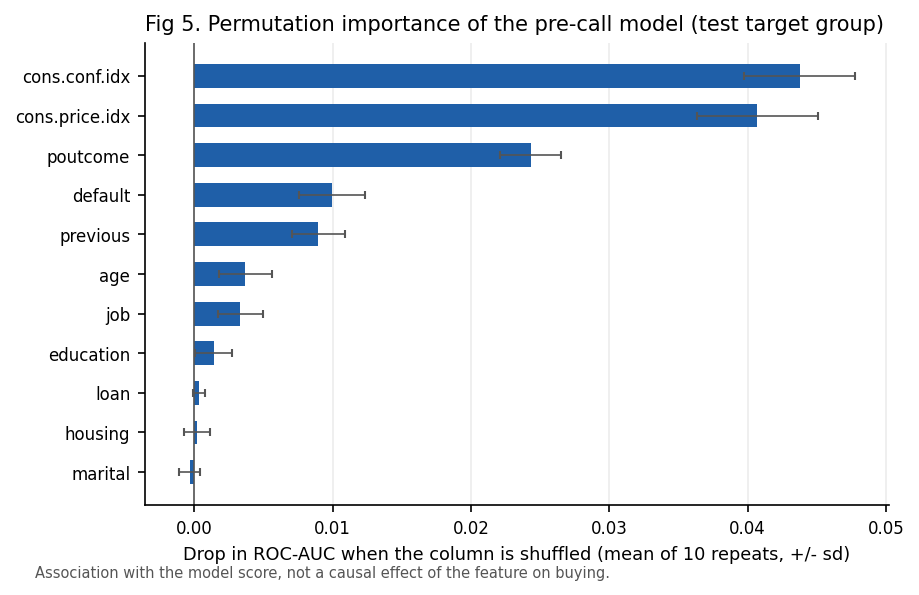

In [82]:
# [Fig 5] permutation importance 長條圖（關聯，不是因果）
fig, ax = plt.subplots(figsize=(6.4, 4.0), dpi=150)
t_ = pb_pi_tab.iloc[::-1]
ax.barh(t_['feature'], t_['mean AUC drop'], xerr=t_['sd'], color=PB_ACCENT, height=0.6,
        error_kw=dict(ecolor=PB_GREY, lw=0.8, capsize=2))
ax.axvline(0, color=PB_GREY, lw=0.8)
ax.set_xlabel('Drop in ROC-AUC when the column is shuffled (mean of 10 repeats, +/- sd)', fontsize=8.5)
ax.set_title('Fig 5. Permutation importance of the pre-call model (test target group)', loc='left', fontsize=10)
ax.tick_params(labelsize=8)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='x', color='#ececec', lw=0.8)
ax.set_axisbelow(True)
fig.text(0.01, -0.01, 'Association with the model score, not a causal effect of the feature on buying.', fontsize=7, color=PB_GREY)
plt.show()

### B-10 圖 5 解讀

長條是打亂該欄後 AUC 的平均下降（誤差線為 10 次重複的標準差）。前三名（cci、cpi、poutcome）遠高於其他欄位；loan、housing、marital 的下降與 0 無法區分。圖只說明模型依賴哪些欄位，不代表這些欄位「造成」購買。

### ML⑤ 增量排序模型：不可離線驗（A2 表 4 ML 第 5 列）

- **A2 表 4 的標準**：名單內客戶的平均增量 > 全體平均增量（＝隨機外撥組轉換率 − 對照組轉換率）；資料來源是 12 週後累積的常設對照組（5–10% 不外撥、照樣評分）＋隨機外撥組（A2 表 9 的常設列）。
- **試點資料做不到**：沒有客戶編號、兩組組成不同（前次行銷成功者：原始全檔目標組 4.10% 對對照組 2.76%；去重後 4.11% 對 3.60%）、去重不對稱；而 B-6 已經顯示，連「全體平均增量」本身在去重測試集上都只有 +0.12 個百分點。
- 所以本檔不建增量模型、不作達標判定；做法（目標組、對照組各建一個模型，分數相減前先校準）留在報告的未來改進。

In [83]:
# [Part B-11] 依 A2 表 7 勝出的 XGB：十條標準做與 RF 完全相同的評估（同樣的名單規則、門檻、bootstrap、資料口徑與判定規則）
# ①：同月同通數名單的 c(r)/r；②、ML②、ML③：B-2、B-3 已算；③④：同門檻對照組，去重與原始兩口徑（原始口徑在原始訓練集目標組上
# 用同樣固定的超參數重訓 XGB，scale_pos_weight 同樣取該訓練資料的負／正比）；⑤：2u − r；ML④：與 B-9 相同的分群與納入規則
pb_teTx, pb_teCx = pb_teT.assign(s=pb_teT['s_x']), pb_teC.assign(s=pb_teC['s_x'])
pb_upX, pb_upxX = pb_uplift(pb_teTx, pb_teCx, pb_K)
pb_rtrT_y = (pb_rtrT['y'] == 'yes').astype(int)
pb_raw_xgb = pb_pipeline(XGBClassifier(n_estimators=200, scale_pos_weight=float((pb_rtrT_y == 0).sum() / (pb_rtrT_y == 1).sum()),
                                       random_state=PB_SEED, n_jobs=1, **pb_xgb_params), PB_CAT).fit(pb_rtrT[PB_FEATURES], pb_rtrT_y)
pb_rteTx = pb_rteT.assign(s=pb_raw_xgb.predict_proba(pb_rteT[PB_FEATURES])[:, 1])
pb_rteCx = pb_rteC.assign(s=pb_raw_xgb.predict_proba(pb_rteC[PB_FEATURES])[:, 1])
pb_upX_raw, pb_upxX_raw = pb_uplift(pb_rteTx, pb_rteCx, pb_K_raw)
pb_b5X = {'dedup_ml_list': pb_net(pb_upxX['u'], pb_upxX['r']), 'raw_ml_list': pb_net(pb_upxX_raw['u'], pb_upxX_raw['r'])}
pb_segX = []
for dim, order in PB_ORDER.items():
    for gname in order:
        g = pb_teT[pb_teT[dim].astype(str) == gname]
        y = (g['y'] == 'yes').to_numpy()
        n1 = int(y.sum())
        pb_segX.append({'dimension': dim, 'group': gname, 'auc': pb_auc(y, g['s_x']) if 0 < n1 < len(y) else np.nan,
                        'in_gate': bool(PB_RULE[dim](gname, n1))})
pb_segX = pd.DataFrame(pb_segX)
pb_gapX = {dim: float(e['auc'].max() - e['auc'].min()) for dim, e in pb_segX[pb_segX['in_gate']].groupby('dimension')}


def pb_judge(m):
    """同一套判定規則（RF 與 XGB 共用）；m = 該模型的各項結果"""
    j = {'b1': '達標' if m['cost'] <= pb_a2['cost_per_conv_target_18pct'] else '未達',
         'b2': '達標' if m['b2_pass'] else ('未達' if m['b2_diff'] <= 0 else '未證實')}
    ud, ur = m['up_dedup'], m['up_raw']
    lows = [ud['uplift_ci_low_pp'], ur['uplift_ci_low_pp'], ud['period_stratified_ci_low_pp'], ur['period_stratified_ci_low_pp']]
    highs = [ud['uplift_ci_high_pp'], ur['uplift_ci_high_pp'], ud['period_stratified_ci_high_pp'], ur['period_stratified_ci_high_pp']]
    j['b3'] = '達標' if min(lows) > 0 else ('未達' if max(highs) < 0 else '未證實')
    wl, wh = min(ud['would_buy_ci_low_pct'], ur['would_buy_ci_low_pct']), max(ud['would_buy_ci_high_pct'], ur['would_buy_ci_high_pct'])
    j['b4'] = '未達' if wl > 50 else ('達標' if wh < 50 else '未證實')          # 對照 A2 式 2 的 50% 兩平參考
    j['b5'] = '示算'
    j['ml1'] = '達標' if pb_poc['auc_test'] >= 0.80 else '未達'
    j['ml2'] = '未達' if (m['auc'] < 0.75 or j['b2'] == '未達') else ('達標' if j['b2'] == '達標' else '未證實')
    j['ml3'] = '達標' if (pb_poc['gap_train_minus_test'] <= 0.05 and m['gap'] <= 0.05) else '未達'
    j['ml4'] = '達標' if all(v <= 0.05 for v in m['ml4_gaps'].values()) else '未達'
    j['ml5'] = '不可離線驗'
    return j


pb_m_rf = {'cost': pb_cost_per_conv(pb_r_L), 'b2_pass': pb_b2_pass, 'b2_diff': pb_diff, 'up_dedup': pb_up, 'up_raw': pb_up_raw,
           'auc': pb_auc_te, 'gap': pb_auc_tr - pb_auc_te, 'ml4_gaps': {d: v['max_minus_min'] for d, v in pb_gap.items()}}
pb_m_x = {'cost': pb_cost_per_conv(pb_conv(pb_Lx)), 'b2_pass': pb_b2_x_pass, 'b2_diff': pb_diff_x, 'up_dedup': pb_upX, 'up_raw': pb_upX_raw,
          'auc': pb_auc_x, 'gap': pb_auc_x_tr - pb_auc_x, 'ml4_gaps': pb_gapX}
pb_j_rf, pb_j_x = pb_judge(pb_m_rf), pb_judge(pb_m_x)


def pb_ud_txt(u):
    return '%+.2f [%+.2f, %+.2f]; within periods %+.2f [%+.2f, %+.2f]' % (
        u['uplift_pp'], u['uplift_ci_low_pp'], u['uplift_ci_high_pp'], u['period_stratified_uplift_pp'],
        u['period_stratified_ci_low_pp'], u['period_stratified_ci_high_pp'])


pb_cmp_rows = [
    ('① cost per conversion, month-matched list (A$)', '%.2f' % pb_m_rf['cost'], '%.2f' % pb_m_x['cost']),
    ('② list - mobile, same calls per month (pp), 95% CI B = 1,000', '%+.2f %s' % (100 * pb_diff, pb_iv(pb_ci_m['pct_lo'], pb_ci_m['pct_hi'])),
     '%+.2f %s' % (100 * pb_diff_x, pb_iv(pb_ci_x['pct_lo'], pb_ci_x['pct_hi']))),
    ('③ uplift, dedup (pp)', pb_ud_txt(pb_up), pb_ud_txt(pb_upX)),
    ('③ uplift, raw data (pp)', pb_ud_txt(pb_up_raw), pb_ud_txt(pb_upX_raw)),
    ('④ would-buy share, dedup / raw (%)', '%.1f / %.1f' % (pb_up['would_buy_share_pct'], pb_up_raw['would_buy_share_pct']),
     '%.1f / %.1f' % (pb_upX['would_buy_share_pct'], pb_upX_raw['would_buy_share_pct'])),
    ('⑤ 2u - r per call (D), dedup / raw', '%+.3f / %+.3f' % (pb_b5['dedup_ml_list']['net_D_per_call_excl_call_cost'], pb_b5['raw_ml_list']['net_D_per_call_excl_call_cost']),
     '%+.3f / %+.3f' % (pb_b5X['dedup_ml_list']['net_D_per_call_excl_call_cost'], pb_b5X['raw_ml_list']['net_D_per_call_excl_call_cost'])),
    ('ML② test AUC / within-period AUC', '%.4f / %.4f' % (pb_auc_te, pb_auc_wp), '%.4f / %.4f' % (pb_auc_x, pb_auc_x_wp)),
    ('ML③ train - test AUC', '%.4f' % (pb_auc_tr - pb_auc_te), '%.4f' % (pb_auc_x_tr - pb_auc_x)),
    ('ML④ AUC gap age / marital / month', ' / '.join('%.3f' % pb_m_rf['ml4_gaps'][d] for d in PB_ORDER),
     ' / '.join('%.3f' % pb_gapX[d] for d in PB_ORDER)),
]
display(pd.DataFrame(pb_cmp_rows, columns=['criterion', 'RF (main, pre-specified)', 'XGB (A2 table 7 winner)']))
pb_j_tab = pd.DataFrame({'RF': pb_j_rf, 'XGB': pb_j_x})
pb_j_tab['same'] = pb_j_tab['RF'] == pb_j_tab['XGB']
display(pb_j_tab.T)
print('judgements identical for all ten criteria:', bool(pb_j_tab['same'].all()))
A3_KPI['part_b']['xgb_eval'] = {
    'cost_formula': a3_r(pb_m_x['cost'], 2), 'b3b4_dedup': pb_upX, 'b3b4_raw': pb_upX_raw, 'b5': pb_b5X,
    'ml4_gaps': {d: a3_r(v) for d, v in pb_gapX.items()}, 'judgement': pb_j_x,
    'same_judgement_as_rf': bool(pb_j_tab['same'].all()), 'differs_on': [k for k, v in pb_j_tab['same'].items() if not v],
}

,criterion,"RF (main, pre-specified)",XGB (A2 table 7 winner)
0,"① cost per conversion, month-matched list (A$)",22.11,21.91
1,"② list - mobile, same calls per month (pp), 95% CI B = 1,000","+0.19 [-0.13, +0.72]","+0.38 [+0.00, +0.84]"
2,"③ uplift, dedup (pp)","+0.46 [-1.03, +1.90]; within periods -0.97 [-2.36, +0.44]","-0.25 [-1.77, +1.33]; within periods -1.40 [-2.79, +0.08]"
3,"③ uplift, raw data (pp)","+4.02 [+2.64, +5.42]; within periods +0.75 [-0.67, +2.10]","+3.72 [+2.28, +5.10]; within periods +0.80 [-0.65, +2.07]"
4,"④ would-buy share, dedup / raw (%)",97.4 / 77.2,101.4 / 79.1
5,"⑤ 2u - r per call (D), dedup / raw",-0.166 / -0.096,-0.182 / -0.104
6,ML② test AUC / within-period AUC,0.7912 / 0.5390,0.8034 / 0.5454
7,ML③ train - test AUC,0.0367,0.0335
8,ML④ AUC gap age / marital / month,0.115 / 0.016 / 0.214,0.057 / 0.019 / 0.129


,b1,b2,b3,b4,b5,ml1,ml2,ml3,ml4,ml5
RF,未達,未證實,未證實,未達,示算,達標,未證實,達標,未達,不可離線驗
XGB,未達,未證實,未證實,未達,示算,達標,未證實,達標,未達,不可離線驗
same,True,True,True,True,True,True,True,True,True,True


judgements identical for all ten criteria: True


### B-11 解讀：依 A2 表 7 勝出的 XGB，十條標準的平行評估

**結論：XGB 的十條判定與 RF 完全相同。它的 AUC 較高（0.8034 對 0.7912），但同一時期內只有 0.5454；② 差 +0.38 pp、區間下限沒有大於 0，仍未通過；去重口徑的增量甚至是 -0.25 pp。換成較強的模型不改變「停在階段 0」—— 瓶頸在資料（缺撥號前的客戶特徵、時期與組別不可比），不在演算法。**

- **①**：同月配對名單 A\$21.91（RF A\$22.11），仍高於 A\$20.87。
- **③④**：去重 -0.25 pp [-1.77, +1.33]、原始 +3.72 pp [+2.28, +5.10]；分時期 -1.40／+0.80 pp（區間都含 0）；本來就會買 101.4%／79.1%。
- **⑤**：2u − r = -0.182／-0.104 D 每通，2:1 下仍為負。
- **ML②③④**：測試 AUC 0.8034、訓練 − 測試 0.0335；分群 AUC 差：年齡 0.057、婚姻 0.019、月份 0.129。

In [84]:
# [Part B-12] A2 表 4 十條標準的紅綠燈總表（判定文字本身就是結論；顏色只是輔助）。主模型 RF；XGB 欄 = B-11 的同規則判定
pb_b1, pb_b2, pb_ml = A3_KPI['part_b']['b1'], A3_KPI['part_b']['b2'], A3_KPI['part_b']['ml']
pb_b34d, pb_b34r, pb_xe = pb_up, pb_up_raw, A3_KPI['part_b']['xgb_eval']


def pb_yes(k, v):
    """『是否達 A2 門檻』：是／否／離線無法判定"""
    if k in ('b3', 'b5', 'ml5'):
        return '離線無法判定' if v != '未達' else '否'
    if k == 'b4':
        return {'未達': '否（區間高於 50% 兩平參考）', '達標': '是（區間低於 50%）'}.get(v, '離線無法判定')
    return '是' if v == '達標' else '否'


pb_jr = pb_j_rf
pb_zero = [lab for lab, lo, hi in (('去重', pb_b34d['uplift_ci_low_pp'], pb_b34d['uplift_ci_high_pp']),
                                   ('原始', pb_b34r['uplift_ci_low_pp'], pb_b34r['uplift_ci_high_pp']),
                                   ('去重分時期', pb_b34d['period_stratified_ci_low_pp'], pb_b34d['period_stratified_ci_high_pp']),
                                   ('原始分時期', pb_b34r['period_stratified_ci_low_pp'], pb_b34r['period_stratified_ci_high_pp'])) if lo <= 0 <= hi]
pb_zero_txt = '、'.join(pb_zero) if pb_zero else '無'
pb_kpi = pd.DataFrame([
    ('業務① 每筆成交通話成本', '≤ A$%.2f（名單轉換率 18%%）；A/B 列報項' % pb_a2['cost_per_conv_target_18pct'], '表 4 業務①（草稿第 225 行）',
     '月配對名單 A$%.2f（實際秒數 A$%.2f；同時期配對 A$%.2f）；手機規則 A$%.2f；隨機 A$%.2f' % (pb_b1['ml_cost_formula'], pb_b1['ml_cost_actual'], pb_b1['ml_period_cost_formula'], pb_b1['mobile_cost_formula'], pb_b1['random_cost_formula']),
     pb_jr['b1'], pb_yes('b1', pb_jr['b1']), '%s（A$%.2f）' % (pb_j_x['b1'], pb_xe['cost_formula']),
     '名單變淺成本會降，但能降多少取決於時期（同月與同時期配對差很多）；深度要由 A/B 校準'),
    ('業務② 名單轉換率（上線硬門檻）', '高於同期手機規則組', '表 4 業務②（草稿第 226 行）',
     '月配對名單 %.2f%% vs 手機 %.2f%%：差 %+.2f pp，95%% 區間 [%+.2f, %+.2f]（percentile，B = 1,000）' % (pb_b2['ml_conv_pct'], pb_b2['mobile_conv_pct'], pb_b2['diff_pp'], pb_b2['ci_low_pp'], pb_b2['ci_high_pp']),
     pb_jr['b2'], pb_yes('b2', pb_jr['b2']), '%s（%+.2f pp [%+.2f, %+.2f]）' % (pb_j_x['b2'], pb_b2['xgb']['diff_pp'], pb_b2['xgb']['ci_low_pp'], pb_b2['xgb']['ci_high_pp']),
     '同時期配對：差 %+.2f pp，percentile [%+.2f, %+.2f]；+contact 同月 %+.2f pp [%+.2f, %+.2f]；B = 5,000、basic 區間與換種子見附錄 A' % (pb_b2['period']['diff_pp'], pb_b2['period']['ci_low_pp'], pb_b2['period']['ci_high_pp'], pb_b2['contact_diff_pp'], pb_b2['contact_ci_low_pp'], pb_b2['contact_ci_high_pp'])),
    ('業務③ 增量成交（上線硬門檻）', '為正：名單轉換率 > 同門檻對照組', '表 4 業務③（草稿第 227 行）',
     '單一門檻名單：去重 %+.2f pp [%+.2f, %+.2f]；原始 %+.2f pp [%+.2f, %+.2f]；分時期 %+.2f [%+.2f, %+.2f]／%+.2f [%+.2f, %+.2f]' % (pb_b34d['uplift_pp'], pb_b34d['uplift_ci_low_pp'], pb_b34d['uplift_ci_high_pp'], pb_b34r['uplift_pp'], pb_b34r['uplift_ci_low_pp'], pb_b34r['uplift_ci_high_pp'], pb_b34d['period_stratified_uplift_pp'], pb_b34d['period_stratified_ci_low_pp'], pb_b34d['period_stratified_ci_high_pp'], pb_b34r['period_stratified_uplift_pp'], pb_b34r['period_stratified_ci_low_pp'], pb_b34r['period_stratified_ci_high_pp']),
     pb_jr['b3'], pb_yes('b3', pb_jr['b3']), '%s（去重 %+.2f、原始 %+.2f；分時期 %+.2f／%+.2f）' % (pb_j_x['b3'], pb_xe['b3b4_dedup']['uplift_pp'], pb_xe['b3b4_raw']['uplift_pp'], pb_xe['b3b4_dedup']['period_stratified_uplift_pp'], pb_xe['b3b4_raw']['period_stratified_uplift_pp']),
     '兩組不是隨機分派、無客戶編號、去重不對稱；含 0 的區間：%s（共 4 個）→ 離線無法判定為正，確認排在 A/B' % pb_zero_txt),
    ('業務④ 本來就會買的比例（列報）', 'A/B 量出各組比例；兩平參考 50%', '表 4 業務④（草稿第 228 行）',
     '單一門檻名單：去重 %.1f%% [%.1f, %.1f]；原始 %.1f%% [%.1f, %.1f]（試點全體 %.1f%%）' % (pb_b34d['would_buy_share_pct'], pb_b34d['would_buy_ci_low_pct'], pb_b34d['would_buy_ci_high_pct'], pb_b34r['would_buy_share_pct'], pb_b34r['would_buy_ci_low_pct'], pb_b34r['would_buy_ci_high_pct'], pb_a2['pilot_would_buy_share_pct']),
     pb_jr['b4'], pb_yes('b4', pb_jr['b4']), '%s（%.1f%%／%.1f%%）' % (pb_j_x['b4'], pb_xe['b3b4_dedup']['would_buy_share_pct'], pb_xe['b3b4_raw']['would_buy_share_pct']),
     'A2 不設硬門檻；以式 2 的 50% 兩平點判讀：兩個口徑都高於 50%，即 2:1 下名單每多打一通都虧（與⑤一致）'),
    ('業務⑤ 式 1 淨值（上線硬門檻）', '不低於同期手機規則組', '表 4 業務⑤（草稿第 229 行）',
     '單一門檻名單 2u−r = %+.3f D／通（去重）、%+.3f D／通（原始）；隨機 %+.3f／%+.3f' % (pb_b5['dedup_ml_list']['net_D_per_call_excl_call_cost'], pb_b5['raw_ml_list']['net_D_per_call_excl_call_cost'], pb_b5['dedup_random']['net_D_per_call_excl_call_cost'], pb_b5['raw_random']['net_D_per_call_excl_call_cost']),
     pb_jr['b5'], pb_yes('b5', pb_jr['b5']), '%s（%+.3f／%+.3f D）' % (pb_j_x['b5'], pb_xe['b5']['dedup_ml_list']['net_D_per_call_excl_call_cost'], pb_xe['b5']['raw_ml_list']['net_D_per_call_excl_call_cost']),
     '2:1 假設下的示算；手機規則組的增量離線量不到（對照組沒有 contact）'),
    ('ML① 概念驗證 AUC', '≥ 0.80（只當樂觀參考）', '表 4 ML 第 1 列（草稿第 230 行）',
     '測試 %.4f／訓練 %.4f（全部測試列）' % (pb_ml['ml1_poc_test_auc'], pb_ml['ml1_poc_train_auc']),
     pb_jr['ml1'], pb_yes('ml1', pb_jr['ml1']), '（同一個官方模型）', '含 duration（通話後才知），測試集也被官方 cell-53 拿來選模'),
    ('ML② 撥號前 AUC', '≥ 0.75，且 ② 勝過同期手機規則組', '表 4 ML 第 2 列（草稿第 231 行）',
     'AUC %.4f（測試集目標組；≥ 0.75：%s）；② %s' % (pb_ml['ml2_test_auc'], '是' if pb_ml['ml2_test_auc'] >= 0.75 else '否', pb_jr['b2']),
     pb_jr['ml2'], pb_yes('ml2', pb_jr['ml2']), '%s（AUC %.4f；② %s）' % (pb_j_x['ml2'], pb_ml['xgb_test_auc'], pb_j_x['b2']),
     '同一 (cpi, cci) 時期內 AUC 只有 %.4f（XGB %.4f）；LR 基準 %.4f' % (pb_ml['ml2_within_period_auc'], pb_ml['xgb_within_period_auc'], pb_ml['ml2_lr_test_auc'])),
    ('ML③ 過擬合（訓練−測試 AUC）', '≤ 0.05', '表 4 ML 第 3 列（草稿第 232 行）',
     '概念驗證 %+.4f；撥號前 %+.4f' % (pb_ml['ml1_poc_gap'], pb_ml['ml3_precall_gap']),
     pb_jr['ml3'], pb_yes('ml3', pb_jr['ml3']), '%s（%+.4f）' % (pb_j_x['ml3'], pb_ml['xgb_gap']),
     '撥號前版本的超參數只用訓練資料選出；設計階段曾預跑同一測試集，屬樂觀估計'),
    ('ML④ 分群一致性', '各群 AUC 差 ≤ 0.05', '表 4 ML 第 4 列（草稿第 233 行）',
     '年齡 %.3f；婚姻 %.3f；月份（代理時期）%.3f' % (pb_gap['age_band']['max_minus_min'], pb_gap['marital']['max_minus_min'], pb_gap['month']['max_minus_min']),
     pb_jr['ml4'], pb_yes('ml4', pb_jr['ml4']), '%s（%.3f／%.3f／%.3f）' % (pb_j_x['ml4'], pb_xe['ml4_gaps']['age_band'], pb_xe['ml4_gaps']['marital'], pb_xe['ml4_gaps']['month']),
     '舊資格母體；小群樣本不足（區間寬）；入選比例另列報給法遵'),
    ('ML⑤ 增量排序模型', '名單內平均增量 > 全體', '表 4 ML 第 5 列（草稿第 234 行）', '未建（依 A2 設計，12 週後才有資料）',
     pb_jr['ml5'], pb_yes('ml5', pb_jr['ml5']), pb_j_x['ml5'], '需要常設對照組＋隨機外撥組；試點沒有客戶編號'),
], columns=['標準', 'A2 門檻', 'A2 出處（表號／草稿行）', 'A3 結果（RF 主模型；標明名單口徑）', '判定', '是否達 A2 門檻', 'XGB（表 7 勝出者）', '說明'])
PB_COLOR = {'達標': '#d9ead3', '未達': '#f4cccc', '未證實': '#fff2cc', '示算': '#e8e8e8', '不可離線驗': '#e8e8e8'}
display(pb_kpi.style.apply(lambda col: ['background-color: %s; font-weight: bold' % PB_COLOR[v] for v in col], subset=['判定'])
        .set_properties(**{'text-align': 'left'}).hide(axis='index'))
print('RF judgements:', pb_kpi['判定'].value_counts().to_dict(), '| XGB judgements identical:', bool(pb_j_tab['same'].all()))
A3_KPI['part_b']['kpi_counts'] = {k: int((pb_kpi['判定'] == k).sum()) for k in PB_COLOR}
A3_KPI['part_b']['kpi_judgement'] = dict(zip(['b1', 'b2', 'b3', 'b4', 'b5', 'ml1', 'ml2', 'ml3', 'ml4', 'ml5'], pb_kpi['判定']))
A3_KPI['part_b']['kpi_meets_a2'] = dict(zip(['b1', 'b2', 'b3', 'b4', 'b5', 'ml1', 'ml2', 'ml3', 'ml4', 'ml5'], pb_kpi['是否達 A2 門檻']))
A3_KPI['part_b']['kpi_business_pass'] = int(sum(A3_KPI['part_b']['kpi_judgement'][k] == '達標' for k in ['b1', 'b2', 'b3', 'b4', 'b5']))
A3_KPI['part_b']['b3_ci_include_zero'] = pb_zero

標準,A2 門檻,A2 出處（表號／草稿行）,A3 結果（RF 主模型；標明名單口徑）,判定,是否達 A2 門檻,XGB（表 7 勝出者）,說明
業務① 每筆成交通話成本,≤ A$20.87（名單轉換率 18%）；A/B 列報項,表 4 業務①（草稿第 225 行）,月配對名單 A$22.11（實際秒數 A$21.47；同時期配對 A$22.56）；手機規則 A$22.32；隨機 A$27.17,未達,否,未達（A$21.91）,名單變淺成本會降，但能降多少取決於時期（同月與同時期配對差很多）；深度要由 A/B 校準
業務② 名單轉換率（上線硬門檻）,高於同期手機規則組,表 4 業務②（草稿第 226 行）,"月配對名單 16.77% vs 手機 16.58%：差 +0.19 pp，95% 區間 [-0.13, +0.72]（percentile，B = 1,000）",未證實,否,"未證實（+0.38 pp [+0.00, +0.84]）","同時期配對：差 -0.21 pp，percentile [-0.60, +0.19]；+contact 同月 +0.32 pp [-0.02, +0.73]；B = 5,000、basic 區間與換種子見附錄 A"
業務③ 增量成交（上線硬門檻）,為正：名單轉換率 > 同門檻對照組,表 4 業務③（草稿第 227 行）,"單一門檻名單：去重 +0.46 pp [-1.03, +1.90]；原始 +4.02 pp [+2.64, +5.42]；分時期 -0.97 [-2.36, +0.44]／+0.75 [-0.67, +2.10]",未證實,離線無法判定,未證實（去重 -0.25、原始 +3.72；分時期 -1.40／+0.80）,兩組不是隨機分派、無客戶編號、去重不對稱；含 0 的區間：去重、去重分時期、原始分時期（共 4 個）→ 離線無法判定為正，確認排在 A/B
業務④ 本來就會買的比例（列報）,A/B 量出各組比例；兩平參考 50%,表 4 業務④（草稿第 228 行）,"單一門檻名單：去重 97.4% [89.7, 106.2]；原始 77.2% [70.4, 84.4]（試點全體 76.2%）",未達,否（區間高於 50% 兩平參考）,未達（101.4%／79.1%）,A2 不設硬門檻；以式 2 的 50% 兩平點判讀：兩個口徑都高於 50%，即 2:1 下名單每多打一通都虧（與⑤一致）
業務⑤ 式 1 淨值（上線硬門檻）,不低於同期手機規則組,表 4 業務⑤（草稿第 229 行）,單一門檻名單 2u−r = -0.166 D／通（去重）、-0.096 D／通（原始）；隨機 -0.129／-0.068,示算,離線無法判定,示算（-0.182／-0.104 D）,2:1 假設下的示算；手機規則組的增量離線量不到（對照組沒有 contact）
ML① 概念驗證 AUC,≥ 0.80（只當樂觀參考）,表 4 ML 第 1 列（草稿第 230 行）,測試 0.8715／訓練 0.8951（全部測試列）,達標,是,（同一個官方模型）,含 duration（通話後才知），測試集也被官方 cell-53 拿來選模
ML② 撥號前 AUC,≥ 0.75，且 ② 勝過同期手機規則組,表 4 ML 第 2 列（草稿第 231 行）,AUC 0.7912（測試集目標組；≥ 0.75：是）；② 未證實,未證實,否,未證實（AUC 0.8034；② 未證實）,"同一 (cpi, cci) 時期內 AUC 只有 0.5390（XGB 0.5454）；LR 基準 0.7327"
ML③ 過擬合（訓練−測試 AUC）,≤ 0.05,表 4 ML 第 3 列（草稿第 232 行）,概念驗證 +0.0236；撥號前 +0.0367,達標,是,達標（+0.0335）,撥號前版本的超參數只用訓練資料選出；設計階段曾預跑同一測試集，屬樂觀估計
ML④ 分群一致性,各群 AUC 差 ≤ 0.05,表 4 ML 第 4 列（草稿第 233 行）,年齡 0.115；婚姻 0.016；月份（代理時期）0.214,未達,否,未達（0.057／0.019／0.129）,舊資格母體；小群樣本不足（區間寬）；入選比例另列報給法遵
ML⑤ 增量排序模型,名單內平均增量 > 全體,表 4 ML 第 5 列（草稿第 234 行）,未建（依 A2 設計，12 週後才有資料）,不可離線驗,離線無法判定,不可離線驗,需要常設對照組＋隨機外撥組；試點沒有客戶編號


RF judgements: {'未達': 3, '未證實': 3, '達標': 2, '示算': 1, '不可離線驗': 1} | XGB judgements identical: True


### B-12 解讀：A2 表 4 十條標準的總表

**結論：兩條「達標」都是 ML 指標，業務指標沒有一條達標；三條上線硬門檻（②③⑤）沒有一條能離線判定為通過。**

- 10 條中：達標 2（ML①、ML③）、未證實 3（②、③、ML②）、未達 3（①、④、ML④）、示算 1（⑤）、不可離線驗 1（ML⑤）。XGB 欄的判定逐條相同。
- ②：同月配對名單看不出比手機規則好（差的 95% 區間 [-0.13, +0.72]，未做等效性檢定），同時期為負；③：方向取決於資料版本與是否控制時期；④：兩個口徑都高於 50% 兩平參考；⑤：只能示算，而且為負。

In [85]:
# [Part B-13] A2 表 1 的商業目標（目標層級）：現況 → 目標 → A3 離線結果（金額都用未取整的數字相減後才取整）
pb_ext = A3_KPI['part_b']['b1']['one_round_extrapolation']
pb_save_target = PB_PILOT_COST - pb_ext['a2_target_18pct']['call_cost_exact']          # A2：每輪約省 A$14,900
pb_save_ml = PB_PILOT_COST - pb_ext['ml_list']['call_cost_exact']
pb_save_ml_vs_mob = pb_ext['mobile']['call_cost_exact'] - pb_ext['ml_list']['call_cost_exact']
pb_save_ml_p = PB_PILOT_COST - pb_ext['ml_list_period']['call_cost_exact']


def pb_mult(u, r):
    return '%.1f×' % (r / u) if u > 0 else '無（增量 ≤ 0）'


pb_goal = pd.DataFrame([
    ('增量成交（外撥＋優惠帶來）', '每千名外撥約 %.0f 人' % (10 * pb_a2['pilot_uplift_pp']), '為正（同門檻對照組）',
     '每千通：去重 %+.1f、原始 %+.1f；控制時期後 %+.1f／%+.1f（區間都含 0）' % (pb_up['uplift_per_1000_calls'], pb_up_raw['uplift_per_1000_calls'], 10 * pb_up['period_stratified_uplift_pp'], 10 * pb_up_raw['period_stratified_uplift_pp']),
     A3_KPI['part_b']['kpi_judgement']['b3']),
    ('成交者中本來就會買的比例（折扣外溢）', '約 %.0f%%' % pb_a2['pilot_would_buy_share_pct'], 'A/B 量出（第一步可能升高；兩平 50%）',
     '去重 %.1f%%、原始 %.1f%%（兩者的區間都高於 50%%）' % (pb_up['would_buy_share_pct'], pb_up_raw['would_buy_share_pct']),
     A3_KPI['part_b']['kpi_judgement']['b4']),
    ('每輪通話成本（同樣 2,300 筆成交）', 'A$%s' % format(int(round(PB_PILOT_COST)), ','),
     '約 A$%s，每輪省約 A$%s' % (format(pb_ext['a2_target_18pct']['call_cost'], ','), format(int(round(pb_save_target)), ',')),
     'ML 名單外推 A$%s：比現況省 A$%s（目標節省的 %.0f%%），比手機規則（A$%s）只省 A$%s；同時期配對 A$%s' % (
         format(pb_ext['ml_list']['call_cost'], ','), format(int(round(pb_save_ml)), ','), 100 * pb_save_ml / pb_save_target,
         format(pb_ext['mobile']['call_cost'], ','), format(int(round(pb_save_ml_vs_mob)), ','), format(pb_ext['ml_list_period']['call_cost'], ',')),
     '未達' if pb_save_ml < pb_save_target else '達標'),
    ('外撥量', '%s 通' % format(pb_a2['pilot_target_n'], ','), '少約 %.0f%%' % pb_ext['a2_target_18pct']['fewer_calls_vs_pilot_pct'],
     'ML 名單少 %.1f%%（手機規則 %.1f%%）' % (pb_ext['ml_list']['fewer_calls_vs_pilot_pct'], pb_ext['mobile']['fewer_calls_vs_pilot_pct']),
     '未達' if pb_ext['ml_list']['fewer_calls_vs_pilot_pct'] < pb_ext['a2_target_18pct']['fewer_calls_vs_pilot_pct'] else '達標'),
    ('不依 2:1 的兩平：每張卡收益 ÷ 折扣至少要幾倍（r ÷ u，未計通話費）', '%s（試點）' % pb_mult(pb_r_pilot - pb_r_ctrl_raw, pb_r_pilot), '越低越好（A2 假設框）',
     'ML 名單：原始 %s、去重 %s；控制時期後 原始 %s、去重 %s' % (pb_mult(pb_upx_raw['u'], pb_upx_raw['r']), pb_mult(pb_upx['u'], pb_upx['r']),
                                                 pb_mult(pb_upx_raw['u_period'], pb_upx_raw['r']), pb_mult(pb_upx['u_period'], pb_upx['r'])),
     '示算'),
], columns=['A2 表 1 目標', '現況（試點）', 'A2 目標', 'A3 離線結果', '判定'])
display(pb_goal.style.apply(lambda col: ['background-color: %s; font-weight: bold' % PB_COLOR[v] for v in col], subset=['判定'])
        .set_properties(**{'text-align': 'left'}).hide(axis='index'))
A3_KPI['part_b']['goals'] = {
    'pilot_call_cost_aud': int(round(PB_PILOT_COST)),
    'saving_target_aud': int(round(pb_save_target)), 'saving_ml_vs_pilot_aud': int(round(pb_save_ml)),
    'saving_ml_share_of_target_pct': a3_r(100 * pb_save_ml / pb_save_target, 1), 'saving_ml_vs_mobile_aud': int(round(pb_save_ml_vs_mob)),
    'saving_ml_period_vs_pilot_aud': int(round(pb_save_ml_p)),
    'fewer_calls_ml_pct': pb_ext['ml_list']['fewer_calls_vs_pilot_pct'], 'fewer_calls_mobile_pct': pb_ext['mobile']['fewer_calls_vs_pilot_pct'],
    'fewer_calls_target_pct': pb_ext['a2_target_18pct']['fewer_calls_vs_pilot_pct'],
    'multiple_pilot': a3_r(pb_r_pilot / (pb_r_pilot - pb_r_ctrl_raw), 1),
    'multiple_ml_raw': a3_r(pb_upx_raw['r'] / pb_upx_raw['u'], 1) if pb_upx_raw['u'] > 0 else None,
    'multiple_ml_dedup': a3_r(pb_upx['r'] / pb_upx['u'], 1) if pb_upx['u'] > 0 else None,
    'multiple_ml_raw_period': a3_r(pb_upx_raw['r'] / pb_upx_raw['u_period'], 1) if (pb_upx_raw['u_period'] or 0) > 0 else None,
    'multiple_ml_dedup_period': a3_r(pb_upx['r'] / pb_upx['u_period'], 1) if (pb_upx['u_period'] or 0) > 0 else None,
    'judgement': dict(zip(['incremental', 'spillover', 'round_cost', 'fewer_calls', 'revenue_multiple'], pb_goal['判定'])),
}

A2 表 1 目標,現況（試點）,A2 目標,A3 離線結果,判定
增量成交（外撥＋優惠帶來）,每千名外撥約 31 人,為正（同門檻對照組）,每千通：去重 +4.6、原始 +40.2；控制時期後 -9.7／+7.5（區間都含 0）,未證實
成交者中本來就會買的比例（折扣外溢）,約 76%,A/B 量出（第一步可能升高；兩平 50%）,去重 97.4%、原始 77.2%（兩者的區間都高於 50%）,未達
"每輪通話成本（同樣 2,300 筆成交）","A$62,905","約 A$47,992，每輪省約 A$14,913","ML 名單外推 A$50,861：比現況省 A$12,044（目標節省的 81%），比手機規則（A$51,341）只省 A$480；同時期配對 A$51,887",未達
外撥量,"17,642 通",少約 28%,ML 名單少 22.3%（手機規則 21.4%）,未達
不依 2:1 的兩平：每張卡收益 ÷ 折扣至少要幾倍（r ÷ u，未計通話費）,4.2×（試點）,越低越好（A2 假設框）,ML 名單：原始 4.4×、去重 37.9×；控制時期後 原始 23.5×、去重 無（增量 ≤ 0）,示算


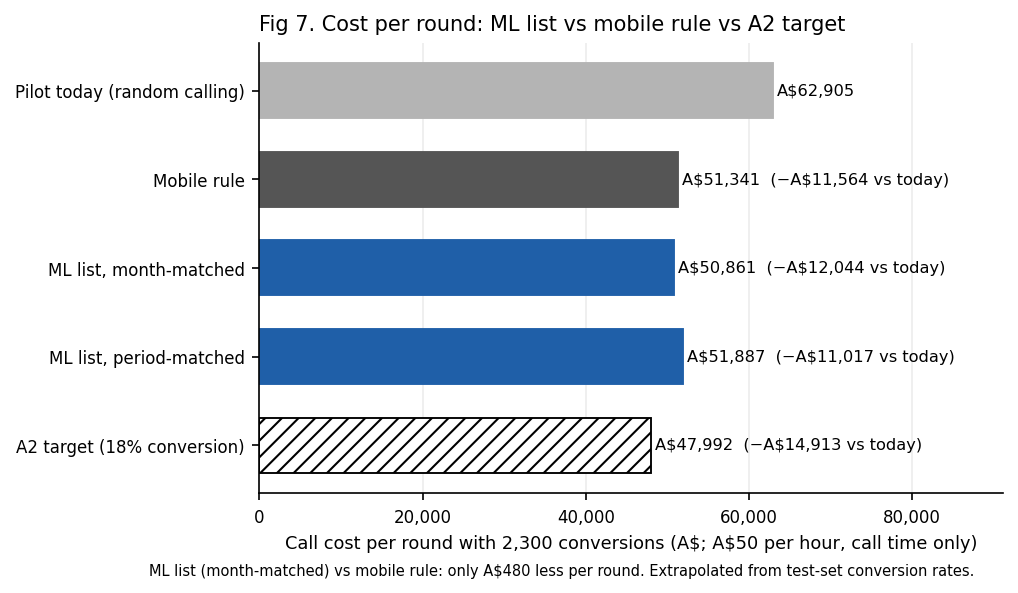

In [86]:
# [Fig 7] 每輪通話成本（同樣 2,300 筆成交；A2 表 1 的目標層級）：現況、手機規則、ML 名單、A2 目標（外推值，不是測得的）
pb_bars = [('Pilot today (random calling)', PB_PILOT_COST, PB_LIGHT),
           ('Mobile rule', pb_ext['mobile']['call_cost_exact'], PB_GREY),
           ('ML list, month-matched', pb_ext['ml_list']['call_cost_exact'], PB_ACCENT),
           ('ML list, period-matched', pb_ext['ml_list_period']['call_cost_exact'], PB_ACCENT),
           ('A2 target (18% conversion)', pb_ext['a2_target_18pct']['call_cost_exact'], 'white')]
fig, ax = plt.subplots(figsize=(6.4, 3.9), dpi=150)
for i, (lab, v, col) in enumerate(pb_bars):
    ax.barh(i, v, color=col, edgecolor='black' if col == 'white' else col, lw=0.9, height=0.62, hatch='///' if col == 'white' else None)
    note = '' if i == 0 else r'  (%sA\$%s vs today)' % ('\u2212' if v < PB_PILOT_COST else '+', format(int(round(abs(PB_PILOT_COST - v))), ','))
    ax.text(v + 500, i, r'A\$%s%s' % (format(int(round(v)), ','), note), va='center', fontsize=7.8)
ax.set_yticks(range(len(pb_bars)))
ax.set_yticklabels([b[0] for b in pb_bars], fontsize=8)
ax.invert_yaxis()
ax.set_xlim(0, PB_PILOT_COST * 1.45)
ax.xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda v, _: format(int(v), ',')))
ax.set_xlabel(r'Call cost per round with 2,300 conversions (A\$; A\$50 per hour, call time only)', fontsize=8.5)
ax.set_title('Fig 7. Cost per round: ML list vs mobile rule vs A2 target', loc='left', fontsize=10)
ax.tick_params(axis='x', labelsize=8)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='x', color='#ececec', lw=0.8)
ax.set_axisbelow(True)
fig.text(0.01, -0.03, r'ML list (month-matched) vs mobile rule: only A\$%s less per round. Extrapolated from test-set conversion rates.'
         % format(int(round(pb_save_ml_vs_mob)), ','), fontsize=7, color='black')
plt.show()

### B-13 解讀：A2 表 1 的商業目標（上表與圖 7）

**結論：以 A2 表 1 的目標看，離線結果沒有一項達標；對決策最有用的一個數字是 —— 相對現行手機規則，名單每輪只省約 A\$480（圖 7）。**

- **每輪通話成本**：A2 目標是每輪省約 A\$14,913；同月配對名單外推可省 A\$12,044（目標的 81%），但這幾乎全是手機規則本來就能省的；同時期配對的名單只省 A\$11,017。外撥量少 22.3%（手機規則 21.4%，目標約 28%）。
- **收益倍數（不依 2:1）**：A2 試點每張卡收益至少要是折扣的 4.2 倍才不虧；名單在原始口徑要 4.4 倍、去重口徑要 37.9 倍 —— 第一步名單沒有讓這個門檻變低，反而更高。
- **增量與外溢**：增量為正與外溢比例都要等 A/B 的常設對照組才量得到（B-6、B-8）。
- **商業意義**：A2 寫的「每輪省約 A\$14,900」是以名單轉換率 18% 推得的；離線證據顯示，在與手機規則同通數下達不到 18%，而節省的大部分不需要 ML 也拿得到。圖 7 的金額都是用測試集轉換率外推的，不是測得的。

<a id="conclusion" name="conclusion"></a>
## 結論

1. **AUC 達標 ≠ 商業達標。** 撥號前 AUC 0.7912 過了 0.75，但同一時期內只有 0.5390；業務指標 0／5 達標（B-2、B-12）。
2. **② 可以離線判定：未通過。** 同月只比手機規則高 0.19 pp，區間 [-0.13, +0.72] 含 0；同時期 -0.21 pp（B-3）。
3. **③⑤ 離線無法判定，要等 A/B。** ③ 控制時期後 -0.97／+0.75 pp，區間都含 0；⑤ 缺手機規則組的增量，2:1 示算為負（B-6、B-7）。
4. **換模型不是解方。** 依 A2 表 7 勝出的 XGB，十條判定與 RF 相同；名單每輪只比手機規則省約 A\$480（B-11、B-13）。
5. **建議：照 A2 的 12 週計畫，停在第 1–4 週。** 階段 0 未過，不進第 5–7 週影子模式；先補撥號前客戶特徵、外撥日期與客戶編號，用新的時間段重測（年齡、婚姻先交法遵，拿掉它們 AUC 幾乎不變）。

## 附錄 A：業務② 區間的穩健性檢查（看過第一次結果之後才加，不改判準）

判準是評估計畫原本訂的：同月配對名單 − 手機規則的差 > 0，且各月內 bootstrap（B = 1,000、種子 123）的 95% percentile 區間下限 > 0。下表的其他欄位都是看過第一次結果後才加的，只用來確認判定不是抽樣運氣；任何一欄都不改判準。數字與 B-3 第二張表相同。

| 名單（同月、4,752 通） | 差（pp） | 判準：percentile，B = 1,000 | basic，B = 1,000 | percentile，B = 5,000 | basic，B = 5,000 | 另外 10 個種子的 percentile 下限（B = 1,000） |
|---|---|---|---|---|---|---|
| RF（主） | +0.19 | [-0.13, +0.72] | [-0.34, +0.51] | [-0.15, +0.69] | [-0.31, +0.53] | -0.19 到 -0.13（0 個 > 0） |
| RF ＋contact | +0.32 | [-0.02, +0.73] | [-0.10, +0.65] | [+0.00, +0.73] | [-0.10, +0.63] | -0.04 到 +0.02（3 個 > 0） |
| XGB（表 7 勝出者） | +0.38 | [+0.00, +0.84] | [-0.09, +0.76] | [-0.02, +0.84] | [-0.09, +0.78] | -0.04 到 +0.00（0 個 > 0） |

- **為什麼另報 basic 區間**：RF 名單的 bootstrap 平均 +0.27 高於點估計 +0.19（重抽會複製高分成交者，分布往上偏），偏差校正的 basic 區間（2 × 點估計 − 上、下界）會往下移。RF 主名單不論用哪一種區間、B 用 1,000 或 5,000、換哪個種子，下限都 < 0，判定不變。
- **＋contact 與 XGB 處在邊界**：＋contact 在種子 123 的下限是 -0.02，另外 10 個種子中有 3 個 > 0；XGB 在種子 123 的下限恰好是 +0.00，另外 10 個種子都沒有 > 0。依判準兩者都不算通過；就算採用某個下限 > 0 的種子，basic 區間的下限仍 < 0，同時期配對也為負 —— 不足以支持「名單比手機規則好」。

## 附錄：數字總表（KPI JSON）

下一格把本次執行中報告會引用的數字印成一個 JSON：上面 markdown 中的數字都由它填入，報告也引用它。`clustering` 一節因 KMeans 沒有 random_state，不列入跨次執行的一致性比對；`meta` 記錄套件版本、列數、選定的超參數、bootstrap 次數與兩條判準（業務②、A2 表 7）。

In [87]:
# [附錄] 本次執行的數字總表（JSON）。markdown 中的數字都由它填入；第一、二層每個鍵各佔一行，以免輸出過長
A3_KPI['meta'] = {
    'student': 'Kenny Huang 26254793', 'subject': '321513 Machine Learning AT3 (business focus)',
    'versions': {'python': sys.version.split()[0], 'numpy': np.__version__, 'pandas': pd.__version__,
                 'scikit-learn': sklearn.__version__, 'xgboost': xgboost.__version__, 'scipy': scipy.__version__,
                 'matplotlib': matplotlib.__version__, 'seaborn': sns.__version__},
    'rows': {'raw': pb_a2['raw_rows'], 'dedup': pb_a2['dedup_rows'], 'train': len(pb_train), 'test': len(pb_test),
             'test_target': len(pb_teT), 'test_control': len(pb_teC), 'train_target': len(pb_trT)},
    'split': {'test_size': 0.4, 'random_state': RANDOM_SATE, 'stratify': None},
    'poc_grid': {'max_depth': [3, 5, 9], 'criterion': ['gini', 'entropy'], 'n_estimators': [100, 200, 300]},
    'poc_best_params': A3_KPI['part_a']['final_pipeline']['best_params'],
    'precall_main_params': pb_main_params, 'precall_contact_params': pb_ct_params,
    'precall_grid': {'max_depth': [5, 7, 9], 'min_samples_leaf': [1, 20], 'n_estimators': 300, 'cv': 'StratifiedKFold(5, shuffle, 123)'},
    'xgb_challenger_grid': {'max_depth': [3, 5], 'learning_rate': [0.05, 0.1], 'n_estimators': 200, 'scale_pos_weight': 'neg/pos of the training target group'},
    'xgb_challenger_params': A3_KPI['part_b']['models']['xgb_params'],
    'bootstrap': {'b2_B_plan': PB_B2_B, 'b2_B_check': PB_B2_B_CHECK, 'b2_extra_seeds': 10, 'b3_B': 1000, 'b3_period_B': 1000,
                  'b8_B': 1000, 'ml4_B': 500, 'seed': PB_SEED},
    'b2_gate_rule': 'difference > 0 and 95% percentile CI lower bound > 0 (B = 1,000, seed 123)',
    'xgb_replacement_rule': 'A2 table 7: mean CV-AUC margin over 5 seeds (123-127) > RF seed-to-seed range, and ahead on every seed',
    'cost_assumptions': {'hourly_aud': PB_HOURLY, 'sec_yes': pb_a2['sec_yes'], 'sec_no': pb_a2['sec_no'], 'D_example_aud': PB_D,
                         'revenue_to_discount': '2:1'},
}


def pb_clean_json(o):
    if isinstance(o, dict):
        return {str(k): pb_clean_json(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)):
        return [pb_clean_json(v) for v in o]
    if isinstance(o, (bool, np.bool_)):
        return bool(o)
    if isinstance(o, (int, np.integer)):
        return int(o)
    if isinstance(o, (float, np.floating)):
        return None if np.isnan(o) else round(float(o), 6)
    return o


def pb_dump(o):
    """合法 JSON；第一、二層的鍵各佔一行，更深的內容壓成一行"""
    out = ['{']
    keys = list(o)
    for i, k in enumerate(keys):
        tail = ',' if i < len(keys) - 1 else ''
        v = o[k]
        if isinstance(v, dict) and v:
            out.append(' %s: {' % json.dumps(k, ensure_ascii=False))
            sub = list(v)
            for j, kk in enumerate(sub):
                out.append('  %s: %s%s' % (json.dumps(kk, ensure_ascii=False), json.dumps(v[kk], ensure_ascii=False),
                                           ',' if j < len(sub) - 1 else ''))
            out.append(' }' + tail)
        else:
            out.append(' %s: %s%s' % (json.dumps(k, ensure_ascii=False), json.dumps(v, ensure_ascii=False), tail))
    out.append('}')
    return '\n'.join(out)


pb_json_txt = pb_dump(pb_clean_json(A3_KPI))
assert json.loads(pb_json_txt) == pb_clean_json(A3_KPI)
print('===A3_KPI_JSON_BEGIN===')
print(pb_json_txt)
print('===A3_KPI_JSON_END===')

===A3_KPI_JSON_BEGIN===
{
 "part_a": {
  "rows_after_dedup": 35438,
  "eda": {"base_conv_pct": 12.88, "cat_conv_pct": {"job": {"admin.": 15.61, "blue-collar": 8.1, "entrepreneur": 8.99, "housemaid": 10.7, "management": 12.27, "retired": 26.52, "self-employed": 11.36, "services": 9.2, "student": 31.56, "technician": 12.66, "unemployed": 14.71, "unknown": 12.05}, "education": {"basic.4y": 11.59, "basic.6y": 9.05, "basic.9y": 9.03, "high.school": 12.32, "illiterate": 22.22, "professional.course": 13.03, "university.degree": 16.09, "unknown": 15.14}, "default": {"no": 14.86, "unknown": 5.74, "yes": 0.0}, "housing": {"no": 12.52, "unknown": 11.04, "yes": 13.29}, "loan": {"no": 13.23, "unknown": 11.04, "yes": 11.49}}, "cat_rows": {"job": {"admin.": 8426, "blue-collar": 7776, "entrepreneur": 1368, "housemaid": 991, "management": 2641, "retired": 1625, "self-employed": 1312, "services": 3469, "student": 846, "technician": 5705, "unemployed": 972, "unknown": 307}, "education": {"basic.4y": 3667